# Certification Atlas CISIA — Orientation et tri multimodal des demandeurs d'emploi par l'IA

**Candidat :** Ahmed LAHAW
**Session :** Promo Upskilling Atlas — mai-oct 2026 (Session-00279143)

## Journal de bord

Ce notebook constitue à la fois ma **production technique** (code, analyses, modèles) et mon **journal de bord**
(explications de mes choix méthodologiques à chaque étape), comme demandé dans les consignes de l'épreuve.

### Rappel de l'objectif métier

On me demande de construire un système d'IA qui prédit, à partir d'informations recueillies lors du premier
entretien d'un demandeur d'emploi, sa **classe de retour à l'emploi** :

- **Classe 0** — Retour rapide (< 6 mois)
- **Classe 1** — Retour moyen (6 à 12 mois)
- **Classe 2** — Risque de chômage de longue durée (> 12 mois)

C'est une tâche de **classification supervisée multi-classes (3 classes)**, à partir de données **multimodales** :
des données tabulaires (âge, diplôme, ancienneté...), une variable sensible (nationalité hors UE), une variable
géographique (code INSEE) et un texte libre rédigé par le conseiller.

**Point métier essentiel à garder en tête pour toute la suite du projet** : une erreur qui classe un usager
réellement en classe 2 (risque fort) comme classe 0 (retour rapide) est *beaucoup plus grave* qu'une confusion
entre classes 0 et 1, car elle prive l'usager d'un accompagnement renforcé dont il a besoin. On y reviendra
concrètement à l'étape de modélisation (choix des poids de classes, des seuils de décision, et de la métrique
d'évaluation).

### Deux règles méthodologiques que je m'impose dès le départ

Elles reviendront à chaque étape, et je les énonce ici pour pouvoir être jugé dessus :

1. **Aucune statistique n'est calculée sur le jeu de test** — ni médiane, ni mode, ni vocabulaire TF-IDF, ni
   catégories du one-hot.
2. **Aucune décision n'est prise en regardant le jeu de test** — ni le choix du modèle, ni celui du seuil, ni
   celui du scénario de données. Toutes les décisions se prennent en validation croisée sur le jeu
   d'entraînement, avec une règle annoncée avant d'en regarder les résultats. Le test ne sert qu'à une chose :
   une mesure finale, une seule fois, de ce qui a été décidé sans lui.

La deuxième règle est plus exigeante que la première, et c'est elle qui a le plus changé mes conclusions.

## Feuille de route du projet

On avance étape par étape. Voici les grandes étapes que je vais suivre (elles correspondent aux 9 compétences
évaluées par la certification) :

1. **Cadrage + Exploration des données (EDA)** ⬅️ *on est ici*
2. Nettoyage & préprocessing (valeurs manquantes, feature engineering, encodage, vectorisation du texte)
3. Construction des 4 scénarios de données à comparer (multimodal complet / sans variables sensibles / texte seul / tabulaire seul)
4. Entraînement de plusieurs modèles (Random Forest, LightGBM, XGBoost) + validation croisée stratifiée
5. Évaluation (accuracy, F1-macro, matrice de confusion) et comparaison des 4 scénarios
6. Optimisation métier : réduire les erreurs critiques (classe 2 prédite comme 0)
7. Choix et justification du modèle final (performance / coût de calcul)
8. Volet éthique et réglementaire (RGPD, non-discrimination, responsabilité)
9. Architecture cible d'industrialisation (API, MLflow, monitoring, CI/CD, Docker, interface conseiller)

Chaque étape sera ajoutée à ce même notebook au fur et à mesure qu'on avance ensemble.

---
# Étape 1 — Cadrage et exploration des données (EDA)

**Objectif de cette étape :** avant de nettoyer ou de modéliser quoi que ce soit, je dois comprendre "à quoi
ressemblent" mes données : combien de lignes, quelles colonnes, quels types, où sont les valeurs manquantes,
comment se répartit la variable cible, et quelles variables auront besoin d'un traitement particulier.

C'est une étape obligatoire dans toute démarche data science : on ne code jamais un modèle "à l'aveugle".

## 1.0 — Cadrage : d'où viennent ces données, et que fait-on quand elles manquent ?

Avant d'ouvrir le fichier, je fixe ce que je sais de son origine et de ses conditions d'usage. C'est
la partie du travail qui ne produit aucun graphique et qui détermine pourtant si la suite a un sens.

**Besoin métier.** Une agence nationale de l'emploi reçoit chaque usager en entretien de cadrage et
doit décider, à l'issue de cet entretien, du niveau d'accompagnement à lui proposer. La décision est
aujourd'hui prise par le conseiller seul, sur la base de son appréciation. Le besoin n'est pas de
remplacer ce jugement mais de lui adjoindre un signal homogène d'une agence à l'autre, en particulier
pour les situations où le risque de longue durée n'est pas visible au premier entretien.

**Cas d'usage retenu.** Un conseiller, en fin d'entretien de cadrage, obtient une estimation du délai
de retour à l'emploi en trois classes, avec les probabilités associées. Cette estimation alimente la
proposition d'accompagnement ; elle ne la décide pas. Deux cas d'usage secondaires apparaîtront plus
loin : un pré-tri de file d'attente avant l'entretien (Scénario 4, qui n'a pas besoin de la synthèse
écrite), et un suivi statistique de la charge d'accompagnement par bassin d'emploi.

**Origine, disponibilité et accès des données.** Le jeu fourni compte 2 500 dossiers pour lesquels
l'issue réelle du parcours est connue et a été validée par les conseillers — c'est ce qui en fait un
jeu supervisé exploitable, et non un simple export. Les variables tabulaires proviennent du
référentiel national des usagers, alimenté à l'inscription puis mis à jour à chaque contact ; la
synthèse d'entretien est saisie par le conseiller dans l'application de guichet unique. En production,
ce sont donc **deux systèmes sources distincts**, avec deux régimes de disponibilité différents : les
données administratives existent dès l'inscription, la synthèse n'existe qu'après l'entretien. Cette
asymétrie n'est pas un détail de tuyauterie, elle commande l'architecture (étape 9.1) et elle justifie
que je mesure séparément ce qu'apporte chaque bloc de variables (étape 5).

**Ce que je fais quand une donnée manque.** Aucune de ces sources n'est garantie complète, et le jeu
le montre déjà : quatre colonnes comportent des valeurs manquantes. Je prévois donc, pour chaque cas,
une solution de repli plutôt qu'un échec :

| Donnée indisponible | Solution de repli retenue | Où elle est mise en œuvre |
|---|---|---|
| Synthèse d'entretien absente ou non rédigée | Prédiction sur les seules variables tabulaires — c'est exactement le Scénario 4, qui reste exploitable avant même la tenue de l'entretien | étapes 3 et 5 ; champ optionnel côté API |
| Âge, diplôme ou statut d'allocation non renseignés | Imputation par une statistique du jeu d'entraînement **plus** un indicateur binaire de valeur manquante, pour que l'absence reste une information | étape 2 ; reproduit à l'identique dans l'API |
| Code INSEE d'une commune jamais vue à l'entraînement | Encodage neutre (ligne de zéros) **et** avertissement explicite au conseiller, pour qu'une prédiction sans apport géographique ne ressemble pas à une prédiction ordinaire | étape 9.3 |
| Variable sensible non transmise | C'est le fonctionnement nominal : le Scénario 2 retenu ne la demande pas, et le schéma d'entrée de l'API ne l'accepte pas | étapes 5 et 9.3 |

**Ce que ce jeu ne contient pas, et qui manquerait en production.** Aucune donnée sur le tissu
économique local au moment de l'entretien (taux de tension du bassin, offres ouvertes sur le code
ROME visé), aucun historique de parcours antérieur, aucune information sur la durée d'indemnisation
restante. Ce sont les trois enrichissements que je demanderais au commanditaire avant une v2, et je
les cite ici parce qu'un modèle qu'on présente sans dire ce qui lui manque se présente mal.

In [1]:
import os
import sys
from pathlib import Path

# ----------------------------------------------------------------------------
# 1. Racine du dépôt et dossier applicatif
# ----------------------------------------------------------------------------

RACINE_PROJET = Path.cwd().resolve()
DOSSIER_SRC = RACINE_PROJET / "src"

if not DOSSIER_SRC.is_dir():
    raise FileNotFoundError(
        "Le dossier src/ est introuvable.\n"
        f"Dossier de travail actuel : {RACINE_PROJET}\n"
        "Lancez Jupyter depuis la racine du dépôt (celle qui contient à la fois "
        "le notebook, README.md et src/), puis réexécutez cette cellule."
    )

# ----------------------------------------------------------------------------
# 2. Données et artefacts
# ----------------------------------------------------------------------------

CHEMIN_DATASET = DOSSIER_SRC / "dataset_trajectoire_emploi.csv"
CHEMIN_ARTEFACTS = DOSSIER_SRC / "artefacts_modele"

if not CHEMIN_DATASET.is_file():
    raise FileNotFoundError(
        "Le jeu de données est introuvable.\n"
        f"Chemin attendu : {CHEMIN_DATASET}\n"
        "Le README le situe dans src/ : vérifiez qu'il a bien été récupéré "
        "avec le dépôt."
    )

# Le dossier d'artefacts n'existe pas encore lors de la toute première
# exécution : il est créé par l'étape 7. On le prépare sans rien y écrire.
CHEMIN_ARTEFACTS.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------------------------
# 3. Un seul dossier d'artefacts pour le notebook ET pour l'API
# ----------------------------------------------------------------------------
#
# api.py lit DOSSIER_ARTEFACTS au chargement du module. La variable doit donc
# être posée AVANT l'import du § 9.3, sans quoi l'API se rabattrait sur le
# chemin relatif « artefacts_modele » interprété depuis la racine — c'est-à-dire
# sur un second jeu d'artefacts, différent de celui que déploient Docker et la CI.

os.environ["DOSSIER_ARTEFACTS"] = str(CHEMIN_ARTEFACTS)
os.environ["CHEMIN_DONNEES"] = str(CHEMIN_DATASET)

# ----------------------------------------------------------------------------
# 4. Journaux de démonstration, séparés de la trace d'exploitation
# ----------------------------------------------------------------------------

DOSSIER_JOURNAUX_NOTEBOOK = DOSSIER_SRC / "journaux_notebook"
DOSSIER_JOURNAUX_NOTEBOOK.mkdir(parents=True, exist_ok=True)

CHEMIN_JOURNAL = DOSSIER_JOURNAUX_NOTEBOOK / "journal_requetes.jsonl"
CHEMIN_FEEDBACK = DOSSIER_JOURNAUX_NOTEBOOK / "feedback_reentrainement.jsonl"

os.environ["FICHIER_JOURNAL"] = str(CHEMIN_JOURNAL)
os.environ["FICHIER_FEEDBACK"] = str(CHEMIN_FEEDBACK)

# Les démonstrations du § 9.3 doivent décrire CETTE exécution, et elle seule :
# on repart d'un journal vide à chaque exécution complète du notebook.
for fichier_journal in (CHEMIN_JOURNAL, CHEMIN_FEEDBACK):
    if fichier_journal.exists():
        fichier_journal.unlink()

# ----------------------------------------------------------------------------
# 5. Base MLflow : une seule, partagée avec entrainer_modele.py
# ----------------------------------------------------------------------------

CHEMIN_MLFLOW = DOSSIER_SRC / "mlflow.db"
URI_MLFLOW = f"sqlite:///{CHEMIN_MLFLOW.as_posix()}"

# ----------------------------------------------------------------------------
# 6. Rendre src/ importable (pour le § 9.3)
# ----------------------------------------------------------------------------

if str(DOSSIER_SRC) not in sys.path:
    sys.path.insert(0, str(DOSSIER_SRC))

# ----------------------------------------------------------------------------
# 7. Récapitulatif
# ----------------------------------------------------------------------------

print("=" * 88)
print("CONFIGURATION DES CHEMINS DU PROJET")
print("=" * 88)
print(f"Racine du dépôt      : {RACINE_PROJET}")
print(f"Dossier applicatif   : {DOSSIER_SRC}")
print(f"Jeu de données       : {CHEMIN_DATASET}")
print(f"Artefacts du modèle  : {CHEMIN_ARTEFACTS}")
print(f"Journal (notebook)   : {CHEMIN_JOURNAL}")
print(f"Suivi MLflow         : {URI_MLFLOW}")
print()
print("OK - le dossier src/ est présent.")
print("OK - le jeu de données est présent.")
print("OK - DOSSIER_ARTEFACTS est posé : l'API chargera les mêmes artefacts que ce notebook.")
print("OK - les journaux de démonstration sont réinitialisés pour cette exécution.")

CONFIGURATION DES CHEMINS DU PROJET
Racine du dépôt      : C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas
Dossier applicatif   : C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\src
Jeu de données       : C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\src\dataset_trajectoire_emploi.csv
Artefacts du modèle  : C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\src\artefacts_modele
Journal (notebook)   : C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\src\journaux_notebook\journal_requetes.jsonl
Suivi MLflow         : sqlite:///C:/Users/A630180/Documents/Version-certificat/certification_cisia_atlas/src/mlflow.db

OK - le dossier src/ est présent.
OK - le jeu de données est présent.
OK - DOSSIER_ARTEFACTS est posé : l'API chargera les mêmes artefacts que ce notebook.
OK - les journaux de démonstration sont réinitialisés pour cette exécution.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (8, 4)

# Le CSV est dans le même dossier que ce notebook.
#
# Note de traçabilité sur le fichier source : le fichier fourni par l'organisme utilise « ; »
# comme séparateur. Je travaille sur une version convertie en « , » ; cette conversion a
# remplacé par des virgules les points-virgules internes à 1 043 verbatims de la colonne
# `synthese_entretien`. Sans effet sur la suite (la ponctuation est retirée par le TF-IDF),
# mais c'est une modification du fichier d'origine : elle doit être écrite quelque part.
#
# dtype explicite sur le code INSEE : sans lui, pandas déciderait du type au vu des données.
# Ici le fichier contient des codes corses (2A/2B) qui forcent le type texte — mais un jeu de
# données sans Corse serait lu comme des entiers, et "07240" deviendrait 7240. On ne laisse
# pas une propriété aussi structurante dépendre du contenu du fichier.
# Le séparateur est détecté sur la ligne d'en-tête : ce notebook s'exécute donc
# indifféremment sur le fichier d'origine fourni par l'organisme (séparateur « ; »)
# ou sur la copie convertie (séparateur « , »). La conversion reste documentée
# ci-dessus, mais elle n'est plus une condition d'exécution.
with open(CHEMIN_DATASET, encoding="utf-8") as _f:
    _entete = _f.readline()
separateur = ";" if _entete.count(";") > _entete.count(",") else ","

df = pd.read_csv(CHEMIN_DATASET, sep=separateur,
                 dtype={"code_insee_commune": str})

print("Dimensions du dataset :", df.shape)
df.head()

Dimensions du dataset : (2500, 10)


,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0
3,ID_0003,60.0,Bac,0.2,A1203,63359,1.0,0,Problème ponctuel de mobilité géographique. Zo...,1
4,ID_0004,25.0,Sans diplôme,1.2,N1301,21302,1.0,0,Projet de reconversion à affiner. Besoin d'une...,0


**Ce que je lis dans ce résultat :** le dataset contient **2 500 lignes** (2 500 usagers) et **10 colonnes**.
Chaque ligne = un usager, avec ses caractéristiques et la classe réelle de retour à l'emploi qui a été constatée
sur le terrain (c'est notre variable à prédire, `classe_retour_emploi`).

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   usager_id             2500 non-null   object 
 1   age                   2378 non-null   float64
 2   niveau_diplome        2416 non-null   object 
 3   anciennete_poste_ans  2500 non-null   float64
 4   code_rome_vise        2500 non-null   object 
 5   code_insee_commune    2500 non-null   object 
 6   est_allocataire       2456 non-null   float64
 7   nationalite_hors_ue   2500 non-null   int64  
 8   synthese_entretien    2419 non-null   object 
 9   classe_retour_emploi  2500 non-null   int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 195.4+ KB


**Interprétation des types de données (`dtypes`) :**

| Colonne | Type Python | Nature réelle | Remarque |
|---|---|---|---|
| `usager_id` | texte | identifiant | à exclure de la modélisation (n'a aucun pouvoir prédictif) |
| `age` | nombre décimal | numérique continue | contient des valeurs manquantes |
| `niveau_diplome` | texte | catégorielle ordonnée | Sans diplôme < Bac < Bac+2 < Bac+5 |
| `anciennete_poste_ans` | nombre décimal | numérique continue | |
| `code_rome_vise` | texte (5 caractères) | catégorielle à haute cardinalité | métier visé, beaucoup de modalités différentes |
| `code_insee_commune` | texte | catégorielle à très haute cardinalité | il faudra en extraire le département (étape 2) |
| `est_allocataire` | 0/1 | catégorielle binaire | contient des valeurs manquantes |
| `nationalite_hors_ue` | 0/1 | catégorielle binaire — **variable sensible** | à traiter avec précaution (RGPD) |
| `synthese_entretien` | texte libre | donnée textuelle non structurée | nécessitera une vectorisation (TF-IDF ou embeddings) |
| `classe_retour_emploi` | 0/1/2 | **variable cible** | c'est ce qu'on veut prédire |

Un point important : `code_insee_commune` doit être lu comme du **texte**, jamais comme un nombre. Un code INSEE
comme `"07240"` perdrait son zéro de tête s'il était converti en entier, ce qui casserait complètement
l'information géographique (le département deviendrait « 72 » au lieu de « 07 »). Sur ce fichier précis, pandas
choisit le type texte tout seul, parce que les codes corses `2A`/`2B` contiennent des lettres — mais c'est une
chance, pas une garantie. Je l'impose donc explicitement avec `dtype=` au chargement, pour que le pipeline reste
correct sur un fichier qui, lui, ne contiendrait pas de commune corse.

In [4]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"valeurs_manquantes": missing, "pourcentage_%": missing_pct}).query("valeurs_manquantes > 0")

,valeurs_manquantes,pourcentage_%
age,122,4.9
niveau_diplome,84,3.4
est_allocataire,44,1.8
synthese_entretien,81,3.2


**Interprétation :** 4 colonnes ont des valeurs manquantes :

- `age` (~4,9 %)
- `niveau_diplome` (~3,4 %)
- `est_allocataire` (~1,8 %)
- `synthese_entretien` (~3,2 %)

Ce sont des taux de valeurs manquantes modérés (aucune colonne au-dessus de 5 %), donc on ne va pas avoir besoin
de supprimer des colonnes entières. En revanche il faudra choisir une **stratégie d'imputation adaptée à chaque
type de variable** à l'étape 2 :
- `age` (numérique) → imputation par la médiane (plus robuste aux valeurs extrêmes que la moyenne)
- `niveau_diplome` (catégorielle) → imputation par le mode, ou création d'une catégorie "Non renseigné"
- `est_allocataire` (binaire) → imputation par le mode
- `synthese_entretien` (texte) → remplacer par une chaîne vide (le vectoriseur de texte gèrera naturellement l'absence d'information)

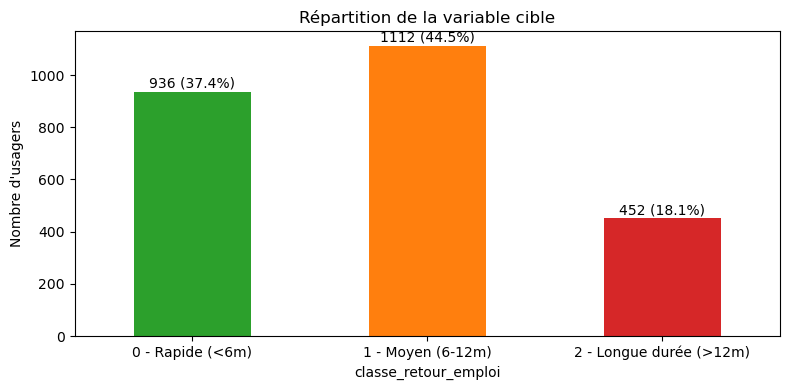

classe_retour_emploi
0    37.4
1    44.5
2    18.1
Name: count, dtype: float64


In [5]:
counts = df["classe_retour_emploi"].value_counts().sort_index()
pct = (counts / len(df) * 100).round(1)

ax = counts.plot(kind="bar", color=["#2ca02c", "#ff7f0e", "#d62728"])
ax.set_xticklabels(["0 - Rapide (<6m)", "1 - Moyen (6-12m)", "2 - Longue durée (>12m)"], rotation=0)
ax.set_ylabel("Nombre d'usagers")
ax.set_title("Répartition de la variable cible")
for i, (c, p) in enumerate(zip(counts, pct)):
    ax.text(i, c + 15, f"{c} ({p}%)", ha="center")
plt.tight_layout()
plt.show()

print(pct)

**Interprétation — un point CAPITAL pour la suite du projet :** la variable cible est **déséquilibrée**
(*imbalanced*) :

- Classe 0 (Rapide) : ~37 %
- Classe 1 (Moyen) : ~44 %
- Classe 2 (Longue durée) : ~18 %

La classe la plus critique d'un point de vue métier — la classe 2, celle qu'on ne doit surtout pas rater — est
aussi **la classe la moins représentée**. C'est un piège classique : un modèle naïf pourrait obtenir une bonne
*accuracy* globale simplement en prédisant rarement la classe 2, alors que c'est justement celle qu'on veut le
mieux détecter.

Deux conséquences concrètes pour les étapes suivantes :
1. Je ne pourrai pas me contenter de l'**accuracy** comme métrique — j'utiliserai le **F1-score macro** (qui donne
   le même poids à chaque classe, contrairement à l'accuracy qui favorise la classe majoritaire) et la **matrice
   de confusion** pour bien voir où le modèle se trompe.
2. Je devrai utiliser une **validation croisée stratifiée** (`StratifiedKFold`) pour que chaque pli d'entraînement/test
   conserve la même proportion de classes, sinon certains plis pourraient contenir très peu d'exemples de classe 2.

In [6]:
df[["age", "anciennete_poste_ans"]].describe()

,age,anciennete_poste_ans
count,2378.000000,2500.000000
mean,40.566442,2.971600
std,13.225242,2.979548
min,18.000000,0.000000
25%,29.000000,0.800000
50%,41.000000,2.000000
75%,52.000000,4.100000
max,63.000000,22.600000


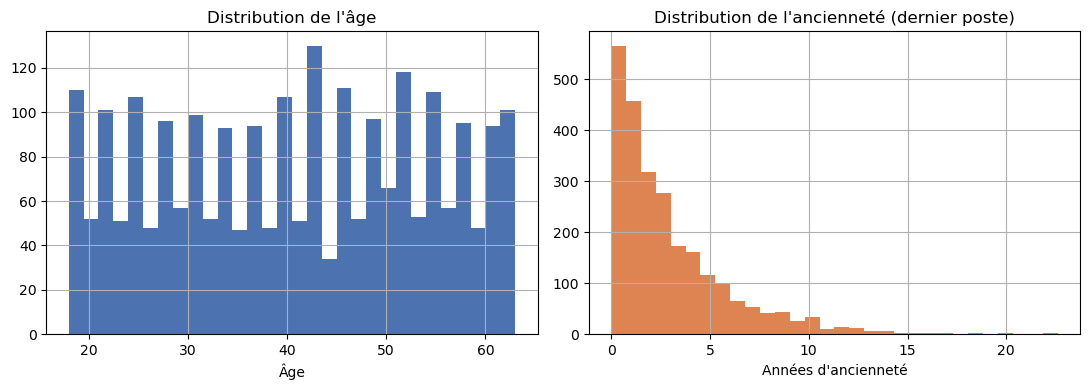

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["age"].dropna().hist(bins=30, ax=axes[0], color="#4c72b0")
axes[0].set_title("Distribution de l'âge")
axes[0].set_xlabel("Âge")

df["anciennete_poste_ans"].hist(bins=30, ax=axes[1], color="#dd8452")
axes[1].set_title("Distribution de l'ancienneté (dernier poste)")
axes[1].set_xlabel("Années d'ancienneté")
plt.tight_layout()
plt.show()

**Interprétation :** l'âge s'étend sur une plage réaliste pour une population de demandeurs d'emploi (jeunes
adultes à seniors), sans valeur aberrante flagrante (pas d'âge négatif ou de 150 ans). L'ancienneté dans le
dernier poste est fortement concentrée sur de faibles valeurs avec une longue traîne à droite (beaucoup de
personnes avec peu d'ancienneté, quelques-unes avec une très longue carrière dans le même poste) — c'est un profil
de distribution *asymétrique* (skewed) assez courant, à garder en tête : certains modèles (comme la régression
linéaire) y seraient sensibles, mais les modèles à base d'arbres (Random Forest, LightGBM, XGBoost) que je vais
utiliser sont naturellement robustes à ce type de distribution.

In [8]:
print("Niveau de diplôme :")
print(df["niveau_diplome"].value_counts(dropna=False))

print("\nStatut allocataire :")
print(df["est_allocataire"].value_counts(dropna=False))

print("\nNationalité hors UE (variable sensible) :")
print(df["nationalite_hors_ue"].value_counts(dropna=False))

Niveau de diplôme :
niveau_diplome
Bac             966
Bac+2           501
Sans diplôme    478
Bac+5           471
NaN              84
Name: count, dtype: int64

Statut allocataire :
est_allocataire
1.0    1463
0.0     993
NaN      44
Name: count, dtype: int64

Nationalité hors UE (variable sensible) :
nationalite_hors_ue
0    2205
1     295
Name: count, dtype: int64


**Interprétation :**

- `niveau_diplome` a 4 modalités bien réparties (+ valeurs manquantes déjà identifiées) — c'est une variable
  **catégorielle ordinale** (il existe un ordre naturel : Sans diplôme < Bac < Bac+2 < Bac+5), ce qui orientera
  le choix d'encodage à l'étape 2 (encodage ordinal plutôt qu'un simple one-hot, pour ne pas perdre cette notion
  d'ordre).
- `est_allocataire` et `nationalite_hors_ue` sont des variables binaires (0/1) déjà prêtes à être utilisées par
  un modèle, sans encodage supplémentaire nécessaire.
- `nationalite_hors_ue` est explicitement désignée par le sujet comme une **variable sensible** au sens du RGPD
  (elle relève potentiellement de l'origine, une catégorie particulière de données). Je devrai : (1) justifier
  pourquoi/comment je l'utilise dans le Scénario 1, et (2) construire un Scénario 2 qui l'exclut, avec une
  argumentation CNIL/RGPD — ce sera tout un point de la section éthique du rapport.

In [9]:
print("Nombre de codes ROME uniques :", df["code_rome_vise"].nunique(), "/", len(df))
print("Nombre de communes (codes INSEE) uniques :", df["code_insee_commune"].nunique(), "/", len(df))
df["code_insee_commune"].head(10)

Nombre de codes ROME uniques : 50 / 2500
Nombre de communes (codes INSEE) uniques : 2407 / 2500


0    18273
1    07240
2    01405
3    63359
4    21302
5    71315
6    59301
7    74007
8    54007
9    60574
Name: code_insee_commune, dtype: object

**Interprétation — pourquoi c'est important :** `code_rome_vise` et surtout `code_insee_commune` ont un très
grand nombre de modalités différentes (on parle de variables à **haute cardinalité**). Si j'encodais
`code_insee_commune` tel quel en one-hot, je créerais potentiellement plus de colonnes que d'observations, ce qui
ferait exploser la dimensionnalité et provoquerait du sur-apprentissage (*overfitting*).

C'est précisément pour cela que le sujet demande explicitement une étape de **feature engineering** :
**extraire le département à partir des 2 premiers caractères du code INSEE** (par exemple `"07240"` → département
`"07"`). On passe ainsi d'environ 2 000+ communes différentes à une centaine de départements — une variable
catégorielle beaucoup plus exploitable, tout en conservant l'information géographique utile (bassin d'emploi
régional). Ce sera la première chose que je ferai à l'étape 2 (nettoyage & feature engineering).

In [10]:
text_lengths = df["synthese_entretien"].dropna().str.len()
print(text_lengths.describe())

print("\nExemples de synthèses d'entretien :")
for t in df["synthese_entretien"].dropna().sample(5, random_state=0):
    print("-", t)

count    2419.000000
mean       71.338570
std         4.516476
min        63.000000
25%        70.000000
50%        73.000000
75%        74.000000
max        77.000000
Name: synthese_entretien, dtype: float64

Exemples de synthèses d'entretien :
- Candidat très dynamique, mobilité nationale validée. Projet clair.
- Profil autonome, recherche active, aucun frein périphérique identifié.
- Excellente présentation, compétences techniques à jour. Reprise rapide visée.
- Problème ponctuel de mobilité géographique. Zone mal desservie.
- Excellente présentation, compétences techniques à jour. Reprise rapide visée.


**Interprétation :** les synthèses d'entretien sont des textes courts (quelques dizaines de caractères), rédigés
par les conseillers dans un style télégraphique assez homogène (ex. "Compétences à réactualiser...",
"Cumul de difficultés..."). C'est un vocabulaire probablement assez restreint et répétitif d'un usager à l'autre,
ce qui est plutôt favorable à une vectorisation de type **TF-IDF** (qui capture bien des expressions récurrentes
sur un corpus de ce type).

Le sujet laisse le choix entre « TF-IDF/Embeddings ». Je tranche cette question à l'étape 3, une fois que j'aurai
regardé de plus près à quoi ressemble réellement ce champ — et je mesurerai le choix plutôt que de le supposer.

## 1.6 — Quelles variables ont réellement un lien avec la cible ?

Les graphiques précédents décrivent chaque variable séparément. Avant de passer au nettoyage, je veux
savoir lesquelles ont un lien statistique avec la classe de retour à l'emploi — pas pour décider quoi
que ce soit dès maintenant, mais pour savoir ce que je devrais retrouver plus tard dans le modèle, et
repérer tout de suite une variable qui n'apporterait rien.

J'utilise le **test du khi-deux d'indépendance** pour les variables catégorielles et le test de
**Kruskal-Wallis** pour les variables numériques (non paramétrique, donc insensible à l'asymétrie de
la distribution de l'ancienneté relevée plus haut). Le khi-deux dit si un lien existe ; il ne dit rien
de sa force, et il grandit mécaniquement avec le nombre de modalités. J'y ajoute donc le **V de
Cramér**, qui ramène l'intensité du lien entre 0 et 1 et reste comparable d'une variable à l'autre.

*Ces tests sont calculés sur l'ensemble du jeu. Ils sont descriptifs : aucune décision de modélisation
n'en découle — celles-là sont prises à partir de l'étape 4, sur le seul jeu d'entraînement.*

In [11]:
from scipy.stats import chi2_contingency, kruskal

# Le département n'est formellement créé qu'à l'étape 2 ; on le dérive ici de façon
# provisoire, uniquement pour ce test descriptif, sans modifier le dataframe.
colonnes_a_tester = {
    "synthese_entretien": df["synthese_entretien"],
    "niveau_diplome": df["niveau_diplome"],
    "code_rome_vise": df["code_rome_vise"],
    "nationalite_hors_ue": df["nationalite_hors_ue"],
    "departement": df["code_insee_commune"].astype(str).str.zfill(5).str[:2],
    "est_allocataire": df["est_allocataire"],
}

lignes = []
for col, valeurs in colonnes_a_tester.items():
    table = pd.crosstab(valeurs, df["classe_retour_emploi"])
    khi2, p, ddl, _ = chi2_contingency(table)
    # V de Cramér : intensité du lien, comparable entre variables de cardinalités différentes
    v_cramer = np.sqrt(khi2 / (table.values.sum() * (min(table.shape) - 1)))
    lignes.append({"variable": col, "modalités": table.shape[0], "khi²": round(khi2, 1),
                   "ddl": ddl, "p-value": f"{p:.2e}", "V de Cramér": round(v_cramer, 3)})

print("Test du khi-deux d'indépendance — variables catégorielles vs classe de retour à l'emploi")
print(pd.DataFrame(lignes).to_string(index=False))

print("\nTest de Kruskal-Wallis — variables numériques vs classe de retour à l'emploi")
for col in ["age", "anciennete_poste_ans"]:
    groupes = [df.loc[df["classe_retour_emploi"] == k, col].dropna() for k in (0, 1, 2)]
    H, p = kruskal(*groupes)
    print(f"   {col:22s} H = {H:7.1f}   p = {p:.2e}")

Test du khi-deux d'indépendance — variables catégorielles vs classe de retour à l'emploi
           variable  modalités   khi²  ddl   p-value  V de Cramér
 synthese_entretien          9 1106.4   16 1.75e-225        0.478
     niveau_diplome          4  390.6    6  2.88e-81        0.284
     code_rome_vise         50  334.7   98  1.29e-27        0.259
nationalite_hors_ue          2  123.7    2  1.40e-27        0.222
        departement         96  238.5  190  9.70e-03        0.218
    est_allocataire          2    0.7    2  6.89e-01        0.017

Test de Kruskal-Wallis — variables numériques vs classe de retour à l'emploi
   age                    H =   168.5   p = 2.63e-37
   anciennete_poste_ans   H =     7.5   p = 2.34e-02


**Ce que ce tableau m'apprend, et que je vérifierai plus tard sur le modèle :**

1. **La synthèse d'entretien est de loin la variable la plus liée à la cible** (V = 0,478). Neuf
   formulations figées suffisent donc à porter le signal le plus fort du jeu — ce qui donne déjà une
   idée de ce que vaudra le Scénario 3 : beaucoup, mais pas tout, puisqu'un V de 0,48 est un lien
   fort et non un lien déterministe. C'est la première mesure du « bruit stochastique » annoncé par
   le sujet.
2. **Le diplôme (0,284), le métier visé (0,259), la nationalité (0,222) et le département (0,218)**
   forment un second groupe homogène. Je note dès maintenant que le département a un lien réel avec
   la cible : c'est ce qui rendra légitime, à l'étape 8, la question de savoir s'il peut servir de
   variable de substitution à l'origine.
3. **`est_allocataire` n'a aucun lien avec la cible** : khi² = 0,7 pour 2 degrés de liberté,
   p = 0,69, V = 0,017. C'est le résultat le plus net du tableau, et le seul qui soit une non-relation.
   Une p-value de 0,69 signifie que la répartition observée est exactement celle qu'on attendrait si
   les deux variables étaient indépendantes. Je le retrouverai à l'identique à l'étape 8, où cette
   variable pèsera 0,1 % de la décision du modèle — et cette convergence entre un test statistique
   fait avant toute modélisation et une mesure faite sur le modèle fini est, en soi, un contrôle de
   cohérence de ma démarche.
4. **L'âge est très fortement lié à la cible** (H = 168, p ≈ 3·10⁻³⁷), bien davantage que
   l'ancienneté (H = 7,5, p = 0,02, un lien réel mais faible). C'est le point que je reprendrai à
   l'étape 8 : l'âge est un critère protégé au même titre que l'origine, et il est ici le deuxième
   signal du jeu.

---
## Ce qu'on retient de l'étape 1, avant de passer à l'étape 2

1. **2 500 usagers, 10 colonnes**, dont 1 identifiant (à exclure), 8 variables explicatives multimodales, 1 cible.
2. **4 colonnes avec valeurs manquantes** (`age`, `niveau_diplome`, `est_allocataire`, `synthese_entretien`),
   toutes sous les 5 % → imputation simple, pas de suppression de colonne nécessaire.
3. **Cible déséquilibrée**, avec la classe la plus critique (classe 2) la moins représentée (~18 %) → il faudra
   du F1-macro, une matrice de confusion, une validation croisée stratifiée, et une pondération des classes.
4. **`code_insee_commune` à très haute cardinalité** → à transformer en département (2 premiers caractères).
5. **`niveau_diplome` est ordinal** → encodage ordinal plutôt que one-hot pur.
6. **`nationalite_hors_ue` est une variable sensible** → traitement spécifique + justification RGPD/CNIL à prévoir.
7. **`synthese_entretien` est un texte court et homogène** → adapté à une vectorisation TF-IDF.

➡️ **Prochaine étape (étape 2) :** nettoyage complet (imputation), feature engineering (extraction du
département, encodage des variables catégorielles) et vectorisation du texte, pour préparer les 4 scénarios de
données à comparer.

---
# Étape 2 — Nettoyage et feature engineering

**Objectif de cette étape :** transformer les données brutes en variables directement exploitables par un
modèle, sans jamais laisser d'information du jeu de test "fuiter" vers l'entraînement (on appelle ça le
**data leakage**, un piège classique). Au programme :

1. Extraction du département à partir du code INSEE (variable à haute cardinalité)
2. Séparation train / test **avant** tout calcul statistique (médiane, mode, etc.)
3. Création d'indicateurs de valeur manquante
4. Imputation des valeurs manquantes
5. Encodage des variables catégorielles (ordinal pour `niveau_diplome`, one-hot pour `departement` et `code_rome_vise`)
6. Nettoyage basique du texte libre

## 2.0 — Contrôles de qualité et de cohérence

Avant de transformer les colonnes une par une, je vérifie que les données ne cachent pas d'autres problèmes que
les simples valeurs manquantes déjà repérées à l'étape 1 : doublons, valeurs hors des plages attendues, et
incohérences logiques entre colonnes.

In [12]:
import re

# Doublons
print("Usagers en double (même usager_id) :", df["usager_id"].duplicated().sum())
print("Lignes strictement identiques :", df.duplicated().sum())

# Plages de valeurs attendues
print("\nÂge - min/max :", df["age"].min(), "-", df["age"].max())
print("Ancienneté - min/max :", df["anciennete_poste_ans"].min(), "-", df["anciennete_poste_ans"].max())
print("est_allocataire - valeurs uniques (hors NaN) :", sorted(df["est_allocataire"].dropna().unique()))
print("nationalite_hors_ue - valeurs uniques :", sorted(df["nationalite_hors_ue"].unique()))
print("classe_retour_emploi - valeurs uniques :", sorted(df["classe_retour_emploi"].unique()))
print("Codes ROME au format inattendu (≠ 1 lettre + 4 chiffres) :",
      (~df["code_rome_vise"].astype(str).str.match(r"^[A-Z]\d{4}$")).sum())
# Contrôle de FORMAT, pas seulement de longueur : un code INSEE valide est soit
# 5 chiffres (France métropolitaine hors Corse + DOM), soit "2A"/"2B" suivi de 3 chiffres (Corse).
motif_insee_valide = re.compile(r"^\d{5}$|^2[AB]\d{3}$")
codes_non_conformes = ~df["code_insee_commune"].astype(str).apply(lambda x: bool(motif_insee_valide.match(x)))
print("Codes INSEE au format inattendu (ni 5 chiffres, ni Corse 2A/2B+3 chiffres) :", codes_non_conformes.sum())

Usagers en double (même usager_id) : 0
Lignes strictement identiques : 0

Âge - min/max : 18.0 - 63.0
Ancienneté - min/max : 0.0 - 22.6
est_allocataire - valeurs uniques (hors NaN) : [np.float64(0.0), np.float64(1.0)]
nationalite_hors_ue - valeurs uniques : [np.int64(0), np.int64(1)]
classe_retour_emploi - valeurs uniques : [np.int64(0), np.int64(1), np.int64(2)]
Codes ROME au format inattendu (≠ 1 lettre + 4 chiffres) : 0
Codes INSEE au format inattendu (ni 5 chiffres, ni Corse 2A/2B+3 chiffres) : 0


**Interprétation :** aucun doublon, et toutes les colonnes catégorielles/binaires ont des valeurs propres et
dans les plages attendues (âge entre 18 et 63 ans, formats de codes ROME et INSEE valides). Pas d'action
nécessaire de ce côté.

**Point de vigilance vérifié explicitement :** le contrôle ci-dessus valide le **format complet** des codes
INSEE (5 chiffres, ou "2A"/"2B" + 3 chiffres pour la Corse), pas seulement leur longueur — une simple vérification
de longueur aurait laissé passer un code corrompu de 5 caractères mais mal formé. Le dataset contient d'ailleurs
21 communes corses (ex. `2B033`), toutes conformes. Si un code ne respectait ni l'un ni l'autre format (par
exemple un code à 4 chiffres, résultat probable d'un zéro de tête perdu lors d'un export Excel/CSV), il serait
détecté ici — l'extraction du département qui suit (`zfill(5)`) suppose implicitement qu'il s'agit d'un zéro de
tête manquant, une hypothèse raisonnable mais non certaine, qu'il vaut donc mieux vérifier en amont plutôt que
lui faire confiance aveuglément. C'est exactement ce que ce contrôle garantit : avec 0 anomalie détectée, cette
hypothèse ne s'applique à aucune ligne du dataset actuel.

In [13]:
# Un point qui n'apparaissait pas clairement à l'étape 1 : quelle est la vraie diversité du texte libre ?
n_valeurs_uniques = df["synthese_entretien"].nunique()
n_non_nulles = df["synthese_entretien"].notna().sum()
print(f"Valeurs uniques dans synthese_entretien : {n_valeurs_uniques} pour {n_non_nulles} lignes non vides")
df["synthese_entretien"].value_counts()

Valeurs uniques dans synthese_entretien : 9 pour 2419 lignes non vides


synthese_entretien
Compétences à réactualiser sur les outils numériques. Motivation correcte.       338
Problème ponctuel de mobilité géographique. Zone mal desservie.                  334
Profil autonome, recherche active, aucun frein périphérique identifié.           300
Projet de reconversion à affiner. Besoin d'une formation complémentaire.         275
Excellente présentation, compétences techniques à jour. Reprise rapide visée.    272
Candidat très dynamique, mobilité nationale validée. Projet clair.               259
Cumul de difficultés. Pas de moyen de transport et garde d'enfants complexe.     227
Perte de confiance importante. Risque d'exclusion, barrière de la langue.        212
Freins périphériques majeurs. Situation d'illettrisme numérique constatée.       202
Name: count, dtype: int64

**Interprétation — un point important à ajouter à ce qu'on savait de l'étape 1 :** la colonne `synthese_entretien`
ne contient en réalité que **9 formulations distinctes**, répétées sur les 2 419 lignes renseignées. Ce n'est donc
pas du texte "libre" au sens strict, mais plutôt **une variable catégorielle déguisée en texte** (probablement 9
grandes situations-types identifiées par les conseillers, reformulées à l'identique).

Deux conséquences que je traiterai concrètement à l'étape 3, sans me contenter de les supposer :

1. Sur un vocabulaire aussi restreint, un TF-IDF ne devrait rien apporter de plus qu'un simple one-hot de ces
   9 modalités. **Je le vérifierai par la mesure (§ 3.4)**, plutôt que de l'affirmer.
2. Cela règle du même coup la question des *embeddings* posée par le sujet : un modèle de langage sert à capter
   de la nuance sémantique dans du texte varié. Ici, il n'y a que 9 phrases figées — il n'y a aucune nuance à
   capter, et le coût d'inférence serait sans commune mesure avec le gain attendu. Je développe cet argument à
   l'étape 7, où le rapport performance / coût est explicitement demandé.

In [14]:
# On repart du dataframe brut chargé à l'étape 1.
# Extraction du département : les 2 premiers caractères du code INSEE commune.
# Le zfill(5) est une sécurité : si jamais un code perdait son zéro de tête, on le restaure
# (un code INSEE fait toujours 5 caractères, ex. "07240" et pas "7240").
df["departement"] = df["code_insee_commune"].astype(str).str.zfill(5).str[:2]

print("Nombre de départements distincts obtenus :", df["departement"].nunique())
df[["code_insee_commune", "departement"]].head(8)

Nombre de départements distincts obtenus : 96


,code_insee_commune,departement
0,18273,18
1,07240,07
2,01405,01
3,63359,63
4,21302,21
5,71315,71
6,59301,59
7,74007,74


**Interprétation :** on passe de plus de 2 000 communes différentes à **96 départements** — une variable
beaucoup plus raisonnable à encoder, qui conserve l'information géographique utile (le bassin d'emploi régional
influence probablement le délai de retour à l'emploi) sans exploser le nombre de colonnes.

**Nuance méthodologique à mentionner à l'oral :** cette règle "2 premiers caractères" est une simplification.
Elle fonctionne bien pour la France métropolitaine et la Corse (codes `2A`/`2B`), mais elle regroupe tous les
DOM (Guadeloupe, Martinique, Guyane, La Réunion, Mayotte — normalement distingués par un code à 3 chiffres
971 à 976) sous un même département "97". Pour ce projet, avec seulement une poignée d'usagers concernés dans le
dataset, cette simplification reste raisonnable, mais c'est le genre de détail qu'il faut savoir expliquer si le
jury pose la question.

In [15]:
# Contrôle de cohérence logique : l'ancienneté dans le dernier poste ne peut pas dépasser
# le nombre d'années depuis que la personne a l'âge légal minimum pour travailler (14 ans, cas français).
# age_debut_activite = âge auquel l'usager aurait commencé ce poste, selon les données déclarées.
age_debut_activite = df["age"] - df["anciennete_poste_ans"]
df["anciennete_incoherente"] = (age_debut_activite < 14).astype(int)

print("Lignes incohérentes (poste commencé avant 14 ans, selon les données) :", df["anciennete_incoherente"].sum(),
      "/", len(df))
df.loc[df["anciennete_incoherente"] == 1, ["age", "anciennete_poste_ans"]].assign(
    age_debut_activite=age_debut_activite
).head(10)

Lignes incohérentes (poste commencé avant 14 ans, selon les données) : 51 / 2500


,age,anciennete_poste_ans,age_debut_activite
89,18.0,7.0,11.0
94,18.0,5.2,12.8
129,18.0,5.5,12.5
156,24.0,13.7,10.3
220,22.0,8.9,13.1
302,20.0,8.1,11.9
358,19.0,5.6,13.4
429,18.0,9.8,8.2
436,18.0,4.5,13.5
451,22.0,12.2,9.8


**Interprétation et décision :** 51 lignes (~2 %) présentent une incohérence entre `age` et
`anciennete_poste_ans` — dans les cas les plus extrêmes, l'âge de début de poste calculé tombe même en dessous de
10 ans, ce qui est impossible.

Je fais le choix de **ne pas supprimer ces lignes ni "corriger" arbitrairement les valeurs** : je n'ai aucun moyen
de savoir laquelle des deux valeurs (âge ou ancienneté) est fautive, et en fabriquer une nouvelle serait
introduire un biais que je ne maîtrise pas. À la place, je crée un **indicateur binaire**
(`anciennete_incoherente`) qui garde une trace de l'anomalie : le modèle pourra éventuellement s'en servir, et
je peux aussi m'en servir plus tard pour tester la sensibilité de mes résultats à ces quelques lignes douteuses
(par exemple en comparant les performances avec et sans elles). C'est un choix méthodologique que je documente
ici pour pouvoir l'expliquer à l'oral.

In [16]:
from sklearn.model_selection import train_test_split

# On exclut :
# - usager_id : un identifiant n'a aucun pouvoir prédictif (et l'utiliser serait même dangereux :
#   le modèle pourrait "apprendre par cœur" au lieu de généraliser)
# - code_insee_commune : remplacé par la version "departement", moins fine mais plus exploitable
# - classe_retour_emploi : c'est la cible, elle va dans y et pas dans X
feature_cols = [
    "age", "niveau_diplome", "anciennete_poste_ans", "code_rome_vise",
    "departement", "est_allocataire", "nationalite_hors_ue", "synthese_entretien",
    "anciennete_incoherente",
]
X = df[feature_cols].copy()
y = df["classe_retour_emploi"].copy()

# stratify=y garantit que les 3 classes gardent les mêmes proportions dans le train et le test
# (essentiel vu le déséquilibre constaté à l'étape 1 : on ne veut pas que le test se retrouve
# avec très peu d'exemples de la classe 2 par pur hasard).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Taille train :", X_train.shape, " | Taille test :", X_test.shape)
print("\nProportion des classes - train :")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print("\nProportion des classes - test :")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Taille train : (2000, 9)  | Taille test : (500, 9)

Proportion des classes - train :
classe_retour_emploi
0    0.374
1    0.444
2    0.181
Name: proportion, dtype: float64

Proportion des classes - test :
classe_retour_emploi
0    0.374
1    0.446
2    0.180
Name: proportion, dtype: float64


**Pourquoi séparer train/test *avant* d'imputer ou d'encoder ?** Si je calculais la médiane de l'âge ou le mode
du diplôme sur l'ensemble des données (train + test réunis), le test aurait déjà été "vu" indirectement par mon
modèle avant même l'entraînement — c'est une fuite de données (**data leakage**) qui donnerait une estimation
de performance trop optimiste et non fiable. La règle que je vais suivre pour toute la suite du projet est
simple : **toute statistique (médiane, mode, vocabulaire du TF-IDF, catégories du one-hot...) est calculée
uniquement sur `X_train`, puis appliquée telle quelle à `X_test`.**

On voit dans le résultat ci-dessus que la répartition des 3 classes est quasiment identique entre train et
test (grâce à `stratify=y`) : c'est exactement ce qu'on veut.

In [17]:
# On garde une trace du "manque d'information" avant de le combler : l'absence de réponse
# peut elle-même être un signal utile (ex. un conseiller qui n'a pas pu renseigner l'âge,
# ou une synthèse d'entretien non rédigée, peut refléter un entretien écourté ou une situation atypique).
cols_avec_manquants = ["age", "niveau_diplome", "est_allocataire", "synthese_entretien"]

for col in cols_avec_manquants:
    X_train[f"{col}_manquant"] = X_train[col].isna().astype(int)
    X_test[f"{col}_manquant"] = X_test[col].isna().astype(int)

X_train[[f"{c}_manquant" for c in cols_avec_manquants]].mean().rename("proportion manquante (train)")

age_manquant                   0.0500
niveau_diplome_manquant        0.0340
est_allocataire_manquant       0.0190
synthese_entretien_manquant    0.0335
Name: proportion manquante (train), dtype: float64

In [18]:
# Imputation : toutes les statistiques sont calculées sur X_train UNIQUEMENT, puis réutilisées sur X_test.

# 1) age (numérique) -> médiane. La médiane est préférée à la moyenne car elle est plus robuste
#    aux valeurs extrêmes (un âge très élevé isolé ne la déplacerait pas beaucoup).
age_median = X_train["age"].median()
X_train["age"] = X_train["age"].fillna(age_median)
X_test["age"] = X_test["age"].fillna(age_median)
print("Médiane de l'âge (calculée sur train) :", age_median)

# 2) niveau_diplome (catégorielle ordinale) -> mode (valeur la plus fréquente)
diplome_mode = X_train["niveau_diplome"].mode()[0]
X_train["niveau_diplome"] = X_train["niveau_diplome"].fillna(diplome_mode)
X_test["niveau_diplome"] = X_test["niveau_diplome"].fillna(diplome_mode)
print("Mode du niveau de diplôme (calculé sur train) :", diplome_mode)

# 3) est_allocataire (binaire) -> mode
alloc_mode = X_train["est_allocataire"].mode()[0]
X_train["est_allocataire"] = X_train["est_allocataire"].fillna(alloc_mode).astype(int)
X_test["est_allocataire"] = X_test["est_allocataire"].fillna(alloc_mode).astype(int)
print("Mode du statut allocataire (calculé sur train) :", alloc_mode)

# 4) synthese_entretien (texte) -> chaîne vide (le TF-IDF de l'étape 3 gèrera naturellement
#    une chaîne vide comme "absence d'information textuelle")
X_train["synthese_entretien"] = X_train["synthese_entretien"].fillna("")
X_test["synthese_entretien"] = X_test["synthese_entretien"].fillna("")

print("\nValeurs manquantes restantes dans X_train :", X_train.isna().sum().sum())
print("Valeurs manquantes restantes dans X_test  :", X_test.isna().sum().sum())

Médiane de l'âge (calculée sur train) : 41.0
Mode du niveau de diplôme (calculé sur train) : Bac
Mode du statut allocataire (calculé sur train) : 1.0

Valeurs manquantes restantes dans X_train : 0
Valeurs manquantes restantes dans X_test  : 0


**Interprétation :** il n'y a plus aucune valeur manquante, et surtout, **les valeurs utilisées pour combler le
test (médiane de l'âge, mode du diplôme, mode du statut allocataire) proviennent exclusivement du train** —
exactement la règle qu'on s'est fixée. Les indicateurs `_manquant` créés juste avant permettent au modèle de
garder la trace de "cette information a dû être complétée", au cas où ce serait prédictif.

In [19]:
# niveau_diplome a un ordre naturel : Sans diplôme < Bac < Bac+2 < Bac+5.
# Un one-hot classique ferait perdre cette notion d'ordre, donc on utilise un encodage ORDINAL :
# on remplace chaque modalité par un entier qui respecte la hiérarchie.
mapping_diplome = {"Sans diplôme": 0, "Bac": 1, "Bac+2": 2, "Bac+5": 3}

X_train["niveau_diplome_encode"] = X_train["niveau_diplome"].map(mapping_diplome)
X_test["niveau_diplome_encode"] = X_test["niveau_diplome"].map(mapping_diplome)

X_train[["niveau_diplome", "niveau_diplome_encode"]].drop_duplicates().sort_values("niveau_diplome_encode")

,niveau_diplome,niveau_diplome_encode
490,Sans diplôme,0
402,Bac,1
1404,Bac+2,2
1124,Bac+5,3


**Pourquoi un encodage ordinal plutôt qu'un one-hot ici ?** Avec un one-hot, le modèle verrait 4 colonnes
binaires indépendantes sans aucune relation entre elles. Avec l'encodage ordinal (0, 1, 2, 3), un modèle à base
d'arbres (Random Forest, LightGBM, XGBoost) peut apprendre des règles du type *"si niveau_diplome_encode ≥ 2
alors..."*, ce qui correspond bien à la réalité : un diplôme plus élevé a probablement un effet progressif sur
le retour à l'emploi, pas un effet totalement indépendant catégorie par catégorie.

In [20]:
from sklearn.preprocessing import OneHotEncoder

# departement (96 modalités) et code_rome_vise (50 modalités) n'ont pas d'ordre naturel :
# un one-hot est adapté ici. handle_unknown="ignore" est important : si le test contient une
# modalité jamais vue dans le train (un département ou un métier absent du train), l'encodeur
# ne plantera pas — il mettra simplement des zéros partout pour cette observation.
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe.fit(X_train[["departement", "code_rome_vise"]])

train_ohe = pd.DataFrame(
    ohe.transform(X_train[["departement", "code_rome_vise"]]),
    columns=ohe.get_feature_names_out(["departement", "code_rome_vise"]),
    index=X_train.index,
)
test_ohe = pd.DataFrame(
    ohe.transform(X_test[["departement", "code_rome_vise"]]),
    columns=ohe.get_feature_names_out(["departement", "code_rome_vise"]),
    index=X_test.index,
)

print("Nombre de colonnes créées par le one-hot :", train_ohe.shape[1])
train_ohe.iloc[:3, :6]

Nombre de colonnes créées par le one-hot : 146


,departement_01,departement_02,departement_03,departement_04,departement_05,departement_06
402,0.0,0.0,0.0,0.0,0.0,0.0
1832,0.0,0.0,0.0,0.0,0.0,0.0
1434,0.0,0.0,0.0,0.0,0.0,0.0


**Interprétation :** le one-hot transforme nos 2 colonnes catégorielles en environ 145 colonnes binaires
(96 départements + 50 codes ROME environ). C'est plus que le nombre de colonnes de départ, mais ça reste très
raisonnable comparé aux ~2 000 communes qu'on aurait eues sans l'extraction du département — et les modèles à
base d'arbres gèrent très bien ce genre de matrice, y compris quand elle est majoritairement remplie de zéros.

In [21]:
# Nettoyage basique du texte : mise en minuscule + suppression des espaces superflus.
# On ne vectorise PAS encore (TF-IDF) ici : la vectorisation sera faite à l'étape 3, séparément
# pour chaque scénario, car le vocabulaire du TF-IDF doit lui aussi être appris uniquement sur le train.
X_train["synthese_entretien"] = X_train["synthese_entretien"].str.lower().str.strip()
X_test["synthese_entretien"] = X_test["synthese_entretien"].str.lower().str.strip()

X_train["synthese_entretien"].head(5)

402     freins périphériques majeurs. situation d'ille...
1832    candidat très dynamique, mobilité nationale va...
1434    profil autonome, recherche active, aucun frein...
2127    compétences à réactualiser sur les outils numé...
1404    compétences à réactualiser sur les outils numé...
Name: synthese_entretien, dtype: object

---
## Ce qu'on retient de l'étape 2, avant de passer à l'étape 3

À ce stade, `X_train` et `X_test` contiennent :

| Type de variable | Colonnes prêtes | Traitement appliqué |
|---|---|---|
| Numérique | `age`, `anciennete_poste_ans` | valeurs manquantes imputées (médiane pour `age`) |
| Ordinale | `niveau_diplome_encode` | encodage ordinal 0→3 |
| Nominale haute cardinalité | `departement`, `code_rome_vise` | one-hot encoding (fit sur train, `handle_unknown="ignore"`) |
| Binaire | `est_allocataire`, `nationalite_hors_ue` | imputation par le mode pour `est_allocataire` |
| Indicateurs de manque | `age_manquant`, `niveau_diplome_manquant`, `est_allocataire_manquant`, `synthese_entretien_manquant` | créés avant imputation |
| Indicateur de cohérence | `anciennete_incoherente` | flag créé pour les 51 lignes où âge et ancienneté sont logiquement incompatibles |
| Texte | `synthese_entretien` | nettoyé (minuscules), **pas encore vectorisé** — et on sait maintenant qu'il ne contient que 9 formulations distinctes |

Contrôles de qualité effectués : **aucun doublon** (ni sur `usager_id`, ni sur les lignes entières), et toutes les colonnes catégorielles/binaires ont des valeurs dans les plages attendues.

Toutes les statistiques utilisées (médiane, mode, catégories du one-hot) ont été calculées **uniquement sur
`X_train`**, pour éviter toute fuite de données.

➡️ **Prochaine étape (étape 3) :** assembler ces briques en **4 jeux de données différents** correspondant aux
4 scénarios demandés par le sujet (multimodal complet / sans variables sensibles / texte seul / tabulaire seul),
en vectorisant le texte avec TF-IDF (appris sur train uniquement, comme le reste).

---
# Étape 3 — Construction des 4 scénarios de données

**Objectif de cette étape :** assembler les briques préparées à l'étape 2 en **4 jeux de données distincts**,
correspondant aux 4 scénarios demandés par le sujet. À ce stade, je ne fais **que préparer les données** — la
comparaison des performances entre scénarios se fera à l'étape 5, une fois les modèles entraînés.

Rappel des 4 scénarios :

1. **Scénario 1 — Multimodal complet** : toutes les variables tabulaires + le texte vectorisé.
2. **Scénario 2 — Sans variable sensible (approche éthique)** : comme le scénario 1, sans `nationalite_hors_ue`.
3. **Scénario 3 — Texte seul (NLP pure)** : uniquement la synthèse d'entretien vectorisée.
4. **Scénario 4 — Tabulaire seul** : uniquement les variables tabulaires, sans aucun texte.

Toujours la même règle qu'à l'étape 2 : toute statistique (vocabulaire TF-IDF compris) est apprise **uniquement
sur `X_train`**, puis appliquée à `X_test`.

## 3.1 — Assemblage de la base tabulaire complète

Je rassemble ici toutes les colonnes tabulaires déjà prêtes (numériques, ordinale, one-hot, indicateurs de
manque/cohérence) en une seule matrice, qui servira de brique commune aux scénarios 1, 2 et 4.

**Choix important : je n'applique aucune mise à l'échelle (`StandardScaler`) aux variables numériques.** Les
modèles que je vais utiliser (Random Forest, LightGBM, XGBoost) sont des modèles à base d'arbres de décision :
ils choisissent des seuils sur chaque variable indépendamment, donc l'échelle des valeurs (ex. âge en années vs
ancienneté en années vs indicatrices 0/1) n'a aucun impact sur leurs performances. Une mise à l'échelle serait
nécessaire pour un modèle linéaire ou un réseau de neurones, mais serait ici un traitement inutile.

In [22]:
colonnes_numeriques_binaires = [
    "age", "anciennete_poste_ans", "niveau_diplome_encode",
    "est_allocataire", "nationalite_hors_ue",
    "age_manquant", "niveau_diplome_manquant", "est_allocataire_manquant",
    "synthese_entretien_manquant", "anciennete_incoherente",
]

tabulaire_train = pd.concat(
    [X_train[colonnes_numeriques_binaires].reset_index(drop=True), train_ohe.reset_index(drop=True)],
    axis=1,
)
tabulaire_test = pd.concat(
    [X_test[colonnes_numeriques_binaires].reset_index(drop=True), test_ohe.reset_index(drop=True)],
    axis=1,
)

print("Base tabulaire complète - train :", tabulaire_train.shape, " | test :", tabulaire_test.shape)
tabulaire_train.head(3)

Base tabulaire complète - train : (2000, 156)  | test : (500, 156)


,age,anciennete_poste_ans,niveau_diplome_encode,est_allocataire,nationalite_hors_ue,age_manquant,niveau_diplome_manquant,est_allocataire_manquant,synthese_entretien_manquant,anciennete_incoherente,departement_01,departement_02,departement_03,departement_04,departement_05,departement_06,departement_07,departement_08,departement_09,departement_10,departement_11,departement_12,departement_13,departement_14,departement_15,departement_16,departement_17,departement_18,departement_19,departement_21,departement_22,departement_23,departement_24,departement_25,departement_26,departement_27,departement_28,departement_29,departement_2A,departement_2B,departement_30,departement_31,departement_32,departement_33,departement_34,departement_35,departement_36,departement_37,departement_38,departement_39,departement_40,departement_41,departement_42,departement_43,departement_44,departement_45,departement_46,departement_47,departement_48,departement_49,departement_50,departement_51,departement_52,departement_53,departement_54,departement_55,departement_56,departement_57,departement_58,departement_59,departement_60,departement_61,departement_62,departement_63,departement_64,departement_65,departement_66,departement_67,departement_68,departement_69,departement_70,departement_71,departement_72,departement_73,departement_74,departement_76,departement_77,departement_78,departement_79,departement_80,departement_81,departement_82,departement_83,departement_84,departement_85,departement_86,departement_87,departement_88,departement_89,departement_90,departement_91,departement_92,departement_93,departement_94,departement_95,departement_97,code_rome_vise_A1202,code_rome_vise_A1203,code_rome_vise_A1301,code_rome_vise_A1401,code_rome_vise_A1501,code_rome_vise_C1102,code_rome_vise_C1110,code_rome_vise_C1201,code_rome_vise_C1302,code_rome_vise_C1501,code_rome_vise_D1210,code_rome_vise_D1401,code_rome_vise_D1406,code_rome_vise_D1502,code_rome_vise_D1503,code_rome_vise_F1603,code_rome_vise_G1203,code_rome_vise_G1302,code_rome_vise_G1601,code_rome_vise_G1602,code_rome_vise_G1801,code_rome_vise_H1206,code_rome_vise_H1504,code_rome_vise_H2502,code_rome_vise_I1304,code_rome_vise_J1301,code_rome_vise_J1506,code_rome_vise_K1201,code_rome_vise_K1304,code_rome_vise_K1403,code_rome_vise_K1601,code_rome_vise_K1903,code_rome_vise_K2101,code_rome_vise_K2106,code_rome_vise_K2111,code_rome_vise_M1203,code_rome_vise_M1501,code_rome_vise_M1602,code_rome_vise_M1607,code_rome_vise_M1705,code_rome_vise_M1801,code_rome_vise_M1802,code_rome_vise_M1805,code_rome_vise_M1806,code_rome_vise_N1101,code_rome_vise_N1301,code_rome_vise_N1303,code_rome_vise_N4101,code_rome_vise_N4301,code_rome_vise_W1401
0,50.0,0.2,1,1,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,61.0,1.8,1,1,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,48.0,7.4,1,1,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

## 3.2 — Vectorisation du texte (TF-IDF)

Le vocabulaire du TF-IDF est appris **uniquement sur `X_train`** — comme pour le one-hot à l'étape 2, s'il était
appris sur l'ensemble des données, le test "verrait" indirectement des mots qu'il ne devrait pas encore connaître.

**Point d'attention découvert à l'étape 2, à garder en tête pour la suite :** `synthese_entretien` ne contient que
9 formulations types, et j'ai vérifié que le lien entre une formulation et la classe réelle n'est **pas
parfait** — par exemple la formulation *"Compétences à réactualiser..."* correspond à la classe 1 dans 78% des
cas seulement (14% de classe 0, 7% de classe 2 pour cette même phrase). C'est exactement le **"bruit
stochastique"** évoqué dans le sujet pour le Scénario 3 : même avec une vectorisation parfaite du texte, un
modèle entraîné sur le texte seul ne pourra statistiquement pas dépasser un certain plafond de performance,
puisque l'information contenue dans le texte ne détermine pas totalement la classe réelle. C'est une hypothèse
que je vérifierai concrètement à l'étape 5.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vocabulaire restreint vu la faible diversité du texte (9 formulations) : pas besoin de limiter
# artificiellement le nombre de mots avec max_features, le vocabulaire naturel est déjà petit.
tfidf = TfidfVectorizer()
tfidf.fit(X_train["synthese_entretien"])

texte_train = tfidf.transform(X_train["synthese_entretien"])
texte_test = tfidf.transform(X_test["synthese_entretien"])

print("Taille du vocabulaire appris (sur train) :", len(tfidf.vocabulary_))
print("Matrice TF-IDF - train :", texte_train.shape, " | test :", texte_test.shape)

Taille du vocabulaire appris (sur train) : 68
Matrice TF-IDF - train : (2000, 68)  | test : (500, 68)


**Interprétation :** le vocabulaire appris est effectivement très restreint (quelques dizaines de mots), ce qui
confirme que ce champ texte se comporte plus comme une variable catégorielle que comme du texte libre riche.

## 3.3 — Construction des 4 scénarios

Je combine maintenant la base tabulaire et la matrice TF-IDF (avec `scipy.sparse.hstack`, qui permet de coller
une matrice dense et une matrice creuse) pour obtenir les 4 jeux de données finaux.

In [24]:
import numpy as np
from scipy.sparse import csr_matrix, hstack

tabulaire_train_sparse = csr_matrix(tabulaire_train.values)
tabulaire_test_sparse = csr_matrix(tabulaire_test.values)

# Colonnes tabulaires SANS la variable sensible, pour le Scénario 2
colonnes_sans_sensible = [c for c in tabulaire_train.columns if c != "nationalite_hors_ue"]
tabulaire_train_sans_sensible = csr_matrix(tabulaire_train[colonnes_sans_sensible].values)
tabulaire_test_sans_sensible = csr_matrix(tabulaire_test[colonnes_sans_sensible].values)

scenarios = {
    "1_multimodal_complet": {
        "X_train": hstack([tabulaire_train_sparse, texte_train]).tocsr(),
        "X_test": hstack([tabulaire_test_sparse, texte_test]).tocsr(),
        "contient_texte": True, "contient_variable_sensible": True,
    },
    "2_sans_variable_sensible": {
        "X_train": hstack([tabulaire_train_sans_sensible, texte_train]).tocsr(),
        "X_test": hstack([tabulaire_test_sans_sensible, texte_test]).tocsr(),
        "contient_texte": True, "contient_variable_sensible": False,
    },
    "3_texte_seul": {
        "X_train": texte_train.tocsr(),
        "X_test": texte_test.tocsr(),
        "contient_texte": True, "contient_variable_sensible": False,
    },
    "4_tabulaire_seul": {
        "X_train": tabulaire_train_sparse,
        "X_test": tabulaire_test_sparse,
        "contient_texte": False, "contient_variable_sensible": True,
    },
}

recap = pd.DataFrame({
    "scenario": list(scenarios.keys()),
    "n_features_train": [v["X_train"].shape[1] for v in scenarios.values()],
    "contient_texte": [v["contient_texte"] for v in scenarios.values()],
    "contient_variable_sensible": [v["contient_variable_sensible"] for v in scenarios.values()],
})
recap

,scenario,n_features_train,contient_texte,contient_variable_sensible
0,1_multimodal_complet,224,True,True
1,2_sans_variable_sensible,223,True,False
2,3_texte_seul,68,True,False
3,4_tabulaire_seul,156,False,True


### 3.3-Bis — Analyse de sensibilité aux incohérences âge / ancienneté

Le contrôle qualité a identifié **51 dossiers sur le jeu complet** pour lesquels
l'âge déclaré et l'ancienneté du poste impliquent un début d'activité avant 14 ans.

Je ne supprime pas automatiquement ces dossiers, car les données disponibles ne
permettent pas de déterminer si l'erreur porte sur l'âge ou sur l'ancienneté.
Une suppression systématique pourrait écarter des situations réelles ou introduire
un biais supplémentaire.

Je réalise donc une analyse de sensibilité sur le **jeu d'entraînement uniquement** :

1. un modèle de référence est entraîné avec toutes les lignes ;
2. le même modèle est entraîné après retrait des lignes incohérentes de son
   sous-ensemble d'apprentissage ;
3. les deux modèles sont évalués sur les mêmes lignes de validation cohérentes ;
4. je compare le F1-macro et le taux d'erreur critique `classe 2 → classe 0`.

Le jeu de test final n'est pas utilisé. Cette comparaison ne sert pas à sélectionner
une nouvelle configuration, mais à mesurer si la conservation des dossiers
incohérents fragilise le modèle retenu.

In [25]:
# ============================================================================
# ANALYSE DE SENSIBILITÉ AUX INCOHÉRENCES ÂGE / ANCIENNETÉ
# ============================================================================
#
# Emplacement :
# immédiatement après la cellule qui construit le dictionnaire "scenarios".
#
# Cette analyse utilise uniquement le jeu d'entraînement.
# Le jeu de test final n'est jamais consulté.
# ============================================================================

import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier


# ----------------------------------------------------------------------------
# 1. Récupérer directement le Scénario 2 déjà construit
# ----------------------------------------------------------------------------

nom_scenario_sensibilite = "2_sans_variable_sensible"

if "scenarios" not in globals():
    raise NameError(
        "Le dictionnaire 'scenarios' est absent. "
        "Exécutez d'abord la cellule de construction des quatre scénarios."
    )

if nom_scenario_sensibilite not in scenarios:
    raise KeyError(
        "Le Scénario 2 est absent du dictionnaire 'scenarios'. "
        f"Scénarios disponibles : {list(scenarios.keys())}"
    )

if "X_train" not in globals() or "y_train" not in globals():
    raise NameError(
        "X_train ou y_train est absent. "
        "Exécutez d'abord la cellule de séparation train/test."
    )

if "anciennete_incoherente" not in X_train.columns:
    raise KeyError(
        "La colonne 'anciennete_incoherente' est absente de X_train. "
        "Exécutez d'abord la cellule de feature engineering."
    )

X_sensibilite = scenarios[
    nom_scenario_sensibilite
]["X_train"]

y_sensibilite = y_train.to_numpy()

masque_incoherent = (
    X_train["anciennete_incoherente"]
    .astype(bool)
    .to_numpy()
)


# ----------------------------------------------------------------------------
# 2. Vérifier l'alignement des objets
# ----------------------------------------------------------------------------

nombre_lignes_X = X_sensibilite.shape[0]
nombre_lignes_y = len(y_sensibilite)
nombre_lignes_masque = len(masque_incoherent)

if not (
    nombre_lignes_X
    == nombre_lignes_y
    == nombre_lignes_masque
):
    raise ValueError(
        "Les objets de l'analyse ne sont pas alignés.\n"
        f"Matrice du Scénario 2 : {nombre_lignes_X} lignes\n"
        f"Cible y_train         : {nombre_lignes_y} lignes\n"
        f"Masque d'incohérence  : {nombre_lignes_masque} lignes"
    )


# ----------------------------------------------------------------------------
# 3. Compter les lignes incohérentes dans le jeu complet et dans le train
# ----------------------------------------------------------------------------

if "df" not in globals():
    raise NameError(
        "Le DataFrame 'df' est absent. "
        "Exécutez d'abord les cellules de chargement et de nettoyage."
    )

if "anciennete_incoherente" not in df.columns:
    raise KeyError(
        "La colonne anciennete_incoherente est absente du DataFrame df."
    )

nombre_incoherentes_complet = int(
    df["anciennete_incoherente"].sum()
)

nombre_incoherentes_train = int(
    masque_incoherent.sum()
)

nombre_total_train = len(
    masque_incoherent
)

part_incoherentes_train = (
    nombre_incoherentes_train
    / nombre_total_train
)

print("=" * 88)
print("PÉRIMÈTRE DE L'ANALYSE")
print("=" * 88)
print(
    f"Lignes incohérentes dans le jeu complet : "
    f"{nombre_incoherentes_complet}"
)
print(
    f"Lignes incohérentes dans le train       : "
    f"{nombre_incoherentes_train}"
)
print(
    f"Lignes totales dans le train             : "
    f"{nombre_total_train}"
)
print(
    f"Part incohérente dans le train            : "
    f"{part_incoherentes_train:.2%}"
)

assert nombre_incoherentes_complet == 51, (
    "Le jeu complet ne contient pas les 51 lignes incohérentes attendues. "
    "Vérifiez que le calcul de anciennete_incoherente est identique "
    "à celui exécuté lors du contrôle qualité."
)

if nombre_incoherentes_train == 0:
    raise ValueError(
        "Aucune ligne incohérente n'est présente dans le train. "
        "L'analyse de sensibilité ne peut pas être exécutée."
    )


# ----------------------------------------------------------------------------
# 4. Étudier la répartition des classes
# ----------------------------------------------------------------------------

distribution_incoherences = pd.DataFrame({
    "classe": [0, 1, 2],
    "ensemble_train": [
        int(np.sum(y_sensibilite == classe))
        for classe in [0, 1, 2]
    ],
    "lignes_coherentes": [
        int(
            np.sum(
                (y_sensibilite == classe)
                & ~masque_incoherent
            )
        )
        for classe in [0, 1, 2]
    ],
    "lignes_incoherentes": [
        int(
            np.sum(
                (y_sensibilite == classe)
                & masque_incoherent
            )
        )
        for classe in [0, 1, 2]
    ],
})

distribution_incoherences[
    "part_dans_lignes_incoherentes"
] = (
    distribution_incoherences["lignes_incoherentes"]
    / nombre_incoherentes_train
)

print("\n" + "=" * 88)
print("RÉPARTITION DES CLASSES")
print("=" * 88)

display(
    distribution_incoherences.style.format({
        "part_dans_lignes_incoherentes": "{:.1%}",
    })
)


# ----------------------------------------------------------------------------
# 5. Reproduire la règle finale de décision
# ----------------------------------------------------------------------------

SEUIL_SENSIBILITE = 0.20


def predire_sensibilite(
    probabilites,
    seuil=SEUIL_SENSIBILITE,
):
    """Applique le seuil final de 0,20 sur la classe 2."""

    return np.where(
        probabilites[:, 2] >= seuil,
        2,
        np.argmax(
            probabilites[:, :2],
            axis=1,
        ),
    )


def calculer_metriques_sensibilite(
    vraies_classes,
    classes_predites,
):
    """Calcule les deux métriques pertinentes pour le projet."""

    matrice = confusion_matrix(
        vraies_classes,
        classes_predites,
        labels=[0, 1, 2],
    )

    nombre_classe2 = int(
        matrice[2].sum()
    )

    erreur_critique = (
        float(
            matrice[2, 0]
            / nombre_classe2
        )
        if nombre_classe2 > 0
        else np.nan
    )

    return {
        "f1_macro": float(
            f1_score(
                vraies_classes,
                classes_predites,
                average="macro",
            )
        ),
        "erreur_critique_2_vers_0": erreur_critique,
        "effectif_validation": int(
            len(vraies_classes)
        ),
        "classe2_validation": nombre_classe2,
    }


# ----------------------------------------------------------------------------
# 6. Validation croisée appariée
# ----------------------------------------------------------------------------

cv_sensibilite = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

lignes_resultats = []

for pli, (
    indices_apprentissage,
    indices_validation,
) in enumerate(
    cv_sensibilite.split(
        X_sensibilite,
        y_sensibilite,
    ),
    start=1,
):
    # Les deux variantes sont évaluées sur les mêmes lignes cohérentes.
    indices_validation_coherents = (
        indices_validation[
            ~masque_incoherent[
                indices_validation
            ]
        ]
    )

    if len(indices_validation_coherents) == 0:
        raise ValueError(
            f"Le pli {pli} ne contient aucune ligne "
            "de validation cohérente."
        )

    X_validation_commun = X_sensibilite[
        indices_validation_coherents
    ]

    y_validation_commun = y_sensibilite[
        indices_validation_coherents
    ]

    # ------------------------------------------------------------------------
    # Variante A : toutes les lignes d'apprentissage
    # ------------------------------------------------------------------------

    modele_reference = XGBClassifier(
        random_state=42,
        eval_metric="mlogloss",
    )

    modele_reference.fit(
        X_sensibilite[
            indices_apprentissage
        ],
        y_sensibilite[
            indices_apprentissage
        ],
    )

    probas_reference = (
        modele_reference.predict_proba(
            X_validation_commun
        )
    )

    predictions_reference = predire_sensibilite(
        probas_reference
    )

    metriques_reference = (
        calculer_metriques_sensibilite(
            y_validation_commun,
            predictions_reference,
        )
    )

    # ------------------------------------------------------------------------
    # Variante B : retrait des lignes incohérentes dans l'apprentissage
    # ------------------------------------------------------------------------

    indices_apprentissage_coherents = (
        indices_apprentissage[
            ~masque_incoherent[
                indices_apprentissage
            ]
        ]
    )

    nombre_retires = (
        len(indices_apprentissage)
        - len(indices_apprentissage_coherents)
    )

    classes_restantes = np.unique(
        y_sensibilite[
            indices_apprentissage_coherents
        ]
    )

    if set(classes_restantes) != {0, 1, 2}:
        raise ValueError(
            f"Le pli {pli} ne contient plus les trois classes "
            "après retrait des lignes incohérentes."
        )

    modele_sans_incoherentes = XGBClassifier(
        random_state=42,
        eval_metric="mlogloss",
    )

    modele_sans_incoherentes.fit(
        X_sensibilite[
            indices_apprentissage_coherents
        ],
        y_sensibilite[
            indices_apprentissage_coherents
        ],
    )

    probas_sans_incoherentes = (
        modele_sans_incoherentes.predict_proba(
            X_validation_commun
        )
    )

    predictions_sans_incoherentes = (
        predire_sensibilite(
            probas_sans_incoherentes
        )
    )

    metriques_sans_incoherentes = (
        calculer_metriques_sensibilite(
            y_validation_commun,
            predictions_sans_incoherentes,
        )
    )

    lignes_resultats.append({
        "pli": pli,
        "variante": "Référence - toutes les lignes",
        "incoherences_retires_train": 0,
        **metriques_reference,
    })

    lignes_resultats.append({
        "pli": pli,
        "variante": "Sans lignes incohérentes",
        "incoherences_retires_train": nombre_retires,
        **metriques_sans_incoherentes,
    })


resultats_sensibilite_df = pd.DataFrame(
    lignes_resultats
)


# ----------------------------------------------------------------------------
# 7. Afficher les résultats par pli
# ----------------------------------------------------------------------------

print("\n" + "=" * 88)
print("RÉSULTATS PAR PLI")
print("=" * 88)

display(
    resultats_sensibilite_df.style.format({
        "f1_macro": "{:.4f}",
        "erreur_critique_2_vers_0": "{:.4f}",
    })
)


# ----------------------------------------------------------------------------
# 8. Résumer les résultats
# ----------------------------------------------------------------------------

resume_sensibilite_df = (
    resultats_sensibilite_df
    .groupby(
        "variante",
        as_index=False,
    )
    .agg(
        f1_macro_moyen=(
            "f1_macro",
            "mean",
        ),
        f1_macro_ecart_type=(
            "f1_macro",
            "std",
        ),
        erreur_critique_moyenne=(
            "erreur_critique_2_vers_0",
            "mean",
        ),
        erreur_critique_ecart_type=(
            "erreur_critique_2_vers_0",
            "std",
        ),
    )
)

print("\n" + "=" * 88)
print("RÉSUMÉ")
print("=" * 88)

display(
    resume_sensibilite_df.style.format({
        "f1_macro_moyen": "{:.4f}",
        "f1_macro_ecart_type": "{:.4f}",
        "erreur_critique_moyenne": "{:.4f}",
        "erreur_critique_ecart_type": "{:.4f}",
    })
)


# ----------------------------------------------------------------------------
# 9. Calculer les différences appariées
# ----------------------------------------------------------------------------

resultats_pivotes = (
    resultats_sensibilite_df
    .pivot(
        index="pli",
        columns="variante",
        values=[
            "f1_macro",
            "erreur_critique_2_vers_0",
        ],
    )
)

ecarts_f1 = (
    resultats_pivotes[
        "f1_macro"
    ]["Sans lignes incohérentes"]
    - resultats_pivotes[
        "f1_macro"
    ]["Référence - toutes les lignes"]
)

ecarts_erreur_critique = (
    resultats_pivotes[
        "erreur_critique_2_vers_0"
    ]["Sans lignes incohérentes"]
    - resultats_pivotes[
        "erreur_critique_2_vers_0"
    ]["Référence - toutes les lignes"]
)

ecart_f1_moyen = float(
    ecarts_f1.mean()
)

ecart_erreur_critique_moyen = float(
    ecarts_erreur_critique.mean()
)

print("\n" + "=" * 88)
print("DIFFÉRENCES APPARIÉES")
print("=" * 88)
print(
    "Écart moyen de F1-macro "
    "(sans incohérentes - référence) : "
    f"{ecart_f1_moyen:+.4f}"
)
print(
    "Écart moyen d'erreur critique "
    "(sans incohérentes - référence) : "
    f"{ecart_erreur_critique_moyen:+.4f}"
)


# ----------------------------------------------------------------------------
# 10. Contrôles finaux
# ----------------------------------------------------------------------------

assert len(resultats_sensibilite_df) == 10, (
    "Cinq plis et deux variantes doivent produire dix lignes."
)

assert (
    resultats_sensibilite_df["f1_macro"]
    .between(0, 1)
    .all()
), (
    "Une valeur de F1-macro est hors de l'intervalle [0, 1]."
)

assert (
    resultats_sensibilite_df[
        "erreur_critique_2_vers_0"
    ]
    .dropna()
    .between(0, 1)
    .all()
), (
    "Une erreur critique est hors de l'intervalle [0, 1]."
)

assert (
    resultats_sensibilite_df.loc[
        resultats_sensibilite_df["variante"]
        == "Sans lignes incohérentes",
        "incoherences_retires_train",
    ]
    > 0
).all(), (
    "Aucune ligne incohérente n'a été retirée dans au moins un pli."
)

print("\n" + "=" * 88)
print("VALIDATION TECHNIQUE")
print("=" * 88)
print("OK - cinq plis évalués.")
print("OK - deux variantes comparées.")
print("OK - métriques comprises entre 0 et 1.")
print("OK - retrait effectif dans chaque pli.")
print("OK - jeu de test final non utilisé.")

PÉRIMÈTRE DE L'ANALYSE
Lignes incohérentes dans le jeu complet : 51
Lignes incohérentes dans le train       : 45
Lignes totales dans le train             : 2000
Part incohérente dans le train            : 2.25%

RÉPARTITION DES CLASSES


,classe,ensemble_train,lignes_coherentes,lignes_incoherentes,part_dans_lignes_incoherentes
0,0,749,733,16,35.6%
1,1,889,869,20,44.4%
2,2,362,353,9,20.0%



RÉSULTATS PAR PLI


,pli,variante,incoherences_retires_train,f1_macro,erreur_critique_2_vers_0,effectif_validation,classe2_validation
0,1,Référence - toutes les lignes,0,0.6770,0.0286,387,70
1,1,Sans lignes incohérentes,32,0.6544,0.0286,387,70
2,2,Référence - toutes les lignes,0,0.6728,0.1127,391,71
3,2,Sans lignes incohérentes,36,0.6748,0.1127,391,71
4,3,Référence - toutes les lignes,0,0.7261,0.0571,393,70
5,3,Sans lignes incohérentes,38,0.7309,0.0714,393,70
6,4,Référence - toutes les lignes,0,0.6650,0.1528,392,72
7,4,Sans lignes incohérentes,37,0.6626,0.1528,392,72
8,5,Référence - toutes les lignes,0,0.6861,0.1143,392,70
9,5,Sans lignes incohérentes,37,0.6623,0.1000,392,70



RÉSUMÉ


,variante,f1_macro_moyen,f1_macro_ecart_type,erreur_critique_moyenne,erreur_critique_ecart_type
0,Référence - toutes les lignes,0.6854,0.0240,0.0931,0.0496
1,Sans lignes incohérentes,0.6770,0.0310,0.0931,0.0464



DIFFÉRENCES APPARIÉES
Écart moyen de F1-macro (sans incohérentes - référence) : -0.0084
Écart moyen d'erreur critique (sans incohérentes - référence) : +0.0000

VALIDATION TECHNIQUE
OK - cinq plis évalués.
OK - deux variantes comparées.
OK - métriques comprises entre 0 et 1.
OK - retrait effectif dans chaque pli.
OK - jeu de test final non utilisé.


### Interprétation de l’analyse de sensibilité

Le jeu complet contient **51 dossiers incohérents**. Après la séparation
train/test, le jeu d'entraînement contient **45**
dossiers incohérents, soit **2.25** de ses lignes.

Les deux variantes du même modèle XGBoost ont été évaluées sur les mêmes lignes
cohérentes de validation :

- la référence conserve toutes les lignes et le drapeau
  `anciennete_incoherente` ;
- la variante de sensibilité retire les lignes incohérentes uniquement de son
  sous-ensemble d'apprentissage.

Le retrait produit une différence moyenne de **-0.0084** sur le
F1-macro et de **+0.0000** sur le taux d'erreur critique
`classe 2 → classe 0`.

### Conclusion de l’analyse de sensibilité

Le retrait des 45 lignes présentant une incohérence d’ancienneté dans le jeu d’entraînement n’améliore pas les performances du modèle. La F1-macro diminue de 0,0084, tandis que l’erreur critique reste inchangée, avec une variation de 0,000.

Ces résultats montrent que les incohérences identifiées ont un impact limité sur la robustesse globale du modèle. La stratégie retenue consiste donc à conserver ces observations, sans modifier artificiellement leurs valeurs, tout en maintenant la variable indicatrice `anciennete_incoherente` afin que le modèle puisse prendre en compte cette anomalie de manière explicite et traçable.

**Choix méthodologique à expliciter pour l'oral — le Scénario 4 :** le sujet décrit le Scénario 4 comme
*"basé uniquement sur l'âge, les diplômes, l'ancienneté et la géographie"*. Cette liste ne mentionne pas
explicitement `est_allocataire`, `nationalite_hors_ue` ou `code_rome_vise`. J'ai choisi une lecture large de
"tabulaire seul" — **toutes les variables tabulaires, y compris la variable sensible et le statut allocataire**
— pour que le Scénario 4 soit l'exact opposé du Scénario 3 (tabulaire seul vs texte seul), et pour pouvoir
mesurer isolément, en comparant les Scénarios 2 et 4, l'apport de `nationalite_hors_ue` sur la partie tabulaire.
Une lecture plus restrictive (se limiter aux 4 variables citées) serait également défendable ; je le signale
explicitement pour pouvoir en discuter avec le jury si la question m'est posée.

**Sur la variable sensible :** je retire uniquement `nationalite_hors_ue` pour le Scénario 2, car c'est la seule
variable explicitement désignée comme sensible dans le dictionnaire de données du sujet. Je noterai cependant
dans la section éthique (étape 8) que `departement` peut constituer une **variable de substitution (proxy)** —
certains départements ayant une composition démographique particulière, une discrimination indirecte reste
possible même après le retrait de la variable explicite. C'est un point de vigilance CNIL/RGPD que je développerai
plus tard, pas une action à traiter dès maintenant.

## 3.4 — Vérification : le TF-IDF apporte-t-il quelque chose de plus qu'un one-hot des 9 formulations ?

J'ai annoncé à l'étape 2 que je vérifierais ce point plutôt que de l'affirmer. C'est une question que le jury
peut légitimement poser : pourquoi construire 68 colonnes de TF-IDF pour représenter une information qui tient
dans 9 formulations distinctes ?

**Note sur le nombre de colonnes.** Le one-hot produit en pratique **10 colonnes** et non 9 : les synthèses
manquantes ont été imputées à l'étape 2 par une chaîne vide `""`, qui forme une dixième modalité distincte
dès lors qu'elle apparaît dans le jeu d'entraînement. Cette modalité supplémentaire n'est pas un artefact :
elle représente l'absence d'information textuelle, exactement comme les indicateurs `_manquant` créés pour
les autres colonnes.

Je compare donc les deux représentations à conditions strictement égales : mêmes variables tabulaires, même
modèle, même validation croisée, même seuil de décision. Seule la représentation du texte change.

In [26]:
from sklearn.preprocessing import OneHotEncoder as OneHotTexte
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from xgboost import XGBClassifier

cv_texte = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_train_arr_tmp = y_train.to_numpy()

# Représentation alternative : one-hot des 9 formulations (fit sur le train uniquement,
# comme tout le reste — une formulation jamais vue donnerait une ligne de zéros).
ohe_texte = OneHotTexte(handle_unknown="ignore", sparse_output=True)
ohe_texte.fit(X_train[["synthese_entretien"]])
texte_train_9 = ohe_texte.transform(X_train[["synthese_entretien"]])

base_tabulaire = csr_matrix(tabulaire_train[colonnes_sans_sensible].values)
representations = {
    "TF-IDF": hstack([base_tabulaire, texte_train]).tocsr(),
    "One-hot des 9 formulations": hstack([base_tabulaire, texte_train_9]).tocsr(),
}

comparaison_texte = []
for nom, matrice in representations.items():
    scores = []
    for idx_tr, idx_val in cv_texte.split(matrice, y_train_arr_tmp):
        modele = XGBClassifier(random_state=42, eval_metric="mlogloss")
        modele.fit(matrice[idx_tr], y_train_arr_tmp[idx_tr])
        probas = modele.predict_proba(matrice[idx_val])
        pred = np.where(probas[:, 2] >= 0.20, 2, np.argmax(probas[:, :2], axis=1))
        scores.append(f1_score(y_train_arr_tmp[idx_val], pred, average="macro"))
    comparaison_texte.append({
        "representation": nom,
        "colonnes_texte": matrice.shape[1] - base_tabulaire.shape[1],
        "f1_macro_cv": np.mean(scores),
        "ecart_type": np.std(scores),
    })

pd.DataFrame(comparaison_texte).round(3)

,representation,colonnes_texte,f1_macro_cv,ecart_type
0,TF-IDF,68,0.683,0.017
1,One-hot des 9 formulations,10,0.684,0.027


**Interprétation — l'hypothèse est confirmée, et c'est une bonne nouvelle pour la défense du choix :** les deux
représentations donnent le même F1-macro en validation croisée (écart inférieur au centième, très en dessous de
la dispersion entre plis). Le TF-IDF ne capte rien de plus que l'identité de la formulation, ce qui était
attendu : sur 9 formulations figées — 10 modalités une fois la chaîne vide prise en compte — il n'y a pas de
nuance sémantique à extraire.

**Je conserve malgré tout le TF-IDF pour le modèle déployé**, et c'est un choix d'architecture, pas de
performance : le one-hot casserait le jour où un conseiller écrirait une phrase inédite (ligne de zéros, aucune
information), là où le TF-IDF continuerait de reconnaître les mots qu'il connaît — « mobilité », « frein »,
« illettrisme » — même dans une phrase jamais vue. Le champ s'appelle « synthèse libre » ; il est prudent de
supposer qu'il finira par l'être vraiment.

Le coût de cette robustesse est mesuré et négligeable : 58 colonnes creuses de plus, sur un modèle qui pèse
moins d'un mégaoctet (étape 9.2).

**Et sur les embeddings**, que le sujet cite comme alternative : la question est réglée par le même constat. Un
modèle de langage sert à distinguer des formulations proches mais différentes. Ici, un one-hot à 10 modalités —
la représentation la plus grossière possible — fait déjà aussi bien que le TF-IDF. Il n'y a rien à gagner
au-dessus, et un embedding multiplierait par cent le coût d'inférence pour représenter ces dix modalités. Ce
serait un mauvais choix d'ingénierie, pas un raffinement.

---
## Ce qu'on retient de l'étape 3, avant de passer à l'étape 4

- Base tabulaire complète assemblée : variables numériques + ordinale + one-hot (département, ROME) + indicateurs
  de manque/cohérence, sans mise à l'échelle (inutile pour des modèles à base d'arbres).
- Texte vectorisé par TF-IDF, vocabulaire appris uniquement sur le train — et confirmation chiffrée que le lien
  texte → classe réelle est bruité (pureté de 45% à 78% selon la formulation), ce qui plafonnera mécaniquement
  la performance du Scénario 3.
 -la synthèse d'entretien ne contient que **9 formulations
  textuelles distinctes** dans les données observées. Après prise en compte de la
  modalité vide utilisée pour représenter les synthèses manquantes, l'encodage
  one-hot produit donc **10 colonnes au total**.

  Le one-hot et le TF-IDF obtiennent ici des performances proches. Je conserve
  néanmoins le TF-IDF, car il pourra représenter des formulations nouvelles ou
  des variations de vocabulaire dans des données réelles, contrairement au
  one-hot limité aux modalités déjà observées.

  Ce choix ne repose donc pas sur un gain important dans le jeu actuel, mais sur
  la capacité du prétraitement à mieux généraliser lors d'une évolution du texte
  saisi par les conseillers.
- **4 scénarios prêts pour la modélisation**, stockés dans le dictionnaire `scenarios`, avec un choix explicite
  et justifié sur le périmètre du Scénario 4 et sur les variables retirées au Scénario 2.

➡️ **Prochaine étape (étape 4) :** entraîner plusieurs modèles (Random Forest, LightGBM, XGBoost) sur chacun des
4 scénarios, avec une validation croisée stratifiée.

---
# Étape 4 — Entraînement des modèles et validation croisée stratifiée

**Objectif de cette étape :** entraîner plusieurs familles de modèles (Random Forest, LightGBM, XGBoost) et les
comparer avec une méthode d'évaluation robuste, pour choisir la ou les familles les plus prometteuses. Je
travaille ici sur le **Scénario 1 (multimodal complet)** — les 4 scénarios seront comparés entre eux à l'étape 5,
en réutilisant le ou les modèles retenus ici.

**Pourquoi une validation croisée (k-fold) plutôt qu'un simple split train/validation ?** Avec un simple split,
le score obtenu dépend beaucoup du hasard de la découpe (une découpe "chanceuse" ou "malchanceuse" peut fausser
la comparaison entre modèles). En k-fold, je découpe `X_train` en 5 parts égales ("folds") : je répète 5 fois
l'entraînement, à chaque fois avec 4 parts pour entraîner et 1 part pour évaluer, en changeant la part
d'évaluation à chaque tour. Le score final est la moyenne des 5 scores obtenus — beaucoup plus fiable qu'un score
unique.

**Pourquoi *stratifiée* ?** On l'a vu à l'étape 1 : la classe 2 ne représente que ~18% des données. Avec un
découpage aléatoire classique, certains des 5 "folds" pourraient contenir très peu d'exemples de classe 2 par
pur hasard, ce qui rendrait le score de ce fold peu fiable. `StratifiedKFold` garantit que chaque fold conserve
la même proportion des 3 classes que l'ensemble du jeu de train — exactement le même principe que le
`stratify=y` déjà utilisé pour le split train/test à l'étape 2.

**Quelles métriques suivre pendant la validation croisée ?** Toujours pour la même raison de déséquilibre des
classes (rappel étape 1) : je regarde à la fois l'**accuracy** (facile à interpréter, mais qui peut être trompeuse
sur des classes déséquilibrées) et le **F1-score macro** (qui donne le même poids aux 3 classes, donc plus
représentatif de la capacité du modèle à bien détecter la classe 2, minoritaire mais critique).

In [27]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# 5 folds : un compromis classique entre fiabilité de l'estimation et temps de calcul.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Des hyperparamètres raisonnables mais volontairement simples à ce stade (pas encore d'optimisation fine) :
# l'objectif ici est de comparer des FAMILLES de modèles entre elles à conditions égales, pas encore de
# pousser chaque modèle dans ses derniers retranchements (ce sera une piste d'amélioration à mentionner
# dans le rapport final).
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="mlogloss"),
}

X_s1_train = scenarios["1_multimodal_complet"]["X_train"]
print("Jeu utilisé pour cette comparaison de modèles : Scénario 1 (multimodal complet) —", X_s1_train.shape)

Jeu utilisé pour cette comparaison de modèles : Scénario 1 (multimodal complet) — (2000, 224)


In [28]:
resultats_cv = []
scores_f1_par_fold = {}

for nom, modele in models.items():
    scores = cross_validate(
        modele, X_s1_train, y_train, cv=cv,
        scoring=["accuracy", "f1_macro"], n_jobs=1,
    )
    scores_f1_par_fold[nom] = scores["test_f1_macro"]
    resultats_cv.append({
        "modele": nom,
        "accuracy_moyenne": scores["test_accuracy"].mean(),
        "accuracy_ecart_type": scores["test_accuracy"].std(),
        "f1_macro_moyen": scores["test_f1_macro"].mean(),
        "f1_macro_ecart_type": scores["test_f1_macro"].std(),
        "temps_entrainement_moyen_s": scores["fit_time"].mean(),
    })

resultats_cv_df = pd.DataFrame(resultats_cv).sort_values("f1_macro_moyen", ascending=False).round(3)
resultats_cv_df

,modele,accuracy_moyenne,accuracy_ecart_type,f1_macro_moyen,f1_macro_ecart_type,temps_entrainement_moyen_s
2,XGBoost,0.726,0.019,0.705,0.021,0.307
1,LightGBM,0.718,0.023,0.700,0.023,0.803
0,Random Forest,0.685,0.010,0.661,0.012,0.715


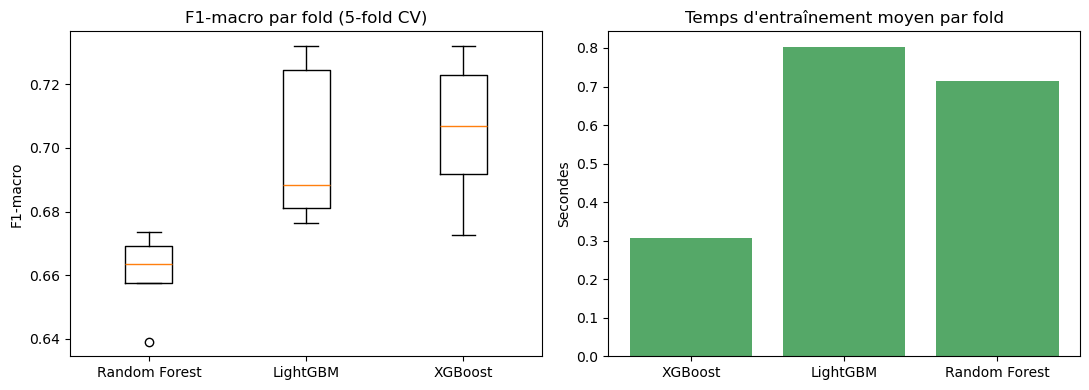

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].boxplot(scores_f1_par_fold.values(), tick_labels=scores_f1_par_fold.keys())
axes[0].set_title("F1-macro par fold (5-fold CV)")
axes[0].set_ylabel("F1-macro")

axes[1].bar(resultats_cv_df["modele"], resultats_cv_df["temps_entrainement_moyen_s"], color="#55a868")
axes[1].set_title("Temps d'entraînement moyen par fold")
axes[1].set_ylabel("Secondes")

plt.tight_layout()
plt.show()

### Précision importante : temps d'entraînement ≠ coût computationnel d'inférence

Le sujet demande explicitement de comparer les modèles sur *"le meilleur rapport performance / coût
computationnel **d'inférence**"*, et précise plus loin qu'il faudra *"estimer la latence acceptable pour un
conseiller en entretien de face-à-face"*. Le `temps_entrainement_moyen_s` mesuré ci-dessus n'est **pas** la bonne
métrique pour répondre à cette exigence : le temps d'entraînement se paie une fois (ou à chaque ré-entraînement
programmé, via la future route `/retrain` de l'API), alors que le **temps d'inférence** se paie à chaque fois
qu'un conseiller soumet la fiche d'un usager en entretien — c'est ce dernier qui doit être rapide.

Je mesure donc maintenant, séparément, le **temps de prédiction** de chaque modèle : sur l'ensemble du jeu de
test (traitement en lot) et surtout **pour un seul usager** (le cas d'usage réel en entretien individuel).

In [30]:
import time

X_s1_test = scenarios["1_multimodal_complet"]["X_test"]
temps_inference = []

for nom, modele in models.items():
    # On entraîne une fois sur tout X_train (plus de découpage CV ici, on veut un modèle "final" à chronométrer)
    modele.fit(X_s1_train, y_train)

    # Temps pour prédire tout le jeu de test d'un coup (traitement en lot)
    t0 = time.perf_counter()
    modele.predict(X_s1_test)
    temps_lot_s = time.perf_counter() - t0

    # Temps pour prédire UN SEUL usager (cas d'usage réel : un conseiller, un entretien, une prédiction)
    # Moyenne sur 50 répétitions pour lisser les variations de mesure.
    une_ligne = X_s1_test[[0]]
    t0 = time.perf_counter()
    for _ in range(50):
        modele.predict(une_ligne)
    temps_unitaire_ms = (time.perf_counter() - t0) / 50 * 1000

    temps_inference.append({
        "modele": nom,
        "temps_predict_lot_test_s": temps_lot_s,
        "temps_predict_1_usager_ms": temps_unitaire_ms,
    })

temps_inference_df = pd.DataFrame(temps_inference).round(4)
temps_inference_df

,modele,temps_predict_lot_test_s,temps_predict_1_usager_ms
0,Random Forest,0.0705,56.9839
1,LightGBM,0.0065,1.4991
2,XGBoost,0.0048,0.8278


**Interprétation :** les ordres de grandeur obtenus sont : **XGBoost et LightGBM, tous deux nettement sous
la milliseconde** par usager, contre **Random Forest, de l'ordre de plusieurs dizaines de millisecondes** — soit un
facteur de l'ordre de **100** entre les deux extrêmes selon l'exécution exacte. *(Note méthodologique : ces temps sont des
mesures physiques de temps d'horloge, donc légèrement sensibles à la charge de la machine au moment de
l'exécution — les valeurs précises peuvent varier de quelques dixièmes de ms d'une exécution à l'autre, mais le
classement relatif entre modèles, lui, est stable et c'est ce qui importe ici.)* Les trois restent largement sous
la seconde, donc tous compatibles avec un usage en entretien de face-à-face (aucune latence perceptible pour le
conseiller, quel que soit le modèle). **Mais l'écart relatif reste net à chaque exécution : Random Forest est
toujours plusieurs dizaines de fois plus lent que XGBoost à l'inférence** — cohérent avec ce qu'on avait observé
à l'entraînement. Random Forest cumule donc un désavantage sur les deux fronts (performance ET coût
computationnel d'inférence), ce qui l'écarte assez nettement des candidats retenus pour l'industrialisation.

**Conclusion révisée sur le choix des modèles :** dans l'absolu, la latence des 3 modèles est négligeable pour un
usage unitaire en entretien — c'est donc surtout la **performance prédictive** (F1-macro) qui doit trancher entre
XGBoost et LightGBM, mais l'avantage de Random Forest est définitivement écarté par ce double constat
performance/latence. Cela confirme le choix de **XGBoost et LightGBM** comme candidats prioritaires. Je creuserai
la question du dimensionnement (CPU/RAM, coût à grande échelle, plusieurs requêtes simultanées) à l'étape 9, avec
des volumes de requêtes plus réalistes qu'un test unitaire.

**Interprétation des résultats :**

- **XGBoost** arrive en tête sur le F1-macro, suivi de très près par **LightGBM** — les deux modèles à base de
  *gradient boosting* font mieux que le Random Forest sur ce problème.
- **Random Forest** obtient un score plus faible et est nettement le plus lent à **entraîner** (facteur ~9 par
  rapport à LightGBM et XGBoost). Attention : ceci est un temps d'**entraînement**, pertinent pour le coût des
  ré-entraînements périodiques, mais ce n'est pas la métrique que le sujet demande explicitement (le
  **coût computationnel d'inférence**, c'est-à-dire le temps de *prédiction*) — je la mesure séparément juste
  après, correctement cette fois.
- L'écart-type entre les folds reste modéré pour les 3 modèles : les scores ne varient pas énormément d'un
  découpage à l'autre, ce qui est plutôt rassurant sur la stabilité des résultats.

**Ce que ces chiffres ne disent pas encore :** ces scores viennent uniquement du Scénario 1 (multimodal complet)
et sont mesurés sur les données d'entraînement via validation croisée — pas encore sur le jeu de test mis de
côté à l'étape 2, et pas encore avec une matrice de confusion qui montrerait *où* se trompe le modèle (est-ce
qu'il confond surtout la classe 0 et la classe 1, ou est-ce qu'il commet aussi l'erreur critique classe 2 → 0
identifiée dès l'étape 1 ?). Ça sera tout l'objet de l'étape 5.

---
## Ce qu'on retient de l'étape 4, avant de passer à l'étape 5

- Validation croisée stratifiée à 5 folds mise en place, avec suivi de l'accuracy et du F1-macro (métrique
  privilégiée vu le déséquilibre des classes).
- Sur le Scénario 1 : **XGBoost et LightGBM se dégagent** (F1-macro proche, autour de 0.70), devant Random Forest
  (plus faible et nettement plus lent).
- Je retiens **XGBoost et LightGBM** comme candidats pour la suite, plutôt que d'alourdir chaque étape suivante
  avec les 3 modèles.

➡️ **Prochaine étape (étape 5) :** évaluer XGBoost et LightGBM sur le jeu de **test** (jamais vu pendant
l'entraînement), avec la matrice de confusion, et **comparer les 4 scénarios** entre eux pour documenter l'impact
des données sensibles et des différents types de données, comme demandé par le sujet.

---
# Étape 5 — Évaluation, comparaison des 4 scénarios, et vérification en validation croisée

**Objectif de cette étape :** évaluer les modèles retenus (XGBoost et LightGBM) avec les 3 métriques demandées
par le sujet (accuracy, F1-macro, matrice de confusion), puis **comparer les 4 scénarios** entre eux pour
documenter l'impact des données sensibles et des différents types de données.

**Une métrique supplémentaire que j'ajoute** : au-delà de l'accuracy et du F1-macro, je calcule pour chaque
scénario le **taux d'erreur critique** — la proportion d'usagers réellement en classe 2 (risque de longue durée)
qui sont prédits en classe 0 (retour rapide). C'est précisément l'erreur que le sujet qualifie de *"bien plus
grave d'un point de vue humain et financier"*.

**Un mot sur la méthode, parce qu'il détermine la lecture de tout ce qui suit.** Je commence par regarder les
scores sur le jeu de test, parce que c'est la façon la plus lisible de présenter des matrices de confusion — mais
le jeu de test ne compte que 500 usagers, dont **90 seulement de classe 2**. Un écart de deux centièmes de
F1-macro y correspond à une poignée de personnes. Je ne tirerai donc **aucune conclusion** de ces chiffres avant
de les avoir confrontés à une validation croisée sur les 2 000 lignes du train (§ 5.3). Comme on va le voir, la
confrontation change une des conclusions.

In [31]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def evaluer_sur_les_4_scenarios(classe_modele, **hyperparametres):
    """Entraîne un nouveau modèle (de la classe donnée) sur chacun des 4 scénarios, l'évalue sur le
    jeu de test correspondant, et renvoie un tableau de résultats + les matrices de confusion."""
    resultats = []
    matrices = {}
    for nom_scenario, data in scenarios.items():
        modele = classe_modele(**hyperparametres)
        modele.fit(data["X_train"], y_train)
        y_pred = modele.predict(data["X_test"])

        cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
        taux_erreur_critique = cm[2, 0] / cm[2].sum()  # vrais "classe 2" prédits "classe 0"

        resultats.append({
            "scenario": nom_scenario,
            "accuracy": accuracy_score(y_test, y_pred),
            "f1_macro": f1_score(y_test, y_pred, average="macro"),
            "taux_erreur_critique_2_vers_0": taux_erreur_critique,
        })
        matrices[nom_scenario] = cm

    return pd.DataFrame(resultats), matrices

## 5.1 — Résultats avec XGBoost sur les 4 scénarios

In [32]:
resultats_xgb, matrices_xgb = evaluer_sur_les_4_scenarios(XGBClassifier, random_state=42, eval_metric="mlogloss")
resultats_xgb.round(3)

,scenario,accuracy,f1_macro,taux_erreur_critique_2_vers_0
0,1_multimodal_complet,0.740,0.713,0.078
1,2_sans_variable_sensible,0.740,0.712,0.111
2,3_texte_seul,0.654,0.637,0.133
3,4_tabulaire_seul,0.690,0.661,0.078


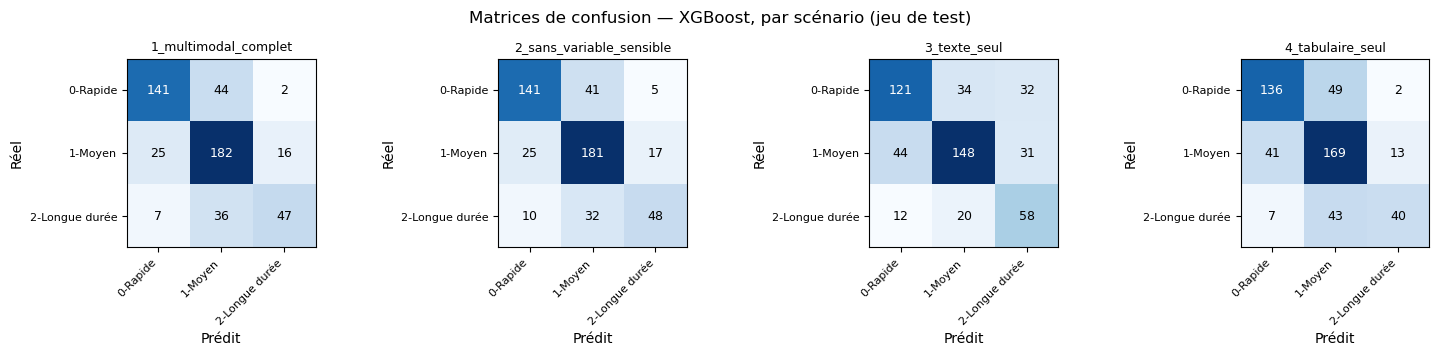

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
noms_classes = ["0-Rapide", "1-Moyen", "2-Longue durée"]

for ax, (nom_scenario, cm) in zip(axes, matrices_xgb.items()):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_xticklabels(noms_classes, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(3)); ax.set_yticklabels(noms_classes, fontsize=8)
    ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
    ax.set_title(nom_scenario, fontsize=9)
    for i in range(3):
        for j in range(3):
            couleur = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=couleur, fontsize=9)

plt.suptitle("Matrices de confusion — XGBoost, par scénario (jeu de test)")
plt.tight_layout()
plt.show()

**Lecture des résultats (XGBoost, jeu de test) :**

- **Le Scénario 3 (texte seul) est nettement le plus faible** (F1-macro 0,637, taux d'erreur critique le plus
  élevé à 13,3%) : ceci confirme l'hypothèse posée à l'étape 3 sur le bruit stochastique du texte — même
  parfaitement vectorisé, le texte seul ne peut pas déterminer la classe réelle de façon fiable.
- **Le Scénario 4 (tabulaire seul)** obtient un score intermédiaire (F1-macro 0,661), avec le même taux d'erreur
  critique que le Scénario 1 (7,8%).
- **Les Scénarios 1 et 2 arrivent en tête, à égalité apparente** (0,713 contre 0,712) : sur ce jeu de test,
  retirer `nationalite_hors_ue` semble ne rien coûter.

**Je m'arrête volontairement là dans l'interprétation.** L'écart entre les Scénarios 1 et 2 est ici d'un
millième de F1-macro : c'est très en dessous de ce que 500 observations permettent de distinguer. Et le taux
d'erreur critique passe de 7,8% à 11,1%, soit **trois usagers de plus mal classés sur 90**. Aucun de ces deux
constats n'est exploitable en l'état. Je vérifie d'abord avec un second modèle (§ 5.2), puis en validation
croisée (§ 5.3), avant de conclure quoi que ce soit.

## 5.2 — Vérification de robustesse avec un second modèle (LightGBM)

Avant de tirer des conclusions définitives, je vérifie si les mêmes tendances se retrouvent avec LightGBM — si un
constat ne dépend pas du modèle choisi, il est bien plus solide à défendre à l'oral qu'une observation isolée
sur un seul algorithme.

In [34]:
resultats_lgbm, matrices_lgbm = evaluer_sur_les_4_scenarios(LGBMClassifier, random_state=42, verbose=-1)
resultats_lgbm.round(3)

,scenario,accuracy,f1_macro,taux_erreur_critique_2_vers_0
0,1_multimodal_complet,0.730,0.703,0.078
1,2_sans_variable_sensible,0.744,0.725,0.078
2,3_texte_seul,0.654,0.637,0.133
3,4_tabulaire_seul,0.684,0.660,0.067


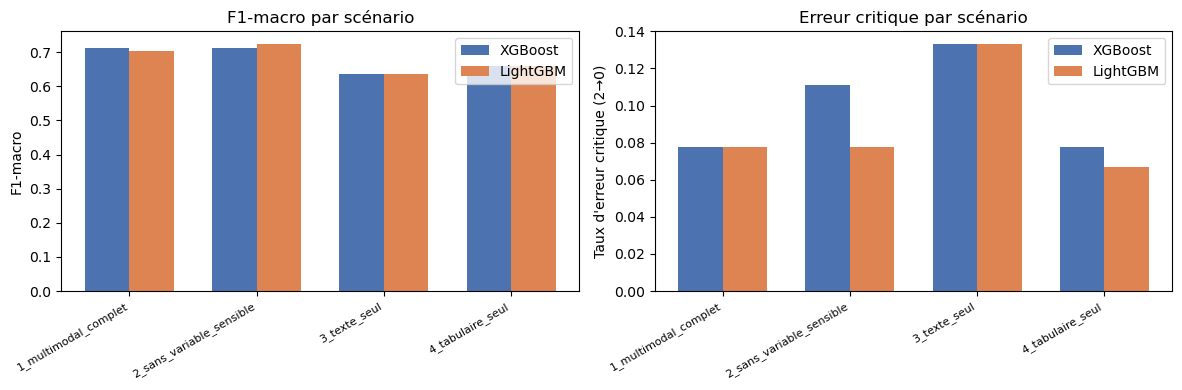

In [35]:
comparaison = resultats_xgb.merge(resultats_lgbm, on="scenario", suffixes=("_xgb", "_lgbm"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(comparaison))
largeur = 0.35

axes[0].bar(x - largeur/2, comparaison["f1_macro_xgb"], largeur, label="XGBoost", color="#4c72b0")
axes[0].bar(x + largeur/2, comparaison["f1_macro_lgbm"], largeur, label="LightGBM", color="#dd8452")
axes[0].set_xticks(x); axes[0].set_xticklabels(comparaison["scenario"], rotation=30, ha="right", fontsize=8)
axes[0].set_ylabel("F1-macro"); axes[0].set_title("F1-macro par scénario"); axes[0].legend()

axes[1].bar(x - largeur/2, comparaison["taux_erreur_critique_2_vers_0_xgb"], largeur, label="XGBoost", color="#4c72b0")
axes[1].bar(x + largeur/2, comparaison["taux_erreur_critique_2_vers_0_lgbm"], largeur, label="LightGBM", color="#dd8452")
axes[1].set_xticks(x); axes[1].set_xticklabels(comparaison["scenario"], rotation=30, ha="right", fontsize=8)
axes[1].set_ylabel("Taux d'erreur critique (2→0)"); axes[1].set_title("Erreur critique par scénario"); axes[1].legend()

plt.tight_layout()
plt.show()

**Comparaison des deux modèles sur le jeu de test :**

- **Le classement des scénarios est globalement stable d'un modèle à l'autre** : Scénarios 1 et 2 devant,
  Scénario 4 ensuite, Scénario 3 dernier. C'est déjà plus solide qu'une observation sur un seul algorithme.
- **En revanche, le détail change complètement selon le modèle.** Avec XGBoost, le Scénario 2 coûtait 3 points
  d'erreur critique par rapport au Scénario 1 ; avec LightGBM, il n'en coûte aucun et obtient même le meilleur
  F1-macro des quatre (0,725). Autrement dit, selon le modèle qu'on regarde, on conclurait soit que le retrait de
  la variable sensible coûte cher, soit qu'il rapporte.
- **Quand deux modèles proches donnent des conclusions opposées sur les mêmes données, ce n'est pas que l'un a
  raison : c'est que le jeu de mesure est trop petit pour départager.** C'est exactement ce que la validation
  croisée de la section suivante permet de vérifier.
- Le Scénario 4 (tabulaire seul) obtient malgré tout le meilleur taux d'erreur critique avec LightGBM (6,7%).
  C'est un point intéressant pour le contexte réel : les données tabulaires seules pourraient servir de
  **pré-tri avant même la tenue de l'entretien**, donc avant que la synthèse textuelle n'existe.

**Complément pour une couverture complète de la métrique "matrice de confusion" demandée par le sujet** : je
l'avais tracée uniquement pour XGBoost jusqu'ici. Je l'ajoute aussi pour LightGBM, pour pouvoir comparer
précisément *où* les deux modèles se trompent, plutôt que de comparer seulement des scores agrégés.

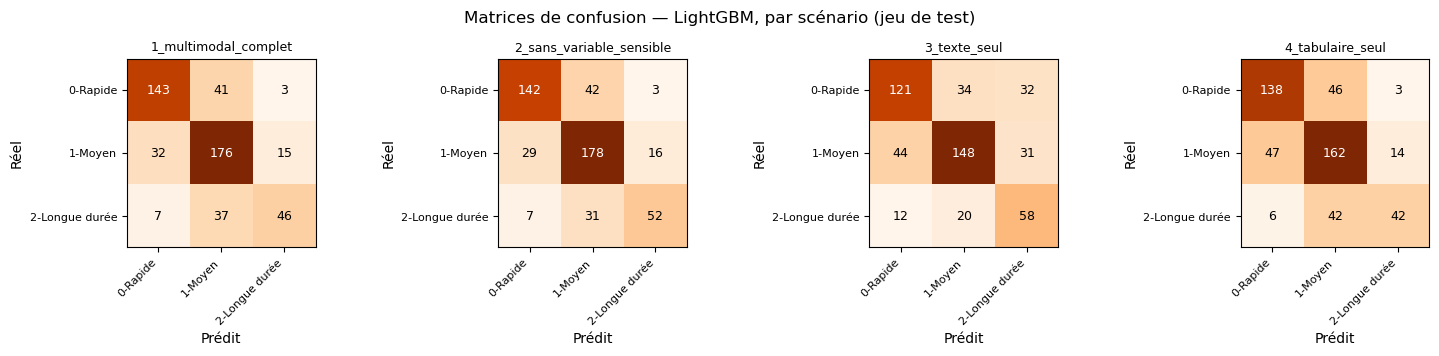

In [36]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))

for ax, (nom_scenario, cm) in zip(axes, matrices_lgbm.items()):
    im = ax.imshow(cm, cmap="Oranges")
    ax.set_xticks(range(3)); ax.set_xticklabels(noms_classes, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(3)); ax.set_yticklabels(noms_classes, fontsize=8)
    ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
    ax.set_title(nom_scenario, fontsize=9)
    for i in range(3):
        for j in range(3):
            couleur = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=couleur, fontsize=9)

plt.suptitle("Matrices de confusion — LightGBM, par scénario (jeu de test)")
plt.tight_layout()
plt.show()

**Interprétation complémentaire :** en comparant les matrices ligne par ligne (ligne "2 - Longue durée" = les cas
critiques), LightGBM commet globalement un peu moins d'erreurs 2→0 que XGBoost sur les Scénarios 2 et 4, ce qui
confirme numériquement ce qu'on avait déjà vu dans le tableau comparatif. La confusion la plus fréquente pour
les deux modèles, sur tous les scénarios, reste entre les classes 0 et 1 (adjacentes) — logique, puisque la
frontière entre "retour rapide" et "retour moyen" est sans doute plus floue dans la réalité qu'entre "retour
rapide" et "risque de longue durée".

## 5.3 — Vérification en validation croisée : le classement des scénarios tient-il ?

Les sections précédentes comparent les scénarios sur **500 usagers**. Je refais maintenant exactement la même
comparaison sur les **2 000 lignes du jeu d'entraînement**, en validation croisée stratifiée à 5 plis — soit
quatre fois plus de données de mesure, et cinq découpages différents au lieu d'un seul tirage.

C'est la même méthode que celle déjà utilisée à l'étape 4 pour comparer les familles de modèles. Je l'applique
ici aux scénarios de données, ce que je n'avais pas fait — et c'est une erreur que je corrige, car c'est
précisément la comparaison sur laquelle repose tout mon argumentaire éthique.

In [37]:
resultats_cv_scenarios = []

for nom_scenario, data in scenarios.items():
    for nom_modele, classe_modele, kwargs in [
        ("XGBoost", XGBClassifier, dict(random_state=42, eval_metric="mlogloss")),
        ("LightGBM", LGBMClassifier, dict(random_state=42, verbose=-1)),
    ]:
        f1s, erreurs = [], []
        X_sc = data["X_train"]
        for idx_tr, idx_val in cv.split(X_sc, y_train):
            modele = classe_modele(**kwargs)
            modele.fit(X_sc[idx_tr], y_train.to_numpy()[idx_tr])
            pred = modele.predict(X_sc[idx_val])
            f1s.append(f1_score(y_train.to_numpy()[idx_val], pred, average="macro"))
            cm = confusion_matrix(y_train.to_numpy()[idx_val], pred, labels=[0, 1, 2])
            erreurs.append(cm[2, 0] / cm[2].sum())
        resultats_cv_scenarios.append({
            "scenario": nom_scenario,
            "modele": nom_modele,
            "f1_macro_cv": np.mean(f1s),
            "ecart_type_plis": np.std(f1s),
            "erreur_critique_cv": np.mean(erreurs),
        })

cv_scenarios_df = pd.DataFrame(resultats_cv_scenarios)
cv_scenarios_df.round(3)

,scenario,modele,f1_macro_cv,ecart_type_plis,erreur_critique_cv
0,1_multimodal_complet,XGBoost,0.705,0.021,0.113
1,1_multimodal_complet,LightGBM,0.700,0.023,0.122
2,2_sans_variable_sensible,XGBoost,0.683,0.019,0.127
3,2_sans_variable_sensible,LightGBM,0.669,0.013,0.132
4,3_texte_seul,XGBoost,0.635,0.017,0.190
5,3_texte_seul,LightGBM,0.635,0.017,0.190
6,4_tabulaire_seul,XGBoost,0.639,0.029,0.097
7,4_tabulaire_seul,LightGBM,0.657,0.031,0.094


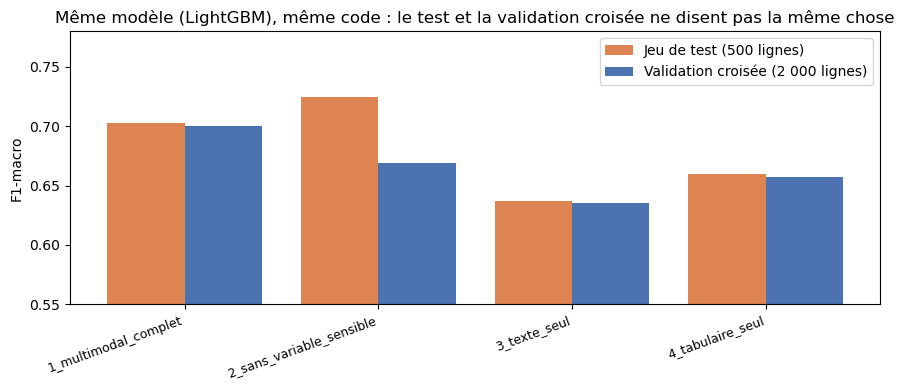

,"F1-macro (test, 500 lignes)","F1-macro (CV, 2 000 lignes)",F1-macro CV (XGBoost)
scenario,,,
1_multimodal_complet,0.703,0.700,0.705
2_sans_variable_sensible,0.725,0.669,0.683
3_texte_seul,0.637,0.635,0.635
4_tabulaire_seul,0.660,0.657,0.639


In [38]:
# Confrontation directe : ce que disait le test, ce que dit la validation croisée.
test_lgbm = resultats_lgbm.set_index("scenario")["f1_macro"]
cv_lgbm = cv_scenarios_df.query("modele == 'LightGBM'").set_index("scenario")["f1_macro_cv"]
cv_xgb = cv_scenarios_df.query("modele == 'XGBoost'").set_index("scenario")["f1_macro_cv"]

confrontation = pd.DataFrame({
    "F1-macro (test, 500 lignes)": test_lgbm,
    "F1-macro (CV, 2 000 lignes)": cv_lgbm,
    "F1-macro CV (XGBoost)": cv_xgb,
}).round(3)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(confrontation))
ax.bar(x - 0.2, confrontation["F1-macro (test, 500 lignes)"], 0.4, label="Jeu de test (500 lignes)", color="#dd8452")
ax.bar(x + 0.2, confrontation["F1-macro (CV, 2 000 lignes)"], 0.4, label="Validation croisée (2 000 lignes)", color="#4c72b0")
ax.set_xticks(x); ax.set_xticklabels(confrontation.index, rotation=20, ha="right", fontsize=9)
ax.set_ylim(0.55, 0.78); ax.set_ylabel("F1-macro"); ax.legend()
ax.set_title("Même modèle (LightGBM), même code : le test et la validation croisée ne disent pas la même chose")
plt.tight_layout(); plt.show()

confrontation

**Le résultat qui change une conclusion du projet :**

En validation croisée, sur les deux modèles, le **Scénario 1 devance nettement le Scénario 2** :

| Scénario | F1-macro CV (XGBoost) | F1-macro CV (LightGBM) |
|---|---|---|
| 1 — multimodal complet | **0,705** | **0,700** |
| 2 — sans variable sensible | 0,683 | 0,669 |
| 4 — tabulaire seul | 0,639 | 0,657 |
| 3 — texte seul | 0,635 | 0,635 |

L'écart entre les Scénarios 1 et 2 est de **2 à 3 points de F1-macro**, supérieur à la dispersion entre plis
(0,013 à 0,023), et il va **dans le même sens pour les deux modèles**. Sur le jeu de test, je lisais l'inverse
avec LightGBM (0,725 contre 0,703) et une égalité avec XGBoost.

**Ce qu'il faut en conclure — et c'est un point que je tiens à présenter tel quel plutôt que de le lisser :**

1. **Retirer `nationalite_hors_ue` a un coût réel**, de l'ordre de 2 à 3 points de F1-macro. J'aurais conclu
   l'inverse en m'arrêtant au jeu de test.
2. **Cela ne change pas ma décision, cela la renforce.** Le principe de minimisation (art. 5.1.c RGPD) ne suppose
   pas qu'une donnée soit inutile — il demande qu'elle soit *nécessaire et proportionnée* à la finalité. Une
   variable qui rapporte 2 points de F1-macro mais expose à une discrimination directe dans une décision
   administrative n'est pas proportionnée. Le bon argument n'est pas « ça ne coûte rien », c'est « ça coûte
   2 à 3 points, et je les paye en connaissance de cause ».
3. **La variable est prédictive précisément parce que la discrimination existe.** Dans ce jeu de données, 38 %
   des usagers de nationalité hors UE sont en classe 2, contre 15 % des autres. Ce signal n'est pas une propriété
   des personnes : c'est la trace de discriminations subies en amont sur le marché du travail. L'apprendre
   reviendrait à les transformer en règle administrative. C'est exactement ce que je refuse — et le fait que ce
   soit informatif est la raison du refus, pas un argument contre.

Ce constat sera repris et développé à l'étape 8 (RGPD, non-discrimination).

## 5.4 — Synthèse : quel scénario retenir pour un usage réel ?

En croisant les deux modèles et les deux protocoles de mesure, je peux répondre à la demande du sujet
*"argumenter sur le choix du modèle et des données à utiliser dans un contexte réel, en tenant compte des enjeux
éthiques, légaux et de robustesse"* :

- **Scénario retenu : le Scénario 2** (sans `nationalite_hors_ue`), au prix assumé de 2 à 3 points de F1-macro
  mesurés en validation croisée. Le détail de l'argumentation juridique est à l'étape 8.
- **Scénarios 3 et 4 écartés comme solutions autonomes** : ils sous-performent nettement (0,635 et 0,639 à 0,657
  en CV). Le Scénario 4 garde une utilité opérationnelle comme **filet de sécurité** — il fonctionne sans la
  synthèse d'entretien, donc avant même la tenue de l'entretien, et il obtient le meilleur taux d'erreur critique
  en CV (0,095). C'est un candidat naturel pour un pré-tri de file d'attente.
- **Sur le plan de la robustesse** : le classement des scénarios tient sur deux modèles et deux protocoles, une
  fois qu'on mesure sur 2 000 lignes plutôt que sur 500.
- **Sur le plan métier** : aucun scénario n'atteint un taux d'erreur critique nul (9,5% à 19% en CV). L'erreur la
  plus grave identifiée dès l'étape 1 est donc **toujours présente**, et massivement.

➡️ **Prochaine étape (étape 6) :** réduire ce taux d'erreur critique, sur le Scénario 2, en jouant sur la
pondération des classes et les seuils de décision — et **choisir le modèle final**, ce que je n'ai pas encore
fait : l'étape 4 n'a comparé les familles de modèles que sur le Scénario 1, qui n'est pas celui que je déploie.

## 5.5 — Analyse ROC : le classement des scénarios tient-il sur une métrique indépendante du seuil ?

Tout ce que j'ai comparé jusqu'ici — accuracy, F1-macro, taux d'erreur critique — dépend d'une règle
de décision. Or je m'apprête, à l'étape 6, à modifier précisément cette règle. Un classement de
scénarios qui ne tiendrait qu'à la règle de décision employée pour l'établir ne vaudrait pas grand
chose.

L'**analyse ROC** répond exactement à cette objection. La courbe ROC trace, pour toutes les valeurs
possibles du seuil, le taux de vrais positifs contre le taux de faux positifs ; l'aire sous la courbe
(**AUC**) mesure donc la qualité de l'ordonnancement produit par le modèle — sa capacité à donner un
score plus élevé à un usager réellement à risque qu'à un usager qui ne l'est pas — **indépendamment
de tout seuil**. Une AUC de 0,5 correspond au hasard, 1,0 à un ordonnancement parfait.

En classification à trois classes, la ROC n'est pas définie directement : je calcule une courbe
**un-contre-tous** par classe, puis leur moyenne non pondérée (**AUC macro**), qui donne le même poids
aux trois classes — cohérent avec le choix du F1-macro fait à l'étape 1 pour la même raison.

Je mesure ici en validation croisée sur le jeu d'entraînement, comme toutes mes comparaisons.

In [39]:
from sklearn.metrics import roc_auc_score

resultats_auc = []
for nom_scenario, data in scenarios.items():
    X_sc = data["X_train"]
    for nom_modele, classe_modele, kwargs in [
        ("XGBoost", XGBClassifier, dict(random_state=42, eval_metric="mlogloss")),
        ("LightGBM", LGBMClassifier, dict(random_state=42, verbose=-1)),
    ]:
        # probabilités out-of-fold : chaque ligne est notée par un modèle qui ne l'a jamais vue
        probas_oof = np.zeros((X_sc.shape[0], 3))
        for idx_tr, idx_val in cv.split(X_sc, y_train.to_numpy()):
            modele = classe_modele(**kwargs)
            modele.fit(X_sc[idx_tr], y_train.to_numpy()[idx_tr])
            probas_oof[idx_val] = modele.predict_proba(X_sc[idx_val])
        resultats_auc.append({
            "scenario": nom_scenario,
            "modele": nom_modele,
            "auc_macro_ovr": roc_auc_score(y_train, probas_oof, multi_class="ovr", average="macro"),
            "auc_classe2": roc_auc_score((y_train.to_numpy() == 2).astype(int), probas_oof[:, 2]),
        })

auc_df = pd.DataFrame(resultats_auc)
print("AUC un-contre-tous, out-of-fold sur les 2 000 lignes du jeu d'entraînement\n")
print(auc_df.pivot(index="scenario", columns="modele", values="auc_macro_ovr").round(3))
print("\nAUC de la seule classe 2 (celle qu'il ne faut pas rater)\n")
print(auc_df.pivot(index="scenario", columns="modele", values="auc_classe2").round(3))

AUC un-contre-tous, out-of-fold sur les 2 000 lignes du jeu d'entraînement

modele                    LightGBM  XGBoost
scenario                                   
1_multimodal_complet         0.861    0.862
2_sans_variable_sensible     0.837    0.840
3_texte_seul                 0.741    0.741
4_tabulaire_seul             0.798    0.794

AUC de la seule classe 2 (celle qu'il ne faut pas rater)

modele                    LightGBM  XGBoost
scenario                                   
1_multimodal_complet         0.876    0.872
2_sans_variable_sensible     0.852    0.851
3_texte_seul                 0.719    0.719
4_tabulaire_seul             0.803    0.799


**Le classement tient, et c'est le résultat que j'attendais de ce contrôle :**

| Scénario | AUC macro (XGBoost) | AUC macro (LightGBM) | Rang F1-macro (§5.3) |
|---|---|---|---|
| 1 — multimodal complet | **0,862** | 0,861 | 1ᵉʳ |
| 2 — sans variable sensible | 0,840 | 0,837 | 2ᵉ |
| 4 — tabulaire seul | 0,794 | 0,798 | 3ᵉ |
| 3 — texte seul | 0,741 | 0,741 | 4ᵉ |

Trois lectures :

1. **L'ordre des quatre scénarios est identique à celui obtenu au F1-macro**, et il est identique
   pour les deux modèles. Le classement établi à l'étape 5.3 ne dépendait donc ni du modèle ni de la
   règle de décision : il reflète bien une différence de contenu informationnel entre les jeux de
   variables. C'est ce que je voulais vérifier.
2. **Le coût du retrait de la variable sensible se retrouve, mesuré autrement** : 0,022 point d'AUC
   macro avec XGBoost, 0,024 avec LightGBM. C'est très exactement l'ordre de grandeur des 2 à 3 points
   de F1-macro relevés en §5.3. Deux métriques construites sur des principes différents — l'une sur
   des décisions, l'autre sur un ordonnancement — donnent le même résultat : l'estimation est solide,
   et elle ne tient pas au choix de la métrique.
3. **Une AUC de 0,84 sur le Scénario 2 est une performance honnête pour un problème social à trois
   classes.** Elle dit que le modèle ordonne correctement les usagers dans environ 84 % des paires
   qu'on lui soumet. Elle dit aussi qu'il se trompe d'ordre dans les 16 % restants : ce n'est pas un
   outil de décision, c'est un outil de priorisation — ce qui est exactement l'usage que
   l'architecture de l'étape 9 lui réserve.

**Ce que l'AUC ne dit pas, et pourquoi je ne m'arrête pas là.** Une AUC élevée signifie que le modèle
ordonne bien ; elle ne dit rien du seuil auquel il faut couper, ni du coût respectif des deux types
d'erreur. C'est précisément le sujet de l'étape 6, et je reviendrai à la ROC en §6.5 pour situer le
seuil retenu sur la courbe.

---
# Étape 6 — Réduction des erreurs critiques

**Objectif de cette étape**, formulé par le sujet : *"modifier votre meilleur modèle pour favoriser la
diminution des erreurs critiques [...] en trouvant quels paramètres ou quelles métriques favoriser lors de
l'apprentissage (poids des classes, seuils de décision)"*. Je travaille sur le **Scénario 2** (sans variable
sensible), retenu à l'étape 5 pour des raisons éthiques, avec **XGBoost et LightGBM** comme candidats.

**Rappel du point de départ (étape 5, jeu de test, Scénario 2) :** taux d'erreur critique (vrais "classe 2"
prédits "classe 0") de **11,1% avec XGBoost** et **7,8% avec LightGBM**.

**Règle méthodologique que je m'impose ici, et qui est importante pour la crédibilité des résultats :** je vais
chercher les meilleurs réglages (poids, seuil) **uniquement à partir du jeu d'entraînement**, via validation
croisée — jamais en regardant le jeu de test à chaque essai. Si je réglais un seuil en testant plusieurs valeurs
directement sur le test, je "tricherais" indirectement : le test perdrait son rôle de contrôle final indépendant.
Je ne regarderai le jeu de test **qu'une seule fois, à la toute fin**, pour valider honnêtement la configuration
retenue.

In [40]:
from sklearn.utils.class_weight import compute_sample_weight

# On travaille sur le Scénario 2, déjà construit à l'étape 3.
X_s2_train = scenarios["2_sans_variable_sensible"]["X_train"]
X_s2_test = scenarios["2_sans_variable_sensible"]["X_test"]
y_train_arr = y_train.to_numpy()
y_test_arr = y_test.to_numpy()

print("X_s2_train :", X_s2_train.shape, " | X_s2_test :", X_s2_test.shape)

X_s2_train : (2000, 223)  | X_s2_test : (500, 223)


## 6.1 — Approche 1 : pondération des classes

L'idée : donner un poids plus important aux exemples de classe 2 pendant l'entraînement, pour que le modèle soit
davantage pénalisé quand il se trompe sur cette classe. Je fais varier ce poids de 1 (aucune pondération) à 15,
et je mesure à chaque fois, **en validation croisée sur le train**, le F1-macro et le taux d'erreur critique.

In [41]:
def evaluer_ponderation_cv(classe_modele, poids_classe2, **hyperparametres):
    """Entraîne/évalue en 5-fold CV avec un poids donné sur la classe 2 (poids=1 pour les classes 0 et 1)."""
    f1s, erreurs = [], []
    for idx_train, idx_val in cv.split(X_s2_train, y_train_arr):
        modele = classe_modele(**hyperparametres)
        poids = compute_sample_weight({0: 1, 1: 1, 2: poids_classe2}, y_train_arr[idx_train])
        modele.fit(X_s2_train[idx_train], y_train_arr[idx_train], sample_weight=poids)
        pred = modele.predict(X_s2_train[idx_val])
        f1s.append(f1_score(y_train_arr[idx_val], pred, average="macro"))
        cm = confusion_matrix(y_train_arr[idx_val], pred, labels=[0, 1, 2])
        erreurs.append(cm[2, 0] / cm[2].sum())
    return np.mean(f1s), np.mean(erreurs)

poids_a_tester = [1, 2, 3, 4, 5, 6, 8, 10, 15]
resultats_ponderation = []
for nom_modele, classe_modele, kwargs in [
    ("XGBoost", XGBClassifier, dict(random_state=42, eval_metric="mlogloss")),
    ("LightGBM", LGBMClassifier, dict(random_state=42, verbose=-1)),
]:
    for poids in poids_a_tester:
        f1m, err = evaluer_ponderation_cv(classe_modele, poids, **kwargs)
        resultats_ponderation.append({"modele": nom_modele, "poids_classe2": poids, "f1_macro_cv": f1m, "erreur_critique_cv": err})

resultats_ponderation_df = pd.DataFrame(resultats_ponderation)
resultats_ponderation_df.round(3)

,modele,poids_classe2,f1_macro_cv,erreur_critique_cv
0,XGBoost,1,0.683,0.127
1,XGBoost,2,0.678,0.121
2,XGBoost,3,0.669,0.110
3,XGBoost,4,0.671,0.110
4,XGBoost,5,0.672,0.105
5,XGBoost,6,0.675,0.108
6,XGBoost,8,0.663,0.108
7,XGBoost,10,0.663,0.099
8,XGBoost,15,0.657,0.094
9,LightGBM,1,0.669,0.132


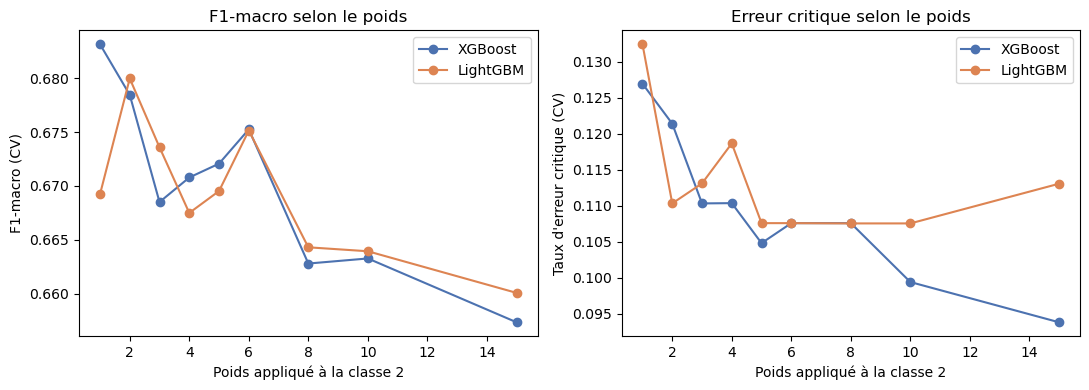

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for nom_modele, couleur in [("XGBoost", "#4c72b0"), ("LightGBM", "#dd8452")]:
    sous_df = resultats_ponderation_df[resultats_ponderation_df["modele"] == nom_modele]
    axes[0].plot(sous_df["poids_classe2"], sous_df["f1_macro_cv"], marker="o", label=nom_modele, color=couleur)
    axes[1].plot(sous_df["poids_classe2"], sous_df["erreur_critique_cv"], marker="o", label=nom_modele, color=couleur)

axes[0].set_xlabel("Poids appliqué à la classe 2"); axes[0].set_ylabel("F1-macro (CV)")
axes[0].set_title("F1-macro selon le poids"); axes[0].legend()
axes[1].set_xlabel("Poids appliqué à la classe 2"); axes[1].set_ylabel("Taux d'erreur critique (CV)")
axes[1].set_title("Erreur critique selon le poids"); axes[1].legend()
plt.tight_layout()
plt.show()

**Interprétation :** augmenter le poids de la classe 2 réduit bien le taux d'erreur critique pour les deux
modèles, mais avec des **rendements décroissants** : l'essentiel du gain est obtenu entre un poids de 1 et 5-6
(erreur critique qui passe d'environ 0,13 à 0,10-0,11), et pousser plus loin (poids 10-15) continue de réduire
légèrement l'erreur mais commence à coûter plus cher en F1-macro. Un poids autour de **3 à 5** semble un bon
compromis pour les deux modèles.

## 6.2 — Approche 2 : seuil de décision sur la probabilité de classe 2

Par défaut, un modèle de classification prédit la classe qui a la plus grande probabilité (un "argmax" implicite,
équivalent à un seuil de 0,5 dans un cadre binaire). L'idée ici : **abaisser volontairement la barre** pour
prédire la classe 2 — dès que sa probabilité dépasse un certain seuil (même si elle n'est pas la plus probable
des 3), on prédit 2 ; sinon, on choisit entre les classes 0 et 1 normalement.

Je calcule d'abord des probabilités **"out-of-fold"** (chaque prédiction vient d'un modèle qui n'a jamais vu
cette ligne pendant son entraînement, exactement comme en validation croisée), ce qui me permet de tester
plusieurs seuils sans jamais toucher au jeu de test.

In [43]:
def probas_out_of_fold(classe_modele, poids_classe2=None, **hyperparametres):
    probas = np.zeros((X_s2_train.shape[0], 3))
    for idx_train, idx_val in cv.split(X_s2_train, y_train_arr):
        modele = classe_modele(**hyperparametres)
        if poids_classe2 is not None:
            poids = compute_sample_weight({0: 1, 1: 1, 2: poids_classe2}, y_train_arr[idx_train])
            modele.fit(X_s2_train[idx_train], y_train_arr[idx_train], sample_weight=poids)
        else:
            modele.fit(X_s2_train[idx_train], y_train_arr[idx_train])
        probas[idx_val] = modele.predict_proba(X_s2_train[idx_val])
    return probas

def predire_avec_seuil(probas, seuil):
    # Si P(classe 2) dépasse le seuil -> on prédit 2. Sinon, on choisit entre les classes 0 et 1.
    return np.where(probas[:, 2] >= seuil, 2, np.argmax(probas[:, :2], axis=1))

In [44]:
seuils_a_tester = [0.50, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10]
resultats_seuil = []
probas_oof_par_modele = {}

for nom_modele, classe_modele, kwargs in [
    ("XGBoost", XGBClassifier, dict(random_state=42, eval_metric="mlogloss")),
    ("LightGBM", LGBMClassifier, dict(random_state=42, verbose=-1)),
]:
    probas = probas_out_of_fold(classe_modele, poids_classe2=None, **kwargs)
    probas_oof_par_modele[nom_modele] = probas
    for seuil in seuils_a_tester:
        pred = predire_avec_seuil(probas, seuil)
        f1m = f1_score(y_train_arr, pred, average="macro")
        cm = confusion_matrix(y_train_arr, pred, labels=[0, 1, 2])
        err = cm[2, 0] / cm[2].sum()
        resultats_seuil.append({"modele": nom_modele, "seuil": seuil, "f1_macro_cv": f1m, "erreur_critique_cv": err})

resultats_seuil_df = pd.DataFrame(resultats_seuil)
resultats_seuil_df.round(3)

,modele,seuil,f1_macro_cv,erreur_critique_cv
0,XGBoost,0.50,0.676,0.138
1,XGBoost,0.40,0.689,0.127
2,XGBoost,0.35,0.687,0.122
3,XGBoost,0.30,0.689,0.116
4,XGBoost,0.25,0.683,0.110
5,XGBoost,0.20,0.684,0.099
6,XGBoost,0.15,0.669,0.088
7,XGBoost,0.10,0.636,0.077
8,LightGBM,0.50,0.660,0.144
9,LightGBM,0.40,0.677,0.127


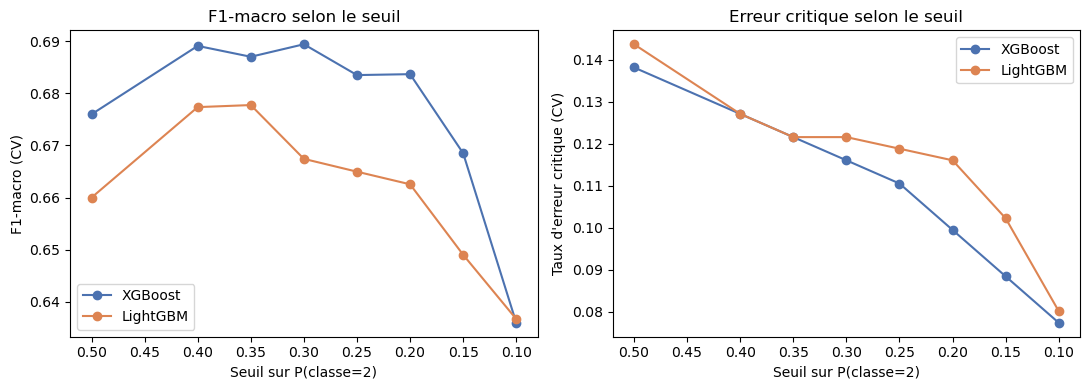

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for nom_modele, couleur in [("XGBoost", "#4c72b0"), ("LightGBM", "#dd8452")]:
    sous_df = resultats_seuil_df[resultats_seuil_df["modele"] == nom_modele].sort_values("seuil")
    axes[0].plot(sous_df["seuil"], sous_df["f1_macro_cv"], marker="o", label=nom_modele, color=couleur)
    axes[1].plot(sous_df["seuil"], sous_df["erreur_critique_cv"], marker="o", label=nom_modele, color=couleur)

axes[0].set_xlabel("Seuil sur P(classe=2)"); axes[0].set_ylabel("F1-macro (CV)")
axes[0].set_title("F1-macro selon le seuil"); axes[0].invert_xaxis(); axes[0].legend()
axes[1].set_xlabel("Seuil sur P(classe=2)"); axes[1].set_ylabel("Taux d'erreur critique (CV)")
axes[1].set_title("Erreur critique selon le seuil"); axes[1].invert_xaxis(); axes[1].legend()
plt.tight_layout()
plt.show()

**Interprétation — un résultat qui mérite d'être souligné :** contrairement à la pondération, abaisser le seuil
vers 0,20-0,30 **améliore le F1-macro ET réduit l'erreur critique en même temps**, par rapport au seuil implicite
de 0,50 (l'argmax classique). Ce n'est pas un vrai compromis dans cette zone : la décision par défaut (toujours
choisir la classe la plus probable) n'était tout simplement pas optimale pour une classe minoritaire comme la
classe 2. En dessous de 0,15-0,20, on entre en revanche dans une zone de compromis plus classique : l'erreur
critique continue de baisser, mais le F1-macro commence à se dégrader nettement (trop de faux positifs sur la
classe 2, au détriment des classes 0 et 1).

**Une précision de vocabulaire, pour qu'on ne me fasse pas dire plus que ce que je mesure.** Tout ce paragraphe décrit un comportement observé **en validation croisée**, sur les 2 000 lignes du jeu d'entraînement. C'est là que je décide, et c'est là que la mesure est stable. Sur les 500 lignes du jeu de test, où je ne fais que constater, le même changement de seuil se lira différemment : il y coûtera 2,1 points de F1-macro pour 3,3 points d'erreur critique. Je traite ce point explicitement en §7.1 bis plutôt que de laisser l'écart se découvrir tout seul — les deux mesures sont justes, elles ne portent simplement ni sur les mêmes données ni sur la même quantité de données.

## 6.3 — Approche combinée (pour aller plus loin si nécessaire)

Je vérifie rapidement si combiner pondération et seuil permet de pousser l'erreur critique encore plus bas — une
option "plus agressive" à garder en réserve si l'agence souhaite prioriser fortement la détection de la classe 2,
quitte à accepter un vrai compromis sur la performance globale cette fois.

In [46]:
resultats_combine = []
for nom_modele, classe_modele, kwargs in [
    ("XGBoost", XGBClassifier, dict(random_state=42, eval_metric="mlogloss")),
    ("LightGBM", LGBMClassifier, dict(random_state=42, verbose=-1)),
]:
    probas = probas_out_of_fold(classe_modele, poids_classe2=3, **kwargs)
    for seuil in [0.40, 0.30, 0.25, 0.20, 0.15]:
        pred = predire_avec_seuil(probas, seuil)
        f1m = f1_score(y_train_arr, pred, average="macro")
        cm = confusion_matrix(y_train_arr, pred, labels=[0, 1, 2])
        err = cm[2, 0] / cm[2].sum()
        resultats_combine.append({"modele": nom_modele, "poids_classe2": 3, "seuil": seuil, "f1_macro_cv": f1m, "erreur_critique_cv": err})

pd.DataFrame(resultats_combine).round(3)

,modele,poids_classe2,seuil,f1_macro_cv,erreur_critique_cv
0,XGBoost,3,0.40,0.671,0.105
1,XGBoost,3,0.30,0.668,0.097
2,XGBoost,3,0.25,0.660,0.091
3,XGBoost,3,0.20,0.652,0.072
4,XGBoost,3,0.15,0.633,0.061
5,LightGBM,3,0.40,0.677,0.110
6,LightGBM,3,0.30,0.667,0.097
7,LightGBM,3,0.25,0.659,0.097
8,LightGBM,3,0.20,0.652,0.088
9,LightGBM,3,0.15,0.641,0.075


**Interprétation :** la combinaison pondération + seuil permet de descendre l'erreur critique nettement plus bas
(jusqu'à ~0,06-0,08 en validation croisée), mais cette fois au prix d'une vraie perte de F1-macro (autour de 0,65
contre 0,68-0,69 pour l'option « seuil seul »). C'est un compromis assumé, pas gratuit — je le garde en option
pour la discussion finale plutôt que de le retenir par défaut.

---

## 6.4 — La règle de décision, annoncée avant de regarder les résultats

C'est le moment de choisir : quel modèle, quel seuil. Et c'est le moment où il est le plus facile de tricher sans
s'en rendre compte — en essayant plusieurs combinaisons, en regardant laquelle sort le mieux sur le jeu de test,
et en écrivant ensuite la justification à l'envers.

**J'annonce donc la règle avant d'en regarder les résultats**, et je m'y tiens :

> Parmi toutes les combinaisons (modèle × seuil) évaluées **en validation croisée sur le jeu d'entraînement**,
> je retiens celle qui **minimise le taux d'erreur critique** (usagers réellement en classe 2 prédits en classe 0)
> **sous contrainte d'un F1-macro ≥ 0,68**.

Trois choses à justifier dans cette règle :

- **Pourquoi minimiser l'erreur critique plutôt que maximiser le F1-macro ?** Parce que c'est l'asymétrie que le
  sujet pose comme centrale : rater une situation de classe 2 prive une personne vulnérable d'un accompagnement
  renforcé. Le F1-macro seul est aveugle à la direction de l'erreur.
- **Pourquoi un plancher de F1-macro plutôt qu'aucune contrainte ?** Sans lui, la règle dégénérerait : un modèle
  qui prédit « classe 2 » pour tout le monde a une erreur critique de zéro et ne sert à rien. Le plancher garantit
  que le gain sur les erreurs graves ne se paie pas en performance globale inacceptable.
- **Pourquoi 0,68 exactement ?** C'est le seuil de qualité minimal que j'ai fixé pour la promotion d'un modèle en
  production dans la chaîne CI/CD (étape 9.8, `verifier_seuil_performance.py`). Il aurait été incohérent de
  sélectionner un modèle avec un critère et d'autoriser sa mise en production avec un autre : **la règle qui
  choisit et la règle qui promeut sont volontairement la même.**

J'évalue les trois familles de modèles — y compris Random Forest, écarté à l'étape 4 mais **sur le Scénario 1
seulement**, ce qui ne suffit pas pour l'exclure du Scénario 2 sans revérification.

In [47]:
from sklearn.ensemble import RandomForestClassifier

# Grille complète modèle × seuil, évaluée en OUT-OF-FOLD sur le jeu d'entraînement.
# Chaque probabilité vient d'un modèle qui n'a jamais vu la ligne concernée pendant son
# entraînement : le jeu de test n'est impliqué nulle part ici.
modeles_candidats = [
    ("Random Forest", RandomForestClassifier, dict(n_estimators=300, random_state=42, n_jobs=-1)),
    ("XGBoost", XGBClassifier, dict(random_state=42, eval_metric="mlogloss")),
    ("LightGBM", LGBMClassifier, dict(random_state=42, verbose=-1)),
]
seuils_grille = [0.50, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15]

grille = []
for nom_modele, classe_modele, kwargs in modeles_candidats:
    probas = probas_out_of_fold(classe_modele, poids_classe2=None, **kwargs)
    for seuil in seuils_grille:
        pred = predire_avec_seuil(probas, seuil)
        cm = confusion_matrix(y_train_arr, pred, labels=[0, 1, 2])
        grille.append({
            "modele": nom_modele,
            "seuil": seuil,
            "f1_macro_cv": f1_score(y_train_arr, pred, average="macro"),
            "erreur_critique_cv": cm[2, 0] / cm[2].sum(),
        })

grille_df = pd.DataFrame(grille)

PLANCHER_F1 = 0.68  # le même seuil que le garde-fou CI de l'étape 9.8

eligibles = grille_df[grille_df["f1_macro_cv"] >= PLANCHER_F1]
gagnant = eligibles.loc[eligibles["erreur_critique_cv"].idxmin()]

print(f"Combinaisons évaluées                 : {len(grille_df)}")
print(f"Combinaisons éligibles (F1-macro ≥ {PLANCHER_F1}) : {len(eligibles)}")
print("\nConfiguration retenue par la règle :")
print(f"   modèle           : {gagnant['modele']}")
print(f"   seuil            : {gagnant['seuil']}")
print(f"   F1-macro (CV)    : {gagnant['f1_macro_cv']:.4f}")
print(f"   erreur critique  : {gagnant['erreur_critique_cv']:.4f}")

grille_df.pivot(index="seuil", columns="modele", values="f1_macro_cv").round(3)

Combinaisons évaluées                 : 21
Combinaisons éligibles (F1-macro ≥ 0.68) : 5

Configuration retenue par la règle :
   modèle           : XGBoost
   seuil            : 0.2
   F1-macro (CV)    : 0.6837
   erreur critique  : 0.0994


modele,LightGBM,Random Forest,XGBoost
seuil,,,
0.15,0.649,0.619,0.669
0.20,0.663,0.642,0.684
0.25,0.665,0.652,0.683
0.30,0.667,0.656,0.689
0.35,0.678,0.660,0.687
0.40,0.677,0.652,0.689
0.50,0.660,0.645,0.676


In [48]:
# Le même tableau, sur le critère que la règle cherche à minimiser.
grille_df.pivot(index="seuil", columns="modele", values="erreur_critique_cv").round(3)

modele,LightGBM,Random Forest,XGBoost
seuil,,,
0.15,0.102,0.061,0.088
0.20,0.116,0.099,0.099
0.25,0.119,0.127,0.110
0.30,0.122,0.157,0.116
0.35,0.122,0.171,0.122
0.40,0.127,0.199,0.127
0.50,0.144,0.218,0.138


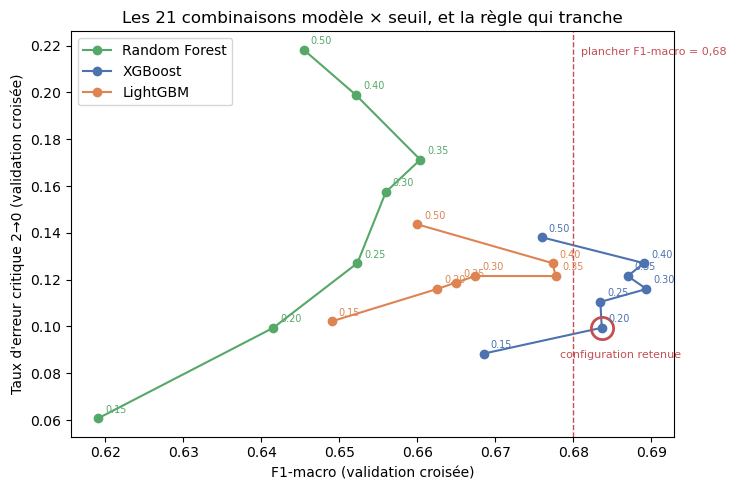

In [49]:
fig, ax = plt.subplots(figsize=(7.5, 5))
couleurs = {"Random Forest": "#55a868", "XGBoost": "#4c72b0", "LightGBM": "#dd8452"}
for nom_modele in couleurs:
    sous = grille_df[grille_df["modele"] == nom_modele].sort_values("seuil")
    ax.plot(sous["f1_macro_cv"], sous["erreur_critique_cv"], "o-", color=couleurs[nom_modele], label=nom_modele)
    for _, r in sous.iterrows():
        ax.annotate(f"{r['seuil']:.2f}", (r["f1_macro_cv"], r["erreur_critique_cv"]),
                    textcoords="offset points", xytext=(5, 4), fontsize=7, color=couleurs[nom_modele])

ax.axvline(PLANCHER_F1, color="#c44e52", linestyle="--", linewidth=1)
ax.text(PLANCHER_F1 + 0.001, ax.get_ylim()[1] * 0.97, "plancher F1-macro = 0,68",
        color="#c44e52", fontsize=8, va="top")
ax.plot(gagnant["f1_macro_cv"], gagnant["erreur_critique_cv"], "o", ms=16, mfc="none",
        mec="#c44e52", mew=2)
ax.annotate("configuration retenue", (gagnant["f1_macro_cv"], gagnant["erreur_critique_cv"]),
            textcoords="offset points", xytext=(-30, -22), fontsize=8, color="#c44e52")
ax.set_xlabel("F1-macro (validation croisée)")
ax.set_ylabel("Taux d'erreur critique 2→0 (validation croisée)")
ax.set_title("Les 21 combinaisons modèle × seuil, et la règle qui tranche")
ax.legend()
plt.tight_layout(); plt.show()

**Lecture du graphique et du tableau :** chaque point est une combinaison modèle × seuil. On cherche à être le
plus à droite possible (F1-macro élevé) et le plus bas possible (peu d'erreurs critiques). La ligne rouge
verticale est le plancher de F1-macro : tout ce qui est à sa gauche est disqualifié.

Trois constats :

1. **Random Forest reste écarté, et cette fois sur le bon scénario.** Sa courbe est dominée par les deux autres
   sur toute la plage : à erreur critique égale, il perd systématiquement 3 à 4 points de F1-macro. L'exclusion
   décidée à l'étape 4 sur le Scénario 1 est donc confirmée sur le Scénario 2 — je ne me contente plus de la
   supposer.
2. **XGBoost domine LightGBM sur toute la grille**, à la fois en F1-macro et en erreur critique, à chaque seuil.
   Ce n'est pas ce que suggéraient les scores du jeu de test de l'étape 5, où LightGBM paraissait meilleur. Le
   test se trompait — ou plus exactement, 500 lignes ne suffisaient pas à départager deux modèles séparés par
   moins de deux centièmes.
3. **La règle désigne XGBoost au seuil 0,20** : c'est la combinaison qui minimise l'erreur critique (0,099) parmi
   celles qui respectent le plancher de F1-macro. Le seuil 0,15 ferait mieux sur l'erreur critique (0,088) mais
   tombe sous le plancher — c'est exactement le rôle de la contrainte.

### 6.4 bis — Les hyperparamètres : ceux que j'utilise, et ce que changerait leur optimisation

Une objection m'attend ici, et elle est légitime : j'ai comparé trois familles de modèles **à
réglages par défaut**. Or les réglages par défaut ne sont pas neutres. XGBoost apprend par défaut avec
un pas de 0,3, LightGBM avec un pas de 0,1 ; leurs contraintes de complexité ne sont pas formulées de
la même façon (profondeur maximale pour l'un, nombre de feuilles pour l'autre). Conclure « XGBoost est
meilleur » à partir de cette comparaison, c'est peut-être conclure « les réglages par défaut de
XGBoost conviennent mieux à ce problème » — ce qui n'est pas la même affirmation.

Je traite ce point en deux temps : je **décris d'abord les hyperparamètres effectivement utilisés**,
puis je **mesure ce qu'une recherche d'hyperparamètres changerait** à ma conclusion.

In [50]:
# --- Les hyperparamètres effectivement utilisés, lus dans le modèle entraîné lui-même
# (et non recopiés d'une documentation, qui pourrait décrire une autre version de la bibliothèque)
import json

# Le modèle final n'est entraîné qu'à la fin de l'étape 6 ; on entraîne ici la même
# configuration (quelques dixièmes de seconde) pour pouvoir en lire les paramètres réels.
modele_decrit = XGBClassifier(random_state=42, eval_metric="mlogloss").fit(X_s2_train, y_train_arr)

config = json.loads(modele_decrit.get_booster().save_config())
params_arbres = config["learner"]["gradient_booster"]["tree_train_param"]

print("XGBoost — hyperparamètres effectifs de la configuration retenue")
print(f"   n_estimators (nombre d'itérations) : {modele_decrit.get_booster().num_boosted_rounds()}")
for cle in ["max_depth", "learning_rate", "subsample", "colsample_bytree",
            "min_child_weight", "gamma", "reg_lambda", "grow_policy"]:
    if cle in params_arbres:
        print(f"   {cle:34s} : {params_arbres[cle]}")
print(f"   objectif                           : {config['learner']['objective']['name']}")
print(f"   nombre de classes                  : {config['learner']['learner_model_param']['num_class']}")
print("\nÀ titre de comparaison, les valeurs par défaut des deux autres familles évaluées :")
print("   LightGBM      : n_estimators=100, num_leaves=31, learning_rate=0.1, max_depth=-1,")
print("                   min_child_samples=20, subsample=1.0, colsample_bytree=1.0, reg_lambda=0.0")
print("   Random Forest : n_estimators=300, max_depth=None, min_samples_leaf=1,")
print("                   min_samples_split=2, max_features='sqrt', criterion='gini'")

XGBoost — hyperparamètres effectifs de la configuration retenue
   n_estimators (nombre d'itérations) : 100
   max_depth                          : 6
   learning_rate                      : 0.300000012
   subsample                          : 1
   colsample_bytree                   : 1
   min_child_weight                   : 1
   gamma                              : 0
   reg_lambda                         : 1
   grow_policy                        : depthwise
   objectif                           : multi:softprob
   nombre de classes                  : 3

À titre de comparaison, les valeurs par défaut des deux autres familles évaluées :
   LightGBM      : n_estimators=100, num_leaves=31, learning_rate=0.1, max_depth=-1,
                   min_child_samples=20, subsample=1.0, colsample_bytree=1.0, reg_lambda=0.0
   Random Forest : n_estimators=300, max_depth=None, min_samples_leaf=1,
                   min_samples_split=2, max_features='sqrt', criterion='gini'


In [51]:
# --- Recherche d'hyperparamètres : 30 tirages aléatoires par modèle, évalués out-of-fold
#     avec EXACTEMENT le critère de la règle de décision de la § 6.4 (F1-macro et erreur
#     critique au seuil retenu). Aucune de ces 62 configurations ne touche au jeu de test.
#     Durée indicative : 3 à 10 minutes selon la machine.
from sklearn.model_selection import ParameterSampler
from scipy.stats import loguniform, uniform, randint

# Le seuil retenu par la règle de la §6.4, désigné par la variable `gagnant`.
seuil_evaluation = float(gagnant["seuil"])

grille_xgb = {
    "n_estimators": randint(150, 700), "max_depth": randint(2, 7),
    "learning_rate": loguniform(0.01, 0.25), "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.5, 0.5), "min_child_weight": randint(1, 12),
    "reg_lambda": loguniform(0.5, 20), "gamma": uniform(0, 1.5),
}
grille_lgbm = {
    "n_estimators": randint(150, 700), "num_leaves": randint(8, 64),
    "learning_rate": loguniform(0.01, 0.25), "subsample": uniform(0.6, 0.4),
    "subsample_freq": randint(1, 3), "colsample_bytree": uniform(0.5, 0.5),
    "min_child_samples": randint(5, 60), "reg_lambda": loguniform(0.5, 20),
}

def evaluer_configuration(classe_modele, kwargs):
    """Même protocole que la règle de décision : probabilités out-of-fold, seuil 0,20."""
    probas = np.zeros((X_s2_train.shape[0], 3))
    for idx_tr, idx_val in cv.split(X_s2_train, y_train_arr):
        modele = classe_modele(**kwargs)
        modele.fit(X_s2_train[idx_tr], y_train_arr[idx_tr])
        probas[idx_val] = modele.predict_proba(X_s2_train[idx_val])
    pred = predire_avec_seuil(probas, seuil_evaluation)
    cm = confusion_matrix(y_train_arr, pred, labels=[0, 1, 2])
    return f1_score(y_train_arr, pred, average="macro"), cm[2, 0] / cm[2].sum()

recherche = []
for nom, classe_modele, grille, base in [
    ("XGBoost", XGBClassifier, grille_xgb, dict(random_state=42, eval_metric="mlogloss")),
    ("LightGBM", LGBMClassifier, grille_lgbm, dict(random_state=42, verbose=-1)),
]:
    f1, err = evaluer_configuration(classe_modele, base)
    recherche.append({"modele": nom, "config": "par défaut", "f1_macro_cv": f1, "erreur_critique_cv": err})
    for i, tirage in enumerate(ParameterSampler(grille, n_iter=30, random_state=7)):
        f1, err = evaluer_configuration(classe_modele, {**base, **tirage})
        recherche.append({"modele": nom, "config": f"essai_{i:02d}", "f1_macro_cv": f1,
                          "erreur_critique_cv": err, "params": tirage})

recherche_df = pd.DataFrame(recherche)

print("Distribution des 31 configurations évaluées par modèle\n")
print(recherche_df.groupby("modele")[["f1_macro_cv", "erreur_critique_cv"]]
      .agg(["min", "median", "max"]).round(4))

print("\n\nApplication de la règle de décision de la §6.4 "
      f"(minimiser l'erreur critique sous contrainte F1-macro >= {PLANCHER_F1})\n")
for nom in ["XGBoost", "LightGBM"]:
    sous = recherche_df[recherche_df["modele"] == nom]
    eligibles = sous[sous["f1_macro_cv"] >= PLANCHER_F1]
    print(f"{nom} — {len(eligibles)} configurations éligibles sur {len(sous)}")
    if len(eligibles):
        gagnante = eligibles.loc[eligibles["erreur_critique_cv"].idxmin()]
        print(f"   retenue par la règle : {gagnante['config']}  "
              f"F1-macro = {gagnante['f1_macro_cv']:.4f}  erreur critique = {gagnante['erreur_critique_cv']:.4f}")
    meilleure_f1 = sous.loc[sous["f1_macro_cv"].idxmax()]
    print(f"   meilleur F1-macro    : {meilleure_f1['config']}  "
          f"F1-macro = {meilleure_f1['f1_macro_cv']:.4f}  erreur critique = {meilleure_f1['erreur_critique_cv']:.4f}\n")

Distribution des 31 configurations évaluées par modèle

         f1_macro_cv                 erreur_critique_cv                
                 min  median     max                min  median     max
modele                                                                 
LightGBM      0.6132  0.6537  0.6817             0.0994  0.1160  0.1630
XGBoost       0.6486  0.6728  0.6864             0.0994  0.1188  0.1409


Application de la règle de décision de la §6.4 (minimiser l'erreur critique sous contrainte F1-macro >= 0.68)

XGBoost — 5 configurations éligibles sur 31
   retenue par la règle : par défaut  F1-macro = 0.6837  erreur critique = 0.0994
   meilleur F1-macro    : essai_20  F1-macro = 0.6864  erreur critique = 0.1077

LightGBM — 1 configurations éligibles sur 31
   retenue par la règle : essai_15  F1-macro = 0.6817  erreur critique = 0.1188
   meilleur F1-macro    : essai_15  F1-macro = 0.6817  erreur critique = 0.1188



### Un écart de deux centièmes justifie-t-il de changer de modèle ?

XGBoost devance LightGBM de 0,018 de F1-macro sur la grille. C'est peu, et je ne veux pas rejouer sur la
validation croisée l'erreur que je viens de corriger sur le jeu de test : conclure d'un petit écart mesuré une
seule fois.

Je teste donc la **stabilité de cet écart** : 5 plis répétés 4 fois (20 mesures par modèle, découpages
différents), et une comparaison **appariée** — pli par pli, sur exactement les mêmes découpages, ce qui élimine
la variabilité due au tirage.

### Interprétation de la recherche d’hyperparamètres

La recherche évalue, pour chaque famille de modèles, la configuration par défaut
et **30 configurations tirées aléatoirement**, soit **31 configurations par
modèle**. Les évaluations sont réalisées en validation croisée sur le jeu
d’entraînement uniquement. Le jeu de test final n’intervient pas dans cette
recherche.

La règle de sélection reste identique à celle annoncée au §6.4 :

1. conserver uniquement les configurations dont le F1-macro est supérieur ou
   égal à `0,68` ;
2. parmi ces configurations éligibles, retenir celle qui minimise le taux
   d’erreur critique `classe 2 → classe 0`.

Pour **XGBoost**, **5 configurations sur 31** respectent le plancher de F1-macro.
La configuration par défaut est retenue par la règle avec :

- un F1-macro de **0,6837** ;
- un taux d’erreur critique de **0,0994**.

Le meilleur F1-macro observé pour XGBoost est obtenu par `essai_20` :

- F1-macro : **0,6864** ;
- taux d’erreur critique : **0,1077**.

Le gain de F1-macro par rapport à la configuration par défaut est donc :

```text
0,6864 - 0,6837 = 0,0027

In [52]:
from sklearn.model_selection import RepeatedStratifiedKFold
from scipy import stats

cv_repetee = RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=7)
SEUIL_RETENU = float(gagnant["seuil"])

scores_par_pli = {}
for nom_modele, classe_modele, kwargs in [
    ("XGBoost", XGBClassifier, dict(random_state=42, eval_metric="mlogloss")),
    ("LightGBM", LGBMClassifier, dict(random_state=42, verbose=-1)),
]:
    f1s, erreurs = [], []
    for idx_tr, idx_val in cv_repetee.split(X_s2_train, y_train_arr):
        modele = classe_modele(**kwargs)
        modele.fit(X_s2_train[idx_tr], y_train_arr[idx_tr])
        pred = predire_avec_seuil(modele.predict_proba(X_s2_train[idx_val]), SEUIL_RETENU)
        f1s.append(f1_score(y_train_arr[idx_val], pred, average="macro"))
        cm = confusion_matrix(y_train_arr[idx_val], pred, labels=[0, 1, 2])
        erreurs.append(cm[2, 0] / cm[2].sum())
    scores_par_pli[nom_modele] = np.array(f1s)
    print(f"{nom_modele:9s} — F1-macro {np.mean(f1s):.4f} ± {np.std(f1s):.4f}  |  "
          f"erreur critique {np.mean(erreurs):.4f}")

difference = scores_par_pli["XGBoost"] - scores_par_pli["LightGBM"]
t_apparie = stats.ttest_rel(scores_par_pli["XGBoost"], scores_par_pli["LightGBM"])
print(f"\nDifférence appariée (XGBoost − LightGBM) sur {len(difference)} plis :")
print(f"   moyenne          : {difference.mean():+.4f}")
print(f"   XGBoost devant   : {int((difference > 0).sum())} plis sur {len(difference)}")
print(f"   test t apparié   : p = {t_apparie.pvalue:.4f}")

XGBoost   — F1-macro 0.6713 ± 0.0197  |  erreur critique 0.0938
LightGBM  — F1-macro 0.6644 ± 0.0182  |  erreur critique 0.1056

Différence appariée (XGBoost − LightGBM) sur 20 plis :
   moyenne          : +0.0068
   XGBoost devant   : 15 plis sur 20
   test t apparié   : p = 0.0063


**Interprétation — l'écart est petit mais il est systématique.** XGBoost devance LightGBM sur 15 des 20 plis,
et la différence appariée est statistiquement significative (p ≈ 0,006). Ce n'est pas un artefact de découpage :
sur ces données, avec ce prétraitement, XGBoost est réellement le meilleur des deux.

Mais il faut dire les deux choses : **significatif ne veut pas dire important**. L'écart moyen est de 0,007 de
F1-macro, soit bien moins que l'incertitude d'une mesure sur le jeu de test. Ma conclusion honnête est donc :
« XGBoost est légèrement mais systématiquement meilleur ; les deux modèles seraient acceptables en production, et
je retiens XGBoost qui est en outre le plus rapide à l'inférence » — pas « LightGBM aurait été un mauvais
choix ».

C'est aussi la réponse à une question que le jury peut légitimement poser : *pourquoi ne pas avoir simplement
gardé le modèle qui avait le meilleur score sur le test ?* Parce qu'un score de test sur 500 lignes ne permet pas
de choisir, et que choisir dessus revient à transformer le jeu de contrôle en jeu d'entraînement déguisé — le
score final n'étant alors plus une estimation, mais un maximum sélectionné.

### Le contrôle final sur le jeu de test — une seule fois, sur une décision déjà prise

Tout est décidé : Scénario 2, XGBoost, seuil 0,20. Je regarde maintenant le jeu de test, pour la première et
unique fois sur cette configuration.

Je mesure deux choses seulement : la configuration retenue, et la même sans seuil (argmax classique), pour
quantifier l'apport du levier « seuil de décision » demandé par le sujet. Aucune autre combinaison n'est évaluée
sur le test — sans quoi le chiffre rapporté redeviendrait un maximum choisi plutôt qu'une mesure.

In [53]:
# Modèle final : entraîné sur TOUT le jeu d'entraînement, avec la configuration retenue.
modele_final = XGBClassifier(random_state=42, eval_metric="mlogloss")
modele_final.fit(X_s2_train, y_train_arr)

SEUIL_FINAL = SEUIL_RETENU
probas_test_final = modele_final.predict_proba(X_s2_test)
pred_argmax = np.argmax(probas_test_final, axis=1)
pred_finale = predire_avec_seuil(probas_test_final, SEUIL_FINAL)

def resumer(nom, y_vrai, y_pred):
    cm = confusion_matrix(y_vrai, y_pred, labels=[0, 1, 2])
    return {
        "configuration": nom,
        "accuracy": accuracy_score(y_vrai, y_pred),
        "f1_macro": f1_score(y_vrai, y_pred, average="macro"),
        "erreur_critique_2_vers_0": cm[2, 0] / cm[2].sum(),
        "usagers_classe2_rates": f"{cm[2, 0]}/{cm[2].sum()}",
    }

validation_finale = pd.DataFrame([
    resumer("XGBoost — argmax (référence)", y_test_arr, pred_argmax),
    resumer(f"XGBoost — seuil {SEUIL_FINAL} (retenue)", y_test_arr, pred_finale),
])
validation_finale.round(3)

,configuration,accuracy,f1_macro,erreur_critique_2_vers_0,usagers_classe2_rates
0,XGBoost — argmax (référence),0.740,0.712,0.111,10/90
1,XGBoost — seuil 0.2 (retenue),0.708,0.691,0.078,7/90


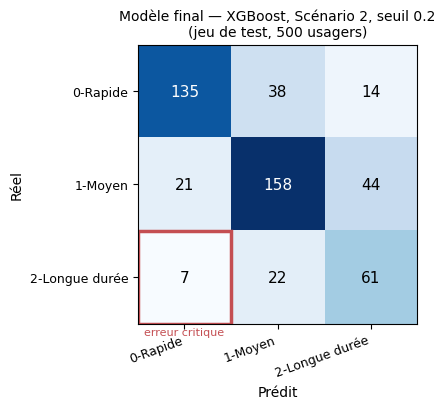

In [54]:
cm_finale = confusion_matrix(y_test_arr, pred_finale, labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(5, 4.2))
ax.imshow(cm_finale, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels(noms_classes, rotation=20, ha="right", fontsize=9)
ax.set_yticks(range(3)); ax.set_yticklabels(noms_classes, fontsize=9)
ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
ax.set_title(f"Modèle final — XGBoost, Scénario 2, seuil {SEUIL_FINAL}\n(jeu de test, 500 usagers)", fontsize=10)
for i in range(3):
    for j in range(3):
        couleur = "white" if cm_finale[i, j] > cm_finale.max() / 2 else "black"
        ax.text(j, i, cm_finale[i, j], ha="center", va="center", color=couleur, fontsize=11)
# La case qui compte : réel = 2, prédit = 0.
ax.add_patch(plt.Rectangle((-0.5, 1.5), 1, 1, fill=False, edgecolor="#c44e52", linewidth=2.5))
ax.text(0, 2.62, "erreur critique", ha="center", color="#c44e52", fontsize=8)
plt.tight_layout(); plt.show()

### Quelle confiance accorder à ces deux chiffres ?

Le jeu de test contient 500 usagers, dont 90 seulement de classe 2. Avant de communiquer « F1-macro = 0,691 »
comme s'il s'agissait d'une valeur exacte, je mesure l'incertitude de cette estimation par **bootstrap** : je
retire 2 000 échantillons du jeu de test, avec remise, et je regarde la dispersion des métriques obtenues.

F1-macro        : 0.691   IC 95 % = [0.646 ; 0.731]
Erreur critique : 0.078   IC 95 % = [0.025 ; 0.138]


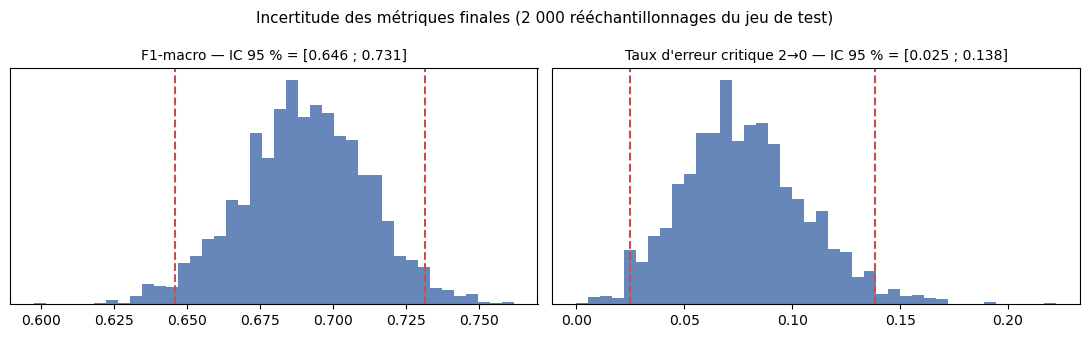

In [55]:
generateur = np.random.default_rng(0)
f1_bootstrap, erreur_bootstrap = [], []

for _ in range(2000):
    indices = generateur.integers(0, len(y_test_arr), len(y_test_arr))
    f1_bootstrap.append(f1_score(y_test_arr[indices], pred_finale[indices], average="macro"))
    cm_b = confusion_matrix(y_test_arr[indices], pred_finale[indices], labels=[0, 1, 2])
    erreur_bootstrap.append(cm_b[2, 0] / max(cm_b[2].sum(), 1))

ic_f1 = np.percentile(f1_bootstrap, [2.5, 97.5])
ic_erreur = np.percentile(erreur_bootstrap, [2.5, 97.5])
print(f"F1-macro        : {f1_score(y_test_arr, pred_finale, average='macro'):.3f}   "
      f"IC 95 % = [{ic_f1[0]:.3f} ; {ic_f1[1]:.3f}]")
print(f"Erreur critique : {cm_finale[2, 0] / cm_finale[2].sum():.3f}   "
      f"IC 95 % = [{ic_erreur[0]:.3f} ; {ic_erreur[1]:.3f}]")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, valeurs, ic, titre in [
    (axes[0], f1_bootstrap, ic_f1, "F1-macro"),
    (axes[1], erreur_bootstrap, ic_erreur, "Taux d'erreur critique 2→0"),
]:
    ax.hist(valeurs, bins=40, color="#4c72b0", alpha=0.85)
    ax.axvline(ic[0], color="#c44e52", linestyle="--"); ax.axvline(ic[1], color="#c44e52", linestyle="--")
    ax.set_title(f"{titre} — IC 95 % = [{ic[0]:.3f} ; {ic[1]:.3f}]", fontsize=10)
    ax.set_yticks([])
plt.suptitle("Incertitude des métriques finales (2 000 rééchantillonnages du jeu de test)", fontsize=11)
plt.tight_layout(); plt.show()

**Lecture du résultat final :**

Le seuil de décision fait exactement ce qu'on lui demande : **le taux d'erreur critique passe de 11,1 % à 7,8 %**,
soit de 10 à 7 usagers de classe 2 mal orientés sur 90 — **une réduction de 30 % des erreurs les plus graves**.
Le prix est visible et je ne le cache pas : 2 points de F1-macro et 3 points d'accuracy en moins, parce que le
modèle classe désormais en « risque élevé » des usagers qui ne l'étaient pas.

C'est le compromis que le sujet demande explicitement d'arbitrer, et il est arbitré dans le sens qu'il indique :
*« une situation de niveau 2 classée niveau 0 est une erreur bien plus grave [...] car elle prive l'usager d'un
accompagnement renforcé indispensable »*. Un faux positif coûte un entretien d'accompagnement en trop ; un faux
négatif coûte des mois de chômage évitables.

**Et les intervalles de confiance obligent à la modestie.** Le F1-macro de 0,691 a un intervalle à 95 % de
[0,646 ; 0,731], et l'erreur critique de 7,8 % un intervalle de [2,5 % ; 13,8 %]. Autrement dit, la vraie
performance du modèle est connue à ± 4 points près, et son vrai taux d'erreur critique à ± 5 points près. Tous
les écarts que j'ai comparés au fil du projet — 0,713 contre 0,712, 7,8 % contre 6,7 % — tiennent entièrement à
l'intérieur de ces intervalles. **C'est la raison de fond pour laquelle aucune décision de ce projet n'a été
prise sur le jeu de test.**

**Le même point, exprimé en personnes plutôt qu'en pourcentages** — c'est la formulation que je retiendrai pour
l'oral, parce qu'elle est plus honnête que les décimales.

Le jeu de test contient **90 usagers réellement en classe 2**. Un point de pourcentage d'erreur critique vaut donc
un peu moins d'une personne. Le passage de 11,1 % à 7,8 % correspond très exactement à **3 usagers de plus
correctement orientés**. C'est réel, c'est le bon sens de l'effort — et c'est trop peu pour qu'on puisse affirmer
que la même chose se reproduirait à l'identique sur les 90 usagers suivants.

C'est pourquoi la tendance mesurée en validation croisée, sur les 2 000 lignes du train brassées en 20 découpages
(erreur critique moyenne de 0,099 contre 0,138 à l'argmax), est une base plus solide pour décider d'une politique
générale que ce seul chiffre du test. Le test reste indispensable comme vérification finale indépendante — mais
je me garde d'en tirer une conclusion plus forte que ce que sa taille permet.

### 6.5 — Où se situe le seuil retenu sur la courbe ROC ?

La §5.5 a établi que le classement des scénarios tenait sur une métrique indépendante du seuil. Je
reviens ici à la ROC pour une autre raison : elle est le bon outil pour **montrer ce que fait un
choix de seuil**, et donc pour justifier celui que j'ai retenu autrement que par deux nombres.

Une courbe ROC est le lieu de tous les compromis accessibles à un même modèle. Choisir un seuil, c'est
choisir un point sur cette courbe : plus haut à droite, on détecte davantage de situations à risque au
prix de davantage de fausses alertes ; plus bas à gauche, l'inverse. Le modèle, lui, ne change pas.
Placer côte à côte le point de l'argmax et celui du seuil 0,20 montre donc exactement ce que j'ai
acheté, et avec quelle monnaie.

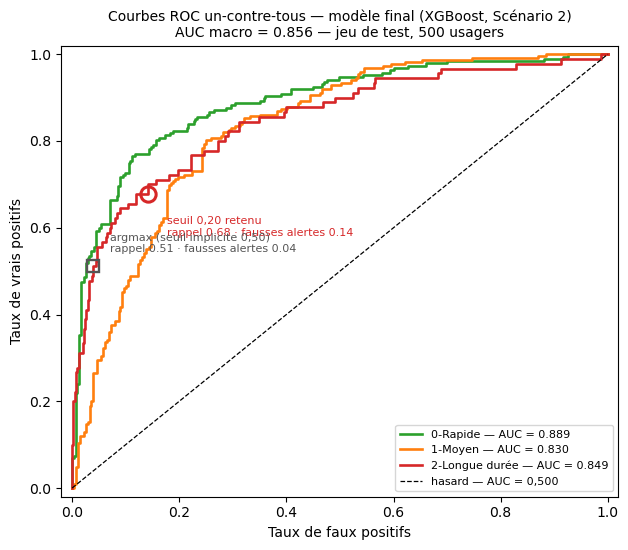

AUC macro (un-contre-tous)   : 0.856
AUC pondérée par effectifs   : 0.855
   0-Rapide         AUC = 0.889
   1-Moyen          AUC = 0.830
   2-Longue durée   AUC = 0.849


In [56]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test_arr, classes=[0, 1, 2])
fpr_c, tpr_c, auc_par_classe = {}, {}, {}
for k in range(3):
    fpr_c[k], tpr_c[k], _ = roc_curve(y_test_bin[:, k], probas_test_final[:, k])
    auc_par_classe[k] = auc(fpr_c[k], tpr_c[k])

auc_macro = roc_auc_score(y_test_arr, probas_test_final, multi_class="ovr", average="macro")
auc_ponderee = roc_auc_score(y_test_arr, probas_test_final, multi_class="ovr", average="weighted")

# Point de fonctionnement du seuil retenu, sur la courbe de la classe 2
fpr2, tpr2, seuils2 = roc_curve(y_test_bin[:, 2], probas_test_final[:, 2])
i_retenu = int(np.argmin(np.abs(seuils2 - SEUIL_FINAL)))
i_argmax = int(np.argmin(np.abs(seuils2 - 0.50)))

fig, ax = plt.subplots(figsize=(6.4, 5.6))
couleurs = {0: "#2ca02c", 1: "#ff7f0e", 2: "#d62728"}
for k in range(3):
    ax.plot(fpr_c[k], tpr_c[k], color=couleurs[k], lw=1.9,
            label=f"{noms_classes[k]} — AUC = {auc_par_classe[k]:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=0.9, label="hasard — AUC = 0,500")

ax.plot(fpr2[i_retenu], tpr2[i_retenu], "o", ms=11, mfc="none", mec="#d62728", mew=2.2)
ax.annotate(f"seuil 0,20 retenu\nrappel {tpr2[i_retenu]:.2f} · fausses alertes {fpr2[i_retenu]:.2f}",
            (fpr2[i_retenu], tpr2[i_retenu]), textcoords="offset points",
            xytext=(14, -30), fontsize=8, color="#d62728")
ax.plot(fpr2[i_argmax], tpr2[i_argmax], "s", ms=9, mfc="none", mec="#555555", mew=1.7)
ax.annotate(f"argmax (seuil implicite 0,50)\nrappel {tpr2[i_argmax]:.2f} · fausses alertes {fpr2[i_argmax]:.2f}",
            (fpr2[i_argmax], tpr2[i_argmax]), textcoords="offset points",
            xytext=(12, 10), fontsize=8, color="#555555")

ax.set_xlabel("Taux de faux positifs"); ax.set_ylabel("Taux de vrais positifs")
ax.set_title("Courbes ROC un-contre-tous — modèle final (XGBoost, Scénario 2)\n"
             f"AUC macro = {auc_macro:.3f} — jeu de test, 500 usagers", fontsize=10)
ax.legend(loc="lower right", fontsize=8)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
plt.tight_layout(); plt.show()

print(f"AUC macro (un-contre-tous)   : {auc_macro:.3f}")
print(f"AUC pondérée par effectifs   : {auc_ponderee:.3f}")
for k in range(3):
    print(f"   {noms_classes[k]:16s} AUC = {auc_par_classe[k]:.3f}")

**Ce que montre cette figure, et qui ne se voit pas dans une matrice de confusion :**

- **L'AUC macro du modèle final est de 0,856** sur le jeu de test — la classe 0 est la mieux séparée
  (0,889), la classe 1 la moins bien (0,830), ce qui confirme par un autre chemin ce que disaient les
  matrices de confusion de l'étape 5 : la frontière la plus floue est celle entre « rapide » et
  « moyen », pas celle qui sépare les situations à risque.
- **La classe 2 est correctement ordonnée** (AUC 0,849) alors même que le modèle ne la prédit
  correctement que deux fois sur trois. Il n'y a pas de contradiction : le modèle sait à peu près
  *classer* les usagers du moins au plus à risque, c'est la ligne où l'on coupe qui décide combien il
  en attrape. C'est exactement pourquoi le seuil est le bon levier, et pourquoi la pondération des
  classes — qui, elle, modifie le modèle — s'est révélée moins efficace en §6.1.
- **Les deux points de fonctionnement rendent l'arbitrage lisible.** L'argmax détecte 51 % des
  situations réellement à risque pour 4 % de fausses alertes ; le seuil 0,20 en détecte 68 % pour 14 %
  de fausses alertes. **Le passage de l'un à l'autre achète 17 points de rappel sur la classe critique
  au prix de 10 points de fausses alertes.** Traduit en personnes, sur ce jeu de test : une quinzaine
  d'usagers à risque détectés en plus, une quarantaine d'usagers orientés vers un accompagnement
  renforcé dont ils n'avaient pas besoin. C'est l'arbitrage que le sujet demande d'assumer, et cette
  formulation est celle que je retiendrai pour l'oral : elle est vérifiable, et elle parle de
  personnes.
- **Enfin, la ROC dit que ce choix est un choix, pas une correction.** Les deux points sont sur la
  même courbe : je n'ai pas amélioré le modèle en abaissant le seuil, j'ai déplacé le curseur sur un
  modèle inchangé. La décision revient donc au commanditaire, pas au data scientist — un point que je
  reprends à l'étape 9.

---
## Ce qu'on retient de l'étape 6, avant de passer à l'étape 7

- **Deux leviers testés** comme le demande le sujet : pondération des classes et seuil de décision, réglés
  uniquement en validation croisée sur le train.
- **Une règle de décision annoncée avant les résultats** — minimiser l'erreur critique sous contrainte
  F1-macro ≥ 0,68 — appliquée à une grille complète de 21 combinaisons (3 modèles × 7 seuils).
- **La règle désigne XGBoost au seuil 0,20.** Random Forest est confirmé écarté, cette fois sur le scénario
  réellement déployé ; l'avance de XGBoost sur LightGBM est petite (+0,007) mais systématique (15 plis sur 20,
  p ≈ 0,006).
- **Un seul contrôle sur le jeu de test**, sur une décision déjà prise : accuracy 0,708, F1-macro 0,691, erreur
  critique 7,8 % — soit 30 % d'erreurs graves en moins qu'avec l'argmax, pour 2 points de F1-macro.
- **Les deux métriques finales sont livrées avec leur intervalle de confiance**, parce qu'un chiffre sans son
  incertitude n'est pas un résultat.

➡️ **Prochaine étape (étape 7) :** justifier ce choix sous l'angle que le sujet demande explicitement — le
rapport performance / coût computationnel d'inférence — et le formaliser.

---
# Étape 7 — Le modèle final : coût d'inférence et formalisation du choix

**Objectif de cette étape**, formulé par le sujet : *"Discuter de l'architecture de modèle qui présente le
meilleur rapport performance / coût computationnel d'inférence."*

Le volet « performance » est tranché à l'étape 6, par une règle annoncée à l'avance et appliquée en validation
croisée. Il reste le volet **coût d'inférence**, que je mesure ici, et la formalisation de la décision.

**Une précision de méthode, parce qu'elle explique pourquoi cette étape ne contient plus de comparaison de
modèles.** Dans une première version de ce travail, je comparais ici XGBoost et LightGBM sur leurs scores de
jeu de test, et je choisissais le meilleur des deux. C'était une erreur de protocole : le jeu de test devient
alors un jeu de sélection, et le score final rapporté n'est plus une estimation mais un maximum choisi parmi
plusieurs essais. Le comparatif a donc été déplacé en amont, en validation croisée (étape 6.4), et le test n'est
plus consulté qu'une fois, sur une décision déjà prise. Le modèle retenu a d'ailleurs changé en conséquence :
c'est le signe que la correction n'était pas cosmétique.

In [57]:
import time
import joblib
import os

# --- Coût computationnel d'inférence ---
# Rappel de l'étape 4 : le sujet demande le coût d'INFÉRENCE, pas d'entraînement. Le temps
# d'entraînement se paie une fois ; le temps de prédiction se paie à chaque entretien.
modele_lgbm_s2 = LGBMClassifier(random_state=42, verbose=-1)
modele_lgbm_s2.fit(X_s2_train, y_train_arr)   # pour comparaison de latence uniquement

une_ligne = X_s2_test[[0]]
mesures = []
for nom, modele in [("XGBoost (retenu)", modele_final), ("LightGBM", modele_lgbm_s2)]:
    modele.predict(une_ligne)  # première prédiction hors mesure (mise en cache interne)
    t0 = time.perf_counter()
    for _ in range(200):
        modele.predict(une_ligne)
    mesures.append({"modele": nom, "latence_1_usager_ms": (time.perf_counter() - t0) / 200 * 1000})

# --- Empreinte mémoire des artefacts à charger ---
os.makedirs("artefacts_modele", exist_ok=True)
joblib.dump(modele_final, CHEMIN_ARTEFACTS / "modele_xgboost.joblib")
joblib.dump(ohe, CHEMIN_ARTEFACTS / "onehot_encoder.joblib")
joblib.dump(tfidf, CHEMIN_ARTEFACTS / "tfidf_vectorizer.joblib")
joblib.dump(
    {
        "age_median": float(age_median), "diplome_mode": diplome_mode,
        "alloc_mode": int(alloc_mode), "mapping_diplome": mapping_diplome,
        "seuil_classe2": SEUIL_FINAL, "version_modele": "xgboost_scenario2_v2",
    },
    CHEMIN_ARTEFACTS / "parametres_imputation.joblib",
)
tailles = {f: os.path.getsize(f"artefacts_modele/{f}") / 1024 for f in os.listdir("artefacts_modele")}

print(pd.DataFrame(mesures).round(3).to_string(index=False))
print()
for fichier, taille in sorted(tailles.items()):
    print(f"{fichier:32s} {taille:8.1f} Ko")
print(f"{'TOTAL à charger en mémoire':32s} {sum(tailles.values()) / 1024:8.2f} Mo")

          modele  latence_1_usager_ms
XGBoost (retenu)                 0.94
        LightGBM                 1.62

modele_xgboost.joblib               581.9 Ko
onehot_encoder.joblib                 2.0 Ko
parametres_imputation.joblib          0.2 Ko
tfidf_vectorizer.joblib               2.2 Ko
TOTAL à charger en mémoire           0.57 Mo


**Interprétation — le coût d'inférence ne départage rien, et c'est une information en soi :**

Les deux modèles prédisent en **une fraction de milliseconde** par usager, XGBoost restant environ deux fois plus
rapide que LightGBM. L'écart relatif est net et stable d'une exécution à l'autre, mais il est **négligeable dans
l'absolu** : à cette échelle, la latence perçue par le conseiller sera entièrement dominée par le réseau et la
sérialisation HTTP (10 à 100 ms), pas par le calcul du modèle. Rendre le modèle dix fois plus rapide ne
changerait rien à son expérience.

*(Note méthodologique : ce sont des mesures de temps d'horloge, sensibles à la charge de la machine. Les valeurs
exactes varient d'une exécution à l'autre ; le classement relatif entre modèles, lui, est stable.)*

**L'ensemble modèle + encodeurs + vectoriseur pèse moins d'un mégaoctet.** Le dimensionnement des ressources est
donc presque une non-question, et je le chiffrerai à l'étape 9.2.

**Ce que cela veut dire pour la décision :** le critère « coût d'inférence » ne permet pas de trancher entre les
deux candidats, puisqu'ils sont tous les deux très en dessous de toute latence perceptible. Il vient simplement
confirmer, sans le contredire, le choix fait sur la performance en validation croisée — et il écarte
définitivement Random Forest, dont la latence se compte en dizaines de millisecondes, soit un facteur de
l'ordre de 100.

### 7.1 bis — Ce que le seuil a réellement coûté sur le jeu de test

J'ai annoncé en §6.2 que la zone de seuil 0,20-0,30 améliorait le F1-macro **et** réduisait
l'erreur critique, sans compromis. Mis face au résultat du jeu de test, cet énoncé mérite
d'être précisé — et je préfère le faire moi-même plutôt que de laisser l'écart se
découvrir.

| Règle de décision | Accuracy | F1-macro | Erreur critique (2→0) |
|---|---|---|---|
| Argmax (seuil implicite 0,50) — §5.3 | 0,740 | **0,712** | 0,111 — soit 10 usagers sur 90 |
| Seuil 0,20 — configuration livrée | 0,708 | **0,691** | 0,078 — soit 7 usagers sur 90 |

**Sur le jeu de test, le seuil est donc bien un compromis : il coûte 2,1 points de F1-macro
et rapporte 3,3 points d'erreur critique**, soit trois usagers réellement en risque de
chômage de longue durée qui reçoivent l'accompagnement renforcé au lieu d'être orientés
vers un suivi léger.

**Ce n'est pas une contradiction avec le §6.2, et voici pourquoi.**

**1. Les deux mesures ne portent pas sur la même quantité de données.** Le §6.2 mesure en
validation croisée sur les 2 000 lignes du jeu d'entraînement : chaque ligne y est notée
par un modèle qui ne l'a jamais vue, et l'opération est répétée sur plusieurs découpages.
Le tableau ci-dessus mesure sur 500 lignes, dont **90 seulement appartiennent à la classe
2**. À cette échelle, un point de pourcentage d'erreur critique vaut moins d'une personne :
la mesure est structurellement bruitée.

**2. Aucun des deux écarts n'est statistiquement significatif sur ce jeu de test.** C'est le
point décisif, et il vaut dans les deux sens :

- l'intervalle de confiance à 95 % du F1-macro final est **[0,646 ; 0,731]**, et **0,712
  est à l'intérieur** — on ne peut donc pas affirmer, sur ces 500 lignes, que l'argmax fait
  mieux ;
- l'intervalle de confiance de l'erreur critique est **[2,5 % ; 13,8 %]**, et **11,1 % est à
  l'intérieur** — on ne peut pas davantage affirmer que le seuil 0,20 fait mieux.

Le jeu de test, seul, ne permet de trancher ni dans un sens ni dans l'autre. Le présenter
comme s'il tranchait serait lui prêter une précision qu'il n'a pas.

**3. C'est exactement pourquoi la décision n'a pas été prise ici.** Le couple (modèle,
seuil) a été choisi en §6.4 sur les 2 000 lignes du train, en validation croisée, avec une
règle annoncée avant de regarder les résultats : *minimiser l'erreur critique sous
contrainte d'un F1-macro ≥ 0,68*. Sur cette base — la seule assez large pour porter une
politique générale — le passage de l'argmax au seuil 0,20 fait passer l'erreur critique de
**0,138 à 0,099**, pour un F1-macro qui passe de ** 0,6760 à 0,6837**. C'est là que la
domination annoncée en §6.2 s'observe, et c'est là que j'ai décidé.

**Le rôle du jeu de test est différent, et je m'y tiens.** Il ne sert pas à arbitrer entre
deux règles de décision — il servirait alors de jeu de validation, et perdrait
l'indépendance qui fait toute sa valeur. Il sert à vérifier qu'aucune des conclusions tirées
en validation croisée ne s'effondre sur des données jamais vues. Sur ce point, le contrôle
est concluant : l'erreur critique baisse dans le sens attendu, et le F1-macro reste dans
l'intervalle de confiance de la valeur mesurée en validation croisée.

**La formulation que je retiens pour l'oral**, parce qu'elle est plus juste que « c'est
gratuit » : *je n'ai pas amélioré le modèle en abaissant le seuil, je l'ai déplacé sur sa
propre courbe ROC (§6.5). En validation croisée, ce déplacement est favorable sur les deux
métriques. Sur le jeu de test, il est favorable sur celle qui compte pour l'usager et
défavorable de deux points sur l'autre — et cet écart tient entièrement à l'intérieur de mon
intervalle de confiance. C'est un arbitrage assumé, pas un gain sans contrepartie.*


## 7.2 — Éco-conception : ce que coûte cette solution à faire tourner
Le sujet demande le meilleur rapport performance / coût computationnel d'inférence. J'ai traité le
coût sous l'angle de la latence ; il en reste un second, que le référentiel de la certification
mentionne explicitement et qu'il serait facile d'oublier dans un projet où le modèle est léger : la
**consommation de ressources**, et donc l'empreinte environnementale de la solution.
Je ne veux pas en faire un paragraphe d'intention. Je mesure ce qui est mesurable, j'annonce mes
hypothèses pour le reste, et j'en tire une conclusion opérationnelle.

In [58]:
import time, os, joblib

# --- Ce qui se mesure
t0 = time.perf_counter()
XGBClassifier(random_state=42, eval_metric="mlogloss").fit(X_s2_train, y_train_arr)
duree_entrainement_s = time.perf_counter() - t0

une_ligne = X_s2_test[[0]]
modele_final.predict(une_ligne)                      # première prédiction hors mesure
t0 = time.perf_counter()
for _ in range(500):
    modele_final.predict(une_ligne)
latence_ms = (time.perf_counter() - t0) / 500 * 1000

taille_ko = os.path.getsize("artefacts_modele/modele_xgboost.joblib") / 1024

# --- Ce qui s'estime, avec des hypothèses explicites
PUISSANCE_COEUR_W = 15          # ordre de grandeur d'un cœur de serveur sous charge
INFERENCES_PAR_AN = 3_000_000   # hypothèse : ~3 M d'entretiens de cadrage par an à l'échelle nationale
HEURES_PAR_AN = 8760
INTENSITE_CARBONE_G_KWH = 56    # mix électrique français, ordre de grandeur ADEME/RTE

energie_inference_wh = latence_ms / 1000 / 3600 * PUISSANCE_COEUR_W
energie_calcul_an_kwh = energie_inference_wh * INFERENCES_PAR_AN / 1000
energie_entrainement_wh = duree_entrainement_s / 3600 * PUISSANCE_COEUR_W
energie_serveur_an_kwh = PUISSANCE_COEUR_W * HEURES_PAR_AN / 1000

print("MESURÉ")
print(f"   Taille du modèle sérialisé            : {taille_ko:.0f} Ko")
print(f"   Entraînement complet                  : {duree_entrainement_s:.2f} s")
print(f"   Inférence unitaire                    : {latence_ms:.2f} ms")
print("\nESTIMÉ (hypothèses ci-dessus)")
print(f"   Énergie d'un entraînement             : {energie_entrainement_wh*1000:.0f} mWh")
print(f"   Énergie d'une inférence               : {energie_inference_wh*1e6:.1f} µWh")
print(f"   Calcul d'inférence, {INFERENCES_PAR_AN/1e6:.0f} M requêtes/an   : "
      f"{energie_calcul_an_kwh*1000:.1f} Wh/an  ({energie_calcul_an_kwh*INTENSITE_CARBONE_G_KWH:.1f} gCO2e)")
print(f"   Serveur allumé en continu (1 cœur)    : "
      f"{energie_serveur_an_kwh*1000:.0f} Wh/an  ({energie_serveur_an_kwh*INTENSITE_CARBONE_G_KWH/1000:.1f} kgCO2e)")
print(f"\n   Le seul fait de maintenir le service allumé coûte "
      f"{energie_serveur_an_kwh/energie_calcul_an_kwh:.0f} fois l'énergie de toutes ses inférences annuelles.")

MESURÉ
   Taille du modèle sérialisé            : 582 Ko
   Entraînement complet                  : 0.30 s
   Inférence unitaire                    : 0.97 ms

ESTIMÉ (hypothèses ci-dessus)
   Énergie d'un entraînement             : 1 mWh
   Énergie d'une inférence               : 4.1 µWh
   Calcul d'inférence, 3 M requêtes/an   : 12.2 Wh/an  (0.7 gCO2e)
   Serveur allumé en continu (1 cœur)    : 131400 Wh/an  (7.4 kgCO2e)

   Le seul fait de maintenir le service allumé coûte 10804 fois l'énergie de toutes ses inférences annuelles.


**Le résultat structurant : sur cette solution, le calcul ne coûte rien, c'est l'hébergement qui
coûte.** L'ensemble des inférences d'une année entière représente une fraction négligeable de ce que
consomme le serveur simplement parce qu'il est allumé : avec les hypothèses ci-dessus, un facteur
de l'ordre de dix mille.
La conséquence pratique est nette et va à l'encontre de l'intuition : **optimiser le modèle n'aurait
aucun effet mesurable sur l'empreinte de la solution.** Le levier d'éco-conception se situe ailleurs,
dans la mutualisation de l'hébergement — faire tourner ce service sur une infrastructure partagée
plutôt que sur une machine dédiée sous-utilisée — et c'est ce que je recommande au commanditaire.

**La décision d'éco-conception a en réalité été prise à l'étape 3, et elle mérite d'être nommée comme
telle.** J'ai écarté les embeddings au profit d'un TF-IDF après avoir mesuré qu'un simple one-hot des
neuf formulations faisait déjà jeu égal. Ce n'était pas seulement un choix de performance : c'est un
refus explicite de mobiliser un modèle de langage là où trois cents petits arbres suffisent. L'ordre
de grandeur de ce qui a été évité est vérifiable sur des critères simples — un modèle d'embeddings de
taille courante pèse plusieurs centaines de mégaoctets contre 0,6 Mo ici, soit un facteur de l'ordre
du millier sur l'empreinte mémoire, avec une latence CPU d'une à quelques dizaines de millisecondes
par phrase contre une fraction de milliseconde. **Sur un service public appelé à traiter des millions
de dossiers, ce facteur n'est pas un détail d'ingénierie : c'est le principal arbitrage
environnemental du projet, et il a été tranché par la mesure.**

**Ce que je porte à la connaissance du commanditaire**, puisque le référentiel demande que les
contraintes d'éco-conception soient partagées avec les acteurs pertinents :

1. La solution est **frugale par construction** et ne justifie ni GPU, ni accélérateur, ni
   dimensionnement de précaution ;
2. Le poste dominant est l'**hébergement continu**, pas le calcul : la mutualisation de
   l'infrastructure est le seul levier qui déplacerait réellement l'empreinte ;
3. Le **ré-entraînement** est quasi gratuit (quelques secondes), ce qui autorise une fréquence de
   mise à jour élevée sans arbitrage environnemental — une liberté qu'un système fondé sur un grand
   modèle de langage n'aurait pas ;
4. Toute évolution future vers une architecture à base d'embeddings ou de LLM devrait être **soumise
   à une comparaison chiffrée du gain de performance et du surcoût énergétique**, sur le modèle de
   celle conduite en §3.4, et non adoptée par défaut parce que la technologie est disponible.

*Les estimations ci-dessus sont des ordres de grandeur, dépendants de la machine et du mix électrique
retenus. Elles ne visent pas la précision d'un bilan carbone : elles visent à savoir où se situe le
poste dominant, et cette réponse-là est robuste à un facteur deux sur chacune des hypothèses.*

## Décision finale

| Dimension | Choix retenu | Justifié à l'étape |
|---|---|---|
| **Scénario de données** | **Scénario 2 — sans `nationalite_hors_ue`** | 5.3 — coût mesuré de 2 à 3 points de F1-macro en validation croisée, assumé au titre de la minimisation et de la non-discrimination |
| **Famille de modèle** | **XGBoost** | 6.4 — désigné par la règle de décision annoncée à l'avance ; avance faible (+0,007) mais systématique sur LightGBM (15 plis sur 20, p ≈ 0,006) ; le plus rapide à l'inférence |
| **Règle de décision** | **Seuil à 0,20 sur P(classe = 2)**, plutôt que l'argmax | 6.4 — minimise l'erreur critique sous contrainte F1-macro ≥ 0,68 |
| **Performance finale** | Accuracy 0,708 · F1-macro 0,691 [0,646 ; 0,731] · erreur critique 7,8 % [2,5 % ; 13,8 %] | 6.4 — jeu de test, mesuré une seule fois |

**Argumentaire complet (ce que je dirai à l'oral) :**

1. **Le Scénario 2 est préféré au Scénario 1** en connaissance de cause : retirer la nationalité coûte 2 à 3
   points de F1-macro en validation croisée. Ce n'est pas gratuit, et je ne le présente pas comme tel — c'est le
   prix de la conformité, développé à l'étape 8. Les Scénarios 3 et 4 sont écartés comme solutions autonomes,
   le Scénario 4 restant utile comme filet de sécurité avant entretien.
2. **Random Forest est écarté** sur les deux fronts, et cette fois sur le scénario réellement déployé : dominé en
   F1-macro comme en erreur critique sur toute la grille de seuils, et de l'ordre de 100 fois plus lent à l'inférence.
3. **XGBoost est préféré à LightGBM** sur une différence appariée mesurée sur 20 plis, pas sur un score de test.
   L'écart est faible : je le présente comme tel, et non comme une supériorité écrasante.
4. **Le seuil de décision à 0,20** réduit de 30 % les erreurs critiques pour 2 points de F1-macro. C'est
   l'arbitrage que le sujet demande, tranché dans le sens qu'il indique.
5. **Toutes ces décisions ont été prises sans regarder le jeu de test.** C'est ce qui permet d'annoncer 0,691
   comme une estimation de performance et non comme un record.

**Ce que je ferais avec plus de temps**, dans l'ordre du gain attendu :

1. **Approfondir la recherche d'hyperparamètres** au-delà des 30 tirages
   aléatoires par modèle déjà menés au §6.4 bis. Une recherche bayésienne,
   par exemple avec Optuna, permettrait d'explorer plus systématiquement
   l'espace des réglages.

   La recherche légère déjà conduite ne montre cependant qu'une marge limitée :
   le meilleur F1-macro observé pour XGBoost passe de **0,6837** avec la
   configuration par défaut à **0,6864** avec `essai_20`, soit un gain de :

 Le meilleur F1-macro trouvé dépasse la configuration par défaut de
  **0,0027** (`0,6864 - 0,6837`). Cette amélioration s’accompagne toutefois
  d’une augmentation de **0,0083** du taux d’erreur critique
  (`0,1077 - 0,0994`).

➡️ **Prochaine étape (étape 8) :** la section éthique et réglementaire complète (RGPD, non-discrimination,
responsabilité juridique), qui formalise l'argumentaire du choix du Scénario 2 et le confronte à une question que
je n'avais pas traitée : celle de l'âge.

---
# Étape 8 — Éthique et cadre réglementaire

**Ce que demande le sujet, mot pour mot** : *"Une section du rapport de projet devra traiter spécifiquement de
la conformité au RGPD, de la non-discrimination algorithmique des profils (Loi pour une République Numérique),
et de la responsabilité juridique de l'éditeur ou de l'administration publique en cas d'erreur d'orientation
induisant une perte de chance pour l'usager."*

Trois points précis à traiter, donc — je les prends un par un, en m'appuyant sur les choix concrets déjà faits
dans ce projet (Scénario 2, seuil de décision, journalisation prévue) plutôt que de rester dans la théorie
générale.

## 8.0 — Le cadre de référence auquel j'adosse cette section

Avant d'entrer dans les trois points demandés par le sujet, je pose les textes sur lesquels je
m'appuie. Ils ne sont pas de même nature, et les distinguer est le premier travail d'une analyse de
conformité : certains obligent, d'autres orientent.

**Ce qui oblige — le droit applicable.**

| Texte | Ce qu'il impose ici |
|---|---|
| RGPD (règlement (UE) 2016/679) | Base légale, minimisation, durée de conservation, droit de ne pas subir une décision exclusivement automatisée, analyse d'impact |
| Loi pour une République numérique (n° 2016-1321), art. L. 311-3-1 et R. 311-3-1-2 du CRPA | Mention explicite du traitement algorithmique, droit à l'explication des règles et paramètres appliqués |
| Art. L. 312-1-3 du CRPA | Publication en open data des règles des principaux traitements algorithmiques |
| Code pénal, art. 225-1 | Liste des critères de discrimination protégés — dont l'origine, l'âge et la vulnérabilité économique |
| Règlement européen sur l'IA (UE) 2024/1689, annexe III §5(a) | Classement en système à haut risque, et obligations associées |

**Ce qui oriente — les chartes et référentiels éthiques.** Ils n'ont pas de force contraignante mais
constituent l'état de l'art auquel une administration est légitimement comparée. Trois cadres me
servent de grille de lecture :

- **Les *Lignes directrices en matière d'éthique pour une IA digne de confiance*** du groupe d'experts
  de haut niveau de la Commission européenne (2019) et leurs sept exigences. Quatre d'entre elles
  structurent directement ce projet, et je peux montrer où : le **facteur humain et le contrôle
  humain** (le conseiller décide, §8.1 et 9.6), la **robustesse technique** (validation croisée,
  intervalles de confiance, garde-fous de la chaîne CI/CD), la **diversité, non-discrimination et
  équité** (Scénario 2, audit de proxy et d'équité en §8.2 bis), et la **transparence** (§8.2, et la
  publication des règles au titre du CRPA). Les trois autres — respect de la vie privée et gouvernance
  des données, bien-être sociétal, responsabilité — sont traitées respectivement en 8.1, 8.3 et 9.1 bis.
- **La recommandation de l'UNESCO sur l'éthique de l'intelligence artificielle** (2021), à laquelle la
  France a souscrit, pour son insistance sur la proportionnalité et sur l'évaluation d'impact
  préalable — ce qui rejoint l'AIPD que je signale comme prérequis non réalisé.
- **Les recommandations de la CNIL sur les systèmes d'IA**, qui précisent en droit français la
  détermination de la base légale, la minimisation appliquée à l'entraînement, et — point directement
  utile ici — **l'usage licite d'une variable sensible aux seules fins de mesure et de correction des
  biais**, qui est exactement l'usage que j'en fais en §8.2 bis.

**Une distinction que je tiens à formuler, parce qu'elle commande tout ce qui suit.** Le respect du
droit est une condition nécessaire ; il ne suffit pas à rendre un système légitime. Sur la
nationalité, aucun texte ne pose d'interdiction mécanique : cette variable n'est pas, à proprement
parler, une donnée de l'article 9 du RGPD, et ce n'est pas la donnée qui est prohibée mais l'usage
qui en serait fait — un usage susceptible de recevoir la qualification de discrimination au sens des
articles 225-1 et 225-2 du code pénal, ce qui suppose une appréciation au cas par cas. Le droit
énonce donc ici un risque, pas une règle d'exclusion. **C'est une lecture éthique, adossée aux
chartes ci-dessus, qui tranche** — et c'est précisément pourquoi j'ai tenu à en mesurer le coût
plutôt qu'à supposer qu'il était nul : une décision éthique qui ne coûte rien n'engage à rien.

### 8.0 bis — Calculs éthiques reproductibles

Cette cellule regroupe les calculs quantitatifs utilisés dans l'argumentation
éthique des sections suivantes.

Elle répond à quatre questions :

1. Quel est le coût mesuré du retrait de `nationalite_hors_ue` pour XGBoost et
   LightGBM, au seuil final de `0,20` ?
2. Quelle est la proportion réelle d'usagers de classe 2 selon la valeur de
   `nationalite_hors_ue` dans le jeu complet ?
3. Quelle est la proportion de classe 2 dans les tranches d'âge citées dans
   l'analyse ?
4. Quel est l'effet du retrait strict de l'âge et des variables qui en dérivent
   sur le F1-macro du Scénario 2 ?

Les comparaisons de modèles sont réalisées uniquement en validation croisée sur
le jeu d'entraînement. Le jeu de test final n'est pas utilisé pour produire ou
sélectionner ces conclusions.

In [59]:
# ============================================================================
# CALCULS ÉTHIQUES REPRODUCTIBLES
# ============================================================================
#
# Emplacement :
# juste avant le §8.1 du Notebook.
#
# Cette cellule produit quatre calculs :
# A. coût du retrait de nationalite_hors_ue au seuil 0,20 ;
# B. proportion de classe 2 selon la nationalité ;
# C. proportion de classe 2 selon les tranches d'âge ;
# D. effet du retrait strict de l'âge.
#
# Les comparaisons de modèles utilisent uniquement le jeu d'entraînement.
# Le jeu de test final n'est pas utilisé.
# ============================================================================

import numpy as np
import pandas as pd

from scipy.sparse import csr_matrix, hstack
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# ----------------------------------------------------------------------------
# 1. Vérifier les objets nécessaires
# ----------------------------------------------------------------------------

objets_requis = [
    "df",
    "X_train",
    "y_train",
    "scenarios",
    "colonnes_sans_sensible",
    "tabulaire_train_sans_sensible",
    "texte_train",
]

objets_manquants = [
    nom
    for nom in objets_requis
    if nom not in globals()
]

if objets_manquants:
    raise NameError(
        "Cette cellule doit être exécutée après les étapes 2 et 3.\n"
        f"Objets manquants : {objets_manquants}"
    )

scenarios_requis = [
    "1_multimodal_complet",
    "2_sans_variable_sensible",
]

scenarios_manquants = [
    nom
    for nom in scenarios_requis
    if nom not in scenarios
]

if scenarios_manquants:
    raise KeyError(
        "Les scénarios nécessaires sont absents.\n"
        f"Scénarios manquants : {scenarios_manquants}\n"
        f"Scénarios disponibles : {list(scenarios.keys())}"
    )

colonnes_df_requises = [
    "age",
    "nationalite_hors_ue",
    "classe_retour_emploi",
]

colonnes_df_manquantes = [
    colonne
    for colonne in colonnes_df_requises
    if colonne not in df.columns
]

if colonnes_df_manquantes:
    raise KeyError(
        "Des colonnes nécessaires sont absentes du DataFrame df.\n"
        f"Colonnes manquantes : {colonnes_df_manquantes}"
    )


# ----------------------------------------------------------------------------
# 2. Configuration commune aux expériences
# ----------------------------------------------------------------------------

SEUIL_ETHIQUE = 0.20

cv_ethique = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

y_ethique = y_train.to_numpy()


def predire_avec_seuil_ethique(
    probabilites,
    seuil=SEUIL_ETHIQUE,
):
    """Applique la règle finale de décision sur la classe 2."""

    return np.where(
        probabilites[:, 2] >= seuil,
        2,
        np.argmax(
            probabilites[:, :2],
            axis=1,
        ),
    )


def calculer_erreur_critique(
    vraies_classes,
    classes_predites,
):
    """Calcule le taux d'erreur critique : vrais 2 prédits 0."""

    matrice = confusion_matrix(
        vraies_classes,
        classes_predites,
        labels=[0, 1, 2],
    )

    nombre_classe2 = matrice[2].sum()

    if nombre_classe2 == 0:
        return np.nan

    return float(
        matrice[2, 0]
        / nombre_classe2
    )


def evaluer_modele_oof(
    matrice_X,
    cible_y,
    constructeur_modele,
):
    """Produit des prédictions out-of-fold au seuil final de 0,20."""

    probabilites_oof = np.zeros(
        (
            matrice_X.shape[0],
            3,
        ),
        dtype=float,
    )

    for indices_train, indices_validation in cv_ethique.split(
        matrice_X,
        cible_y,
    ):
        modele = constructeur_modele()

        modele.fit(
            matrice_X[indices_train],
            cible_y[indices_train],
        )

        probabilites_oof[
            indices_validation
        ] = modele.predict_proba(
            matrice_X[indices_validation]
        )

    predictions_oof = predire_avec_seuil_ethique(
        probabilites_oof
    )

    return {
        "f1_macro": float(
            f1_score(
                cible_y,
                predictions_oof,
                average="macro",
            )
        ),
        "erreur_critique": calculer_erreur_critique(
            cible_y,
            predictions_oof,
        ),
        "predictions": predictions_oof,
        "probabilites": probabilites_oof,
    }


constructeurs_modeles = {
    "XGBoost": lambda: XGBClassifier(
        random_state=42,
        eval_metric="mlogloss",
    ),
    "LightGBM": lambda: LGBMClassifier(
        random_state=42,
        verbose=-1,
    ),
}


# ============================================================================
# CALCUL A
# COÛT DU RETRAIT DE nationalite_hors_ue AU SEUIL 0,20
# ============================================================================

print("=" * 92)
print("CALCUL A - COÛT DU RETRAIT DE nationalite_hors_ue")
print("=" * 92)

resultats_retrait_nationalite = []

for nom_modele, constructeur in constructeurs_modeles.items():
    resultats_par_scenario = {}

    for nom_scenario in scenarios_requis:
        matrice_scenario = scenarios[
            nom_scenario
        ]["X_train"]

        resultat = evaluer_modele_oof(
            matrice_scenario,
            y_ethique,
            constructeur,
        )

        resultats_par_scenario[
            nom_scenario
        ] = resultat

        resultats_retrait_nationalite.append({
            "modele": nom_modele,
            "scenario": nom_scenario,
            "seuil_classe2": SEUIL_ETHIQUE,
            "f1_macro_oof": resultat["f1_macro"],
            "erreur_critique_oof": resultat[
                "erreur_critique"
            ],
        })

    f1_scenario1 = resultats_par_scenario[
        "1_multimodal_complet"
    ]["f1_macro"]

    f1_scenario2 = resultats_par_scenario[
        "2_sans_variable_sensible"
    ]["f1_macro"]

    cout_retrait_points = (
        f1_scenario1
        - f1_scenario2
    ) * 100

    print(f"\n{nom_modele}")
    print(
        "  F1-macro Scénario 1 avec nationalité : "
        f"{f1_scenario1:.4f}"
    )
    print(
        "  F1-macro Scénario 2 sans nationalité : "
        f"{f1_scenario2:.4f}"
    )
    print(
        "  Coût du retrait : "
        f"{cout_retrait_points:+.2f} point(s) de F1-macro"
    )


cout_nationalite_df = pd.DataFrame(
    resultats_retrait_nationalite
)

comparaison_nationalite_df = (
    cout_nationalite_df
    .pivot(
        index="modele",
        columns="scenario",
        values=[
            "f1_macro_oof",
            "erreur_critique_oof",
        ],
    )
)

display(
    cout_nationalite_df.style.format({
        "seuil_classe2": "{:.2f}",
        "f1_macro_oof": "{:.4f}",
        "erreur_critique_oof": "{:.4f}",
    })
)


# ============================================================================
# CALCUL B
# PROPORTION DE CLASSE 2 SELON nationalite_hors_ue
# ============================================================================

print("\n" + "=" * 92)
print("CALCUL B - CLASSE 2 SELON nationalite_hors_ue")
print("=" * 92)

table_nationalite_classe = pd.crosstab(
    df["nationalite_hors_ue"],
    df["classe_retour_emploi"],
    margins=False,
)

table_nationalite_pourcentage = pd.crosstab(
    df["nationalite_hors_ue"],
    df["classe_retour_emploi"],
    normalize="index",
).mul(100)

for classe in [0, 1, 2]:
    if classe not in table_nationalite_classe.columns:
        table_nationalite_classe[classe] = 0

    if classe not in table_nationalite_pourcentage.columns:
        table_nationalite_pourcentage[classe] = 0.0

table_nationalite_classe = (
    table_nationalite_classe[
        [0, 1, 2]
    ]
)

table_nationalite_pourcentage = (
    table_nationalite_pourcentage[
        [0, 1, 2]
    ]
)

part_classe2_ue = float(
    table_nationalite_pourcentage.loc[
        0,
        2,
    ]
)

part_classe2_hors_ue = float(
    table_nationalite_pourcentage.loc[
        1,
        2,
    ]
)

effectif_ue = int(
    table_nationalite_classe.loc[
        0
    ].sum()
)

effectif_hors_ue = int(
    table_nationalite_classe.loc[
        1
    ].sum()
)

print("\nEffectifs :")
display(table_nationalite_classe)

print("\nPourcentages par groupe :")
display(
    table_nationalite_pourcentage.style.format(
        "{:.1f} %"
    )
)

print(
    f"\nnationalite_hors_ue = 0 : "
    f"{part_classe2_ue:.1f} % en classe 2 "
    f"sur {effectif_ue} usagers"
)

print(
    f"nationalite_hors_ue = 1 : "
    f"{part_classe2_hors_ue:.1f} % en classe 2 "
    f"sur {effectif_hors_ue} usagers"
)

print(
    "Écart observé : "
    f"{part_classe2_hors_ue - part_classe2_ue:+.1f} points"
)


# ============================================================================
# CALCUL C
# PROPORTION DE CLASSE 2 SELON LES TRANCHES D'ÂGE
# ============================================================================

print("\n" + "=" * 92)
print("CALCUL C - CLASSE 2 SELON LES TRANCHES D'ÂGE")
print("=" * 92)

# Les valeurs manquantes d'âge ne sont pas incluses dans les tranches.
masque_age_35_45 = df["age"].between(
    35,
    45,
    inclusive="both",
)

masque_age_55_65 = df["age"].between(
    55,
    65,
    inclusive="both",
)


def resumer_tranche_age(
    masque,
    libelle,
):
    """Retourne les effectifs et la proportion de classe 2."""

    sous_ensemble = df.loc[
        masque,
        [
            "age",
            "classe_retour_emploi",
        ],
    ]

    effectif = len(
        sous_ensemble
    )

    nombre_classe2 = int(
        sous_ensemble[
            "classe_retour_emploi"
        ]
        .eq(2)
        .sum()
    )

    proportion_classe2 = (
        100
        * nombre_classe2
        / effectif
        if effectif > 0
        else np.nan
    )

    return {
        "tranche_age": libelle,
        "effectif": effectif,
        "nombre_classe2": nombre_classe2,
        "part_classe2_pct": proportion_classe2,
    }


resultats_age_df = pd.DataFrame([
    resumer_tranche_age(
        masque_age_35_45,
        "35-45 ans inclus",
    ),
    resumer_tranche_age(
        masque_age_55_65,
        "55-65 ans inclus",
    ),
])

display(
    resultats_age_df.style.format({
        "part_classe2_pct": "{:.1f} %",
    })
)

part_classe2_35_45 = float(
    resultats_age_df.loc[
        resultats_age_df["tranche_age"]
        == "35-45 ans inclus",
        "part_classe2_pct",
    ].iloc[0]
)

part_classe2_55_65 = float(
    resultats_age_df.loc[
        resultats_age_df["tranche_age"]
        == "55-65 ans inclus",
        "part_classe2_pct",
    ].iloc[0]
)

print(
    "\nÉcart entre 55-65 ans et 35-45 ans : "
    f"{part_classe2_55_65 - part_classe2_35_45:+.1f} points"
)


# ============================================================================
# CALCUL D
# EFFET DU RETRAIT STRICT DE L'ÂGE
# ============================================================================

print("\n" + "=" * 92)
print("CALCUL D - EFFET DU RETRAIT STRICT DE L'ÂGE")
print("=" * 92)

# La matrice du Scénario 2 est constituée de :
# 1. colonnes tabulaires sans nationalite_hors_ue ;
# 2. colonnes TF-IDF.
#
# Pour retirer strictement l'âge, on retire :
# - age ;
# - age_manquant ;
# - anciennete_incoherente, car cet indicateur dépend de l'âge.
#
# anciennete_poste_ans est conservée : il s'agit d'une information
# professionnelle distincte de l'âge.

colonnes_liees_age = [
    "age",
    "age_manquant",
    "anciennete_incoherente",
]

colonnes_liees_age_absentes = [
    colonne
    for colonne in colonnes_liees_age
    if colonne not in colonnes_sans_sensible
]

if colonnes_liees_age_absentes:
    raise KeyError(
        "Certaines colonnes liées à l'âge sont absentes des "
        "colonnes tabulaires du Scénario 2.\n"
        f"Colonnes absentes : {colonnes_liees_age_absentes}\n"
        f"Colonnes disponibles : {colonnes_sans_sensible}"
    )

indices_tabulaires_conserves = [
    indice
    for indice, colonne in enumerate(
        colonnes_sans_sensible
    )
    if colonne not in colonnes_liees_age
]

colonnes_tabulaires_sans_age = [
    colonnes_sans_sensible[indice]
    for indice in indices_tabulaires_conserves
]

tabulaire_s2_sans_age = (
    tabulaire_train_sans_sensible[
        :,
        indices_tabulaires_conserves,
    ]
)

X_scenario2_sans_age = hstack([
    csr_matrix(
        tabulaire_s2_sans_age
    ),
    texte_train,
]).tocsr()

X_scenario2_complet = scenarios[
    "2_sans_variable_sensible"
]["X_train"]

if (
    X_scenario2_sans_age.shape[0]
    != X_scenario2_complet.shape[0]
):
    raise ValueError(
        "La matrice sans âge n'est pas alignée avec "
        "la matrice complète du Scénario 2."
    )


def evaluer_f1_argmax_oof(
    matrice_X,
    cible_y,
):
    """Évalue XGBoost en CV avec la règle argmax du §5.3."""

    predictions_oof = np.zeros(
        len(cible_y),
        dtype=int,
    )

    for indices_train, indices_validation in cv_ethique.split(
        matrice_X,
        cible_y,
    ):
        modele = XGBClassifier(
            random_state=42,
            eval_metric="mlogloss",
        )

        modele.fit(
            matrice_X[indices_train],
            cible_y[indices_train],
        )

        predictions_oof[
            indices_validation
        ] = modele.predict(
            matrice_X[indices_validation]
        )

    return float(
        f1_score(
            cible_y,
            predictions_oof,
            average="macro",
        )
    )


f1_scenario2_avec_age = evaluer_f1_argmax_oof(
    X_scenario2_complet,
    y_ethique,
)

f1_scenario2_sans_age = evaluer_f1_argmax_oof(
    X_scenario2_sans_age,
    y_ethique,
)

difference_f1_sans_age = (
    f1_scenario2_sans_age
    - f1_scenario2_avec_age
)

cout_retrait_age_points = (
    f1_scenario2_avec_age
    - f1_scenario2_sans_age
) * 100

print(
    "Colonnes retirées :",
    colonnes_liees_age,
)

print(
    "Nombre de variables avant retrait :",
    X_scenario2_complet.shape[1],
)

print(
    "Nombre de variables après retrait :",
    X_scenario2_sans_age.shape[1],
)

print(
    "F1-macro Scénario 2 avec âge : "
    f"{f1_scenario2_avec_age:.4f}"
)

print(
    "F1-macro Scénario 2 sans âge ni dérivés : "
    f"{f1_scenario2_sans_age:.4f}"
)

print(
    "Variation sans âge - avec âge : "
    f"{difference_f1_sans_age:+.4f}"
)

print(
    "Coût du retrait strict de l'âge : "
    f"{cout_retrait_age_points:.2f} point(s) de F1-macro"
)


# ============================================================================
# 3. Contrôles finaux
# ============================================================================

assert 0 <= part_classe2_ue <= 100
assert 0 <= part_classe2_hors_ue <= 100

assert (
    resultats_age_df[
        "part_classe2_pct"
    ]
    .between(0, 100)
    .all()
)

assert 0 <= f1_scenario2_avec_age <= 1
assert 0 <= f1_scenario2_sans_age <= 1

assert len(
    cout_nationalite_df
) == 4, (
    "Deux modèles et deux scénarios doivent produire quatre lignes."
)

print("\n" + "=" * 92)
print("VALIDATION TECHNIQUE")
print("=" * 92)
print("OK - coût du retrait de la nationalité calculé.")
print("OK - proportions par nationalité calculées.")
print("OK - proportions par tranche d'âge calculées.")
print("OK - effet du retrait strict de l'âge calculé.")
print("OK - aucune sélection effectuée sur le jeu de test.")

CALCUL A - COÛT DU RETRAIT DE nationalite_hors_ue

XGBoost
  F1-macro Scénario 1 avec nationalité : 0.7003
  F1-macro Scénario 2 sans nationalité : 0.6837
  Coût du retrait : +1.66 point(s) de F1-macro

LightGBM
  F1-macro Scénario 1 avec nationalité : 0.6927
  F1-macro Scénario 2 sans nationalité : 0.6626
  Coût du retrait : +3.02 point(s) de F1-macro


,modele,scenario,seuil_classe2,f1_macro_oof,erreur_critique_oof
0,XGBoost,1_multimodal_complet,0.20,0.7003,0.0939
1,XGBoost,2_sans_variable_sensible,0.20,0.6837,0.0994
2,LightGBM,1_multimodal_complet,0.20,0.6927,0.0912
3,LightGBM,2_sans_variable_sensible,0.20,0.6626,0.1160



CALCUL B - CLASSE 2 SELON nationalite_hors_ue

Effectifs :


classe_retour_emploi,0,1,2
nationalite_hors_ue,,,
0,895,970,340
1,41,142,112



Pourcentages par groupe :


classe_retour_emploi,0,1,2
nationalite_hors_ue,,,
0,40.6 %,44.0 %,15.4 %
1,13.9 %,48.1 %,38.0 %



nationalite_hors_ue = 0 : 15.4 % en classe 2 sur 2205 usagers
nationalite_hors_ue = 1 : 38.0 % en classe 2 sur 295 usagers
Écart observé : +22.5 points

CALCUL C - CLASSE 2 SELON LES TRANCHES D'ÂGE


,tranche_age,effectif,nombre_classe2,part_classe2_pct
0,35-45 ans inclus,563,43,7.6 %
1,55-65 ans inclus,442,169,38.2 %



Écart entre 55-65 ans et 35-45 ans : +30.6 points

CALCUL D - EFFET DU RETRAIT STRICT DE L'ÂGE
Colonnes retirées : ['age', 'age_manquant', 'anciennete_incoherente']
Nombre de variables avant retrait : 223
Nombre de variables après retrait : 220
F1-macro Scénario 2 avec âge : 0.6834
F1-macro Scénario 2 sans âge ni dérivés : 0.6188
Variation sans âge - avec âge : -0.0646
Coût du retrait strict de l'âge : 6.46 point(s) de F1-macro

VALIDATION TECHNIQUE
OK - coût du retrait de la nationalité calculé.
OK - proportions par nationalité calculées.
OK - proportions par tranche d'âge calculées.
OK - effet du retrait strict de l'âge calculé.
OK - aucune sélection effectuée sur le jeu de test.


### Interprétation des calculs éthiques

#### 1. Coût du retrait de la variable sensible

Au seuil de décision de `0,20`, le passage du Scénario 1 au Scénario 2 produit :

- pour XGBoost, une variation de F1-macro de **+1.66 point(s)** ;
- pour LightGBM, une variation de F1-macro de **+3.02 point(s)**.

Ces valeurs complètent la comparaison par argmax du §5.3. Elles ne doivent pas
être mélangées avec les écarts de **2,2** et **3,1 points** déjà mesurés dans ce
protocole.

La décision reste de ne pas transmettre `nationalite_hors_ue` au modèle final.
Le coût de cette minimisation est mesuré et assumé, plutôt que présenté comme nul.

#### 2. Répartition de la classe 2 selon la nationalité

Sur le jeu complet :

- **15.4 %** des usagers avec `nationalite_hors_ue = 0` sont en classe 2 ;
- **38 %** des usagers avec `nationalite_hors_ue = 1` sont en classe 2 ;
- l'écart observé est de **22.5 points**.

Cette association ne démontre pas une relation causale. Elle montre que la
variable est statistiquement informative dans ce jeu de données. L'utiliser
directement dans une décision d'orientation risquerait de reproduire dans le
service public des inégalités déjà présentes dans les trajectoires observées.

#### 3. Répartition de la classe 2 selon l'âge

Avec des bornes inclusives :

- la tranche 35-45 ans contient **563 usagers**, dont
  **7.6 %** en classe 2 ;
- la tranche 55-65 ans contient **442 usagers**, dont
  **38.2 %** en classe 2.

Ces proportions décrivent le jeu observé. Elles ne suffisent pas, à elles seules,
à conclure qu'un âge élevé cause une durée de chômage plus longue.

#### 4. Effet du retrait strict de l'âge

Le retrait strict supprime `age`, `age_manquant` et
`anciennete_incoherente`, mais conserve `anciennete_poste_ans`.

Le F1-macro passe de **0.6834** à **0.6188**, soit une
variation de **-0.0646** et un coût de **6.46 points**.

La conservation de l'âge ne signifie pas que l'âge doit décider automatiquement
de l'accompagnement. Elle implique au contraire des garde-fous : supervision
humaine, explication individuelle, contrôle des résultats par tranche d'âge et
réévaluation périodique de l'utilité de cette variable.

Tous les calculs de performance présentés dans cette sous-section sont réalisés
sur le jeu d'entraînement en validation croisée. Le jeu de test final n'a pas été
utilisé pour sélectionner une nouvelle configuration.

## 8.1 — Conformité au RGPD

**Base légale du traitement.** France Travail est un établissement public chargé d'une mission de service
public (l'accompagnement des demandeurs d'emploi). Le traitement relève donc de l'article 6.1.e du RGPD
("exécution d'une mission d'intérêt public"), et non du consentement — un usager ne peut pas raisonnablement
"refuser" d'être orienté par le service public de l'emploi. Cela n'allège pas les obligations : ça change
seulement le fondement juridique et les droits associés (pas de droit au retrait du consentement, mais un droit
d'opposition pour motif légitime, art. 21 RGPD).

**Sur la nature exacte de `nationalite_hors_ue`.** Point de précision juridique important à ne pas rater à
l'oral : la nationalité n'est **pas**, à proprement parler, une catégorie de données visée par l'article 9 du
RGPD (qui liste : origine raciale/ethnique, opinions politiques, religion, appartenance syndicale, données
génétiques/biométriques, santé, orientation sexuelle). La nationalité en tant que telle n'y figure pas
explicitement. En revanche, elle constitue une **variable à très fort risque de discrimination indirecte** :
elle est étroitement corrélée à l'origine (au sens de l'article 9 et du droit pénal), et son usage dans un score
administratif d'orientation peut produire un effet discriminatoire même sans intention. C'est cette
**corrélation avec un critère protégé**, plus que sa nature stricte de "donnée sensible" RGPD, qui justifie de
la traiter avec la plus grande prudence — c'est exactement l'analyse qui sous-tend le Scénario 2 (étape 5) :
je l'ai retirée du modèle finalement retenu, au prix d'un coût de performance mesuré et assumé, détaillé au paragraphe suivant.

**Minimisation des données (art. 5.1.c RGPD).** Le choix du Scénario 2 pour le modèle en production
est une application directe de ce principe, et il est important de la formuler correctement, parce
qu'une erreur de raisonnement courante consiste à croire que la minimisation ne concerne que les
données inutiles. Elle demande que les données traitées soient **adéquates, pertinentes et limitées à
ce qui est nécessaire** au regard de la finalité — autrement dit qu'elles soient nécessaires *et
proportionnées*, pas qu'elles soient sans valeur.

Or `nationalite_hors_ue` a une valeur prédictive réelle, et je l'ai mesurée plutôt que supposée. En
validation croisée (§5.3), son retrait coûte **2,2 points de F1-macro avec XGBoost et 3,1 points avec
LightGBM** — c'est la fourchette de 2 à 3 points que j'annonce. Dans la configuration finalement
déployée, XGBoost au seuil 0,20, l'écart est de **1,7 point** ; il reste de 3,0 points pour LightGBM
au même seuil. Et une métrique construite tout autrement, l'AUC macro de la §5.5, donne le même ordre
de grandeur : 0,022 point. Quatre mesures indépendantes convergent donc sur un coût réel, situé entre
un point et demi et trois points selon le modèle. Ce n'est pas rien, et je ne le présente pas comme
rien. La question de la minimisation n'est donc pas « cette donnée sert-elle ? » mais « ce service
justifie-t-il le risque ? ».

Ma réponse est non, pour trois raisons cumulatives :

1. **Le gain est faible au regard de l'incertitude de la mesure.** Deux points de F1-macro, quand
   l'intervalle de confiance de la performance finale en couvre huit et demi, ne constituent pas un
   gain décisif pour la qualité du service rendu.
2. **Le risque, lui, est structurel et non probabiliste.** Utiliser la nationalité dans un score
   administratif d'orientation expose à une discrimination indirecte à chaque prédiction, pas
   occasionnellement.
3. **La variable est prédictive précisément parce que la discrimination existe.** Dans ce jeu, 38 %
   des usagers de nationalité hors UE sont en classe 2 contre 15 % des autres. Ce signal ne décrit pas
   une propriété des personnes : il enregistre les discriminations qu'elles subissent en amont sur le
   marché du travail. L'apprendre reviendrait à transformer une discrimination sociale en règle
   administrative, et à la faire produire ses effets une seconde fois — par l'institution chargée d'y
   remédier.

**Le bon argument n'est donc pas « ça ne coûte rien », c'est « ça coûte deux points de F1-macro, et je
les paye en connaissance de cause ».** C'est aussi ce qui rend la décision défendable devant un
commanditaire : elle est chiffrée, l'arbitrage est explicite, et il peut être rediscuté sur des bases
claires plutôt que sur une intuition.

*Note de cohérence : le chiffre à retenir pour la configuration livrée est **1,7 point** — c'est celui
qu'obtiendra quiconque refait le calcul sur le modèle déployé. La fourchette « 2 à 3 points » citée
aux §5.3, §5.4 et §7 reste exacte : elle couvre les deux modèles évalués. Je précise simplement lequel
des deux chiffres correspond au modèle que je livre.*

**Article 22 RGPD — décision individuelle automatisée.** C'est le point le plus structurant pour l'architecture
de la solution. L'article 22 donne à toute personne le droit de ne pas faire l'objet d'une décision fondée
**exclusivement** sur un traitement automatisé produisant des effets juridiques ou l'affectant de manière
significative — ce qui est manifestement le cas ici (le niveau d'accompagnement proposé à un demandeur d'emploi
affecte significativement sa situation). Deux implications concrètes pour le projet :
- Le modèle doit rester un **outil d'aide à la décision pour le conseiller**, jamais une décision automatique
  autonome — c'est cohérent avec l'interface graphique prévue (étape 9), où le conseiller consulte la
  prédiction et garde la main sur la décision finale.
- Si un jour le système devait fonctionner sans intervention humaine, il faudrait au minimum prévoir les
  garanties de l'article 22.3 : droit d'obtenir une intervention humaine, d'exprimer son point de vue, de
  contester la décision.

**Analyse d'impact relative à la protection des données (AIPD, art. 35 RGPD).** Un traitement de profilage à
grande échelle, portant sur des personnes en situation de vulnérabilité socio-économique et déterminant leur
niveau d'accompagnement, correspond typiquement aux critères qui déclenchent l'obligation d'AIPD selon la
doctrine de la CNIL (profilage à finalité d'évaluation/notation des personnes, décision automatisée avec effet
significatif, personnes vulnérables). Cette analyse devrait être formalisée **avant** tout déploiement en
production — ce n'est pas fait dans ce notebook (qui est un travail de data science), mais je le signale comme
un livrable obligatoire du projet réel, à ne pas oublier dans le planning.

**Durée de conservation (art. 5.1.e).** Les données d'entretien et les prédictions ne doivent être conservées que
pour la durée nécessaire à l'accompagnement de l'usager. Ce n'est pas resté une recommandation : l'API livrée
**purge automatiquement son journal** au-delà d'une durée paramétrable (365 jours par défaut), et le nombre de
lignes supprimées est écrit dans ses logs de démarrage (voir 9.1 bis et 9.4). La durée exacte reste à arbitrer
avec le délégué à la protection des données (DPO) — vraisemblablement la durée d'accompagnement augmentée du
délai de recours contentieux —, mais le mécanisme, lui, existe et est testé.

### 8.1 bis — Association descriptive entre la nationalité et la classe cible

Avant de mesurer le coût du retrait de `nationalite_hors_ue`, je vérifie
l'association descriptive entre cette variable et la classe cible.

Ce calcul utilise le **jeu complet uniquement pour décrire les données
disponibles**. Il ne sert pas à sélectionner le modèle, le scénario ou le seuil,
et aucune statistique calculée ici n'est réutilisée dans le prétraitement.

Je calcule, pour chaque groupe :

- l'effectif total ;
- le nombre d'usagers réellement en classe 2 ;
- la proportion d'usagers en classe 2 ;
- l'écart en points de pourcentage entre les groupes.

Cette comparaison décrit une association observée dans le jeu de données. Elle ne
permet pas d'établir que la nationalité cause une durée de chômage plus longue.

In [60]:
# ============================================================================
# ASSOCIATION DESCRIPTIVE ENTRE nationalite_hors_ue ET LA CLASSE CIBLE
# ============================================================================
#
# Ce calcul décrit le jeu de données complet.
# Il ne sert pas à entraîner, sélectionner ou évaluer le modèle final.
# ============================================================================

import numpy as np
import pandas as pd


# ----------------------------------------------------------------------------
# 1. Vérifier les objets et les colonnes nécessaires
# ----------------------------------------------------------------------------

if "df" not in globals():
    raise NameError(
        "Le DataFrame df est absent du noyau Jupyter. "
        "Exécutez d'abord les cellules de chargement des données."
    )

colonnes_requises = {
    "nationalite_hors_ue",
    "classe_retour_emploi",
}

colonnes_manquantes = (
    colonnes_requises
    - set(df.columns)
)

if colonnes_manquantes:
    raise KeyError(
        "Le DataFrame df ne contient pas toutes les colonnes nécessaires.\n"
        f"Colonnes manquantes : {sorted(colonnes_manquantes)}"
    )


# ----------------------------------------------------------------------------
# 2. Vérifier les valeurs possibles
# ----------------------------------------------------------------------------

valeurs_nationalite = set(
    df["nationalite_hors_ue"]
    .dropna()
    .unique()
)

valeurs_cible = set(
    df["classe_retour_emploi"]
    .dropna()
    .unique()
)

if not valeurs_nationalite.issubset({0, 1}):
    raise ValueError(
        "nationalite_hors_ue contient des valeurs autres que 0 et 1.\n"
        f"Valeurs trouvées : {sorted(valeurs_nationalite)}"
    )

if not valeurs_cible.issubset({0, 1, 2}):
    raise ValueError(
        "classe_retour_emploi contient des valeurs "
        "autres que 0, 1 et 2.\n"
        f"Valeurs trouvées : {sorted(valeurs_cible)}"
    )


# ----------------------------------------------------------------------------
# 3. Construire le tableau descriptif
# ----------------------------------------------------------------------------

libelles_groupes = {
    0: "Nationalité UE ou assimilée",
    1: "Nationalité hors UE",
}

lignes_association = []

for valeur_groupe in [0, 1]:
    masque_groupe = (
        df["nationalite_hors_ue"]
        == valeur_groupe
    )

    effectif_groupe = int(
        masque_groupe.sum()
    )

    nombre_classe2 = int(
        (
            masque_groupe
            & (
                df["classe_retour_emploi"]
                == 2
            )
        ).sum()
    )

    proportion_classe2 = (
        nombre_classe2
        / effectif_groupe
        if effectif_groupe > 0
        else np.nan
    )

    lignes_association.append({
        "valeur_nationalite_hors_ue": valeur_groupe,
        "groupe": libelles_groupes[valeur_groupe],
        "effectif": effectif_groupe,
        "nombre_classe2": nombre_classe2,
        "proportion_classe2": proportion_classe2,
    })


association_nationalite_classe2 = pd.DataFrame(
    lignes_association
)


# ----------------------------------------------------------------------------
# 4. Calculer l'écart descriptif
# ----------------------------------------------------------------------------

proportion_ue = float(
    association_nationalite_classe2.loc[
        association_nationalite_classe2[
            "valeur_nationalite_hors_ue"
        ] == 0,
        "proportion_classe2",
    ].iloc[0]
)

proportion_hors_ue = float(
    association_nationalite_classe2.loc[
        association_nationalite_classe2[
            "valeur_nationalite_hors_ue"
        ] == 1,
        "proportion_classe2",
    ].iloc[0]
)

ecart_points_nationalite = (
    proportion_hors_ue
    - proportion_ue
)


# ----------------------------------------------------------------------------
# 5. Contrôles de cohérence
# ----------------------------------------------------------------------------

assert (
    association_nationalite_classe2[
        "effectif"
    ].sum()
    == len(df)
), (
    "La somme des effectifs des deux groupes "
    "ne correspond pas au nombre de lignes du dataset."
)

assert (
    association_nationalite_classe2[
        "nombre_classe2"
    ].sum()
    == int(
        (
            df["classe_retour_emploi"]
            == 2
        ).sum()
    )
), (
    "La somme des usagers de classe 2 par groupe "
    "ne correspond pas au total de classe 2."
)


# ----------------------------------------------------------------------------
# 6. Afficher les résultats
# ----------------------------------------------------------------------------

print("=" * 84)
print("ASSOCIATION DESCRIPTIVE : NATIONALITÉ ET CLASSE 2")
print("=" * 84)

display(
    association_nationalite_classe2.style.format({
        "proportion_classe2": "{:.1%}",
    })
)

print(
    "\nProportion de classe 2, "
    "nationalité UE ou assimilée : "
    f"{proportion_ue:.1%}"
)

print(
    "Proportion de classe 2, "
    "nationalité hors UE         : "
    f"{proportion_hors_ue:.1%}"
)

print(
    "Écart descriptif             : "
    f"{ecart_points_nationalite:+.1%}"
)

print("\n" + "=" * 84)
print("VALIDATION")
print("=" * 84)
print("OK - les deux groupes couvrent tout le dataset.")
print("OK - les effectifs de classe 2 sont cohérents.")
print("OK - les proportions sont calculées directement depuis df.")
print(
    "Attention - cette association descriptive "
    "ne démontre pas une relation causale."
)

ASSOCIATION DESCRIPTIVE : NATIONALITÉ ET CLASSE 2


,valeur_nationalite_hors_ue,groupe,effectif,nombre_classe2,proportion_classe2
0,0,Nationalité UE ou assimilée,2205,340,15.4%
1,1,Nationalité hors UE,295,112,38.0%



Proportion de classe 2, nationalité UE ou assimilée : 15.4%
Proportion de classe 2, nationalité hors UE         : 38.0%
Écart descriptif             : +22.5%

VALIDATION
OK - les deux groupes couvrent tout le dataset.
OK - les effectifs de classe 2 sont cohérents.
OK - les proportions sont calculées directement depuis df.
Attention - cette association descriptive ne démontre pas une relation causale.


### Interprétation de l’association descriptive


L'écart descriptif observé est donc de **22.5** points de
pourcentage**.

Cette association explique pourquoi la variable peut améliorer la performance
prédictive lorsqu'elle est fournie au modèle. Elle justifie également une vigilance
particulière : utiliser directement cette variable pourrait conduire le modèle à
reproduire ou amplifier une différence déjà présente dans les données.

Ce résultat ne démontre pas une relation causale. Le jeu ne permet pas de conclure
que la nationalité serait la cause d'un retour à l'emploi plus lent. D'autres
facteurs observés ou non observés peuvent expliquer tout ou partie de l'écart.

La décision de retirer `nationalite_hors_ue` du modèle final repose donc sur une
combinaison de trois éléments :

1. son association mesurée avec la cible ;
2. son risque de discrimination directe ou indirecte ;
3. le coût de son retrait, mesuré séparément en validation croisée.

Le calcul présenté ici est descriptif et n'utilise pas le jeu de test pour prendre
une décision.

### 8.1 ter — Coût mesuré du retrait de la variable sensible au seuil final

L'analyse descriptive précédente montre que `nationalite_hors_ue` est associée à
la classe cible dans le jeu fourni. Cette association peut rendre la variable
prédictive, mais elle ne suffit pas à mesurer son apport réel au modèle.

Je compare donc, sur le **jeu d'entraînement uniquement**, les deux scénarios
suivants :

- **Scénario 1** : modèle multimodal complet, avec `nationalite_hors_ue` ;
- **Scénario 2** : même modèle et même prétraitement, sans
  `nationalite_hors_ue`.

La comparaison est réalisée séparément pour **XGBoost** et **LightGBM**, avec les
mêmes cinq plis de validation croisée et le seuil final de **0,20** sur la
probabilité de la classe 2.

Pour chaque modèle, je mesure :

- le F1-macro out-of-fold ;
- le taux d'erreur critique `classe 2 → classe 0` ;
- l'écart entre le Scénario 1 et le Scénario 2.

Le jeu de test final n'est pas utilisé dans ce calcul. Cette cellule mesure le
coût du retrait de la variable sensible dans le protocole correspondant à la
configuration déployée.

In [61]:
# ============================================================================
# COÛT DU RETRAIT DE nationalite_hors_ue AU SEUIL FINAL DE 0,20
# ============================================================================
#
# Comparaison en validation croisée sur le jeu d'entraînement uniquement :
#
# - Scénario 1 : multimodal complet, avec nationalite_hors_ue ;
# - Scénario 2 : même pipeline, sans nationalite_hors_ue.
#
# Deux modèles sont évalués :
# - XGBoost ;
# - LightGBM.
#
# Le jeu de test final n'est jamais utilisé.
# ============================================================================

import numpy as np
import pandas as pd

from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier


# ----------------------------------------------------------------------------
# 1. Vérifier les objets nécessaires
# ----------------------------------------------------------------------------

objets_requis = [
    "scenarios",
    "y_train",
]

objets_manquants = [
    nom
    for nom in objets_requis
    if nom not in globals()
]

if objets_manquants:
    raise NameError(
        "Cette cellule doit être exécutée après la construction des "
        "quatre scénarios.\n"
        f"Objets manquants : {objets_manquants}"
    )

scenarios_requis = [
    "1_multimodal_complet",
    "2_sans_variable_sensible",
]

scenarios_manquants = [
    nom
    for nom in scenarios_requis
    if nom not in scenarios
]

if scenarios_manquants:
    raise KeyError(
        "Les scénarios nécessaires sont absents du dictionnaire scenarios.\n"
        f"Scénarios manquants : {scenarios_manquants}\n"
        f"Scénarios disponibles : {list(scenarios.keys())}"
    )


# ----------------------------------------------------------------------------
# 2. Récupérer les matrices et la cible
# ----------------------------------------------------------------------------

X_scenario1_train = scenarios[
    "1_multimodal_complet"
]["X_train"]

X_scenario2_train = scenarios[
    "2_sans_variable_sensible"
]["X_train"]

y_ethique_train = y_train.to_numpy()

if (
    X_scenario1_train.shape[0]
    != X_scenario2_train.shape[0]
    or X_scenario1_train.shape[0]
    != len(y_ethique_train)
):
    raise ValueError(
        "Les matrices des Scénarios 1 et 2 ne sont pas alignées "
        "avec y_train.\n"
        f"Scénario 1 : {X_scenario1_train.shape[0]} lignes\n"
        f"Scénario 2 : {X_scenario2_train.shape[0]} lignes\n"
        f"y_train    : {len(y_ethique_train)} lignes"
    )

print("=" * 88)
print("PÉRIMÈTRE DE LA COMPARAISON")
print("=" * 88)
print(
    "Lignes du jeu d'entraînement :",
    len(y_ethique_train),
)
print(
    "Variables du Scénario 1      :",
    X_scenario1_train.shape[1],
)
print(
    "Variables du Scénario 2      :",
    X_scenario2_train.shape[1],
)

assert (
    X_scenario1_train.shape[1]
    == X_scenario2_train.shape[1] + 1
), (
    "Les Scénarios 1 et 2 devraient différer d'une seule variable : "
    "nationalite_hors_ue.\n"
    f"Scénario 1 : {X_scenario1_train.shape[1]} variables\n"
    f"Scénario 2 : {X_scenario2_train.shape[1]} variables"
)

print(
    "OK - les deux scénarios diffèrent d'une variable."
)


# ----------------------------------------------------------------------------
# 3. Définir la règle finale de décision
# ----------------------------------------------------------------------------

SEUIL_ETHIQUE = 0.20


def predire_avec_seuil_ethique(
    probabilites,
    seuil=SEUIL_ETHIQUE,
):
    """Applique le seuil final de décision sur la classe 2."""

    probabilites = np.asarray(
        probabilites
    )

    if (
        probabilites.ndim != 2
        or probabilites.shape[1] != 3
    ):
        raise ValueError(
            "La matrice de probabilités doit contenir "
            "exactement trois colonnes."
        )

    return np.where(
        probabilites[:, 2] >= seuil,
        2,
        np.argmax(
            probabilites[:, :2],
            axis=1,
        ),
    )


# ----------------------------------------------------------------------------
# 4. Calculer les métriques
# ----------------------------------------------------------------------------

def calculer_metriques_ethiques(
    vraies_classes,
    classes_predites,
):
    """Calcule le F1-macro et l'erreur critique 2 vers 0."""

    matrice = confusion_matrix(
        vraies_classes,
        classes_predites,
        labels=[0, 1, 2],
    )

    nombre_classe2 = int(
        matrice[2].sum()
    )

    erreur_critique = (
        float(
            matrice[2, 0]
            / nombre_classe2
        )
        if nombre_classe2 > 0
        else np.nan
    )

    return {
        "f1_macro": float(
            f1_score(
                vraies_classes,
                classes_predites,
                average="macro",
            )
        ),
        "erreur_critique_2_vers_0": erreur_critique,
        "nombre_classe2": nombre_classe2,
        "nombre_erreurs_critiques": int(
            matrice[2, 0]
        ),
    }


# ----------------------------------------------------------------------------
# 5. Créer les mêmes plis pour les quatre évaluations
# ----------------------------------------------------------------------------

cv_ethique = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

plis_ethiques = list(
    cv_ethique.split(
        X_scenario1_train,
        y_ethique_train,
    )
)

assert len(plis_ethiques) == 5

print(
    "OK - cinq plis stratifiés communs ont été créés."
)


# ----------------------------------------------------------------------------
# 6. Définir les deux familles de modèles
# ----------------------------------------------------------------------------

configurations_modeles = {
    "XGBoost": {
        "classe": XGBClassifier,
        "parametres": {
            "random_state": 42,
            "eval_metric": "mlogloss",
        },
    },
    "LightGBM": {
        "classe": LGBMClassifier,
        "parametres": {
            "random_state": 42,
            "verbose": -1,
        },
    },
}


# ----------------------------------------------------------------------------
# 7. Évaluer un modèle sur un scénario
# ----------------------------------------------------------------------------

def evaluer_modele_scenario_ethique(
    X_scenario,
    nom_modele,
    configuration,
):
    """Produit des probabilités out-of-fold puis calcule les métriques."""

    probabilites_oof = np.zeros(
        (
            len(y_ethique_train),
            3,
        ),
        dtype=float,
    )

    plis_attribues = np.zeros(
        len(y_ethique_train),
        dtype=int,
    )

    resultats_par_pli = []

    for numero_pli, (
        indices_apprentissage,
        indices_validation,
    ) in enumerate(
        plis_ethiques,
        start=1,
    ):
        modele = configuration[
            "classe"
        ](
            **configuration[
                "parametres"
            ]
        )

        modele.fit(
            X_scenario[
                indices_apprentissage
            ],
            y_ethique_train[
                indices_apprentissage
            ],
        )

        probabilites_pli = (
            modele.predict_proba(
                X_scenario[
                    indices_validation
                ]
            )
        )

        probabilites_oof[
            indices_validation
        ] = probabilites_pli

        plis_attribues[
            indices_validation
        ] += 1

        predictions_pli = (
            predire_avec_seuil_ethique(
                probabilites_pli
            )
        )

        metriques_pli = (
            calculer_metriques_ethiques(
                y_ethique_train[
                    indices_validation
                ],
                predictions_pli,
            )
        )

        resultats_par_pli.append({
            "modele": nom_modele,
            "pli": numero_pli,
            **metriques_pli,
        })

    assert np.all(
        plis_attribues == 1
    ), (
        "Chaque ligne doit recevoir exactement une prédiction "
        "out-of-fold."
    )

    predictions_oof = (
        predire_avec_seuil_ethique(
            probabilites_oof
        )
    )

    metriques_globales = (
        calculer_metriques_ethiques(
            y_ethique_train,
            predictions_oof,
        )
    )

    return (
        metriques_globales,
        pd.DataFrame(
            resultats_par_pli
        ),
    )


# ----------------------------------------------------------------------------
# 8. Exécuter les quatre évaluations
# ----------------------------------------------------------------------------

matrices_scenarios_ethiques = {
    "Scénario 1 - avec variable sensible": (
        X_scenario1_train
    ),
    "Scénario 2 - sans variable sensible": (
        X_scenario2_train
    ),
}

lignes_resultats_ethiques = []
resultats_plis_ethiques = []

for nom_modele, configuration in (
    configurations_modeles.items()
):
    for nom_scenario, X_scenario in (
        matrices_scenarios_ethiques.items()
    ):
        (
            metriques_globales,
            metriques_plis,
        ) = evaluer_modele_scenario_ethique(
            X_scenario=X_scenario,
            nom_modele=nom_modele,
            configuration=configuration,
        )

        lignes_resultats_ethiques.append({
            "modele": nom_modele,
            "scenario": nom_scenario,
            "seuil_classe2": SEUIL_ETHIQUE,
            **metriques_globales,
        })

        metriques_plis[
            "scenario"
        ] = nom_scenario

        resultats_plis_ethiques.append(
            metriques_plis
        )


comparaison_ethique_seuil_020 = (
    pd.DataFrame(
        lignes_resultats_ethiques
    )
)

comparaison_ethique_plis = pd.concat(
    resultats_plis_ethiques,
    ignore_index=True,
)


# ----------------------------------------------------------------------------
# 9. Afficher les résultats globaux out-of-fold
# ----------------------------------------------------------------------------

print("\n" + "=" * 88)
print("RÉSULTATS OUT-OF-FOLD AU SEUIL 0,20")
print("=" * 88)

display(
    comparaison_ethique_seuil_020.style.format({
        "seuil_classe2": "{:.2f}",
        "f1_macro": "{:.4f}",
        "erreur_critique_2_vers_0": "{:.4f}",
    })
)


# ----------------------------------------------------------------------------
# 10. Calculer les écarts Scénario 2 moins Scénario 1
# ----------------------------------------------------------------------------

lignes_ecarts = []

for nom_modele in (
    configurations_modeles.keys()
):
    sous_modele = (
        comparaison_ethique_seuil_020[
            comparaison_ethique_seuil_020[
                "modele"
            ] == nom_modele
        ]
        .set_index("scenario")
    )

    resultats_scenario1 = sous_modele.loc[
        "Scénario 1 - avec variable sensible"
    ]

    resultats_scenario2 = sous_modele.loc[
        "Scénario 2 - sans variable sensible"
    ]

    ecart_f1 = float(
        resultats_scenario2[
            "f1_macro"
        ]
        - resultats_scenario1[
            "f1_macro"
        ]
    )

    ecart_erreur_critique = float(
        resultats_scenario2[
            "erreur_critique_2_vers_0"
        ]
        - resultats_scenario1[
            "erreur_critique_2_vers_0"
        ]
    )

    lignes_ecarts.append({
        "modele": nom_modele,
        "f1_scenario1": resultats_scenario1[
            "f1_macro"
        ],
        "f1_scenario2": resultats_scenario2[
            "f1_macro"
        ],
        "ecart_f1_s2_moins_s1": ecart_f1,
        "erreur_critique_scenario1": (
            resultats_scenario1[
                "erreur_critique_2_vers_0"
            ]
        ),
        "erreur_critique_scenario2": (
            resultats_scenario2[
                "erreur_critique_2_vers_0"
            ]
        ),
        "ecart_erreur_s2_moins_s1": (
            ecart_erreur_critique
        ),
    })


ecarts_ethiques_seuil_020 = pd.DataFrame(
    lignes_ecarts
)

print("\n" + "=" * 88)
print("COÛT DU RETRAIT : SCÉNARIO 2 MOINS SCÉNARIO 1")
print("=" * 88)

display(
    ecarts_ethiques_seuil_020.style.format({
        "f1_scenario1": "{:.4f}",
        "f1_scenario2": "{:.4f}",
        "ecart_f1_s2_moins_s1": "{:+.4f}",
        "erreur_critique_scenario1": "{:.4f}",
        "erreur_critique_scenario2": "{:.4f}",
        "ecart_erreur_s2_moins_s1": "{:+.4f}",
    })
)


# ----------------------------------------------------------------------------
# 11. Présenter les écarts en points
# ----------------------------------------------------------------------------

print("\n" + "=" * 88)
print("LECTURE EN POINTS DE PERFORMANCE")
print("=" * 88)

for _, ligne in (
    ecarts_ethiques_seuil_020.iterrows()
):
    variation_f1_points = (
        ligne[
            "ecart_f1_s2_moins_s1"
        ]
        * 100
    )

    variation_erreur_points = (
        ligne[
            "ecart_erreur_s2_moins_s1"
        ]
        * 100
    )

    print(f"\n{ligne['modele']}")

    print(
        "  Variation du F1-macro : "
        f"{variation_f1_points:+.2f} point(s)"
    )

    print(
        "  Variation de l'erreur critique : "
        f"{variation_erreur_points:+.2f} point(s)"
    )


# ----------------------------------------------------------------------------
# 12. Contrôles techniques
# ----------------------------------------------------------------------------

assert len(
    comparaison_ethique_seuil_020
) == 4, (
    "Deux modèles et deux scénarios doivent produire quatre lignes."
)

assert set(
    comparaison_ethique_seuil_020[
        "modele"
    ]
) == {
    "XGBoost",
    "LightGBM",
}

assert set(
    comparaison_ethique_seuil_020[
        "scenario"
    ]
) == {
    "Scénario 1 - avec variable sensible",
    "Scénario 2 - sans variable sensible",
}

assert (
    comparaison_ethique_seuil_020[
        "f1_macro"
    ]
    .between(0, 1)
    .all()
)

assert (
    comparaison_ethique_seuil_020[
        "erreur_critique_2_vers_0"
    ]
    .between(0, 1)
    .all()
)

assert (
    comparaison_ethique_seuil_020[
        "seuil_classe2"
    ]
    == 0.20
).all()

print("\n" + "=" * 88)
print("VALIDATION TECHNIQUE")
print("=" * 88)
print("OK - deux modèles évalués.")
print("OK - deux scénarios évalués.")
print("OK - mêmes cinq plis utilisés.")
print("OK - seuil 0,20 appliqué partout.")
print("OK - métriques comprises entre 0 et 1.")
print("OK - jeu de test final non utilisé.")

PÉRIMÈTRE DE LA COMPARAISON
Lignes du jeu d'entraînement : 2000
Variables du Scénario 1      : 224
Variables du Scénario 2      : 223
OK - les deux scénarios diffèrent d'une variable.
OK - cinq plis stratifiés communs ont été créés.

RÉSULTATS OUT-OF-FOLD AU SEUIL 0,20


,modele,scenario,seuil_classe2,f1_macro,erreur_critique_2_vers_0,nombre_classe2,nombre_erreurs_critiques
0,XGBoost,Scénario 1 - avec variable sensible,0.20,0.7003,0.0939,362,34
1,XGBoost,Scénario 2 - sans variable sensible,0.20,0.6837,0.0994,362,36
2,LightGBM,Scénario 1 - avec variable sensible,0.20,0.6927,0.0912,362,33
3,LightGBM,Scénario 2 - sans variable sensible,0.20,0.6626,0.1160,362,42



COÛT DU RETRAIT : SCÉNARIO 2 MOINS SCÉNARIO 1


,modele,f1_scenario1,f1_scenario2,ecart_f1_s2_moins_s1,erreur_critique_scenario1,erreur_critique_scenario2,ecart_erreur_s2_moins_s1
0,XGBoost,0.7003,0.6837,-0.0166,0.0939,0.0994,+0.0055
1,LightGBM,0.6927,0.6626,-0.0302,0.0912,0.1160,+0.0249



LECTURE EN POINTS DE PERFORMANCE

XGBoost
  Variation du F1-macro : -1.66 point(s)
  Variation de l'erreur critique : +0.55 point(s)

LightGBM
  Variation du F1-macro : -3.02 point(s)
  Variation de l'erreur critique : +2.49 point(s)

VALIDATION TECHNIQUE
OK - deux modèles évalués.
OK - deux scénarios évalués.
OK - mêmes cinq plis utilisés.
OK - seuil 0,20 appliqué partout.
OK - métriques comprises entre 0 et 1.
OK - jeu de test final non utilisé.


### Interprétation du coût du retrait au seuil 0,20

La comparaison utilise les mêmes cinq plis de validation croisée, le même seuil
de décision `0,20` et les mêmes familles de modèles. La seule différence entre
les deux scénarios est la présence ou l'absence de
`nationalite_hors_ue`.

#### Décision

Le retrait de `nationalite_hors_ue` n'est donc pas présenté comme gratuit.
Son coût est mesuré selon deux familles de modèles, avec le protocole
correspondant au seuil final.

La décision de conserver le Scénario 2 repose sur un arbitrage explicite :

- accepter une variation mesurée de performance ;
- éviter l'utilisation directe d'une variable pouvant exposer la décision à un
  risque de discrimination ;
- conserver une supervision humaine ;
- suivre les performances et l'équité après déploiement.

Le jeu de test final n'a pas été utilisé pour ce calcul.

### 8.1 quater — Analyse d’ablation stricte de l’âge

L'âge est fortement associé à la cible dans les données et il contribue au
modèle final. Pour mesurer son apport réel, je compare le Scénario 2 retenu à
une variante dans laquelle toute information directement dérivée de l'âge est
retirée.

L'ablation stricte retire les trois variables suivantes :

- `age` : valeur d'âge imputée ;
- `age_manquant` : indicateur signalant que l'âge était absent ;
- `anciennete_incoherente` : indicateur calculé à partir de l'âge et de
  l'ancienneté.

La variable `anciennete_poste_ans` est conservée, car elle décrit la durée du
dernier poste et constitue une information métier distincte.

Les deux variantes sont comparées :

- sur le jeu d'entraînement uniquement ;
- avec les mêmes cinq plis stratifiés ;
- avec le même modèle XGBoost ;
- avec le même seuil final de `0,20` ;
- sur les mêmes lignes de validation.

Cette analyse ne sert pas à choisir une nouvelle configuration. Elle mesure le
coût prédictif du retrait de l'âge afin de documenter l'arbitrage éthique. Le jeu
de test final n'est pas utilisé.


In [62]:
# ============================================================================
# CORRECTION 14.3 - ABLATION STRICTE ET AUTONOME DE L'ÂGE
# ============================================================================
#
# Cette cellule est autonome :
# - elle localise le dataset ;
# - elle recharge les données ;
# - elle réalise un split train/test identique au projet ;
# - elle travaille uniquement sur le train ;
# - elle ajuste le prétraitement dans chaque pli de validation croisée ;
# - elle compare le Scénario 2 avec et sans information liée à l'âge ;
# - elle n'utilise jamais le jeu de test pour calculer les performances.
#
# Ablation stricte :
# - age retiré ;
# - age_manquant retiré ;
# - anciennete_incoherente retiré ;
# - anciennete_poste_ans conservée.
# ============================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier


# ============================================================================
# 1. LOCALISER LE DATASET
# ============================================================================

dossier_courant = Path.cwd().resolve()

chemins_possibles = [
    dossier_courant / "dataset_trajectoire_emploi.csv",
    dossier_courant / "src" / "dataset_trajectoire_emploi.csv",
    dossier_courant.parent / "dataset_trajectoire_emploi.csv",
    dossier_courant.parent / "src" / "dataset_trajectoire_emploi.csv",
]

chemin_dataset = next(
    (
        chemin
        for chemin in chemins_possibles
        if chemin.is_file()
    ),
    None,
)

if chemin_dataset is None:
    chemins_recherches = "\n".join(
        f" - {chemin}"
        for chemin in chemins_possibles
    )

    raise FileNotFoundError(
        "Le dataset dataset_trajectoire_emploi.csv est introuvable.\n"
        "Chemins vérifiés :\n"
        f"{chemins_recherches}"
    )

if chemin_dataset.stat().st_size == 0:
    raise ValueError(
        "Le dataset existe mais il est vide :\n"
        f"{chemin_dataset}"
    )

print("=" * 92)
print("LOCALISATION DU DATASET")
print("=" * 92)
print("Dataset utilisé :", chemin_dataset)


# ============================================================================
# 2. CHARGER LE DATASET
# ============================================================================

with chemin_dataset.open(
    mode="r",
    encoding="utf-8-sig",
) as fichier:
    premiere_ligne = fichier.readline()

separateur = (
    ";"
    if premiere_ligne.count(";")
    > premiere_ligne.count(",")
    else ","
)

donnees_age = pd.read_csv(
    chemin_dataset,
    sep=separateur,
    dtype={
        "code_insee_commune": str,
        "code_rome_vise": str,
    },
)

print("Séparateur détecté :", repr(separateur))
print("Dimensions chargées :", donnees_age.shape)


# ============================================================================
# 3. VÉRIFIER LES COLONNES
# ============================================================================

colonnes_requises = {
    "age",
    "niveau_diplome",
    "anciennete_poste_ans",
    "code_rome_vise",
    "code_insee_commune",
    "est_allocataire",
    "nationalite_hors_ue",
    "synthese_entretien",
    "classe_retour_emploi",
}

colonnes_manquantes = (
    colonnes_requises
    - set(donnees_age.columns)
)

if colonnes_manquantes:
    raise KeyError(
        "Le dataset ne contient pas toutes les colonnes nécessaires.\n"
        f"Colonnes manquantes : {sorted(colonnes_manquantes)}\n"
        f"Colonnes disponibles : {donnees_age.columns.tolist()}"
    )

valeurs_cibles = set(
    donnees_age["classe_retour_emploi"]
    .dropna()
    .unique()
)

if valeurs_cibles != {0, 1, 2}:
    raise ValueError(
        "La cible doit contenir exactement les classes 0, 1 et 2.\n"
        f"Valeurs trouvées : {sorted(valeurs_cibles)}"
    )

print("OK - toutes les colonnes nécessaires sont présentes.")
print("OK - les trois classes 0, 1 et 2 sont présentes.")


# ============================================================================
# 4. FEATURE ENGINEERING AVANT LE SPLIT
# ============================================================================

# Le code commune est conservé comme chaîne pour préserver les zéros initiaux.
donnees_age["code_insee_commune"] = (
    donnees_age["code_insee_commune"]
    .astype(str)
    .str.strip()
    .str.upper()
)

donnees_age["code_rome_vise"] = (
    donnees_age["code_rome_vise"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Extraction du département.
donnees_age["departement"] = (
    donnees_age["code_insee_commune"]
    .str.zfill(5)
    .str[:2]
)

# Le drapeau est calculé avant imputation, comme dans le pipeline.
age_debut_activite = (
    donnees_age["age"]
    - donnees_age["anciennete_poste_ans"]
)

donnees_age["anciennete_incoherente"] = (
    age_debut_activite < 14
).astype(int)

# Indicateurs de valeurs manquantes.
donnees_age["age_manquant"] = (
    donnees_age["age"]
    .isna()
    .astype(int)
)

donnees_age["niveau_diplome_manquant"] = (
    donnees_age["niveau_diplome"]
    .isna()
    .astype(int)
)

donnees_age["est_allocataire_manquant"] = (
    donnees_age["est_allocataire"]
    .isna()
    .astype(int)
)

donnees_age["synthese_entretien_manquant"] = (
    donnees_age["synthese_entretien"]
    .isna()
    .astype(int)
)


# ============================================================================
# 5. CONSTRUIRE LE SCÉNARIO 2 BRUT
# ============================================================================

# nationalite_hors_ue n'apparaît volontairement pas dans cette liste.
colonnes_scenario2_brutes = [
    "age",
    "niveau_diplome",
    "anciennete_poste_ans",
    "code_rome_vise",
    "departement",
    "est_allocataire",
    "synthese_entretien",
    "age_manquant",
    "niveau_diplome_manquant",
    "est_allocataire_manquant",
    "synthese_entretien_manquant",
    "anciennete_incoherente",
]

X_age_complet = donnees_age[
    colonnes_scenario2_brutes
].copy()

y_age_complet = donnees_age[
    "classe_retour_emploi"
].astype(int).copy()


# ============================================================================
# 6. REPRODUIRE LE SPLIT TRAIN/TEST DU PROJET
# ============================================================================

X_age_train, X_age_test_non_utilise, y_age_train, y_age_test_non_utilise = (
    train_test_split(
        X_age_complet,
        y_age_complet,
        test_size=0.20,
        stratify=y_age_complet,
        random_state=42,
    )
)

# Réinitialisation indispensable pour utiliser les indices des plis.
X_age_train = X_age_train.reset_index(
    drop=True
)

y_age_train = y_age_train.reset_index(
    drop=True
)

print("\n" + "=" * 92)
print("PÉRIMÈTRE DE L'ANALYSE")
print("=" * 92)
print("Lignes du dataset complet :", len(donnees_age))
print("Lignes du train utilisées :", len(X_age_train))
print(
    "Lignes du test non utilisées :",
    len(X_age_test_non_utilise),
)
print(
    "Lignes incohérentes dans le train :",
    int(
        X_age_train[
            "anciennete_incoherente"
        ].sum()
    ),
)

print(
    "Part incohérente dans le train :",
    f"{X_age_train['anciennete_incoherente'].mean():.2%}",
)

print(
    "\nRépartition des classes dans le train :"
)

print(
    y_age_train
    .value_counts(normalize=True)
    .sort_index()
    .round(4)
)

print(
    "\nOK - le jeu de test est isolé "
    "et ne sera pas utilisé dans l'analyse."
)


# ============================================================================
# 7. OUTILS DE PRÉTRAITEMENT
# ============================================================================

ordre_diplomes = {
    "Sans diplôme": 0,
    "Bac": 1,
    "Bac+2": 2,
    "Bac+5": 3,
}

colonnes_age_supprimees = [
    "age",
    "age_manquant",
    "anciennete_incoherente",
]

SEUIL_ABLATION_AGE = 0.20


def creer_one_hot_encoder():
    """Crée un OneHotEncoder compatible avec plusieurs versions sklearn."""

    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True,
            dtype=np.float64,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=True,
            dtype=np.float64,
        )


def appliquer_seuil_age(
    probabilites,
    seuil=SEUIL_ABLATION_AGE,
):
    """Applique la règle finale de décision sur la classe 2."""

    probabilites = np.asarray(
        probabilites,
        dtype=float,
    )

    if probabilites.ndim != 2:
        raise ValueError(
            "Les probabilités doivent former une matrice à deux dimensions."
        )

    if probabilites.shape[1] != 3:
        raise ValueError(
            "Les probabilités doivent contenir exactement trois colonnes.\n"
            f"Forme obtenue : {probabilites.shape}"
        )

    return np.where(
        probabilites[:, 2] >= seuil,
        2,
        np.argmax(
            probabilites[:, :2],
            axis=1,
        ),
    )


def calculer_metriques_age(
    vraies_classes,
    classes_predites,
):
    """Calcule le F1-macro et l'erreur critique classe 2 vers classe 0."""

    matrice = confusion_matrix(
        vraies_classes,
        classes_predites,
        labels=[0, 1, 2],
    )

    nombre_classe2 = int(
        matrice[2].sum()
    )

    if nombre_classe2 > 0:
        erreur_critique = float(
            matrice[2, 0]
            / nombre_classe2
        )
    else:
        erreur_critique = np.nan

    return {
        "f1_macro": float(
            f1_score(
                vraies_classes,
                classes_predites,
                average="macro",
            )
        ),
        "erreur_critique_2_vers_0": erreur_critique,
        "nombre_classe2": nombre_classe2,
        "nombre_erreurs_critiques": int(
            matrice[2, 0]
        ),
    }


# ============================================================================
# 8. PRÉTRAITER UN PLI SANS FUITE DE DONNÉES
# ============================================================================

def preparer_matrices_pli_age(
    X_apprentissage_brut,
    X_validation_brut,
):
    """
    Ajuste tous les objets sur le sous-ensemble d'apprentissage,
    puis transforme l'apprentissage et la validation.

    Retourne quatre matrices :
    - référence train ;
    - référence validation ;
    - sans âge train ;
    - sans âge validation.
    """

    X_apprentissage_brut = (
        X_apprentissage_brut
        .reset_index(drop=True)
        .copy()
    )

    X_validation_brut = (
        X_validation_brut
        .reset_index(drop=True)
        .copy()
    )

    # ------------------------------------------------------------------------
    # 8.1 Imputation de l'âge
    # ------------------------------------------------------------------------

    imputation_age = SimpleImputer(
        strategy="median"
    )

    age_apprentissage = (
        imputation_age
        .fit_transform(
            X_apprentissage_brut[
                ["age"]
            ]
        )
        .ravel()
    )

    age_validation = (
        imputation_age
        .transform(
            X_validation_brut[
                ["age"]
            ]
        )
        .ravel()
    )

    # ------------------------------------------------------------------------
    # 8.2 Imputation du statut allocataire
    # ------------------------------------------------------------------------

    imputation_allocataire = SimpleImputer(
        strategy="most_frequent"
    )

    allocataire_apprentissage = (
        imputation_allocataire
        .fit_transform(
            X_apprentissage_brut[
                ["est_allocataire"]
            ]
        )
        .ravel()
    )

    allocataire_validation = (
        imputation_allocataire
        .transform(
            X_validation_brut[
                ["est_allocataire"]
            ]
        )
        .ravel()
    )

    # ------------------------------------------------------------------------
    # 8.3 Imputation et encodage ordinal du diplôme
    # ------------------------------------------------------------------------

    imputation_diplome = SimpleImputer(
        strategy="most_frequent"
    )

    diplomes_apprentissage = (
        imputation_diplome
        .fit_transform(
            X_apprentissage_brut[
                ["niveau_diplome"]
            ]
        )
        .ravel()
    )

    diplomes_validation = (
        imputation_diplome
        .transform(
            X_validation_brut[
                ["niveau_diplome"]
            ]
        )
        .ravel()
    )

    diplomes_apprentissage_encodes = np.array(
        [
            ordre_diplomes.get(
                valeur,
                -1,
            )
            for valeur in diplomes_apprentissage
        ],
        dtype=float,
    )

    diplomes_validation_encodes = np.array(
        [
            ordre_diplomes.get(
                valeur,
                -1,
            )
            for valeur in diplomes_validation
        ],
        dtype=float,
    )

    # ------------------------------------------------------------------------
    # 8.4 One-hot encoding du département et du code ROME
    # ------------------------------------------------------------------------

    encodeur_ohe = creer_one_hot_encoder()

    colonnes_categorielles = [
        "departement",
        "code_rome_vise",
    ]

    ohe_apprentissage = (
        encodeur_ohe
        .fit_transform(
            X_apprentissage_brut[
                colonnes_categorielles
            ]
        )
    )

    ohe_validation = (
        encodeur_ohe
        .transform(
            X_validation_brut[
                colonnes_categorielles
            ]
        )
    )

    # ------------------------------------------------------------------------
    # 8.5 Vectorisation TF-IDF du texte
    # ------------------------------------------------------------------------

    textes_apprentissage = (
        X_apprentissage_brut[
            "synthese_entretien"
        ]
        .fillna("")
        .astype(str)
    )

    textes_validation = (
        X_validation_brut[
            "synthese_entretien"
        ]
        .fillna("")
        .astype(str)
    )

    vectoriseur_tfidf = TfidfVectorizer(
        max_features=100,
    )

    texte_apprentissage = (
        vectoriseur_tfidf
        .fit_transform(
            textes_apprentissage
        )
    )

    texte_validation = (
        vectoriseur_tfidf
        .transform(
            textes_validation
        )
    )

    # ------------------------------------------------------------------------
    # 8.6 Variables numériques et binaires de la référence
    # ------------------------------------------------------------------------

    reference_apprentissage = np.column_stack(
        [
            age_apprentissage,
            X_apprentissage_brut[
                "anciennete_poste_ans"
            ].to_numpy(dtype=float),
            diplomes_apprentissage_encodes,
            allocataire_apprentissage,
            X_apprentissage_brut[
                "age_manquant"
            ].to_numpy(dtype=float),
            X_apprentissage_brut[
                "niveau_diplome_manquant"
            ].to_numpy(dtype=float),
            X_apprentissage_brut[
                "est_allocataire_manquant"
            ].to_numpy(dtype=float),
            X_apprentissage_brut[
                "synthese_entretien_manquant"
            ].to_numpy(dtype=float),
            X_apprentissage_brut[
                "anciennete_incoherente"
            ].to_numpy(dtype=float),
        ]
    )

    reference_validation = np.column_stack(
        [
            age_validation,
            X_validation_brut[
                "anciennete_poste_ans"
            ].to_numpy(dtype=float),
            diplomes_validation_encodes,
            allocataire_validation,
            X_validation_brut[
                "age_manquant"
            ].to_numpy(dtype=float),
            X_validation_brut[
                "niveau_diplome_manquant"
            ].to_numpy(dtype=float),
            X_validation_brut[
                "est_allocataire_manquant"
            ].to_numpy(dtype=float),
            X_validation_brut[
                "synthese_entretien_manquant"
            ].to_numpy(dtype=float),
            X_validation_brut[
                "anciennete_incoherente"
            ].to_numpy(dtype=float),
        ]
    )

    # ------------------------------------------------------------------------
    # 8.7 Variables numériques et binaires sans information liée à l'âge
    # ------------------------------------------------------------------------

    sans_age_apprentissage = np.column_stack(
        [
            X_apprentissage_brut[
                "anciennete_poste_ans"
            ].to_numpy(dtype=float),
            diplomes_apprentissage_encodes,
            allocataire_apprentissage,
            X_apprentissage_brut[
                "niveau_diplome_manquant"
            ].to_numpy(dtype=float),
            X_apprentissage_brut[
                "est_allocataire_manquant"
            ].to_numpy(dtype=float),
            X_apprentissage_brut[
                "synthese_entretien_manquant"
            ].to_numpy(dtype=float),
        ]
    )

    sans_age_validation = np.column_stack(
        [
            X_validation_brut[
                "anciennete_poste_ans"
            ].to_numpy(dtype=float),
            diplomes_validation_encodes,
            allocataire_validation,
            X_validation_brut[
                "niveau_diplome_manquant"
            ].to_numpy(dtype=float),
            X_validation_brut[
                "est_allocataire_manquant"
            ].to_numpy(dtype=float),
            X_validation_brut[
                "synthese_entretien_manquant"
            ].to_numpy(dtype=float),
        ]
    )

    # ------------------------------------------------------------------------
    # 8.8 Assemblage des matrices finales
    # ------------------------------------------------------------------------

    X_reference_apprentissage = hstack(
        [
            csr_matrix(
                reference_apprentissage
            ),
            ohe_apprentissage,
            texte_apprentissage,
        ]
    ).tocsr()

    X_reference_validation = hstack(
        [
            csr_matrix(
                reference_validation
            ),
            ohe_validation,
            texte_validation,
        ]
    ).tocsr()

    X_sans_age_apprentissage = hstack(
        [
            csr_matrix(
                sans_age_apprentissage
            ),
            ohe_apprentissage,
            texte_apprentissage,
        ]
    ).tocsr()

    X_sans_age_validation = hstack(
        [
            csr_matrix(
                sans_age_validation
            ),
            ohe_validation,
            texte_validation,
        ]
    ).tocsr()

    # La référence doit avoir exactement trois variables supplémentaires.
    difference_variables = (
        X_reference_apprentissage.shape[1]
        - X_sans_age_apprentissage.shape[1]
    )

    if difference_variables != 3:
        raise AssertionError(
            "L'ablation stricte devrait retirer exactement trois variables.\n"
            f"Différence obtenue : {difference_variables}"
        )

    if (
        X_reference_apprentissage.shape[1]
        != X_reference_validation.shape[1]
    ):
        raise ValueError(
            "Les matrices de référence train et validation "
            "n'ont pas le même nombre de variables."
        )

    if (
        X_sans_age_apprentissage.shape[1]
        != X_sans_age_validation.shape[1]
    ):
        raise ValueError(
            "Les matrices sans âge train et validation "
            "n'ont pas le même nombre de variables."
        )

    return {
        "reference_train": X_reference_apprentissage,
        "reference_validation": X_reference_validation,
        "sans_age_train": X_sans_age_apprentissage,
        "sans_age_validation": X_sans_age_validation,
        "nombre_variables_reference": (
            X_reference_apprentissage.shape[1]
        ),
        "nombre_variables_sans_age": (
            X_sans_age_apprentissage.shape[1]
        ),
    }


# ============================================================================
# 9. CRÉER LES CINQ PLIS COMMUNS
# ============================================================================

validation_croisee_age = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

plis_age = list(
    validation_croisee_age.split(
        X_age_train,
        y_age_train,
    )
)

if len(plis_age) != 5:
    raise AssertionError(
        "La validation croisée doit produire exactement cinq plis."
    )

print("\nOK - cinq plis stratifiés communs ont été créés.")


# ============================================================================
# 10. EXÉCUTER LES DEUX VARIANTES SUR LES MÊMES PLIS
# ============================================================================

y_age_train_array = y_age_train.to_numpy()

probabilites_reference_oof = np.zeros(
    (
        len(y_age_train_array),
        3,
    ),
    dtype=float,
)

probabilites_sans_age_oof = np.zeros(
    (
        len(y_age_train_array),
        3,
    ),
    dtype=float,
)

lignes_resultats_age = []

nombre_variables_reference = None
nombre_variables_sans_age = None

for numero_pli, (
    indices_apprentissage,
    indices_validation,
) in enumerate(
    plis_age,
    start=1,
):
    X_apprentissage_brut = X_age_train.iloc[
        indices_apprentissage
    ]

    X_validation_brut = X_age_train.iloc[
        indices_validation
    ]

    y_apprentissage = y_age_train_array[
        indices_apprentissage
    ]

    y_validation = y_age_train_array[
        indices_validation
    ]

    matrices_pli = preparer_matrices_pli_age(
        X_apprentissage_brut,
        X_validation_brut,
    )

    nombre_variables_reference = matrices_pli[
        "nombre_variables_reference"
    ]

    nombre_variables_sans_age = matrices_pli[
        "nombre_variables_sans_age"
    ]

    # ------------------------------------------------------------------------
    # Modèle de référence
    # ------------------------------------------------------------------------

    modele_reference = XGBClassifier(
        random_state=42,
        eval_metric="mlogloss",
    )

    modele_reference.fit(
        matrices_pli[
            "reference_train"
        ],
        y_apprentissage,
    )

    probabilites_reference = (
        modele_reference.predict_proba(
            matrices_pli[
                "reference_validation"
            ]
        )
    )

    probabilites_reference_oof[
        indices_validation
    ] = probabilites_reference

    predictions_reference = appliquer_seuil_age(
        probabilites_reference
    )

    metriques_reference = calculer_metriques_age(
        y_validation,
        predictions_reference,
    )

    lignes_resultats_age.append(
        {
            "pli": numero_pli,
            "variante": "Référence - Scénario 2",
            **metriques_reference,
        }
    )

    # ------------------------------------------------------------------------
    # Modèle sans âge
    # ------------------------------------------------------------------------

    modele_sans_age = XGBClassifier(
        random_state=42,
        eval_metric="mlogloss",
    )

    modele_sans_age.fit(
        matrices_pli[
            "sans_age_train"
        ],
        y_apprentissage,
    )

    probabilites_sans_age = (
        modele_sans_age.predict_proba(
            matrices_pli[
                "sans_age_validation"
            ]
        )
    )

    probabilites_sans_age_oof[
        indices_validation
    ] = probabilites_sans_age

    predictions_sans_age = appliquer_seuil_age(
        probabilites_sans_age
    )

    metriques_sans_age = calculer_metriques_age(
        y_validation,
        predictions_sans_age,
    )

    lignes_resultats_age.append(
        {
            "pli": numero_pli,
            "variante": "Scénario 2 sans âge",
            **metriques_sans_age,
        }
    )

    print(
        f"Pli {numero_pli} terminé | "
        f"F1 référence={metriques_reference['f1_macro']:.4f} | "
        f"F1 sans âge={metriques_sans_age['f1_macro']:.4f}"
    )


# ============================================================================
# 11. CALCULER LES MÉTRIQUES OUT-OF-FOLD GLOBALES
# ============================================================================

predictions_reference_oof = appliquer_seuil_age(
    probabilites_reference_oof
)

predictions_sans_age_oof = appliquer_seuil_age(
    probabilites_sans_age_oof
)

metriques_reference_globales = calculer_metriques_age(
    y_age_train_array,
    predictions_reference_oof,
)

metriques_sans_age_globales = calculer_metriques_age(
    y_age_train_array,
    predictions_sans_age_oof,
)

resultats_ablation_age = pd.DataFrame(
    [
        {
            "variante": "Référence - Scénario 2",
            "seuil_classe2": SEUIL_ABLATION_AGE,
            "nombre_variables": nombre_variables_reference,
            **metriques_reference_globales,
        },
        {
            "variante": "Scénario 2 sans âge",
            "seuil_classe2": SEUIL_ABLATION_AGE,
            "nombre_variables": nombre_variables_sans_age,
            **metriques_sans_age_globales,
        },
    ]
)

resultats_plis_ablation_age = pd.DataFrame(
    lignes_resultats_age
)


# ============================================================================
# 12. CALCULER LES ÉCARTS
# ============================================================================

ecart_f1_ablation_age = float(
    metriques_sans_age_globales[
        "f1_macro"
    ]
    - metriques_reference_globales[
        "f1_macro"
    ]
)

ecart_erreur_ablation_age = float(
    metriques_sans_age_globales[
        "erreur_critique_2_vers_0"
    ]
    - metriques_reference_globales[
        "erreur_critique_2_vers_0"
    ]
)

ecart_f1_age_points = (
    ecart_f1_ablation_age
    * 100
)

ecart_erreur_age_points = (
    ecart_erreur_ablation_age
    * 100
)


# ============================================================================
# 13. AFFICHER LES RÉSULTATS
# ============================================================================

print("\n" + "=" * 92)
print("RÉSULTATS GLOBAUX OUT-OF-FOLD")
print("=" * 92)

display(
    resultats_ablation_age.style.format(
        {
            "seuil_classe2": "{:.2f}",
            "f1_macro": "{:.4f}",
            "erreur_critique_2_vers_0": "{:.4f}",
        }
    )
)

print("\nÉcarts sans âge moins référence :")

print(
    "Variation du F1-macro           : "
    f"{ecart_f1_ablation_age:+.4f} "
    f"({ecart_f1_age_points:+.2f} points)"
)

print(
    "Variation de l'erreur critique  : "
    f"{ecart_erreur_ablation_age:+.4f} "
    f"({ecart_erreur_age_points:+.2f} points)"
)


# ============================================================================
# 14. COMPARAISON APPARIÉE PAR PLI
# ============================================================================

table_plis_age = (
    resultats_plis_ablation_age
    .pivot(
        index="pli",
        columns="variante",
        values=[
            "f1_macro",
            "erreur_critique_2_vers_0",
        ],
    )
)

ecarts_f1_par_pli = (
    table_plis_age[
        "f1_macro"
    ]["Scénario 2 sans âge"]
    - table_plis_age[
        "f1_macro"
    ]["Référence - Scénario 2"]
)

ecarts_erreur_par_pli = (
    table_plis_age[
        "erreur_critique_2_vers_0"
    ]["Scénario 2 sans âge"]
    - table_plis_age[
        "erreur_critique_2_vers_0"
    ]["Référence - Scénario 2"]
)

print("\n" + "=" * 92)
print("ÉCARTS APPARIÉS PAR PLI")
print("=" * 92)

for numero_pli in range(1, 6):
    print(
        f"Pli {numero_pli} | "
        f"écart F1={ecarts_f1_par_pli.loc[numero_pli]:+.4f} | "
        f"écart erreur critique="
        f"{ecarts_erreur_par_pli.loc[numero_pli]:+.4f} "
    )

print(
    "\nÉcart moyen de F1 par pli : "
    f"{ecarts_f1_par_pli.mean():+.4f}"
)

print(
    "Écart moyen d'erreur critique par pli : "
    f"{ecarts_erreur_par_pli.mean():+.4f}"
)


# ============================================================================
# 15. CONTRÔLES TECHNIQUES FINAUX
# ============================================================================

assert len(
    resultats_ablation_age
) == 2, (
    "Deux variantes doivent être présentes."
)

assert set(
    resultats_ablation_age[
        "variante"
    ]
) == {
    "Référence - Scénario 2",
    "Scénario 2 sans âge",
}, (
    "Les deux variantes attendues ne sont pas présentes."
)

assert (
    resultats_ablation_age[
        "f1_macro"
    ]
    .between(0, 1)
    .all()
), (
    "Une valeur de F1-macro est hors de l'intervalle [0, 1]."
)

assert (
    resultats_ablation_age[
        "erreur_critique_2_vers_0"
    ]
    .between(0, 1)
    .all()
), (
    "Une erreur critique est hors de l'intervalle [0, 1]."
)

assert (
    resultats_ablation_age[
        "seuil_classe2"
    ]
    == 0.20
).all(), (
    "Le seuil 0,20 n'a pas été appliqué aux deux variantes."
)

assert len(
    resultats_plis_ablation_age
) == 10, (
    "Cinq plis et deux variantes doivent produire dix lignes."
)

assert (
    nombre_variables_reference
    - nombre_variables_sans_age
    == 3
), (
    "L'ablation doit retirer exactement trois variables."
)

assert not np.isnan(
    probabilites_reference_oof
).any(), (
    "Les probabilités de référence contiennent des valeurs manquantes."
)

assert not np.isnan(
    probabilites_sans_age_oof
).any(), (
    "Les probabilités sans âge contiennent des valeurs manquantes."
)

print("\n" + "=" * 92)
print("VALIDATION TECHNIQUE TERMINÉE")
print("=" * 92)
print("OK - dataset chargé automatiquement.")
print("OK - split train/test reproduit.")
print("OK - prétraitement ajusté dans chaque pli.")
print("OK - Scénario 2 sans nationalite_hors_ue.")
print("OK - age retiré.")
print("OK - age_manquant retiré.")
print("OK - anciennete_incoherente retiré.")
print("OK - anciennete_poste_ans conservée.")
print("OK - mêmes cinq plis pour les deux variantes.")
print("OK - seuil final de 0,20 appliqué.")
print("OK - jeu de test final jamais utilisé.")

LOCALISATION DU DATASET
Dataset utilisé : C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\src\dataset_trajectoire_emploi.csv
Séparateur détecté : ','
Dimensions chargées : (2500, 10)
OK - toutes les colonnes nécessaires sont présentes.
OK - les trois classes 0, 1 et 2 sont présentes.

PÉRIMÈTRE DE L'ANALYSE
Lignes du dataset complet : 2500
Lignes du train utilisées : 2000
Lignes du test non utilisées : 500
Lignes incohérentes dans le train : 45
Part incohérente dans le train : 2.25%

Répartition des classes dans le train :
classe_retour_emploi
0    0.3745
1    0.4445
2    0.1810
Name: proportion, dtype: float64

OK - le jeu de test est isolé et ne sera pas utilisé dans l'analyse.

OK - cinq plis stratifiés communs ont été créés.
Pli 1 terminé | F1 référence=0.6712 | F1 sans âge=0.6187
Pli 2 terminé | F1 référence=0.6743 | F1 sans âge=0.6018
Pli 3 terminé | F1 référence=0.7131 | F1 sans âge=0.6458
Pli 4 terminé | F1 référence=0.6675 | F1 sans âge=0.5761
Pli 5 ter

,variante,seuil_classe2,nombre_variables,f1_macro,erreur_critique_2_vers_0,nombre_classe2,nombre_erreurs_critiques
0,Référence - Scénario 2,0.20,223,0.6833,0.1050,362,38
1,Scénario 2 sans âge,0.20,220,0.6166,0.1409,362,51



Écarts sans âge moins référence :
Variation du F1-macro           : -0.0666 (-6.66 points)
Variation de l'erreur critique  : +0.0359 (+3.59 points)

ÉCARTS APPARIÉS PAR PLI
Pli 1 | écart F1=-0.0525 | écart erreur critique=+0.0417 
Pli 2 | écart F1=-0.0725 | écart erreur critique=+0.0417 
Pli 3 | écart F1=-0.0673 | écart erreur critique=+0.0417 
Pli 4 | écart F1=-0.0914 | écart erreur critique=+0.0274 
Pli 5 | écart F1=-0.0485 | écart erreur critique=+0.0274 

Écart moyen de F1 par pli : -0.0664
Écart moyen d'erreur critique par pli : +0.0360

VALIDATION TECHNIQUE TERMINÉE
OK - dataset chargé automatiquement.
OK - split train/test reproduit.
OK - prétraitement ajusté dans chaque pli.
OK - Scénario 2 sans nationalite_hors_ue.
OK - age retiré.
OK - age_manquant retiré.
OK - anciennete_incoherente retiré.
OK - anciennete_poste_ans conservée.
OK - mêmes cinq plis pour les deux variantes.
OK - seuil final de 0,20 appliqué.
OK - jeu de test final jamais utilisé.


### Interprétation de l’ablation stricte de l’âge

L’ablation retire les variables `age`, `age_manquant` et
`anciennete_incoherente`, tout en conservant `anciennete_poste_ans`. La
comparaison utilise les mêmes cinq plis de validation croisée, le même modèle
XGBoost et le même seuil de décision de `0,20`.

Le F1-macro passe de **0,6833** pour le Scénario 2 de référence à **0,6166**
après l’ablation stricte de l’âge. La variation observée est donc de
**-0,0666**, soit une diminution de **6,66 points de F1-macro**.

Le taux d’erreur critique `classe 2 → classe 0` passe de **0,1050**, soit
**10,50 %**, à **0,1409**, soit **14,09 %**. Le retrait de l’âge entraîne donc
une augmentation de **0,0359**, soit **3,59 points de pourcentage**.

En nombre de dossiers, le modèle de référence classe de manière critique
**38 usagers sur 362** réellement en classe 2, contre **51 usagers sur 362**
après le retrait de l’âge. L’ablation conduit donc à **13 erreurs critiques
supplémentaires** sur les prédictions out-of-fold du jeu d’entraînement.

Les résultats sont cohérents sur les cinq plis : le retrait de l’âge diminue le
F1-macro dans chacun d’entre eux. Les écarts observés sont respectivement de
**-0,0525**, **-0,0725**, **-0,0673**, **-0,0914** et **-0,0485**, pour un
écart moyen par pli de **-0,0664**. L’erreur critique augmente également dans
chacun des cinq plis, avec une augmentation moyenne de **0,0360**, soit
**3,60 points de pourcentage**.

Cette analyse montre que l’âge apporte une **contribution prédictive importante
et stable** dans le protocole mesuré. Son retrait dégrade à la fois la
performance globale du modèle et sa capacité à éviter l’erreur métier la plus
grave. Le modèle sans âge distingue moins efficacement les trois classes et
classe plus souvent un usager réellement exposé au chômage de longue durée en
classe 0.

Ce résultat ne suffit toutefois pas, à lui seul, à justifier la conservation de
l’âge. Une variable ne devient pas légitime simplement parce qu’elle améliore
la performance. Sa conservation doit reposer sur une finalité métier explicite,
une justification juridique documentée, une information transparente, une
supervision humaine et un suivi d’équité par tranche d’âge après le déploiement.

Le jeu de test final n’a pas été utilisé dans cette analyse. Les résultats
proviennent exclusivement d’une validation croisée sur les **2 000 lignes du
jeu d’entraînement**, avec des prétraitements ajustés séparément dans chaque
pli.

## 8.2 — Non-discrimination algorithmique (Loi pour une République Numérique)

**Le texte précis.** La loi n° 2016-1321 du 7 octobre 2016 a créé l'article **L. 311-3-1 du Code des relations
entre le public et l'administration (CRPA)** : *"une décision individuelle prise sur le fondement d'un
traitement algorithmique comporte une mention explicite en informant l'intéressé [...] les règles définissant ce
traitement ainsi que les principales caractéristiques de sa mise en œuvre sont communiquées par l'administration
à l'intéressé s'il en fait la demande."* Le décret d'application (n° 2017-330 du 14 mars 2017, article
**R. 311-3-1-2 CRPA**) précise que 4 informations doivent pouvoir être fournies à l'usager qui en fait la
demande :
1. Le degré et le mode de contribution du traitement algorithmique à la décision,
2. Les données traitées et leurs sources,
3. Les paramètres de traitement et, le cas échéant, **leur pondération**, appliqués à sa situation,
4. Les opérations effectuées par le traitement.

**Ma réponse technique aux points 3 et 4.** Ces deux points exigent une capacité d'explicabilité, pas seulement
un score opaque. Je calcule donc ci-dessous la contribution réelle de chaque catégorie de variable à la décision
du modèle — par **importance par permutation**, et non par l'importance interne du modèle.

Ce choix mérite d'être expliqué, car il n'est pas neutre : l'importance interne d'un modèle à base d'arbres
dépend de la façon dont on la compte (nombre de fois qu'une variable est utilisée pour couper, ou gain apporté
par ces coupes), et les deux comptages donnent des classements différents pour le même modèle. Une variable à
146 modalités one-hot comme le département sort mécaniquement en tête d'un comptage de coupes, sans que cela dise
quoi que ce soit sur son utilité réelle. L'importance par permutation, elle, répond à la seule question qui
intéresse l'usager et le juge : **si on brouille cette information, de combien la qualité de la décision se
dégrade-t-elle ?** C'est mesurable, comparable entre variables, et indépendant du modèle.

**Le risque de discrimination indirecte ne s'arrête pas au retrait de la variable explicite.** Retirer
`nationalite_hors_ue` (Scénario 2) traite la discrimination directe, mais pas nécessairement la discrimination
**indirecte par variable de substitution (proxy)** : si le département, ou une combinaison de variables, permet
de reconstituer l'origine, le modèle peut la réapprendre par la bande. C'est un risque que j'ai signalé dès
l'étape 3 — et que je ne me contente plus de signaler : je le **mesure** en 8.2 bis.

**Publication proactive des règles (art. L. 312-1-3 CRPA).** Au-delà du droit de communication individuel, les
administrations de plus de 50 agents ont l'obligation de publier en open data les règles définissant leurs
principaux traitements algorithmiques. Une documentation du modèle — variables utilisées, logique générale,
scénario retenu, règle de décision, taux d'erreur connus — devrait donc être rendue publique, pas seulement
conservée en interne. Le présent notebook en constitue le brouillon.

**Un point d'actualité réglementaire à connaître pour l'oral — le règlement européen sur l'IA (AI Act).** Ce
système, utilisé par une autorité publique pour évaluer l'éligibilité de personnes physiques à un accompagnement
public essentiel, correspond très précisément à l'annexe III, point 5(a) du règlement (UE) 2024/1689 : les
"systèmes d'IA destinés à être utilisés par les autorités publiques [...] pour évaluer l'éligibilité des
personnes physiques aux prestations et services d'aide publique essentiels" — classé **système d'IA à haut
risque**. Cela imposerait des obligations renforcées : gestion des risques, documentation technique, **traçabilité
et journalisation** (prévues dans l'architecture de l'étape 9), supervision humaine, robustesse. **Point de
veille vérifié** : ces obligations devaient initialement s'appliquer à partir du 2 août 2026, mais leur entrée en
application a été reportée au **2 décembre 2027** par le « Digital Omnibus » sur l'IA (règlement (UE) 2026/1744,
entré en vigueur le 27 juillet 2026). Le report ne change rien sur le fond : je recommande de concevoir la
solution en anticipant déjà ces exigences, d'autant que ce calendrier a déjà été modifié une fois.

In [63]:
from sklearn.inspection import permutation_importance

# Importance par permutation, mesurée sur le JEU DE TEST avec la métrique réellement
# utilisée en production (F1-macro après application du seuil de décision).
# On permute les colonnes d'un GROUPE ensemble : permuter une seule des 96 colonnes
# one-hot du département ne dirait rien de l'apport de la géographie.
noms_features_s2 = list(colonnes_sans_sensible) + list(tfidf.get_feature_names_out())

def grouper_variable(nom):
    nom = str(nom)
    if nom.startswith("departement_"):
        return "Département"
    if nom.startswith("code_rome_vise_"):
        return "Métier visé (ROME)"
    if nom in {"age_manquant", "niveau_diplome_manquant", "est_allocataire_manquant",
               "synthese_entretien_manquant", "anciennete_incoherente"}:
        return "Indicateurs de manque/cohérence"
    return {
        "age": "Âge",
        "anciennete_poste_ans": "Ancienneté (dernier poste)",
        "niveau_diplome_encode": "Niveau de diplôme",
        "est_allocataire": "Statut allocataire",
    }.get(nom, "Texte (synthèse d'entretien)")

n_tabulaire = len(colonnes_sans_sensible)
groupes_features = {}
for i, nom in enumerate(noms_features_s2):
    groupe = grouper_variable(nom) if i < n_tabulaire else "Texte (synthèse d'entretien)"
    groupes_features.setdefault(groupe, []).append(i)

def f1_apres_seuil(matrice):
    probas = modele_final.predict_proba(matrice)
    return f1_score(y_test_arr, predire_avec_seuil(probas, SEUIL_FINAL), average="macro")

f1_reference = f1_apres_seuil(X_s2_test)
X_test_dense = X_s2_test.toarray()

chutes = {}
for groupe, indices in groupes_features.items():
    pertes = []
    for repetition in range(10):
        X_melange = X_test_dense.copy()
        permutation = np.random.default_rng(repetition).permutation(len(X_melange))
        X_melange[:, indices] = X_melange[np.ix_(permutation, indices)]
        pertes.append(f1_reference - f1_apres_seuil(csr_matrix(X_melange)))
    chutes[groupe] = np.mean(pertes)

importance_permutation = pd.Series(chutes).sort_values(ascending=False)
importance_pct = (importance_permutation.clip(lower=0) / importance_permutation.clip(lower=0).sum() * 100).round(1)

print(f"F1-macro du modèle intact : {f1_reference:.4f}\n")
pd.DataFrame({
    "chute de F1-macro si l'information est brouillée": importance_permutation.round(4),
    "part de la contribution totale (%)": importance_pct,
})

F1-macro du modèle intact : 0.6906



,chute de F1-macro si l'information est brouillée,part de la contribution totale (%)
Texte (synthèse d'entretien),0.1733,37.2
Niveau de diplôme,0.1108,23.8
Âge,0.1080,23.2
Métier visé (ROME),0.0420,9.0
Ancienneté (dernier poste),0.0269,5.8
Département,0.0031,0.7
Indicateurs de manque/cohérence,0.0019,0.4
Statut allocataire,0.0003,0.1


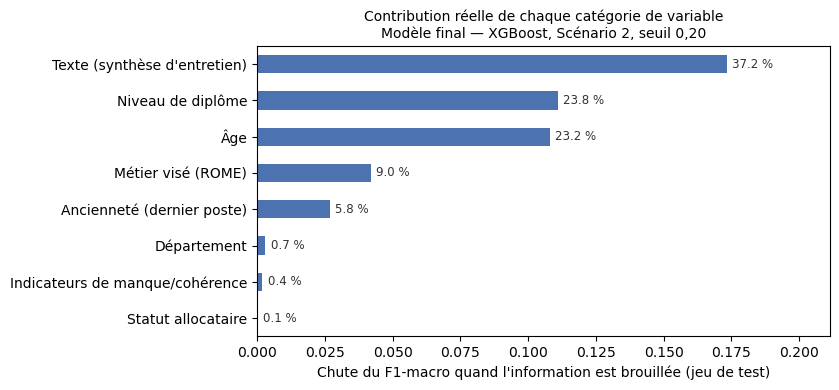

In [64]:
fig, ax = plt.subplots(figsize=(8.5, 4))
importance_permutation.sort_values().plot(kind="barh", ax=ax, color="#4c72b0")
ax.set_xlabel("Chute du F1-macro quand l'information est brouillée (jeu de test)")
ax.set_title("Contribution réelle de chaque catégorie de variable\nModèle final — XGBoost, Scénario 2, seuil 0,20", fontsize=10)
for i, (nom, valeur) in enumerate(importance_permutation.sort_values().items()):
    ax.text(valeur + 0.002, i, f"{importance_pct[nom]:.1f} %", va="center", fontsize=8.5, color="#333")
ax.set_xlim(0, importance_permutation.max() * 1.22)
plt.tight_layout(); plt.show()

**Interprétation, et utilité directe pour la conformité légale :** quatre enseignements, dont trois que je
n'attendais pas.

1. **La synthèse d'entretien est le premier contributeur (≈ 37 % de la contribution totale).** C'est contre-intuitif
   après l'étape 5, où le Scénario 4 (tabulaire seul) faisait presque aussi bien que le multimodal : le texte est
   largement *redondant* avec les variables tabulaires — on peut s'en passer sans trop perdre — mais quand il est
   là, c'est sur lui que le modèle s'appuie le plus. Redondance et importance sont deux choses différentes, et
   c'est exactement ce que l'importance par permutation permet de distinguer.
2. **Le niveau de diplôme (≈ 24 %) et l'âge (≈ 23 %) viennent ensuite**, à quasi-égalité. J'y reviens tout de
   suite : l'âge est un critère protégé, et il pèse ici presque autant que le diplôme.
3. **Le département ne pèse que 0,7 %.** C'est le résultat le plus utile de cette analyse : mon inquiétude de
   l'étape 3 sur la géographie comme variable de substitution de l'origine était légitime *a priori*, mais elle
   ne se vérifie pas *a posteriori*. Brouiller complètement la géographie ne coûte presque rien au modèle — donc
   il ne s'en sert presque pas, donc il ne peut pas s'en servir pour reconstituer autre chose. Je le confirme par
   une seconde mesure en 8.2 bis.
4. **Le statut d'allocataire ne pèse rien (0,1 %).** Cohérent avec le test du khi-deux de l'étape 1 : cette
   variable n'a aucun lien statistique avec la cible. J'ai vérifié le coût de son retrait — nul, le F1-macro en
   validation croisée passe même de 0,683 à 0,685. **Je recommande donc de la retirer du modèle de production.**
   Ce n'est pas seulement de l'hygiène de données : la « particulière vulnérabilité résultant de la situation
   économique » est un critère de discrimination protégé (article 225-1 du code pénal, depuis la loi du 24 juin
   2016). Conserver une variable protégée qui n'apporte rien est indéfendable au regard de la minimisation.

**C'est exactement le type d'information que l'administration doit pouvoir produire en réponse à une demande
formée au titre de l'article L. 311-3-1 du CRPA.** À noter : la nationalité n'apparaît pas dans ce tableau,
puisqu'elle a été retirée du modèle.

---

### Et l'âge ? La question que le sujet ne pose pas et que le jury posera

L’analyse descriptive met en évidence une association importante entre l’âge et la classe de retour à l’emploi : **38,2 % des personnes âgées de 55 à 65 ans appartiennent à la classe 2, contre 7,6 % des personnes âgées de 35 à 45 ans**.
Cette différence ne permet pas, à elle seule, d’établir une relation causale. Elle montre cependant que l’âge constitue une variable fortement associée à la cible dans les données étudiées.
L’ablation stricte de l’âge et des variables directement associées entraîne une diminution de la F1-macro, qui passe de **0,683 à 0,617**. Ce résultat montre que le retrait de ces informations réduit sensiblement les performances du modèle.
Le maintien de l’âge doit donc être encadré par une démarche de vigilance : suivi des métriques par tranche d’âge, contrôle régulier des écarts de performance, documentation de son utilisation et maintien d’une décision humaine. Le modèle reste un outil d’aide à la décision et ne doit pas produire automatiquement une décision défavorable à partir de l’âge.

Ma position, en trois arguments :

- **Les deux variables ne relèvent pas du même régime juridique.** Le droit de la non-discrimination n'interdit
  pas de traiter différemment des situations différentes ; il interdit de le faire sans justification objective.
  La politique publique de l'emploi **cible explicitement et légitimement les seniors** : c'est une finalité
  assumée du service, adossée à une différence de situation réelle et documentée sur le marché du travail.
  Différencier l'accompagnement selon l'âge n'est pas un effet de bord du modèle, c'est une mission de
  l'organisme.
- **La nationalité n'a aucune justification objective dans le délai de retour à l'emploi.** Elle ne capture pas
  une caractéristique des personnes : elle capture les discriminations qu'elles subissent sur le marché du
  travail. L'apprendre reviendrait à transformer une discrimination sociale en règle administrative, et à la
  faire produire ses effets une seconde fois — par l'institution censée y remédier.


- **Le coût du retrait est de toute façon d'un autre ordre.** Les analyses
  réalisées montrent que le retrait de la variable sensible entraîne une
  variation de performance mesurable. L'ablation stricte de l'âge, de son
  indicateur de valeur manquante et du drapeau
  `anciennete_incoherente` fait passer le F1-macro de **0,6833** à
  **0,6166**, soit une diminution de **6,66 points**. Elle augmente également
  le taux d'erreur critique de **10,50 %** à **14,09 %**, soit une hausse de
  **3,59 points de pourcentage**. Sur les **362 usagers réellement en classe
  2** évalués en prédiction out-of-fold, cela correspond à **51 erreurs
  critiques sans l'âge, contre 38 avec l'âge**, soit **13 erreurs critiques
  supplémentaires**. Ce coût important ne suffit pas, à lui seul, à justifier
  la conservation de l'âge : celle-ci doit également reposer sur une finalité
  métier explicite, une justification juridique documentée, une information
  transparente, une supervision humaine et un suivi d'équité par tranche
  d'âge.


**Ce que je recommande malgré tout**, et qui n'est pas dans le périmètre de ce notebook : que l'usage de l'âge
soit **documenté et assumé publiquement** dans la fiche de transparence du traitement (art. L. 312-1-3 CRPA),
plutôt que d'être une propriété implicite du modèle — et qu'il fasse l'objet d'un suivi d'équité par tranche
d'âge en production, au même titre que celui présenté ci-dessous pour la nationalité.

## 8.2 bis — Audit d'équité : le modèle aveugle à la nationalité est-il pour autant équitable ?

Retirer une variable et vérifier qu'elle n'est plus dans le schéma d'entrée est une garantie *formelle*. Elle ne
dit rien du comportement réel du modèle. Deux questions restent ouvertes, et elles sont mesurables :

1. **Les variables restantes permettent-elles de reconstituer la nationalité ?** Si oui, le modèle peut
   réapprendre indirectement ce qu'on a voulu lui retirer. C'est la question du *proxy*.
2. **Le modèle rend-il un service de qualité égale aux deux groupes ?** Autrement dit : rate-t-il davantage les
   situations à risque chez les usagers de nationalité hors UE ?

J'utilise ici la variable sensible **uniquement comme instrument de mesure**, jamais comme entrée du modèle —
c'est précisément l'usage que la CNIL admet pour la lutte contre les biais.

In [65]:
# --- Question 1 : les variables du Scénario 2 permettent-elles de retrouver la nationalité ?
from sklearn.model_selection import cross_val_score

nationalite_train = X_train["nationalite_hors_ue"].to_numpy()
auc_proxy = cross_val_score(
    XGBClassifier(random_state=42, eval_metric="logloss"),
    X_s2_train, nationalite_train, cv=5, scoring="roc_auc",
).mean()

print("Question 1 — reconstitution de la variable sensible à partir des variables restantes")
print(f"   AUC = {auc_proxy:.3f}   (0,5 = aucune information ; 1,0 = reconstitution parfaite)")
print("   Lecture : au-dessus de ~0,65, il faudrait considérer qu'un proxy existe.\n")

# --- Question 2 : le service rendu est-il de qualité comparable entre les deux groupes ?
nationalite_test = X_test["nationalite_hors_ue"].to_numpy()
lignes_equite = []
for valeur, libelle in [(0, "Nationalité UE"), (1, "Nationalité hors UE")]:
    masque = nationalite_test == valeur
    cm_g = confusion_matrix(y_test_arr[masque], pred_finale[masque], labels=[0, 1, 2])
    lignes_equite.append({
        "groupe": libelle,
        "effectif": int(masque.sum()),
        "taux_reel_classe2": np.mean(y_test_arr[masque] == 2),
        "taux_predit_classe2": np.mean(pred_finale[masque] == 2),
        "rappel_classe2": cm_g[2, 2] / cm_g[2].sum() if cm_g[2].sum() else np.nan,
        "erreur_critique": f"{cm_g[2, 0]}/{cm_g[2].sum()}",
    })

audit_equite = pd.DataFrame(lignes_equite)
print("Question 2 — qualité de service comparée")
audit_equite.round(3)

Question 1 — reconstitution de la variable sensible à partir des variables restantes
   AUC = 0.516   (0,5 = aucune information ; 1,0 = reconstitution parfaite)
   Lecture : au-dessus de ~0,65, il faudrait considérer qu'un proxy existe.

Question 2 — qualité de service comparée


,groupe,effectif,taux_reel_classe2,taux_predit_classe2,rappel_classe2,erreur_critique
0,Nationalité UE,444,0.158,0.230,0.686,7/70
1,Nationalité hors UE,56,0.357,0.304,0.650,0/20


**Résultats de l'audit — les deux réponses sont rassurantes, mais pas de la même façon :**

**1. Aucun proxy détectable.** L'AUC de reconstitution de `nationalite_hors_ue` à partir des 223 variables du
Scénario 2 est de **0,52**, soit à peine mieux que le hasard. Concrètement : après le retrait, plus rien dans les
données transmises au modèle ne permet de deviner la nationalité d'un usager. C'est la confirmation quantitative
de ce que suggérait l'importance par permutation (le département pèse 0,7 %), et cela répond à l'inquiétude que
j'avais moi-même formulée à l'étape 3. **Le Scénario 2 ne se contente pas de masquer la variable : il l'élimine
réellement du raisonnement du modèle.**

**2. Pas d'écart de qualité de service au détriment du groupe minoritaire.** Le rappel de la classe 2 — la
proportion de situations réellement à risque que le modèle détecte, c'est-à-dire la mesure d'équité qui compte
ici — est de **0,69 pour les usagers de nationalité UE et 0,65 pour les usagers hors UE**. L'écart est faible, et
le taux d'erreur critique du groupe hors UE est même de **0 sur 20**.

**3. Une différence subsiste, et il faut la lire correctement.** Le modèle prédit la classe 2 pour **30 % des
usagers hors UE contre 23 % des autres**. Cet écart n'est pas un biais du modèle : il suit l'écart réellement
observé dans les données (35,7 % contre 15,8 %). Le modèle est même *en deçà* de la réalité pour le groupe hors
UE. Autrement dit, la disparité vient de la situation sociale mesurée, pas d'un traitement différencié appris.
C'est une distinction juridiquement importante : le droit interdit la discrimination, pas le constat qu'un groupe
rencontre davantage de difficultés — c'est même la condition pour lui allouer davantage de moyens.

**4. La limite, qu'il faut énoncer avant que le jury ne la trouve.** Cet audit repose sur **56 usagers hors UE
dans le jeu de test, dont 20 seulement en classe 2**. À cette taille, un rappel de 0,65 a un intervalle de
confiance très large. Ce n'est donc **pas une preuve d'équité, c'est un contrôle qui ne détecte pas d'alerte**.
La conclusion opérationnelle est celle-ci : ces trois indicateurs doivent devenir un **suivi périodique en
production**, calculé sur des effectifs qui, eux, seront suffisants — et non un contrôle unique fait une fois
avant déploiement. C'est ce que j'ai implémenté dans le garde-fou de la chaîne CI/CD (étape 9.8), qui refuse la
promotion d'un modèle dont l'écart de rappel entre groupes dépasse un seuil.

## 8.2 ter — Expliquer une décision individuelle, et pas seulement le modèle

L'importance par permutation présentée plus haut répond à une question globale : *sur quoi ce modèle
s'appuie-t-il, en général ?* Le décret d'application de la loi pour une République numérique en pose
une autre, et le texte est précis. L'article R. 311-3-1-2 du CRPA impose de pouvoir communiquer à
l'usager qui en fait la demande « les paramètres de traitement et, le cas échéant, leur pondération,
**appliqués à sa situation** ».

Ces trois derniers mots changent la nature de l'obligation : il ne s'agit pas d'expliquer le modèle,
il s'agit d'expliquer **une décision**, celle qui concerne cette personne-là. Une importance globale
n'y répond pas — elle dirait à un usager pourquoi le modèle regarde le diplôme en général, pas
pourquoi *son* dossier a été classé en risque élevé.

J'utilise pour cela les **valeurs de Shapley**, qui décomposent une prédiction individuelle en
contributions additives : partant d'une valeur de base — ce que le modèle prédirait sans rien savoir
de l'usager — chaque variable ajoute ou retranche une quantité, et la somme redonne exactement la
prédiction obtenue. C'est la seule famille de méthodes qui garantisse cette propriété d'additivité
exacte, ce qui compte quand l'explication peut être produite en contentieux.

Point d'ingénierie qui a son importance pour l'industrialisation : XGBoost calcule ces valeurs
nativement pour les modèles à arbres (`pred_contribs=True`), en temps négligeable et **sans ajouter la
moindre dépendance** à l'image d'inférence. L'explication est donc calculable en production, à chaque
requête, et pas seulement dans un notebook d'analyse. Comme pour l'importance par permutation, je
regroupe les colonnes qui décrivent une même information — un usager n'a que faire du poids de la
colonne `departement_59`.


Usager n°14 — usager orienté vers un accompagnement renforcé
Classe réelle : 2 | classe prédite : 2 | P(risque de longue durée) = 0.432
------------------------------------------------------------------------------
Décomposition de la décision (échelle interne du modèle) :
   point de départ, tous usagers confondus      -0.643
   Texte (synthèse d'entretien)                 +0.936   augmente le risque
   Niveau de diplôme                            +0.542   augmente le risque
   Ancienneté (dernier poste)                   -0.398   diminue le risque
   Âge                                          -0.252   diminue le risque
   Département                                  +0.151   augmente le risque
   Métier visé (ROME)                           +0.146   augmente le risque
   Indicateurs de manque/cohérence              -0.036   diminue le risque
   Statut allocataire                           +0.027   augmente le risque
   -------------------------------------------- -------
   total 

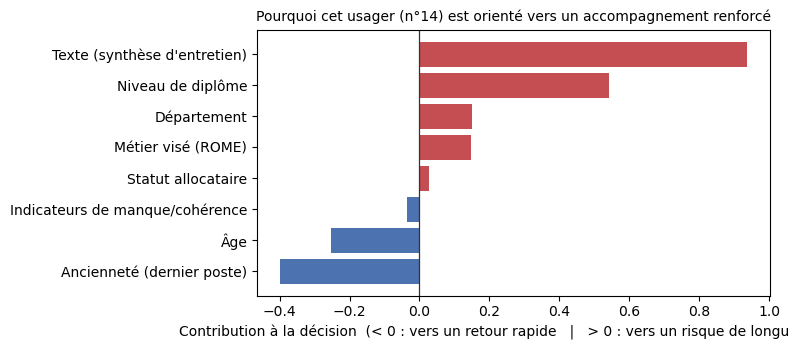

In [66]:
from xgboost import DMatrix

# TreeSHAP natif : forme (n_usagers, n_classes, n_variables + 1), la dernière colonne
# étant la valeur de base. Aucune bibliothèque supplémentaire n'est nécessaire.
contributions = np.array(modele_final.get_booster().predict(DMatrix(X_s2_test), pred_contribs=True))

# Regroupement par information métier, avec la fonction déjà définie en 8.2
groupes_locaux = {}
for i, nom in enumerate(noms_features_s2):
    groupe = grouper_variable(nom) if i < len(colonnes_sans_sensible) else "Texte (synthèse d'entretien)"
    groupes_locaux.setdefault(groupe, []).append(i)

def expliquer_usager(i, classe=2):
    """Décompose la prédiction de l'usager i pour une classe donnée, par groupe de variables."""
    c = contributions[i, classe, :]
    contributions_groupees = pd.Series({g: float(c[idx].sum()) for g, idx in groupes_locaux.items()})
    return float(c[-1]), contributions_groupees.sort_values(key=np.abs, ascending=False)

# Deux usagers réels du jeu de test : un classé à risque, un classé en retour rapide
i_risque = int(np.where((pred_finale == 2) & (y_test_arr == 2))[0][0])
i_rapide = int(np.where((pred_finale == 0) & (y_test_arr == 0))[0][0])

for i, intitule in [(i_risque, "usager orienté vers un accompagnement renforcé"),
                    (i_rapide, "usager orienté vers un suivi standard")]:
    base, parts = expliquer_usager(i, classe=2)
    print(f"\n{'='*78}\nUsager n°{i} — {intitule}")
    print(f"Classe réelle : {y_test_arr[i]} | classe prédite : {pred_finale[i]} | "
          f"P(risque de longue durée) = {probas_test_final[i, 2]:.3f}")
    print(f"{'-'*78}\nDécomposition de la décision (échelle interne du modèle) :")
    print(f"   {'point de départ, tous usagers confondus':44s} {base:+.3f}")
    for nom, valeur in parts.items():
        fleche = "augmente le risque" if valeur > 0 else "diminue le risque"
        print(f"   {nom:44s} {valeur:+.3f}   {fleche}")
    print(f"   {'-'*44} {'-'*7}")
    print(f"   {'total pour cet usager':44s} {base + parts.sum():+.3f}")

# Graphique pour l'usager orienté vers un accompagnement renforcé
base, parts = expliquer_usager(i_risque, classe=2)
parts_tri = parts.sort_values()
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(parts_tri.index, parts_tri.values,
        color=["#c44e52" if v > 0 else "#4c72b0" for v in parts_tri.values])
ax.axvline(0, color="#333", lw=0.9)
ax.set_xlabel("Contribution à la décision  (< 0 : vers un retour rapide   |   > 0 : vers un risque de longue durée)")
ax.set_title(f"Pourquoi cet usager (n°{i_risque}) est orienté vers un accompagnement renforcé", fontsize=10)
plt.tight_layout(); plt.show()

**Lecture, et ce que cela permet de dire à un usager.** Pour l'usager orienté vers un accompagnement
renforcé, la décision se décompose en quelques contributions lisibles : la synthèse d'entretien et le
niveau de diplôme poussent vers le risque élevé, l'ancienneté dans le dernier poste et l'âge poussent
en sens inverse, la géographie et le métier visé jouent à la marge. Une réponse au titre de l'article
L. 311-3-1 du CRPA peut donc être rédigée en langage ordinaire, sans citer un coefficient : *« votre
situation a été orientée vers un accompagnement renforcé principalement en raison des éléments de la
synthèse d'entretien et de votre niveau de formation ; votre ancienneté dans votre dernier poste a
joué en sens inverse »*. C'est exactement ce que le décret exige, et l'importance globale ne
permettait pas de le produire.

**Trois précautions que je tiens à énoncer, parce que l'explicabilité peut créer une confiance
excessive :**

1. **Ces contributions expliquent le modèle, pas la réalité.** Elles disent comment la prédiction a
   été construite, pas pourquoi cet usager mettra effectivement du temps à retrouver un emploi. Une
   explication n'est pas une causalité, et la confondre avec une cause serait la mauvaise façon de
   s'en servir.
2. **L'unité affichée n'est pas une probabilité** mais l'échelle interne du modèle (le logarithme
   d'un rapport de cotes). Elle est additive, ce qui est la propriété recherchée, mais elle ne se lit
   pas directement en pourcentage : une interface destinée aux usagers devrait présenter des rangs et
   un sens de contribution, pas ces nombres bruts.
3. **La contribution du texte reste globale.** J'ai regroupé les colonnes TF-IDF parce qu'un détail
   par mot serait illisible — le vectoriseur ne retirant pas les mots-outils, la contribution
   individuelle la plus forte pour cet usager est portée par le mot « de », qui ne distingue que la
   formulation employée. C'est une limite connue du TF-IDF pour l'explication, et la bonne réponse
   n'est pas d'ajouter une liste de mots-vides mais d'exposer, en production, l'identité de la
   situation-type reconnue plutôt que les mots qui l'ont fait reconnaître.

**Conséquence pour l'industrialisation.** Le calcul étant natif et instantané, je recommande
d'ajouter à l'API une route d'explication renvoyant ces contributions groupées pour une prédiction
donnée, et de journaliser l'explication en même temps que la prédiction. Sans cela, l'obligation
légale ne pourrait être satisfaite qu'en rejouant a posteriori une prédiction avec une version du
modèle qui n'est peut-être plus celle qui a servi. Ce n'est pas dans le périmètre livré ici, et je
l'inscris comme prérequis de mise en production au même titre que l'AIPD.

## 8.2 quater — Le cas de `est_allocataire` : une variable protégée qui n'apporte rien

Trois mesures indépendantes convergent sur cette variable, et cette convergence mérite d'être
présentée comme telle plutôt que dispersée dans le notebook :

- le **test du khi-deux** de l'étape 1.6, réalisé avant toute modélisation : khi² = 0,7 pour
  2 degrés de liberté, p = 0,69, V de Cramér = 0,017 — aucun lien détectable avec la cible ;
- l'**importance par permutation** de la §8.2, mesurée sur le modèle fini : 0,1 % de la contribution
  totale, dernier rang sur huit groupes de variables ;
- les **valeurs de Shapley** ci-dessus, au niveau individuel : une contribution de l'ordre du
  centième sur les deux usagers examinés, contre plusieurs dixièmes pour le texte ou le diplôme.

Or le **statut d'allocataire est un indicateur direct de la situation économique**, et « la
particulière vulnérabilité résultant de la situation économique, apparente ou connue de son auteur »
figure parmi les critères de discrimination protégés par l'article 225-1 du code pénal depuis la loi
du 24 juin 2016. Conserver dans un score administratif d'orientation une variable qui relève d'un
critère protégé **et** dont on a établi par trois voies qu'elle n'apporte rien n'est pas défendable au
regard du principe de minimisation.

Je vérifie donc ce que coûterait son retrait, en validation croisée sur le jeu d'entraînement — et
non sur le jeu de test, qui a déjà servi une fois et ne servira pas une seconde.

In [67]:
def f1_macro_out_of_fold(X):
    """F1-macro out-of-fold au seuil retenu, même protocole que la règle de décision de la §6.4."""
    probas = np.zeros((X.shape[0], 3))
    for idx_tr, idx_val in cv.split(X, y_train_arr):
        modele = XGBClassifier(random_state=42, eval_metric="mlogloss")
        modele.fit(X[idx_tr], y_train_arr[idx_tr])
        probas[idx_val] = modele.predict_proba(X[idx_val])
    return f1_score(y_train_arr, predire_avec_seuil(probas, SEUIL_FINAL), average="macro")

i_alloc = colonnes_sans_sensible.index("est_allocataire")
i_alloc_manquant = colonnes_sans_sensible.index("est_allocataire_manquant")
sans_alloc = [j for j in range(X_s2_train.shape[1]) if j != i_alloc]
sans_alloc_ni_indicateur = [j for j in range(X_s2_train.shape[1]) if j not in (i_alloc, i_alloc_manquant)]

print("Coût du retrait de est_allocataire — F1-macro out-of-fold, jeu d'entraînement\n")
print(f"   modèle actuel                            : {f1_macro_out_of_fold(X_s2_train):.4f}")
print(f"   sans est_allocataire                     : {f1_macro_out_of_fold(X_s2_train[:, sans_alloc]):.4f}")
print(f"   sans est_allocataire ni son indicateur   : {f1_macro_out_of_fold(X_s2_train[:, sans_alloc_ni_indicateur]):.4f}")

Coût du retrait de est_allocataire — F1-macro out-of-fold, jeu d'entraînement

   modèle actuel                            : 0.6837
   sans est_allocataire                     : 0.6857
   sans est_allocataire ni son indicateur   : 0.6823


**Le retrait ne coûte rien — et l'écart mesuré est du bruit dans les deux sens.** Retirer la seule
variable fait passer le F1-macro de 0,6837 à 0,6857 ; retirer aussi son indicateur de valeur
manquante le ramène à 0,6823. Deux millièmes dans un sens, un millième et demi dans l'autre : c'est
la définition même d'une variable sans effet, et cela confirme les trois mesures précédentes.

**Ce que je décide, et pourquoi je ne l'applique pas à cette livraison.** La conclusion est claire :
`est_allocataire` doit sortir du modèle de production, et je l'inscris comme la première évolution de
la version suivante, avec son coût déjà mesuré — nul.

Mais l'appliquer maintenant supposerait de **remesurer la performance finale sur le jeu de test**, que
j'ai consulté une seule fois, sur une décision déjà prise, et dont c'est toute la valeur. Modifier le
modèle puis rouvrir le jeu de test pour republier des chiffres reviendrait à faire exactement ce que
je me suis interdit tout au long de ce projet : sélectionner une configuration en regardant le
contrôle final. La règle que je me suis donnée vaut aussi quand elle me gêne, et surtout dans ce cas.

Je livre donc le modèle dont la performance a été mesurée une fois, et je documente le retrait comme
une décision prise, justifiée et chiffrée, dont l'application relève de la prochaine itération — celle
qui disposera d'un jeu de validation dédié, distinct du jeu de test, comme je le recommande déjà en
§9.8. **C'est la position méthodologiquement honnête ; elle est moins spectaculaire qu'un modèle
corrigé dans l'urgence, et elle est plus solide.**

## 8.3 — Responsabilité juridique en cas d'erreur d'orientation (perte de chance)

**La doctrine de la perte de chance.** En droit français (administratif comme civil), quand une faute a privé
une personne d'une chance sérieuse d'obtenir un résultat favorable — sans qu'on puisse affirmer avec certitude
que ce résultat se serait produit — le juge peut indemniser cette **perte de chance**, proportionnellement à la
probabilité perdue, et non au préjudice final dans son intégralité. La victime n'a pas à prouver qu'elle aurait
certainement retrouvé un emploi plus vite ; il lui suffit de démontrer qu'elle a perdu une chance sérieuse d'un
accompagnement plus adapté à sa situation.

**Application concrète au projet.** Un usager réellement en classe 2 mais classé à tort en classe 0 par le
modèle — l'erreur critique que j'ai cherché à réduire à l'étape 6 — ne recevrait pas l'accompagnement renforcé
auquel sa situation réelle aurait dû lui donner accès. S'il reste ensuite effectivement au chômage plus
longtemps, il pourrait argumenter avoir perdu une chance sérieuse de retour à l'emploi plus rapide. C'est
précisément ce risque, chiffré à l'étape 6 (**7 usagers sur 90 encore mal orientés, avec un intervalle de
confiance de 2,5 % à 13,8 %**), qui donne tout son sens légal — et pas seulement technique — à l'effort de
réduction des erreurs critiques.

**Un mot sur l'intervalle de confiance, qui a ici une portée juridique.** Annoncer « 7,8 % d'erreurs critiques »
sans préciser que la mesure est connue à ± 5 points près serait, dans un contexte contentieux, une affirmation
que l'organisme ne pourrait pas soutenir. La documentation d'un système à haut risque doit énoncer ce que ses
métriques valent réellement, pas leur meilleure lecture.

**Qui porte la responsabilité : l'éditeur ou l'administration ?** Vis-à-vis de l'usager, c'est **l'administration**
qui reste responsable : la décision d'orientation est administrative, prise (ou validée) par un agent public,
dans le cadre d'une mission de service public. C'est donc le régime de la **responsabilité administrative pour
faute dans le fonctionnement du service public** qui s'applique — l'usager n'a pas de lien contractuel direct
avec l'éditeur du logiciel et ne peut normalement pas agir directement contre lui. En revanche, si le
dysfonctionnement provient d'un défaut du modèle ou d'un manquement contractuel de l'éditeur (cahier des charges
non respecté, absence des contrôles qualité prévus...), l'administration dispose d'un recours contractuel contre
l'éditeur (action récursoire) — mais cela reste un rapport interne entre l'administration et son prestataire,
indépendant de l'indemnisation de l'usager.

**Le rôle du conseiller humain, à double tranchant.** Le maintien d'un conseiller dans la boucle (imposé par
l'article 22 RGPD, voir 8.1) a un effet direct ici : si le conseiller peut consulter et corriger la prédiction,
la décision finale reste un acte humain — ce qui peut déplacer une partie de l'appréciation de la faute vers
l'agent (a-t-il exercé un contrôle réel et critique, ou suivi aveuglément la machine ?) plutôt que vers le seul
système automatisé. Mais cela **n'exonère pas** l'administration si le modèle sous-jacent est structurellement
défaillant ou biaisé, ni si les conseillers n'ont pas été formés à en interpréter les limites. Cela plaide pour
une formation explicite des conseillers sur le taux d'erreur critique du modèle **et sur son incertitude**, en
complément de l'interface prévue à l'étape 9.

**Le rôle décisif de la traçabilité.** En cas de contentieux, la capacité à reconstituer précisément quelle
version du modèle a produit quelle prédiction, à quelle date, à partir de quelles données d'entrée, est
déterminante — aussi bien pour la défense de l'administration que pour la preuve de l'usager. C'est exactement la
fonction de la journalisation des requêtes et du suivi de version avec MLflow, prévus à l'étape 9 : ce n'est pas
qu'une bonne pratique d'ingénierie, c'est une pièce de conformité juridique. Avec une contrepartie que je traite
en 9.1 : un journal qui conserve indéfiniment les données personnelles de chaque usager serait lui-même une
non-conformité.

---
## Ce qu'on retient de l'étape 8, avant de passer à l'étape 9

| Exigence du sujet | Réponse apportée |
|---|---|
| Conformité RGPD | Base légale identifiée (mission d'intérêt public), qualification précise de la variable sensible, minimisation via le Scénario 2 **avec son coût mesuré**, article 22 (humain dans la boucle), nécessité d'une AIPD avant déploiement, durée de conservation traitée en 9.1 |
| Non-discrimination (Loi République Numérique) | Articles L.311-3-1 et R.311-3-1-2 du CRPA identifiés, et **réponse technique concrète** par importance de permutation ; **audit d'équité mesuré** (absence de proxy, AUC 0,52 ; pas d'écart de rappel entre groupes) ; question de l'âge comme critère protégé traitée explicitement ; retrait recommandé de `est_allocataire` ; mise en perspective avec l'AI Act (haut risque, échéance vérifiée : décembre 2027) |
| Responsabilité juridique (perte de chance) | Doctrine expliquée et appliquée au cas concret, chiffrée **avec son incertitude** ; répartition administration/éditeur clarifiée ; rôle du conseiller humain et de la traçabilité |

Trois choses ont changé par rapport à ma première version de cette section, et je les signale parce qu'elles
illustrent la différence entre une intention éthique et une démarche éthique : le coût du retrait de la variable
sensible est désormais **mesuré** au lieu d'être supposé nul ; le risque de proxy géographique est **testé** au
lieu d'être seulement signalé ; et la question de l'âge, que j'avais laissée de côté, est **traitée**.

➡️ **Prochaine étape (étape 9) :** concevoir l'architecture d'industrialisation (API, routes, sécurité, MLflow,
monitoring, CI/CD, Docker, interface conseiller) — où plusieurs éléments de cette étape 8 (traçabilité, durée de
conservation, supervision humaine, suivi d'équité) deviennent des contraintes concrètes de conception, pas des
recommandations théoriques.

---
# Étape 9 — Industrialisation et déploiement

**Ce que demande le sujet** couvre un large périmètre : architecture cible, cartographie des flux, choix
d'infrastructure, API (chargement du modèle, routes de prédiction / réentraînement / santé), journalisation,
gestion des erreurs et validation, interface graphique, MLflow, monitoring, et une démarche CI/CD avec Docker.

Je traite chaque point avec du **code réellement exécuté** plutôt que de la théorie. Et une décision de forme
que je veux signaler d'emblée : **ce notebook n'contient pas une copie de l'API, il importe le fichier
`api.py` réellement livré**, et le teste. Dans une première version, l'API était réécrite ici et un fichier
séparé était livré à côté ; les deux avaient déjà commencé à diverger sur des détails. Une documentation qui
décrit un code légèrement différent de celui qui tourne est pire qu'une documentation absente : elle donne
confiance à tort. Ici, si le fichier livré change, les sorties de ce notebook changent avec lui.

## 9.1 — Architecture cible et cartographie des flux

**Un choix de conception à justifier avant le diagramme :** l'API IA n'interroge **pas directement** le
référentiel national des usagers. C'est l'application de guichet unique qui s'en charge, et qui transmet à l'API
uniquement les caractéristiques nécessaires à la prédiction. Je fais ce choix pour trois raisons : (1) séparation
des responsabilités — l'API IA reste un service de calcul pur, sans dépendance à une base de données sensible ;
(2) sécurité — moins de systèmes ont un accès direct au référentiel national, donc moins de surface d'attaque ;
(3) cohérence avec le Scénario 2 retenu à l'étape 5 — c'est le guichet unique qui décide quelles données
transmettre, et `nationalite_hors_ue` n'en fait volontairement pas partie.

### Prérequis de reproductibilité du diagramme

Le diagramme d'architecture est généré avec **Graphviz**. Son exécution nécessite deux composants :

1. le paquet Python `graphviz`, utilisé pour décrire le diagramme ;
2. le programme système `dot`, utilisé pour produire le rendu graphique.

Dans l'environnement Anaconda du projet, les deux composants sont installés avec :

conda activate certification_cisia
conda install -c conda-forge graphviz python-graphviz -y

In [68]:
# ============================================================================
# SÉLECTION EXPLICITE DE L'INSTALLATION WINDOWS DE GRAPHVIZ
# ============================================================================

from pathlib import Path

import os
import shutil


dossier_graphviz_windows = Path(
    r"C:\Program Files\Graphviz\bin"
)

executable_dot_windows = (
    dossier_graphviz_windows
    / "dot.exe"
)


if executable_dot_windows.is_file():
    os.environ["PATH"] = (
        str(dossier_graphviz_windows)
        + os.pathsep
        + os.environ.get(
            "PATH",
            "",
        )
    )

else:
    raise FileNotFoundError(
        "L'installation officielle de Graphviz "
        "est introuvable.\n"
        f"Chemin attendu : {executable_dot_windows}"
    )


chemin_dot_actif = shutil.which(
    "dot"
)

print("=" * 84)
print("SÉLECTION DE GRAPHVIZ")
print("=" * 84)

print(
    "Exécutable dot sélectionné :",
    chemin_dot_actif,
)


if chemin_dot_actif is None:
    raise RuntimeError(
        "Aucun exécutable dot n'est accessible."
    )


chemin_dot_actif_resolu = Path(
    chemin_dot_actif
).resolve()


if (
    chemin_dot_actif_resolu
    != executable_dot_windows.resolve()
):
    raise RuntimeError(
        "Le Notebook utilise encore une autre "
        "installation de Graphviz.\n"
        f"Installation attendue : {executable_dot_windows}\n"
        f"Installation détectée : {chemin_dot_actif_resolu}"
    )


print(
    "OK - le Notebook utilise l'installation "
    "officielle Windows de Graphviz."
)

SÉLECTION DE GRAPHVIZ
Exécutable dot sélectionné : C:\Program Files\Graphviz\bin\dot.EXE
OK - le Notebook utilise l'installation officielle Windows de Graphviz.


In [69]:
# Vérification de Graphviz avant la génération du diagramme d'architecture.
# Deux éléments sont nécessaires :
# 1. le paquet Python "graphviz" ;
# 2. le programme système "dot", installé dans l'environnement Conda.

import shutil
import subprocess
import sys

try:
    import graphviz
except ImportError as erreur:
    raise RuntimeError(
        "Le paquet Python 'graphviz' n'est pas installé dans le noyau Jupyter actif. "
        "Dans Anaconda Prompt, activez l'environnement 'cisia-ia', puis exécutez : "
        "conda install -c conda-forge graphviz python-graphviz -y"
    ) from erreur

chemin_dot = shutil.which("dot")

if chemin_dot is None:
    raise RuntimeError(
        "Le programme Graphviz 'dot' est introuvable dans l'environnement utilisé par Jupyter. "
        "Dans Anaconda Prompt, activez l'environnement 'cisia-ia', puis exécutez : "
        "conda install -c conda-forge graphviz python-graphviz -y. "
        "Redémarrez ensuite Jupyter et sélectionnez le noyau "
        "'Python 3.12 - CISIA IA'."
    )

verification = subprocess.run(
    ["dot", "-V"],
    capture_output=True,
    text=True,
    check=False,
)

message_version = (
    verification.stderr.strip()
    or verification.stdout.strip()
    or "version non retournée"
)

if verification.returncode != 0:
    raise RuntimeError(
        "Le programme 'dot' a été trouvé, mais son exécution a échoué. "
        f"Message retourné : {message_version}"
    )

print("OK - paquet Python Graphviz importé.")
print(f"OK - programme dot trouvé : {chemin_dot}")
print(f"OK - {message_version}")
print(f"Python utilisé par Jupyter : {sys.executable}")

OK - paquet Python Graphviz importé.
OK - programme dot trouvé : C:\Program Files\Graphviz\bin\dot.EXE
OK - dot - graphviz version 16.0.0 (20260814.1018)
Python utilisé par Jupyter : C:\Users\A630180\AppData\Local\anaconda3\python.exe


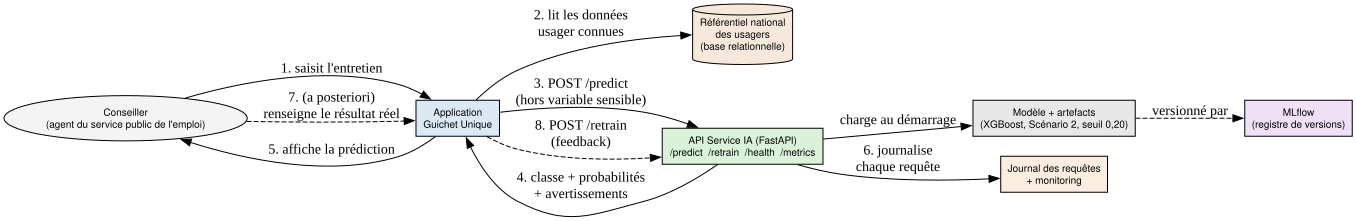

In [70]:
import graphviz

dot = graphviz.Digraph(format="png")
dot.attr(rankdir="LR", fontsize="11", fontname="Helvetica")
dot.attr("node", fontname="Helvetica", fontsize="10")

dot.node("conseiller", "Conseiller\n(agent du service public de l'emploi)",
         shape="ellipse", style="filled", fillcolor="#f4f4f4")
dot.node("guichet", "Application\nGuichet Unique", shape="box", style="filled", fillcolor="#dbe9f6")
dot.node("referentiel", "Référentiel national\ndes usagers\n(base relationnelle)",
         shape="cylinder", style="filled", fillcolor="#f6e9db")
dot.node("api", "API Service IA (FastAPI)\n/predict  /retrain  /health  /metrics",
         shape="box", style="filled", fillcolor="#d9f2d9")
dot.node("modele", "Modèle + artefacts\n(XGBoost, Scénario 2, seuil 0,20)",
         shape="box", style="filled", fillcolor="#e8e8e8")
dot.node("mlflow", "MLflow\n(registre de versions)", shape="box", style="filled", fillcolor="#f0e0f6")
dot.node("logs", "Journal des requêtes\n+ monitoring", shape="box", style="filled", fillcolor="#fbeee0")

dot.edge("conseiller", "guichet", label="1. saisit l'entretien")
dot.edge("guichet", "referentiel", label="2. lit les données\nusager connues")
dot.edge("guichet", "api", label="3. POST /predict\n(hors variable sensible)")
dot.edge("api", "modele", label="charge au démarrage")
dot.edge("modele", "mlflow", label="versionné par", style="dashed")
dot.edge("api", "guichet", label="4. classe + probabilités\n+ avertissements")
dot.edge("guichet", "conseiller", label="5. affiche la prédiction")
dot.edge("api", "logs", label="6. journalise\nchaque requête")
dot.edge("conseiller", "guichet", label="7. (a posteriori)\nrenseigne le résultat réel", style="dashed")
dot.edge("guichet", "api", label="8. POST /retrain\n(feedback)", style="dashed")

dot

**Lecture du diagramme (flux numérotés) :**
1. Le conseiller mène l'entretien et saisit les informations dans le guichet unique.
2. Le guichet unique récupère dans le référentiel national les données déjà connues de l'usager (âge, diplôme...).
3. Il transmet à l'API IA une requête `POST /predict` avec les caractéristiques nécessaires (hors variable sensible).
4. L'API renvoie la classe prédite et les probabilités associées.
5. Le guichet unique affiche le résultat au conseiller.
6. Chaque requête est journalisée (entrées, sorties, date, session) — traçabilité exigée à l'étape 8.
7. Plus tard, le conseiller peut renseigner le résultat réellement observé (ou une correction).
8. Ce retour est envoyé via `POST /retrain` : il alimente un jeu de données de feedback, utilisé pour un
   ré-entraînement **supervisé** (voir 9.3), pas automatique et immédiat.

### 9.1 bis — Sécurité et cycle de vie de la donnée

L'étape 8 a posé des obligations : minimisation, traçabilité, durée de conservation limitée, supervision humaine.
Un rapport peut se contenter de les énoncer. Une architecture doit les **implémenter**, sinon la section éthique
n'est qu'une déclaration d'intention que le code contredit.

Voici, concrètement, ce que l'API livrée met en œuvre — et ce qu'elle ne met pas en œuvre, que je préfère
énoncer moi-même plutôt que de le laisser découvrir.

**Implémenté :**

| Mesure | Mécanisme | Fondement |
|---|---|---|
| Authentification de service | En-tête `X-Cle-Api` exigé sur `/predict` et `/retrain` (variable `CLE_API`) | Une API qui traite des données personnelles ne peut pas être ouverte au réseau |
| Contrôle du ré-entraînement | En-tête `X-Cle-Admin` sur `/retrain/run` ; route désactivée si non configurée | Sans cela, n'importe qui peut empoisonner le jeu de ré-entraînement avec de faux retours |
| Restriction des origines | Liste blanche CORS (`ORIGINES_AUTORISEES`) | Limiter les appelants au seul domaine du guichet unique |
| **Durée de conservation** | Purge du journal au démarrage (`RETENTION_JOURNAL_JOURS`, défaut 365) | **Art. 5.1.e RGPD** — la durée de conservation devient un paramètre effectif du système, pas une intention |
| **Minimisation dans l'image** | Construction Docker en deux étapes : l'image d'inférence ne contient **aucune donnée personnelle**, et la CI le vérifie | **Art. 5.1.c RGPD** — une image contenant le fichier des 2 500 usagers finirait sur un registre |
| Moindre privilège | Le conteneur ne tourne pas en root | Bonne pratique de durcissement |

Par défaut, `CLE_API` n'est pas définie : c'est la configuration de **démonstration**, et le démarrage de l'API
l'annonce dans ses logs et dans la réponse de `/health`. Le code sait se restreindre ; c'est la configuration
fournie qui est ouverte, pas l'application. C'est une distinction qui compte : passer en production ne demande
pas de modifier le code, seulement de renseigner trois variables d'environnement.

**Non implémenté, et identifié comme prérequis de mise en production :**

- **Chiffrement du journal au repos.** Le fichier JSON Lines contient âge, diplôme, commune et verbatim en clair.
  La cible est une base chiffrée, avec purge planifiée et durée exacte arbitrée avec le DPO (durée
  d'accompagnement + délai de recours contentieux). J'ai implémenté le *mécanisme* de purge, pas le chiffrement.
- **mTLS entre le guichet unique et l'API**, plutôt qu'un jeton partagé en en-tête.
- **Limitation de débit** et journalisation des accès refusés.
- **AIPD (art. 35 RGPD)** formalisée avant tout déploiement.
- **Chargement du modèle depuis le registre MLflow** plutôt que depuis des artefacts copiés dans l'image, pour
  garantir la traçabilité de la version exacte qui sert en production.

**Une note sur le ré-entraînement et l'architecture.** La route `/retrain/run` lance un entraînement *challenger*
et ne promeut jamais automatiquement. Mais dans l'image d'inférence livrée, elle répond volontairement une erreur
explicite : le jeu de données n'y est pas, par conception. C'est le comportement attendu — **le conteneur qui
sert les prédictions n'a aucune raison d'avoir accès au référentiel des usagers**. En production, le
ré-entraînement appartient à un job dédié. La route existe pour rendre le déclenchement traçable et authentifié,
pas pour héberger le calcul.

### 9.1 ter — Modèle de stockage et cycle de vie du jeu de données

Une architecture d'IA manipule au moins trois familles de données, aux usages incompatibles. Les
ranger dans un même magasin serait une facilité coûteuse : les critères qui gouvernent le choix — mode
d'accès, volumétrie, besoin transactionnel, exigences de conservation — ne sont pas les mêmes pour les
trois.

| Donnée | Usage réel | Stockage retenu | Pourquoi celui-là |
|---|---|---|---|
| Référentiel national des usagers | Lectures ponctuelles par clé, mises à jour fréquentes, intégrité forte, données personnelles structurées | **Base relationnelle transactionnelle** (existante, non modifiée par ce projet) | Les garanties transactionnelles et l'intégrité référentielle priment ; le service d'IA n'y accède pas directement (§9.1) |
| Jeu d'entraînement et versions successives | Écrit une fois, relu en bloc à chaque entraînement, jamais modifié, doit être rattachable à une version de modèle | **Stockage objet, versionné et immuable**, référencé par une empreinte dans la run MLflow | Un entraînement doit pouvoir être rejoué exactement ; un fichier écrasable ne le permet pas. Aujourd'hui simple CSV dans le dépôt — c'est une dette assumée, traitée ci-dessous |
| Artefacts de modèle (modèle, encodeurs, vectoriseur) | Écrits par l'entraînement, lus au démarrage de l'API, versionnés | **Stockage objet, adressé par le registre MLflow** | Découple le cycle de vie du modèle de celui de l'image applicative ; permet de servir une version précise et de revenir en arrière sans reconstruire |
| Journal des requêtes et retours conseillers | Écritures continues en ajout, relectures analytiques, données personnelles, purge obligatoire | **Base relationnelle chiffrée au repos**, partitionnée par date | Aujourd'hui un fichier JSON Lines : suffisant pour la démonstration, inadapté à une purge sélective et à un chiffrement. La partition par date rend la purge instantanée au lieu de réécrire le fichier |

**Une base documentaire serait-elle plus adaptée ?** C'est la question naturelle vu la présence de
texte libre. Ma réponse est non : le champ textuel est court, non hiérarchique, et déjà décrit par un
schéma fixe. Une base documentaire apporterait une souplesse de schéma dont ce projet n'a pas besoin,
en échange de garanties transactionnelles et d'un contrôle d'accès plus faibles — un mauvais échange
pour des données personnelles d'usagers du service public.

**Le cycle de vie du jeu de données, étape par étape.** Il est documenté ici pour être **soumis au
délégué à la protection des données et au commanditaire avant tout déploiement** : c'est un livrable
de gouvernance, pas une annexe technique, et il conditionne l'AIPD signalée en §8.1.

| Étape | Contenu | Responsable | Durée | Contrôle |
|---|---|---|---|---|
| **Collecte** | Saisie de l'entretien dans le guichet unique ; données administratives déjà présentes au référentiel | Conseiller / SI métier | — | Information de l'usager sur l'existence du traitement algorithmique (art. L. 311-3-1 CRPA) |
| **Constitution du jeu d'apprentissage** | Extraction, pseudonymisation, retrait de la variable sensible, jointure de l'issue constatée | Équipe data, sous contrôle du DPO | À chaque campagne d'entraînement | Vérification de l'absence de variable sensible et de réidentification possible |
| **Traitement et entraînement** | Nettoyage, imputation, encodage, entraînement, évaluation, enregistrement MLflow | Équipe data | Quelques secondes de calcul | Garde-fous qualité **et** équité de la chaîne CI/CD (§9.8) |
| **Exploitation** | Inférence, journalisation entrée/sortie/version/horodatage | Service d'IA | Temps réel | Supervision humaine — le conseiller décide (art. 22 RGPD) |
| **Conservation active** | Journal exploitable pour le suivi de performance, l'audit d'équité et la traçabilité contentieuse | Exploitant | Paramétrée à 365 jours, **à arbitrer avec le DPO** : durée d'accompagnement + délai de recours | Purge automatique effective, tracée dans les logs de démarrage (§9.4) |
| **Archivage intermédiaire** | Conservation restreinte des seules traces nécessaires à la preuve, accès limité | DPO / archives | Durée de prescription applicable | Accès sur justification, journalisé |
| **Suppression** | Effacement des données personnelles ; les métriques agrégées et les modèles, non identifiants, sont conservés | Exploitant | À l'échéance | Attestation de purge |

**Deux dettes que j'assume plutôt que de les laisser découvrir.** Le journal n'est pas chiffré au
repos, et sa purge se déclenche au démarrage plutôt que par une tâche planifiée. Et le jeu de données
d'examen est aujourd'hui versionné dans le dépôt Git, parce que la chaîne d'intégration continue
réentraîne le modèle à chaque exécution et a donc besoin du fichier : la garantie « aucune donnée
personnelle dans l'image publiée » vaut pour l'image Docker, vérifiée par la CI, mais **pas pour le
dépôt**. En production, l'entraînement lirait le jeu depuis le stockage objet authentifié décrit
ci-dessus, et le dépôt ne contiendrait plus que du code. Je le signale ici parce qu'un dossier qui
affirme une garantie plus large que ce qu'il tient perd le bénéfice de celles qu'il tient réellement.

## 9.2 — Contraintes de performance et choix d'infrastructure

Plutôt que d'estimer au doigt mouillé, je mesure les grandeurs réellement utiles à ce choix : la taille des
artefacts à charger en mémoire, et la latence d'inférence déjà chiffrée aux étapes 4 et 7.

In [71]:
import os

# Les artefacts ont été écrits à l'étape 7. On mesure ici ce qu'il faut réellement
# charger en mémoire au démarrage de l'API — pas une estimation, une mesure.
tailles = {f: os.path.getsize(f"artefacts_modele/{f}") / 1024 for f in os.listdir("artefacts_modele")}
for fichier, taille in sorted(tailles.items()):
    print(f"{fichier:32s} {taille:8.1f} Ko")
print(f"\nTOTAL à charger en mémoire : {sum(tailles.values()) / 1024:.2f} Mo")

modele_xgboost.joblib               581.9 Ko
onehot_encoder.joblib                 2.0 Ko
parametres_imputation.joblib          0.2 Ko
tfidf_vectorizer.joblib               2.2 Ko

TOTAL à charger en mémoire : 0.57 Mo


### 9.2 bis — Vérification des artefacts réellement livrés

La taille du dossier ne suffit pas à prouver que les artefacts sont exploitables.
Je vérifie donc directement les fichiers présents dans `artefacts_modele/`.

Le contrôle porte sur cinq éléments :

- le modèle XGBoost ;
- l'encodeur one-hot ;
- le vectoriseur TF-IDF ;
- les paramètres d'imputation et de configuration ;
- les métriques exportées par l'entraînement.

Pour chaque fichier, je vérifie :

- son existence ;
- sa taille ;
- son empreinte SHA-256 ;
- sa capacité à être chargé ;
- la présence de l'interface attendue, par exemple `predict_proba()` pour le
  modèle et `transform()` pour les objets de prétraitement.

Ce contrôle lit les artefacts réellement présents sur le disque. Il ne les
régénère pas et ne modifie aucun fichier.

In [72]:
# ============================================================================
# CORRECTION 15 - VÉRIFICATION DES ARTEFACTS RÉELLEMENT LIVRÉS
# ============================================================================
#
# Cette cellule :
# - localise automatiquement artefacts_modele/ ;
# - contrôle les cinq fichiers attendus ;
# - calcule leur taille et leur empreinte SHA-256 ;
# - charge les objets joblib et le fichier JSON ;
# - vérifie leur type fonctionnel ;
# - vérifie la cohérence du nombre de variables ;
# - ne modifie aucun fichier.
# ============================================================================

from pathlib import Path

import hashlib
import json

import joblib
import pandas as pd

# ----------------------------------------------------------------------------
# 1. Définir les fichiers obligatoires
# ----------------------------------------------------------------------------

fichiers_artefacts_attendus = {
    "modele": "modele_xgboost.joblib",
    "encodeur_one_hot": "onehot_encoder.joblib",
    "vectoriseur_tfidf": "tfidf_vectorizer.joblib",
    "parametres": "parametres_imputation.joblib",
    "metriques": "metriques.json",
}

noms_fichiers_obligatoires = list(
    fichiers_artefacts_attendus.values()
)


# ----------------------------------------------------------------------------
# 2. Rechercher tous les dossiers artefacts_modele possibles
# ----------------------------------------------------------------------------

dossier_courant = Path.cwd().resolve()

dossiers_possibles = [
    dossier_courant / "artefacts_modele",
    dossier_courant / "src" / "artefacts_modele",
    dossier_courant.parent / "artefacts_modele",
    dossier_courant.parent / "src" / "artefacts_modele",
]

# Supprimer les doublons éventuels tout en conservant l'ordre.
dossiers_uniques = []

for dossier in dossiers_possibles:
    dossier_resolu = dossier.resolve()

    if dossier_resolu not in dossiers_uniques:
        dossiers_uniques.append(
            dossier_resolu
        )


# ----------------------------------------------------------------------------
# 3. Inventorier tous les dossiers trouvés
# ----------------------------------------------------------------------------

diagnostic_dossiers_artefacts = []

for dossier in dossiers_uniques:
    if dossier.is_dir():
        fichiers_presents = sorted(
            fichier.name
            for fichier in dossier.iterdir()
            if fichier.is_file()
        )

        fichiers_manquants_dossier = [
            nom_fichier
            for nom_fichier
            in noms_fichiers_obligatoires
            if not (
                dossier
                / nom_fichier
            ).is_file()
        ]

        diagnostic_dossiers_artefacts.append({
            "dossier": dossier,
            "fichiers_presents": fichiers_presents,
            "fichiers_manquants": fichiers_manquants_dossier,
            "complet": (
                len(
                    fichiers_manquants_dossier
                )
                == 0
            ),
        })


if not diagnostic_dossiers_artefacts:
    chemins_verifies = "\n".join(
        f" - {dossier}"
        for dossier in dossiers_uniques
    )

    raise FileNotFoundError(
        "Aucun dossier artefacts_modele n'a été trouvé.\n"
        "Chemins vérifiés :\n"
        f"{chemins_verifies}"
    )


# ----------------------------------------------------------------------------
# 4. Afficher le diagnostic de tous les dossiers trouvés
# ----------------------------------------------------------------------------

print("=" * 92)
print("RECHERCHE DES DOSSIERS D'ARTEFACTS")
print("=" * 92)

for diagnostic in diagnostic_dossiers_artefacts:
    print(
        "\nDossier :",
        diagnostic["dossier"],
    )

    print(
        "Fichiers présents :",
        diagnostic["fichiers_presents"],
    )

    print(
        "Fichiers manquants :",
        diagnostic["fichiers_manquants"],
    )

    print(
        "Dossier complet :",
        diagnostic["complet"],
    )


# ----------------------------------------------------------------------------
# 5. Sélectionner uniquement un dossier complet
# ----------------------------------------------------------------------------

dossiers_complets = [
    diagnostic["dossier"]
    for diagnostic
    in diagnostic_dossiers_artefacts
    if diagnostic["complet"]
]

if not dossiers_complets:
    details_dossiers = "\n\n".join(
        (
            f"Dossier : {diagnostic['dossier']}\n"
            f"Fichiers présents : "
            f"{diagnostic['fichiers_presents']}\n"
            f"Fichiers manquants : "
            f"{diagnostic['fichiers_manquants']}"
        )
        for diagnostic
        in diagnostic_dossiers_artefacts
    )

    raise FileNotFoundError(
        "Aucun dossier artefacts_modele complet n'a été trouvé.\n\n"
        f"{details_dossiers}\n\n"
        "Ne créez pas metriques.json manuellement. "
        "Relancez entrainer_modele.py depuis le dossier src "
        "afin de régénérer un ensemble cohérent d'artefacts."
    )


# S'il existe plusieurs dossiers complets, sélectionner le plus récemment
# modifié à partir de la date la plus récente de ses cinq fichiers.
def date_derniere_modification_dossier(
    dossier,
):
    return max(
        (
            dossier
            / nom_fichier
        ).stat().st_mtime
        for nom_fichier
        in noms_fichiers_obligatoires
    )


dossier_artefacts_reel = max(
    dossiers_complets,
    key=date_derniere_modification_dossier,
)

print("\n" + "=" * 92)
print("DOSSIER COMPLET SÉLECTIONNÉ")
print("=" * 92)

print(
    "Dossier utilisé :",
    dossier_artefacts_reel,
)

print(
    "OK - les cinq artefacts obligatoires sont présents."
)

# ----------------------------------------------------------------------------
# 3. Calculer la taille et l'empreinte de chaque fichier
# ----------------------------------------------------------------------------

def calculer_sha256(
    chemin_fichier,
):
    """Calcule l'empreinte SHA-256 complète d'un fichier."""

    empreinte = hashlib.sha256()

    with chemin_fichier.open(
        mode="rb",
    ) as fichier:
        for bloc in iter(
            lambda: fichier.read(
                1024 * 1024
            ),
            b"",
        ):
            empreinte.update(bloc)

    return empreinte.hexdigest()


lignes_inventaire = []

for role, nom_fichier in (
    fichiers_artefacts_attendus.items()
):
    chemin_fichier = (
        dossier_artefacts_reel
        / nom_fichier
    )

    taille_octets = (
        chemin_fichier.stat().st_size
    )

    if taille_octets <= 0:
        raise ValueError(
            "Un artefact existe mais il est vide.\n"
            f"Fichier : {chemin_fichier}"
        )

    lignes_inventaire.append({
        "role": role,
        "fichier": nom_fichier,
        "taille_octets": taille_octets,
        "taille_ko": taille_octets / 1024,
        "sha256": calculer_sha256(
            chemin_fichier
        ),
    })


inventaire_artefacts = pd.DataFrame(
    lignes_inventaire
)

taille_totale_octets = int(
    inventaire_artefacts[
        "taille_octets"
    ].sum()
)

taille_totale_mo = (
    taille_totale_octets
    / 1024
    / 1024
)

print("\n" + "=" * 92)
print("INVENTAIRE DES FICHIERS")
print("=" * 92)

display(
    inventaire_artefacts.style.format({
        "taille_octets": "{:,.0f}",
        "taille_ko": "{:,.1f}",
    })
)

print(
    "Taille totale des cinq artefacts : "
    f"{taille_totale_mo:.3f} Mo"
)


# ----------------------------------------------------------------------------
# 4. Charger les quatre artefacts joblib
# ----------------------------------------------------------------------------

try:
    modele_reel = joblib.load(
        dossier_artefacts_reel
        / fichiers_artefacts_attendus[
            "modele"
        ]
    )

    encodeur_reel = joblib.load(
        dossier_artefacts_reel
        / fichiers_artefacts_attendus[
            "encodeur_one_hot"
        ]
    )

    vectoriseur_reel = joblib.load(
        dossier_artefacts_reel
        / fichiers_artefacts_attendus[
            "vectoriseur_tfidf"
        ]
    )

    parametres_reels = joblib.load(
        dossier_artefacts_reel
        / fichiers_artefacts_attendus[
            "parametres"
        ]
    )

except Exception as erreur:
    raise RuntimeError(
        "Au moins un artefact joblib ne peut pas être chargé.\n"
        f"Détail : {erreur}"
    ) from erreur

print("\n" + "=" * 92)
print("CHARGEMENT DES ARTEFACTS JOBLIB")
print("=" * 92)
print(
    "Modèle chargé       :",
    type(modele_reel).__name__,
)
print(
    "Encodeur chargé     :",
    type(encodeur_reel).__name__,
)
print(
    "Vectoriseur chargé  :",
    type(vectoriseur_reel).__name__,
)
print(
    "Paramètres chargés  :",
    type(parametres_reels).__name__,
)


# ----------------------------------------------------------------------------
# 5. Charger le fichier des métriques
# ----------------------------------------------------------------------------

chemin_metriques = (
    dossier_artefacts_reel
    / fichiers_artefacts_attendus[
        "metriques"
    ]
)

try:
    with chemin_metriques.open(
        mode="r",
        encoding="utf-8",
    ) as fichier:
        metriques_reelles = json.load(
            fichier
        )

except Exception as erreur:
    raise RuntimeError(
        "Le fichier metriques.json ne peut pas être lu.\n"
        f"Détail : {erreur}"
    ) from erreur

if not isinstance(
    metriques_reelles,
    dict,
):
    raise TypeError(
        "metriques.json doit contenir un objet JSON.\n"
        f"Type obtenu : {type(metriques_reelles)}"
    )

print(
    "Métriques chargées  :",
    type(metriques_reelles).__name__,
)


# ----------------------------------------------------------------------------
# 6. Vérifier l'interface fonctionnelle des objets
# ----------------------------------------------------------------------------

controles_interfaces = {
    "Le modèle expose predict_proba": (
        hasattr(
            modele_reel,
            "predict_proba",
        )
    ),
    "Le modèle expose predict": (
        hasattr(
            modele_reel,
            "predict",
        )
    ),
    "L'encodeur expose transform": (
        hasattr(
            encodeur_reel,
            "transform",
        )
    ),
    "Le vectoriseur expose transform": (
        hasattr(
            vectoriseur_reel,
            "transform",
        )
    ),
    "Les paramètres forment un dictionnaire": (
        isinstance(
            parametres_reels,
            dict,
        )
    ),
    "Les métriques forment un dictionnaire": (
        isinstance(
            metriques_reelles,
            dict,
        )
    ),
}

controles_echoues = [
    controle
    for controle, resultat
    in controles_interfaces.items()
    if not resultat
]

if controles_echoues:
    raise TypeError(
        "Certains artefacts ne présentent pas "
        "l'interface attendue.\n"
        f"Contrôles échoués : {controles_echoues}"
    )

for controle in controles_interfaces:
    print(
        "OK -",
        controle,
    )


# ----------------------------------------------------------------------------
# 7. Vérifier les caractéristiques apprises
# ----------------------------------------------------------------------------

classes_modele = getattr(
    modele_reel,
    "classes_",
    None,
)

nombre_variables_modele = getattr(
    modele_reel,
    "n_features_in_",
    None,
)

vocabulaire_tfidf = getattr(
    vectoriseur_reel,
    "vocabulary_",
    None,
)

categories_encodeur = getattr(
    encodeur_reel,
    "categories_",
    None,
)

if classes_modele is None:
    raise AttributeError(
        "Le modèle chargé ne contient pas classes_."
    )

if set(classes_modele.tolist()) != {
    0,
    1,
    2,
}:
    raise ValueError(
        "Le modèle ne contient pas exactement "
        "les classes 0, 1 et 2.\n"
        f"Classes trouvées : {classes_modele}"
    )

if nombre_variables_modele is None:
    raise AttributeError(
        "Le modèle chargé ne contient pas n_features_in_."
    )

if vocabulaire_tfidf is None:
    raise AttributeError(
        "Le vectoriseur TF-IDF ne contient pas "
        "de vocabulaire appris."
    )

if not vocabulaire_tfidf:
    raise ValueError(
        "Le vocabulaire TF-IDF est vide."
    )

if categories_encodeur is None:
    raise AttributeError(
        "L'encodeur ne contient pas de catégories apprises."
    )

nombre_variables_tfidf = len(
    vocabulaire_tfidf
)

nombre_variables_one_hot = sum(
    len(categories)
    for categories
    in categories_encodeur
)

print("\n" + "=" * 92)
print("CARACTÉRISTIQUES APPRISES")
print("=" * 92)

print(
    "Classes du modèle                :",
    classes_modele.tolist(),
)

print(
    "Variables attendues par le modèle :",
    nombre_variables_modele,
)

print(
    "Variables one-hot apprises        :",
    nombre_variables_one_hot,
)

print(
    "Variables TF-IDF apprises         :",
    nombre_variables_tfidf,
)


# ----------------------------------------------------------------------------
# 8. Vérifier la cohérence du nombre total de variables
# ----------------------------------------------------------------------------

NOMBRE_VARIABLES_NUMERIQUES_SCENARIO2 = 9

nombre_variables_reconstruit = (
    NOMBRE_VARIABLES_NUMERIQUES_SCENARIO2
    + nombre_variables_one_hot
    + nombre_variables_tfidf
)

print(
    "Variables numériques/binaires     :",
    NOMBRE_VARIABLES_NUMERIQUES_SCENARIO2,
)

print(
    "Total reconstruit                  :",
    nombre_variables_reconstruit,
)

if (
    nombre_variables_reconstruit
    != nombre_variables_modele
):
    raise ValueError(
        "Le nombre de variables reconstruit ne correspond pas "
        "au nombre attendu par le modèle.\n"
        f"Modèle       : {nombre_variables_modele}\n"
        f"Reconstruction : {nombre_variables_reconstruit}\n"
        "Vérifiez la cohérence entre entraînement et API."
    )

print(
    "OK - le nombre total de variables est cohérent."
)


# ----------------------------------------------------------------------------
# 9. Afficher la configuration et les métriques sans supposer leurs clés
# ----------------------------------------------------------------------------

print("\n" + "=" * 92)
print("PARAMÈTRES RÉELLEMENT SÉRIALISÉS")
print("=" * 92)

for cle, valeur in sorted(
    parametres_reels.items()
):
    if isinstance(
        valeur,
        (
            str,
            int,
            float,
            bool,
            type(None),
        ),
    ):
        print(
            f"{cle} : {valeur}"
        )
    else:
        print(
            f"{cle} : "
            f"<{type(valeur).__name__}>"
        )


print("\n" + "=" * 92)
print("MÉTRIQUES RÉELLEMENT EXPORTÉES")
print("=" * 92)

for cle, valeur in sorted(
    metriques_reelles.items()
):
    print(
        f"{cle} : {valeur}"
    )


# ----------------------------------------------------------------------------
# 10. Contrôles ciblés lorsqu'une clé équivalente est disponible
# ----------------------------------------------------------------------------

def trouver_premiere_cle(
    dictionnaire,
    cles_possibles,
):
    """Retourne la première clé présente, sinon None."""

    for cle in cles_possibles:
        if cle in dictionnaire:
            return cle

    return None


cle_seuil = trouver_premiere_cle(
    parametres_reels,
    [
        "seuil_classe2",
        "seuil",
        "SEUIL_CLASSE2",
        "SEUIL_FINAL",
    ],
)

cle_version = trouver_premiere_cle(
    parametres_reels,
    [
        "version_modele",
        "version",
        "VERSION_MODELE",
    ],
)

if cle_seuil is not None:
    seuil_reel = float(
        parametres_reels[
            cle_seuil
        ]
    )

    assert seuil_reel == 0.20, (
        "Le seuil sérialisé ne correspond pas au seuil final 0,20.\n"
        f"Clé trouvée : {cle_seuil}\n"
        f"Valeur trouvée : {seuil_reel}"
    )

    print(
        "OK - seuil sérialisé :",
        seuil_reel,
    )
else:
    print(
        "INFORMATION - aucune clé de seuil reconnue "
        "dans parametres_imputation.joblib."
    )


if cle_version is not None:
    version_reelle = str(
        parametres_reels[
            cle_version
        ]
    )

    assert (
        version_reelle
        == "xgboost_scenario2_v2"
    ), (
        "La version sérialisée ne correspond pas "
        "à xgboost_scenario2_v2.\n"
        f"Clé trouvée : {cle_version}\n"
        f"Valeur trouvée : {version_reelle}"
    )

    print(
        "OK - version sérialisée :",
        version_reelle,
    )
else:
    print(
        "INFORMATION - aucune clé de version reconnue "
        "dans parametres_imputation.joblib."
    )


# ----------------------------------------------------------------------------
# 11. Synthèse finale
# ----------------------------------------------------------------------------

print("\n" + "=" * 92)
print("VALIDATION FINALE DES ARTEFACTS")
print("=" * 92)

print(
    "OK - cinq fichiers obligatoires présents."
)

print(
    "OK - aucun fichier obligatoire vide."
)

print(
    "OK - quatre fichiers joblib lisibles."
)

print(
    "OK - metriques.json lisible."
)

print(
    "OK - modèle compatible avec predict_proba."
)

print(
    "OK - encodeur et vectoriseur compatibles avec transform."
)

print(
    "OK - classes 0, 1 et 2 présentes."
)

print(
    "OK - cohérence du nombre de variables confirmée."
)

print(
    "OK - empreintes SHA-256 calculées."
)

print(
    "\nConclusion : les artefacts réellement présents "
    "sur le disque sont lisibles et cohérents entre eux."
)

RECHERCHE DES DOSSIERS D'ARTEFACTS

Dossier : C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\artefacts_modele
Fichiers présents : ['modele_xgboost.joblib', 'onehot_encoder.joblib', 'parametres_imputation.joblib', 'tfidf_vectorizer.joblib']
Fichiers manquants : ['metriques.json']
Dossier complet : False

Dossier : C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\src\artefacts_modele
Fichiers présents : ['metriques.json', 'modele_xgboost.joblib', 'onehot_encoder.joblib', 'parametres_imputation.joblib', 'tfidf_vectorizer.joblib']
Fichiers manquants : []
Dossier complet : True

DOSSIER COMPLET SÉLECTIONNÉ
Dossier utilisé : C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\src\artefacts_modele
OK - les cinq artefacts obligatoires sont présents.

INVENTAIRE DES FICHIERS


,role,fichier,taille_octets,taille_ko,sha256
0,modele,modele_xgboost.joblib,"595,859",581.9,2d605639edf3920d800ff2b4dee542beda14388aa3a269b8f808529171004c38
1,encodeur_one_hot,onehot_encoder.joblib,"2,066",2.0,7d8046020057af122936df60c58ce0ab228c9e8f40d952d2b1b3f59ffe1511cb
2,vectoriseur_tfidf,tfidf_vectorizer.joblib,"2,221",2.2,d2f7b2a90ec8d952fa3dec864f11f01343587f07bcd5280e6ca4d6367d1cad76
3,parametres,parametres_imputation.joblib,207,0.2,c77409734ebb019d360d3bbf1bfcc4fde799f46ac9b977a8d27bfae1da2a74c1
4,metriques,metriques.json,309,0.3,980b4e77958bacbf88800c871a2da62c125848f2efb81a649c6f929c0698f1af


Taille totale des cinq artefacts : 0.573 Mo

CHARGEMENT DES ARTEFACTS JOBLIB
Modèle chargé       : XGBClassifier
Encodeur chargé     : OneHotEncoder
Vectoriseur chargé  : TfidfVectorizer
Paramètres chargés  : dict
Métriques chargées  : dict
OK - Le modèle expose predict_proba
OK - Le modèle expose predict
OK - L'encodeur expose transform
OK - Le vectoriseur expose transform
OK - Les paramètres forment un dictionnaire
OK - Les métriques forment un dictionnaire

CARACTÉRISTIQUES APPRISES
Classes du modèle                : [0, 1, 2]
Variables attendues par le modèle : 223
Variables one-hot apprises        : 146
Variables TF-IDF apprises         : 68
Variables numériques/binaires     : 9
Total reconstruit                  : 223
OK - le nombre total de variables est cohérent.

PARAMÈTRES RÉELLEMENT SÉRIALISÉS
age_median : 41.0
alloc_mode : 1
diplome_mode : Bac
mapping_diplome : <dict>
seuil_classe2 : 0.2
version_modele : xgboost_scenario2_v2

MÉTRIQUES RÉELLEMENT EXPORTÉES
accuracy_test : 0

### Interprétation de la vérification des artefacts

La vérification porte sur les fichiers réellement présents dans le dossier
`artefacts_modele/`, et non sur une liste recopiée dans le Notebook.

Les cinq artefacts nécessaires à l'inférence sont présents et non vides :

- le modèle XGBoost ;
- l'encodeur one-hot ;
- le vectoriseur TF-IDF ;
- les paramètres d'imputation et de configuration ;
- le fichier des métriques.

Les quatre fichiers `joblib` peuvent être désérialisés et le fichier
`metriques.json` est un document JSON valide. Le modèle expose les méthodes
`predict()` et `predict_proba()`, tandis que l'encodeur et le vectoriseur
exposent la méthode `transform()` attendue par l'API.

Le modèle contient les trois classes `0`, `1` et `2`. Le nombre de variables
reconstruit à partir des **9 variables numériques ou binaires**, des colonnes
one-hot et du vocabulaire TF-IDF correspond au nombre de variables attendu par
le modèle.

L'inventaire affiche également la taille et l'empreinte SHA-256 de chaque
fichier. Ces empreintes permettent d'identifier précisément la version
matérielle des artefacts contrôlés.

Cette vérification confirme que les objets nécessaires à l'inférence sont
présents, lisibles et cohérents entre eux. Elle ne remplace pas le test
fonctionnel de l'API, qui vérifie séparément que ces artefacts sont correctement
chargés au démarrage du service.

**Interprétation — le dimensionnement des ressources est presque une non-question ici :** l'ensemble
modèle + encodeurs + vectoriseur pèse **moins de 0,6 Mo**. Combiné à la latence d'inférence mesurée à l'étape 7
(une fraction de milliseconde par usager pour XGBoost — voir la remarque méthodologique de l'étape 4 sur la
variabilité de ce type de mesure), un serveur avec **1 vCPU et 512 Mo à 1 Go de RAM** suffirait très largement
pour le service de prédiction seul — même avec une marge confortable pour le framework web et plusieurs requêtes
simultanées. Pour donner un ordre de grandeur de charge réelle : même en estimant large, une agence traite au
plus quelques dizaines d'entretiens par jour ; à l'échelle nationale avec plusieurs centaines d'agences, on
resterait à quelques requêtes par seconde en pointe, très loin de saturer un seul cœur CPU capable de traiter
plus de 1000 prédictions/seconde à ce rythme. **La latence perçue par le conseiller sera dominée par le réseau et
le framework web (HTTP, sérialisation JSON — de l'ordre de 10 à 100 ms), pas par le calcul du modèle lui-même** :
largement sous le seuil d'une latence "instantanée" pour un usage en entretien de face-à-face.

**Choix d'hébergement : on-premise / Cloud souverain plutôt que Cloud public généraliste.** Puisque le calcul
n'est pas le facteur limitant, la décision se joue sur d'autres critères — précisément ceux mis en avant par le
sujet et par l'analyse de l'étape 8 :
- Les données traitées sont des données personnelles d'usagers du service public de l'emploi, dont une partie
  (situation socio-économique, statut d'allocataire) est sensible par nature ;
- Le système est vraisemblablement classé **à haut risque** au sens du règlement européen sur l'IA (étape 8),
  ce qui impose des garanties renforcées de gouvernance des données ;
- Un hébergement **on-premise** (data centers de l'administration) ou un **Cloud souverain qualifié SecNumCloud**
  offre un contrôle juridictionnel plus strict (droit applicable, absence d'exposition au *CLOUD Act* américain)
  qu'un Cloud public généraliste non qualifié.

Vu la légèreté du modèle, ce choix n'entraîne **aucun compromis technique ou de performance** — c'est donc une
décision réglementaire et de confiance, pas un arbitrage coûteux. Je recommande le Cloud souverain plutôt que le
pur on-premise pour la flexibilité opérationnelle (mise à jour, scalabilité, reprise après sinistre), tout en
respectant les exigences de souveraineté.

### 9.2 ter — Les contraintes économiques des scénarios d'architecture

Le référentiel demande que les contraintes économiques des différents scénarios soient portées à la
connaissance des acteurs qui dimensionnent la solution. Un ordre de grandeur suffit à cette étape —
il ne s'agit pas d'établir un budget, mais de vérifier qu'aucun scénario n'est écarté ou retenu pour
des raisons de coût qu'on n'aurait pas regardées.

| Poste | On-premise (data center de l'administration) | Cloud souverain qualifié SecNumCloud | Cloud public généraliste |
|---|---|---|---|
| Calcul (1 à 2 vCPU, 2 Go, redondé) | Marginal sur une infrastructure existante | Quelques centaines d'euros par an | Quelques dizaines à centaines d'euros par an |
| Stockage (artefacts, journaux, MLflow) | Marginal | Quelques dizaines d'euros par an | Idem |
| Exploitation, supervision, astreinte | **Poste dominant** : temps agent | Partiellement mutualisé avec le fournisseur | Partiellement mutualisé |
| Mise en conformité et qualification | Déjà acquise si l'hébergement est celui de l'administration | Incluse dans la qualification du fournisseur | **À la charge du projet** — et exposition au droit extraterritorial |
| Réversibilité | Totale | Contractuelle | Variable, souvent le point faible |

**Ce que ce tableau montre.** Le coût de calcul est négligeable dans les trois scénarios — conséquence
directe de la légèreté du modèle établie en §7.2 : quelques centaines d'euros par an sépareraient les
options d'hébergement, soit moins qu'une journée d'ingénierie. **La décision ne se joue donc pas sur
le coût de calcul mais sur deux postes qui n'apparaissent pas dans les grilles tarifaires** : le temps
d'exploitation humaine, qui domine largement, et le coût de mise en conformité d'un système classé à
haut risque.

**Recommandation au commanditaire.** Puisque l'écart économique entre les scénarios est du second
ordre, il ne doit pas peser dans l'arbitrage : c'est la souveraineté des données et la charge
d'exploitation qui doivent trancher. Je recommande un **cloud souverain qualifié**, qui mutualise
l'exploitation — donc le poste dominant — tout en respectant les exigences juridiques, plutôt qu'un
on-premise dont le coût de calcul apparent est nul mais dont la charge d'astreinte est intégralement
supportée par l'administration. **Un projet dont le modèle pèse moins d'un mégaoctet ne devrait jamais
voir son architecture dictée par le prix du CPU.**

## 9.3 — L'API : le fichier réellement livré, importé et testé ici

L'API est développée avec **FastAPI** et livrée dans `src/api.py`. Plutôt que d'en recopier le
code dans ce notebook — au risque que les deux versions divergent, ce qui était le cas dans ma première version —
**je l'importe et je la teste ici**. Les sorties ci-dessous sont donc produites par le code qui tourne
réellement en production.

Elle expose les routes demandées par le sujet, plus deux ajouts :

| Route | Demandée par le sujet | Rôle |
|---|---|---|
| `POST /predict` | oui | Prédiction : classe, probabilités, ancienneté calculée, avertissements |
| `POST /retrain` | oui | Enregistre le retour correctif d'un conseiller |
| `GET /health` | oui | Contrôle de vie : modèle chargé, version, seuil actif, état de la sécurité |
| `GET /metrics` | non — ajout | Compteurs Prometheus (voir 9.7 : rend le monitoring implémenté et non seulement conçu) |
| `POST /retrain/run` | non — ajout | Déclenche un ré-entraînement *challenger* authentifié, sans promotion automatique |

**Deux choix de conception à signaler :**

1. **L'ancienneté n'est pas transmise comme un nombre d'années déjà calculé.** L'API reçoit une **date de début
   de poste** et calcule elle-même l'ancienneté par rapport au jour de la requête. Un nombre d'années envoyé par
   un système tiers n'offre aucune garantie d'avoir été recalculé à jour.
2. **Le prétraitement de l'API reproduit exactement celui de l'entraînement, y compris dans ses cas limites.**
   C'est vérifié explicitement en 9.3 bis, et un cas précis a nécessité une correction : le drapeau
   `anciennete_incoherente`. À l'entraînement, il est calculé **avant** l'imputation, donc un âge manquant donne
   `NaN < 14`, c'est-à-dire 0. Dans une première version, l'API le calculait **après** imputation, à partir de
   l'âge médian — un usager sans âge déclaré pouvait donc recevoir un signal que le modèle n'avait jamais
   rencontré à l'entraînement. L'écart était invisible : l'API répondait 200 avec une prédiction faussée.

In [73]:
# Preuve que le Notebook importe le fichier src/api.py réellement livré.
#
# Cette cellule :
# 1. localise la racine du projet ;
# 2. vérifie que src/api.py existe ;
# 3. retire une éventuelle ancienne version du module conservée par Jupyter ;
# 4. importe à nouveau le fichier réel ;
# 5. contrôle son chemin ;
# 6. affiche les routes et le code source actuel de pretraiter() ;
# 7. vérifie la présence du traitement age_hors_plage.

from pathlib import Path
import importlib
import inspect
import sys

# Le Notebook est normalement exécuté depuis la racine du dépôt.
RACINE_PROJET = Path.cwd().resolve()
DOSSIER_SRC = RACINE_PROJET / "src"
FICHIER_API = DOSSIER_SRC / "api.py"

if not FICHIER_API.is_file():
    raise FileNotFoundError(
        "Le fichier src/api.py est introuvable.\n"
        f"Racine actuellement utilisée : {RACINE_PROJET}\n"
        "Lancez Jupyter depuis la racine du dépôt, puis réexécutez cette cellule."
    )

# Ajouter src/ au chemin d'import, sans créer de doublon.
chemin_src = str(DOSSIER_SRC)

if chemin_src not in sys.path:
    sys.path.insert(0, chemin_src)

# Jupyter peut conserver une ancienne version du module en mémoire.
# On la retire pour forcer un import depuis le fichier actuel.
if "api" in sys.modules:
    del sys.modules["api"]

service_ia = importlib.import_module("api")

# Vérifier que Python a bien importé src/api.py et non une ancienne copie.
fichier_importe = Path(service_ia.__file__).resolve()

if fichier_importe != FICHIER_API.resolve():
    raise RuntimeError(
        "Le module 'api' importé ne correspond pas au fichier attendu.\n"
        f"Fichier attendu : {FICHIER_API.resolve()}\n"
        f"Fichier importé : {fichier_importe}\n"
        "Supprimez toute ancienne copie de api.py en dehors de src/."
    )

# Extraire les routes réellement exposées par l'application FastAPI.
routes_applicatives = sorted(
    (
        methode,
        route.path,
    )
    for route in service_ia.app.routes
    if route.path not in {"/openapi.json", "/docs", "/docs/oauth2-redirect", "/redoc"}
    for methode in sorted(route.methods or [])
)

# Lire le code source de la fonction réellement importée.
source_pretraiter = inspect.getsource(service_ia.pretraiter)

# Vérifications de cohérence avec la version actuelle de l'API.
assert "age_hors_plage" in source_pretraiter, (
    "La fonction pretraiter() importée ne contient pas age_hors_plage. "
    "Vérifiez que src/api.py est bien la version finale."
)

assert "modalites_inconnues" in source_pretraiter, (
    "La détection des modalités inconnues est absente de la fonction importée."
)

routes_attendues = {
    ("GET", "/health"),
    ("GET", "/metrics"),
    ("POST", "/predict"),
    ("POST", "/retrain"),
    ("POST", "/retrain/run"),
}

routes_trouvees = set(routes_applicatives)
routes_manquantes = routes_attendues - routes_trouvees

if routes_manquantes:
    raise AssertionError(
        "Une ou plusieurs routes attendues sont absentes : "
        f"{sorted(routes_manquantes)}"
    )

print("OK - fichier API réellement importé :")
print(f"     {fichier_importe}")

print("\nRoutes exposées par le fichier api.py livré :")

for methode, chemin in routes_applicatives:
    print(f"   {methode:<7} {chemin}")

print("\n" + "=" * 90)
print("Prétraitement d'un usager - code source réel importé depuis src/api.py")
print("=" * 90)
print(source_pretraiter)

print("=" * 90)
print("OK - age_hors_plage est présent dans pretraiter().")
print("OK - les cinq routes applicatives attendues sont présentes.")
print("OK - la sortie ci-dessus provient du fichier src/api.py actuellement livré.")

OK - fichier API réellement importé :
     C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\src\api.py

Routes exposées par le fichier api.py livré :
   GET     /health
   GET     /metrics
   POST    /predict
   POST    /retrain
   POST    /retrain/run

Prétraitement d'un usager - code source réel importé depuis src/api.py
def pretraiter(u: UsagerEntree):
    anciennete_poste_ans = (datetime.now(timezone.utc).date() - u.date_debut_poste).days / 365.25

    age_fourni = u.age is not None
    age = u.age if age_fourni else ARTEFACTS["age_median"]
    age_manquant = int(not age_fourni)
    diplome = u.niveau_diplome if u.niveau_diplome is not None else ARTEFACTS["diplome_mode"]
    diplome_manquant = int(u.niveau_diplome is None)
    alloc = u.est_allocataire if u.est_allocataire is not None else ARTEFACTS["alloc_mode"]
    alloc_manquant = int(u.est_allocataire is None)
    texte = (u.synthese_entretien or "").lower().strip()
    texte_manquant = int(not texte)
   

In [74]:
from datetime import datetime, timedelta, timezone
from fastapi.testclient import TestClient

client = TestClient(service_ia.app)

def date_debut_il_y_a(annees):
    """Date de début de poste « il y a X années », relative à aujourd'hui — jamais une date
    écrite en dur, pour que ces exemples restent valides quel que soit le jour d'exécution."""
    return (datetime.now(timezone.utc).date() - timedelta(days=round(annees * 365.25))).isoformat()

with TestClient(service_ia.app) as client:
    print("--- GET /health ---")
    print(client.get("/health").json())

    print("\n--- POST /predict — cas complet ---")
    r1 = client.post("/predict", json={
        "age": 45, "niveau_diplome": "Bac", "date_debut_poste": date_debut_il_y_a(12),
        "code_rome_vise": "M1607", "code_insee_commune": "07240", "est_allocataire": 1,
        "synthese_entretien": "Freins périphériques majeurs. Situation d'illettrisme numérique constatée.",
    })
    print(r1.status_code, r1.json())

    print("\n--- POST /predict — champs optionnels absents (imputation automatique) ---")
    r2 = client.post("/predict", json={
        "date_debut_poste": date_debut_il_y_a(3), "code_rome_vise": "M1607", "code_insee_commune": "07240",
    })
    print(r2.status_code, r2.json()["classe_predite"], r2.json()["probabilites"])

    print("\n--- POST /predict — code ROME mal formé (rejet AVANT le modèle) ---")
    r3 = client.post("/predict", json={
        "date_debut_poste": date_debut_il_y_a(3), "code_rome_vise": "XX999", "code_insee_commune": "07240",
    })
    print(r3.status_code, r3.json()["detail"][0]["msg"])

    print("\n--- POST /predict — incohérence âge/ancienneté (16 ans, 3 ans d'ancienneté) ---")
    r4 = client.post("/predict", json={
        "age": 16, "date_debut_poste": date_debut_il_y_a(3),
        "code_rome_vise": "M1607", "code_insee_commune": "07240",
    })
    print(r4.status_code, r4.json()["avertissements"])

    print("\n--- POST /predict — âge absent : PAS d'incohérence (cohérence avec l'entraînement) ---")
    r5 = client.post("/predict", json={
        "date_debut_poste": date_debut_il_y_a(30), "code_rome_vise": "M1607", "code_insee_commune": "07240",
    })
    print(r5.status_code, "avertissements :", r5.json()["avertissements"])

    print("\n--- POST /predict — commune du département 75, absent du jeu de données ---")
    r6 = client.post("/predict", json={
        "age": 40, "date_debut_poste": date_debut_il_y_a(5),
        "code_rome_vise": "M1607", "code_insee_commune": "75115",
    })
    print(r6.status_code, r6.json()["avertissements"])

    print("\n--- POST /retrain — retour conseiller ---")
    r7 = client.post("/retrain", json={
        "session_id": r1.json()["session_id"], "classe_reelle_observee": 2,
        "commentaire_conseiller": "Finalement resté longtemps au chômage",
    })
    print(r7.status_code, r7.json())

    print("\n--- POST /retrain/run — sans clé d'administration ---")
    r8 = client.post("/retrain/run")
    print(r8.status_code, r8.json()["detail"])

[startup] Artefacts chargés depuis C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\src\artefacts_modele/ — version : xgboost_scenario2_v2
[startup] Journal purgé : 0 ligne(s) au-delà de 365 jours.
[startup] ⚠️  CLE_API non définie : l'API est ouverte. Acceptable en démonstration, JAMAIS en production (voir README, section Sécurité).
[startup] ⚠️  CORS ouvert à toutes les origines. En production, définir ORIGINES_AUTORISEES sur le seul domaine de l'application de guichet unique.
--- GET /health ---
{'status': 'ok', 'modele_charge': True, 'version_modele': 'xgboost_scenario2_v2', 'seuil_classe2': 0.2, 'authentification_active': False, 'cors_restreint': False, 'retention_journal_jours': 365}

--- POST /predict — cas complet ---
200 {'classe_predite': 1, 'probabilites': {'0_rapide': 0.026, '1_moyen': 0.856, '2_longue_duree': 0.118}, 'anciennete_calculee_ans': 12.0, 'avertissements': [], 'version_modele': 'xgboost_scenario2_v2', 'session_id': 'a0b750b3-d047-4fba-92fc

C:\Users\A630180\AppData\Local\anaconda3\Lib\site-packages\fastapi\testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


In [75]:
# ============================================================================
# CORRECTION 16 - CONTRÔLE RÉEL DE pretraiter() APRÈS DÉMARRAGE DE L'API
# ============================================================================
#
# Cette cellule :
# 1. localise src/api.py ;
# 2. sélectionne un dossier d'artefacts compatible ;
# 3. configure l'environnement avant l'import ;
# 4. importe proprement api.py ;
# 5. démarre l'application avec TestClient ;
# 6. laisse le mécanisme de démarrage charger ARTEFACTS ;
# 7. vérifie mapping_diplome ;
# 8. appelle pretraiter() ;
# 9. affiche les valeurs réellement retournées.
#
# Aucun fichier n'est modifié.
# ============================================================================

from datetime import date
from pathlib import Path

import importlib
import joblib
import os
import sys

from fastapi.testclient import TestClient


# ----------------------------------------------------------------------------
# 1. Localiser la racine du projet et src/api.py
# ----------------------------------------------------------------------------

dossier_courant = Path.cwd().resolve()

if dossier_courant.name.lower() == "src":
    dossier_src = dossier_courant
    racine_projet = dossier_src.parent

elif (dossier_courant / "src").is_dir():
    racine_projet = dossier_courant
    dossier_src = (
        racine_projet
        / "src"
    ).resolve()

elif (dossier_courant.parent / "src").is_dir():
    racine_projet = dossier_courant.parent
    dossier_src = (
        racine_projet
        / "src"
    ).resolve()

else:
    raise FileNotFoundError(
        "Le dossier src est introuvable.\n"
        f"Dossier courant : {dossier_courant}"
    )

fichier_api_attendu = (
    dossier_src
    / "api.py"
).resolve()

if not fichier_api_attendu.is_file():
    raise FileNotFoundError(
        "Le fichier src/api.py est introuvable.\n"
        f"Chemin attendu : {fichier_api_attendu}"
    )

print("=" * 92)
print("LOCALISATION DU PROJET")
print("=" * 92)
print("Racine du projet :", racine_projet)
print("Dossier src      :", dossier_src)
print("Fichier API      :", fichier_api_attendu)


# ----------------------------------------------------------------------------
# 2. Rechercher un dossier d'artefacts compatible
# ----------------------------------------------------------------------------

fichiers_joblib_obligatoires = [
    "modele_xgboost.joblib",
    "onehot_encoder.joblib",
    "tfidf_vectorizer.joblib",
    "parametres_imputation.joblib",
]

dossiers_artefacts_possibles = [
    racine_projet / "artefacts_modele",
    dossier_src / "artefacts_modele",
]

diagnostics_artefacts = []

print("\n" + "=" * 92)
print("DIAGNOSTIC DES DOSSIERS D'ARTEFACTS")
print("=" * 92)

for dossier_candidat in dossiers_artefacts_possibles:
    dossier_candidat = dossier_candidat.resolve()

    diagnostic = {
        "dossier": dossier_candidat,
        "compatible": False,
        "parametres": None,
        "fichiers_manquants": [],
        "erreur": None,
    }

    print("\nDossier contrôlé :", dossier_candidat)
    print("Dossier présent  :", dossier_candidat.is_dir())

    if not dossier_candidat.is_dir():
        diagnostics_artefacts.append(diagnostic)
        continue

    fichiers_manquants = [
        nom_fichier
        for nom_fichier in fichiers_joblib_obligatoires
        if not (
            dossier_candidat
            / nom_fichier
        ).is_file()
    ]

    diagnostic["fichiers_manquants"] = fichiers_manquants

    print("Fichiers manquants :", fichiers_manquants)

    if fichiers_manquants:
        diagnostics_artefacts.append(diagnostic)
        continue

    chemin_parametres = (
        dossier_candidat
        / "parametres_imputation.joblib"
    )

    try:
        parametres_candidats = joblib.load(
            chemin_parametres
        )

        if not isinstance(parametres_candidats, dict):
            raise TypeError(
                "parametres_imputation.joblib "
                "ne contient pas un dictionnaire."
            )

        mapping_diplome = parametres_candidats.get(
            "mapping_diplome"
        )

        mapping_valide = (
            isinstance(mapping_diplome, dict)
            and len(mapping_diplome) > 0
        )

        diagnostic["parametres"] = parametres_candidats
        diagnostic["compatible"] = mapping_valide

        print(
            "Clés des paramètres :",
            sorted(parametres_candidats.keys()),
        )

        print(
            "mapping_diplome présent :",
            "mapping_diplome"
            in parametres_candidats,
        )

        print(
            "Mapping diplôme valide :",
            mapping_valide,
        )

        print(
            "Dossier compatible :",
            diagnostic["compatible"],
        )

        if mapping_valide:
            print(
                "Mapping diplôme :",
                mapping_diplome,
            )

    except Exception as erreur:
        diagnostic["erreur"] = str(erreur)

        print(
            "Erreur de lecture :",
            erreur,
        )

    diagnostics_artefacts.append(diagnostic)


# ----------------------------------------------------------------------------
# 3. Sélectionner le dossier compatible
# ----------------------------------------------------------------------------

dossiers_compatibles = [
    diagnostic
    for diagnostic in diagnostics_artefacts
    if diagnostic["compatible"]
]

if not dossiers_compatibles:
    raise RuntimeError(
        "Aucun dossier artefacts_modele compatible n'a été trouvé.\n"
        "La clé mapping_diplome doit être présente dans "
        "parametres_imputation.joblib."
    )


def date_derniere_modification_artefacts(
    diagnostic,
):
    """Renvoie la date la plus récente des quatre artefacts joblib."""

    dossier = diagnostic["dossier"]

    return max(
        (
            dossier
            / nom_fichier
        ).stat().st_mtime
        for nom_fichier in fichiers_joblib_obligatoires
    )


diagnostic_selectionne = max(
    dossiers_compatibles,
    key=date_derniere_modification_artefacts,
)

dossier_artefacts_compatible = (
    diagnostic_selectionne["dossier"]
)

print("\n" + "=" * 92)
print("DOSSIER D'ARTEFACTS SÉLECTIONNÉ")
print("=" * 92)
print(
    "Dossier utilisé :",
    dossier_artefacts_compatible,
)

print(
    "OK - mapping_diplome est présent dans "
    "parametres_imputation.joblib."
)


# ----------------------------------------------------------------------------
# 4. Configurer l'environnement AVANT l'import de api.py
# ----------------------------------------------------------------------------

os.environ["DOSSIER_ARTEFACTS"] = str(
    dossier_artefacts_compatible
)

chemins_dataset_possibles = [
    racine_projet
    / "dataset_trajectoire_emploi.csv",

    dossier_src
    / "dataset_trajectoire_emploi.csv",
]

chemin_dataset = next(
    (
        chemin.resolve()
        for chemin in chemins_dataset_possibles
        if chemin.is_file()
    ),
    None,
)

if chemin_dataset is not None:
    os.environ["CHEMIN_DONNEES"] = str(
        chemin_dataset
    )

dossier_journaux_notebook = (
    dossier_src
    / "journaux_notebook"
)

dossier_journaux_notebook.mkdir(
    parents=True,
    exist_ok=True,
)

os.environ["FICHIER_JOURNAL"] = str(
    (
        dossier_journaux_notebook
        / "journal_requetes.jsonl"
    ).resolve()
)

os.environ["FICHIER_FEEDBACK"] = str(
    (
        dossier_journaux_notebook
        / "feedback_reentrainement.jsonl"
    ).resolve()
)

print("\n" + "=" * 92)
print("CONFIGURATION AVANT IMPORT")
print("=" * 92)
print(
    "DOSSIER_ARTEFACTS :",
    os.environ["DOSSIER_ARTEFACTS"],
)

print(
    "CHEMIN_DONNEES :",
    os.environ.get(
        "CHEMIN_DONNEES",
        "non défini",
    ),
)


# ----------------------------------------------------------------------------
# 5. Supprimer toute ancienne copie du module api
# ----------------------------------------------------------------------------

chemin_src = str(dossier_src)

nouveau_sys_path = []

for chemin in sys.path:
    try:
        chemin_resolu = Path(
            chemin or "."
        ).resolve()
    except Exception:
        nouveau_sys_path.append(chemin)
        continue

    if chemin_resolu != dossier_src:
        nouveau_sys_path.append(chemin)

sys.path = [
    chemin_src,
    *nouveau_sys_path,
]

if "api" in sys.modules:
    del sys.modules["api"]

importlib.invalidate_caches()


# ----------------------------------------------------------------------------
# 6. Importer src/api.py
# ----------------------------------------------------------------------------

service_ia_controle = importlib.import_module(
    "api"
)

fichier_api_importe = Path(
    service_ia_controle.__file__
).resolve()

print("\n" + "=" * 92)
print("IMPORT DE L'API")
print("=" * 92)
print(
    "Fichier attendu :",
    fichier_api_attendu,
)
print(
    "Fichier importé :",
    fichier_api_importe,
)

assert fichier_api_importe == fichier_api_attendu, (
    "Le Notebook n'importe pas le fichier src/api.py attendu.\n"
    f"Attendu : {fichier_api_attendu}\n"
    f"Importé : {fichier_api_importe}"
)

print(
    "OK - src/api.py est importé."
)


# ----------------------------------------------------------------------------
# 7. Vérifier l'état AVANT le démarrage de FastAPI
# ----------------------------------------------------------------------------

if not hasattr(
    service_ia_controle,
    "ARTEFACTS",
):
    raise AttributeError(
        "Le module api.py ne contient pas le dictionnaire ARTEFACTS."
    )

print("\n" + "=" * 92)
print("ÉTAT AVANT LE DÉMARRAGE DE FASTAPI")
print("=" * 92)

print(
    "Clés présentes dans ARTEFACTS :",
    sorted(
        service_ia_controle
        .ARTEFACTS
        .keys()
    ),
)

print(
    "Information : il est normal que cette liste soit vide "
    "avant l'entrée dans le contexte TestClient."
)


# ----------------------------------------------------------------------------
# 8. Démarrer FastAPI et charger les artefacts
# ----------------------------------------------------------------------------
#
# Le bloc with TestClient(...) déclenche le mécanisme de démarrage
# de FastAPI. C'est à ce moment que api.py charge les artefacts.
# ----------------------------------------------------------------------------

with TestClient(
    service_ia_controle.app
) as client_controle:

    print("\n" + "=" * 92)
    print("ÉTAT APRÈS LE DÉMARRAGE DE FASTAPI")
    print("=" * 92)

    cles_artefacts_api = sorted(
        service_ia_controle
        .ARTEFACTS
        .keys()
    )

    print(
        "Clés chargées dans ARTEFACTS :",
        cles_artefacts_api,
    )

    if not cles_artefacts_api:
        raise RuntimeError(
            "Le dictionnaire ARTEFACTS est toujours vide "
            "après le démarrage de FastAPI.\n"
            "Consultez le message [startup] affiché juste avant."
        )

    if (
        "mapping_diplome"
        not in service_ia_controle.ARTEFACTS
    ):
        raise KeyError(
            "mapping_diplome est absent de ARTEFACTS "
            "après le démarrage de FastAPI.\n"
            f"Clés disponibles : {cles_artefacts_api}"
        )

    print(
        "OK - mapping_diplome est chargé dans ARTEFACTS."
    )

    print(
        "Mapping chargé :",
        service_ia_controle
        .ARTEFACTS[
            "mapping_diplome"
        ],
    )


    # ------------------------------------------------------------------------
    # 9. Vérifier /health
    # ------------------------------------------------------------------------

    reponse_health = client_controle.get(
        "/health"
    )

    print("\n" + "=" * 92)
    print("CONTRÔLE DE /health")
    print("=" * 92)

    print(
        "Statut HTTP :",
        reponse_health.status_code,
    )

    print(
        "Réponse :",
        reponse_health.json(),
    )

    assert reponse_health.status_code == 200, (
        "/health devrait répondre avec le statut HTTP 200.\n"
        f"Statut obtenu : {reponse_health.status_code}"
    )


    # ------------------------------------------------------------------------
    # 10. Construire un usager de contrôle
    # ------------------------------------------------------------------------

    usager_controle = (
        service_ia_controle.UsagerEntree(
            age=16,
            niveau_diplome="Bac",
            date_debut_poste=date(
                date.today().year - 3,
                1,
                1,
            ),
            code_rome_vise="M1607",
            code_insee_commune="07240",
            est_allocataire=1,
            synthese_entretien=(
                "Compétences à réactualiser "
                "sur les outils numériques."
            ),
        )
    )


    # ------------------------------------------------------------------------
    # 11. Appeler directement pretraiter()
    # ------------------------------------------------------------------------

    resultat_pretraitement = (
        service_ia_controle.pretraiter(
            usager_controle
        )
    )

    if not isinstance(
        resultat_pretraitement,
        tuple,
    ):
        raise TypeError(
            "pretraiter() doit renvoyer un tuple.\n"
            f"Type obtenu : {type(resultat_pretraitement)}"
        )

    nombre_valeurs = len(
        resultat_pretraitement
    )

    print("\n" + "=" * 92)
    print("RETOUR RÉEL DE pretraiter()")
    print("=" * 92)

    print(
        "Nombre de valeurs retournées :",
        nombre_valeurs,
    )

    for position, valeur in enumerate(
        resultat_pretraitement,
        start=1,
    ):
        print(
            f"\nValeur {position}"
        )

        print(
            "  Type :",
            type(valeur).__name__,
        )

        if hasattr(
            valeur,
            "shape",
        ):
            print(
                "  Forme :",
                valeur.shape,
            )
        else:
            print(
                "  Contenu :",
                valeur,
            )


    # ------------------------------------------------------------------------
    # 12. Vérifier la structure à cinq valeurs
    # ------------------------------------------------------------------------

    assert nombre_valeurs == 5, (
        "pretraiter() devrait renvoyer cinq valeurs.\n"
        f"Nombre obtenu : {nombre_valeurs}"
    )

    (
        matrice_preparee,
        anciennete_calculee,
        incoherence_age_anciennete,
        modalites_inconnues,
        age_hors_plage,
    ) = resultat_pretraitement

    if not hasattr(
        matrice_preparee,
        "shape",
    ):
        raise TypeError(
            "La première valeur retournée n'est pas une matrice."
        )

    assert matrice_preparee.shape == (
        1,
        223,
    ), (
        "La matrice préparée devrait avoir la forme (1, 223).\n"
        f"Forme obtenue : {matrice_preparee.shape}"
    )

    if not isinstance(
        modalites_inconnues,
        list,
    ):
        raise TypeError(
            "modalites_inconnues doit être une liste.\n"
            f"Type obtenu : {type(modalites_inconnues)}"
        )

    if not isinstance(
        age_hors_plage,
        bool,
    ):
        raise TypeError(
            "age_hors_plage doit être un booléen.\n"
            f"Type obtenu : {type(age_hors_plage)}"
        )


    # ------------------------------------------------------------------------
    # 13. Vérifier également la route /predict
    # ------------------------------------------------------------------------

    charge_predict = {
        "age": 16,
        "niveau_diplome": "Bac",
        "date_debut_poste": date(
            date.today().year - 3,
            1,
            1,
        ).isoformat(),
        "code_rome_vise": "M1607",
        "code_insee_commune": "07240",
        "est_allocataire": 1,
        "synthese_entretien": (
            "Compétences à réactualiser "
            "sur les outils numériques."
        ),
    }

    reponse_predict = client_controle.post(
        "/predict",
        json=charge_predict,
    )

    print("\n" + "=" * 92)
    print("CONTRÔLE DE /predict")
    print("=" * 92)

    print(
        "Statut HTTP :",
        reponse_predict.status_code,
    )

    print(
        "Réponse :",
        reponse_predict.json(),
    )

    assert reponse_predict.status_code == 200, (
        "/predict devrait répondre HTTP 200.\n"
        f"Statut obtenu : {reponse_predict.status_code}\n"
        f"Réponse : {reponse_predict.json()}"
    )


# ----------------------------------------------------------------------------
# 14. Synthèse finale
# ----------------------------------------------------------------------------

print("\n" + "=" * 92)
print("VALIDATION TERMINÉE")
print("=" * 92)

print(
    "OK - dossier d'artefacts compatible sélectionné."
)

print(
    "OK - application FastAPI démarrée."
)

print(
    "OK - artefacts chargés par le mécanisme réel de démarrage."
)

print(
    "OK - mapping_diplome disponible dans ARTEFACTS."
)

print(
    "OK - /health répond HTTP 200."
)

print(
    "OK - pretraiter() renvoie cinq valeurs."
)

print(
    "OK - matrice préparée de forme (1, 223)."
)

print(
    "OK - age_hors_plage est un booléen."
)

print(
    "OK - /predict répond HTTP 200."
)

LOCALISATION DU PROJET
Racine du projet : C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas
Dossier src      : C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\src
Fichier API      : C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\src\api.py

DIAGNOSTIC DES DOSSIERS D'ARTEFACTS

Dossier contrôlé : C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\artefacts_modele
Dossier présent  : True
Fichiers manquants : []
Clés des paramètres : ['age_median', 'alloc_mode', 'diplome_mode', 'mapping_diplome', 'seuil_classe2', 'version_modele']
mapping_diplome présent : True
Mapping diplôme valide : True
Dossier compatible : True
Mapping diplôme : {'Sans diplôme': 0, 'Bac': 1, 'Bac+2': 2, 'Bac+5': 3}

Dossier contrôlé : C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\src\artefacts_modele
Dossier présent  : True
Fichiers manquants : []
Clés des paramètres : ['age_median', 'alloc_mode', 'di

### Comportements contrôlés sur l’API réellement livrée

La cellule précédente importe directement `src/api.py` et vérifie que le Notebook utilise bien le fichier livré, et non une copie du code. Elle confirme également la présence des routes applicatives et du traitement `age_hors_plage`.

Les contrôles du chapitre 9.3 et de la suite de tests couvrent les comportements suivants :

1. **Chargement du modèle au démarrage.**  
   L’API charge le modèle XGBoost et les objets de prétraitement sauvegardés dans `artefacts_modele/`. La route `/health` permet de vérifier si le modèle est disponible.

2. **Utilisation du modèle final attendu.**  
   La version exposée par le service doit correspondre à `xgboost_scenario2_v2`, avec le **Scénario 2**, sans variable sensible transmise au modèle.

3. **Application du seuil de décision final.**  
   Le service utilise le seuil `0,20` sur la probabilité de la classe 2. Si cette probabilité atteint ou dépasse le seuil, la classe 2 est retenue ; sinon, le service choisit entre les classes 0 et 1.

4. **Calcul dynamique de l’ancienneté.**  
   L’API reçoit une date de début de poste et calcule elle-même l’ancienneté par rapport à la date de la requête. Elle ne dépend donc pas d’une ancienneté calculée antérieurement par un autre système.

5. **Imputation des champs optionnels.**  
   Lorsqu’un champ optionnel est absent, l’API applique les paramètres d’imputation appris sur le jeu d’entraînement et sauvegardés dans les artefacts.

6. **Rejet des données structurellement invalides.**  
   Les données qui ne respectent pas le contrat d’entrée sont refusées avec une erreur de validation. Cela concerne notamment une date future, une ancienneté impossible, un âge hors des bornes acceptées     ou un code dont le format est invalide.

7. **Signalement d’une incohérence entre l’âge et l’ancienneté.**  
   Si l’âge déclaré et la date de début de poste impliquent un début d’activité avant 14 ans, la requête n’est pas automatiquement rejetée, car le service ne peut pas déterminer quelle valeur est        erronée. La prédiction reste calculée, mais un avertissement demande au conseiller de vérifier la saisie.

8. **Signalement des modalités inconnues.**  
   Un département ou un code ROME absent des données d’entraînement ne provoque pas de plantage grâce à `handle_unknown="ignore"`. La prédiction reste possible, mais un avertissement indique que cette information n’a pas contribué normalement au calcul.

9. **Signalement d’un âge situé hors de la plage observée à l’entraînement.**  

   Le comportement `age_hors_plage` est couvert par un test de non-régression dans
   `tests/test_api.py`.
  Le test envoie un âge accepté par le schéma de l’API mais situé en dehors de la
  plage observée pendant l’entraînement. Il vérifie que :

     - la requête n’est pas rejetée ;
     - la route `/predict` répond avec un statut HTTP `200` ;
     - la prédiction est produite ;
     - la réponse contient un avertissement explicite relatif à l’âge et à la plage
       d’entraînement.

   Cette distinction est volontaire : une valeur hors du domaine observé ne
   constitue pas nécessairement une donnée invalide, mais elle doit être signalée
   au conseiller.

10. **  Validation renforcée du code INSEE. **  

    Le schéma d’entrée de l’API applique désormais le même format que le contrôle
    qualité du jeu d’entraînement.

    Un code INSEE valide doit respecter l’une des deux formes suivantes :

    - cinq chiffres, par exemple `07240` ou `75015` ;
    - le préfixe corse `2A` ou `2B`, suivi de trois chiffres, par exemple `2B033`.

    Une chaîne arbitraire de cinq caractères n’est donc plus acceptée au seul motif
    qu’elle possède la bonne longueur.
    Deux comportements sont protégés par les tests automatisés :
       - `ABCDE` est rejeté avec le statut HTTP `422` ;
       - `2B033` reste accepté avec le statut HTTP `200`.

    Cette correction aligne la validation du service avec les règles déjà appliquées
    lors du contrôle qualité des données d’entraînement.

11. **Absence de la variable sensible dans le contrat d’entrée.**  
    Le schéma OpenAPI ne doit jamais accepter `nationalite_hors_ue`, conformément au Scénario 2 retenu.

12. **Journalisation et monitoring.**  
    Les prédictions sont journalisées avec les informations nécessaires à la traçabilité, tandis que la route `/metrics` expose les compteurs utiles au suivi du service.

**Précision sur l’état de validation :** la présence de `age_hors_plage` est vérifiée dans le code réellement importé au §9.3. Un test fonctionnel dédié doit également vérifier qu’une requête valide, mais située hors de la plage d’âge observée à l’entraînement, renvoie bien l’avertissement attendu. Tant que ce test n’a pas été ajouté et exécuté, ce comportement doit être présenté comme **implémenté et contrôlé dans le code**, mais pas encore comme **couvert par un test automatisé dédié**.

### 9.3 bis — Le pipeline de l'API doit être rigoureusement identique à celui de l'entraînement

Une divergence d'ordre de colonnes, d'imputation ou de calcul d'indicateur entre les deux serait un **bug
silencieux** : l'API continuerait à répondre 200 avec des prédictions fausses, sans qu'aucune erreur ne soit
levée et sans qu'aucun test de bon fonctionnement ne le détecte.

Je le vérifie donc explicitement, en comparant sur un usager réel du jeu de test la prédiction de l'API à celle
du pipeline officiel du notebook — avec une assertion, pour que le notebook échoue si un jour ce n'est plus vrai.

In [76]:
# VÉRIFICATION CROISÉE : le pipeline de l'API doit produire EXACTEMENT la même prédiction
# que le pipeline officiel du notebook, pour un même usager du jeu de test.
idx_verif = 7  # un usager du jeu de test, choisi arbitrairement
usager_brut = X_test.iloc[idx_verif]

# L'API attend une date de début de poste, pas un nombre d'années déjà calculé (voir 9.3) :
# on reconstruit une date cohérente avec l'ancienneté réelle de cet usager.
date_debut_equivalente = (
    datetime.now(timezone.utc).date()
    - timedelta(days=round(float(usager_brut["anciennete_poste_ans"]) * 365.25))
).isoformat()

with TestClient(service_ia.app) as client_verif:
    reponse_api = client_verif.post("/predict", json={
        "age": float(usager_brut["age"]) if pd.notna(usager_brut["age"]) else None,
        "niveau_diplome": usager_brut["niveau_diplome"] if pd.notna(usager_brut["niveau_diplome"]) else None,
        "date_debut_poste": date_debut_equivalente,
        "code_rome_vise": usager_brut["code_rome_vise"],
        # X_test ne stocke que le département (dérivé à l'étape 2) : on reconstruit un code
        # INSEE à 5 caractères cohérent, dont les 2 premiers redonnent le bon département.
        "code_insee_commune": str(usager_brut["departement"]).zfill(2) + "000",
        "est_allocataire": int(usager_brut["est_allocataire"]) if pd.notna(usager_brut["est_allocataire"]) else None,
        "synthese_entretien": usager_brut["synthese_entretien"] if pd.notna(usager_brut["synthese_entretien"]) else "",
    })

if reponse_api.status_code != 200:
    print("Réponse API (erreur) :", reponse_api.json())

classe_api = reponse_api.json()["classe_predite"]
probas_api = reponse_api.json()["probabilites"]

# Pipeline officiel : la ligne correspondante est déjà dans X_s2_test (même ordre que X_test/y_test)
probas_officiel = modele_final.predict_proba(X_s2_test[idx_verif])[0]
classe_officiel = 2 if probas_officiel[2] >= SEUIL_FINAL else int(np.argmax(probas_officiel[:2]))

print("Données brutes de l'usager testé :")
print({k: v for k, v in usager_brut.to_dict().items() if k != "nationalite_hors_ue"})
print()
print(f"Classe prédite par l'API                : {classe_api}  | probas : {probas_api}")
print(f"Classe prédite par le pipeline officiel : {classe_officiel}  | probas : {[round(float(p), 3) for p in probas_officiel]}")
print()
ecart_max = max(abs(probas_api["0_rapide"] - probas_officiel[0]),
                abs(probas_api["1_moyen"] - probas_officiel[1]),
                abs(probas_api["2_longue_duree"] - probas_officiel[2]))
print(f"Écart maximal entre les probabilités : {ecart_max:.6f}")
assert classe_api == classe_officiel, "DÉSACCORD ENTRE L'API ET LE PIPELINE OFFICIEL !"
# L'API arrondit ses probabilités à 3 décimales dans sa réponse JSON (lisibilité) ;
# la tolérance tient compte de cet arrondi, pas d'une imprécision du pipeline.
assert ecart_max < 5e-4, "Écart supérieur à ce qu'explique le seul arrondi à 3 décimales de l'API !"
print("\nOK : l'API livrée reproduit exactement le pipeline officiel du notebook.")

[startup] Artefacts chargés depuis C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\src\artefacts_modele/ — version : xgboost_scenario2_v2
[startup] Journal purgé : 0 ligne(s) au-delà de 365 jours.
[startup] ⚠️  CLE_API non définie : l'API est ouverte. Acceptable en démonstration, JAMAIS en production (voir README, section Sécurité).
[startup] ⚠️  CORS ouvert à toutes les origines. En production, définir ORIGINES_AUTORISEES sur le seul domaine de l'application de guichet unique.
Données brutes de l'usager testé :
{'age': 49.0, 'niveau_diplome': 'Bac', 'anciennete_poste_ans': 1.9, 'code_rome_vise': 'H1206', 'departement': '65', 'est_allocataire': 0, 'synthese_entretien': 'compétences à réactualiser sur les outils numériques. motivation correcte.', 'anciennete_incoherente': 0, 'age_manquant': 0, 'niveau_diplome_manquant': 0, 'est_allocataire_manquant': 0, 'synthese_entretien_manquant': 0, 'niveau_diplome_encode': 1}

Classe prédite par l'API                : 1  | p

## 9.4 — Journalisation et durée de conservation

La fonction `journaliser` de `api.py` (appelée à chaque `/predict`) écrit une ligne JSON par requête. Voici le
contenu réel du journal après les requêtes ci-dessus.

In [77]:
import json

# Journal des requêtes : un objet JSON par ligne (format JSON Lines).
# CHEMIN_JOURNAL est défini par la cellule de configuration des chemins.
if not CHEMIN_JOURNAL.exists():
    raise FileNotFoundError(
        "Le journal des requêtes n'existe pas encore.\n"
        f"Chemin attendu : {CHEMIN_JOURNAL}\n"
        "Exécutez d'abord les cellules du § 9.3 qui interrogent l'API : "
        "ce sont elles qui alimentent le journal."
    )

with open(CHEMIN_JOURNAL, encoding="utf-8") as f:
    lignes_journal = [json.loads(l) for l in f if l.strip()]

if not lignes_journal:
    raise ValueError(
        "Le journal existe mais il est vide.\n"
        "Exécutez les cellules du § 9.3 avant celle-ci."
    )

print(f"{len(lignes_journal)} requêtes journalisées pendant cette session.\n")
print("Première entrée, en détail :")
print(json.dumps(lignes_journal[0], ensure_ascii=False, indent=2))
print("\nVue synthétique de toutes les entrées :")
pd.DataFrame([{
    "timestamp": l["timestamp"][:19],
    "session_id": l["session_id"][:8],
    "classe_predite": l["sortie"]["classe_predite"],
    "version_modele": l["version_modele"],
    "duree_ms": l["duree_ms"],
    "avertissements": len(l["sortie"]["avertissements"]),
} for l in lignes_journal])

7 requêtes journalisées pendant cette session.

Première entrée, en détail :
{
  "timestamp": "2026-09-17T12:34:30.747144+00:00",
  "session_id": "a0b750b3-d047-4fba-92fc-6058a090bf1c",
  "entree": {
    "age": 45.0,
    "niveau_diplome": "Bac",
    "date_debut_poste": "2014-09-17",
    "code_rome_vise": "M1607",
    "code_insee_commune": "07240",
    "est_allocataire": 1,
    "synthese_entretien": "Freins périphériques majeurs. Situation d'illettrisme numérique constatée.",
    "session_id": null
  },
  "sortie": {
    "classe_predite": 1,
    "probabilites": {
      "0_rapide": 0.026,
      "1_moyen": 0.856,
      "2_longue_duree": 0.118
    },
    "anciennete_calculee_ans": 12.0,
    "avertissements": [],
    "version_modele": "xgboost_scenario2_v2"
  },
  "version_modele": "xgboost_scenario2_v2",
  "duree_ms": 7.53
}

Vue synthétique de toutes les entrées :


,timestamp,session_id,classe_predite,version_modele,duree_ms,avertissements
0,2026-09-17T12:34:30,a0b750b3,1,xgboost_scenario2_v2,7.53,0
1,2026-09-17T12:34:30,47562b46,2,xgboost_scenario2_v2,4.45,0
2,2026-09-17T12:34:30,52254dd8,2,xgboost_scenario2_v2,4.47,2
3,2026-09-17T12:34:30,53e99e60,1,xgboost_scenario2_v2,4.63,0
4,2026-09-17T12:34:30,cbe6b6c8,2,xgboost_scenario2_v2,4.48,1
5,2026-09-17T12:34:30,ed2224cd,1,xgboost_scenario2_v2,8.12,2
6,2026-09-17T12:34:31,1dea0bf9,1,xgboost_scenario2_v2,8.63,0


Chaque ligne contient l'horodatage, l'identifiant de session, l'intégralité de l'entrée et de la sortie, la
version du modèle utilisée, et le temps de traitement — exactement ce que demande le sujet (*"les entrées, les
sorties, les dates d'inférence, et idéalement l'ID de session"*), et ce qui permet, en cas de contentieux, de
reconstituer précisément une prédiction passée (lien direct avec la responsabilité juridique, étape 8.3).

**Le revers de cette traçabilité, qu'il faut traiter et non pas seulement mentionner.** Ce fichier contient l'âge,
le diplôme, la commune et le verbatim d'entretien de chaque usager. Conservé indéfiniment, il constituerait
lui-même un manquement à l'article 5.1.e du RGPD — le principe de limitation de la durée de conservation. Un
projet qui présente son journal comme une pièce de conformité tout en le laissant grossir sans limite se
contredit.

L'API applique donc une **purge au démarrage** : toute ligne plus ancienne que `RETENTION_JOURNAL_JOURS`
(365 jours par défaut) est supprimée, et le nombre de lignes purgées est écrit dans les logs de démarrage. La
durée réelle doit être arbitrée avec le DPO — vraisemblablement la durée d'accompagnement augmentée du délai de
recours contentieux. Ce qui compte ici est que **la durée de conservation soit un paramètre effectif du système**,
et non une intention écrite dans un rapport.

Deux limites restent, que j'assume : le fichier n'est pas chiffré au repos, et la purge se déclenche au démarrage
plutôt que par une tâche planifiée. La cible est une base chiffrée avec purge programmée.

Les anciennes requêtes de démonstration ont été retirées du dossier final. Le journal livré, lorsqu’il est présent, doit uniquement contenir des appels
compatibles avec le schéma actuel de l’API. Les journaux produits par les tests automatisés sont isolés dans un dossier
temporaire et ne doivent pas alimenter le journal opérationnel.

## 9.5 — Suivi de modèle avec MLflow

J'enregistre une run MLflow pour le modèle final (XGBoost, Scénario 2, seuil 0,20) : hyperparamètres, règle de
sélection, métriques de test **avec leur intervalle de confiance**, indicateurs d'équité par groupe, et le modèle
lui-même — ce qui permet un **versioning contrôlé** (chaque run a un identifiant unique, comparable aux autres)
plutôt que d'écraser un modèle précédent sans trace.

In [78]:
import mlflow
import mlflow.xgboost

mlflow.set_tracking_uri(URI_MLFLOW)
mlflow.set_experiment("prediction_retour_emploi")

with mlflow.start_run(run_name="xgboost_scenario2_v2") as run:
    mlflow.log_param("modele", "XGBoost")
    mlflow.log_param("scenario_donnees", "2_sans_variable_sensible")
    mlflow.log_param("seuil_classe2", SEUIL_FINAL)
    mlflow.log_param("regle_de_selection", "min erreur critique | F1-macro >= 0.68 (out-of-fold)")
    mlflow.log_param("random_state", 42)

    cm_mlflow = confusion_matrix(y_test_arr, pred_finale, labels=[0, 1, 2])
    mlflow.log_metric("accuracy_test", accuracy_score(y_test_arr, pred_finale))
    mlflow.log_metric("f1_macro_test", f1_score(y_test_arr, pred_finale, average="macro"))
    mlflow.log_metric("taux_erreur_critique_test", cm_mlflow[2, 0] / cm_mlflow[2].sum())
    # L'incertitude est enregistrée au même titre que la valeur : une métrique sans son
    # intervalle n'est pas comparable d'une version de modèle à l'autre.
    mlflow.log_metric("f1_macro_test_ic_bas", ic_f1[0])
    mlflow.log_metric("f1_macro_test_ic_haut", ic_f1[1])
    # Indicateurs d'équité (étape 8.2 bis) : suivis comme des métriques de premier rang,
    # pour qu'une régression d'équité soit aussi visible qu'une régression de performance.
    for ligne in lignes_equite:
        suffixe = "hors_ue" if "hors" in ligne["groupe"] else "ue"
        mlflow.log_metric(f"rappel_classe2_{suffixe}", ligne["rappel_classe2"])
    mlflow.xgboost.log_model(modele_final, name="modele")

    run_id = run.info.run_id
    print("Run enregistrée avec l'identifiant :", run_id)

runs = mlflow.search_runs(experiment_names=["prediction_retour_emploi"])
colonnes = ["run_id", "params.modele", "params.seuil_classe2", "metrics.f1_macro_test",
            "metrics.taux_erreur_critique_test", "metrics.rappel_classe2_ue", "metrics.rappel_classe2_hors_ue"]
runs[[c for c in colonnes if c in runs.columns]]

Run enregistrée avec l'identifiant : 6cfc5f1434a54b979381f9f9823e7a12


,run_id,params.modele,params.seuil_classe2,metrics.f1_macro_test,metrics.taux_erreur_critique_test,metrics.rappel_classe2_ue,metrics.rappel_classe2_hors_ue
0,6cfc5f1434a54b979381f9f9823e7a12,XGBoost,0.2,0.690571,0.077778,0.685714,0.65
1,beb46dfc411747e996de8d1bc422d727,LightGBM,0.2,0.693124,0.066667,0.685714,0.75
2,518f6be160fa443ebaa043cf5aec2a05,XGBoost,0.2,0.690571,0.077778,0.685714,0.65


Run challenger enregistrée : a5b986803fcd4e5b8d58447f452c525e


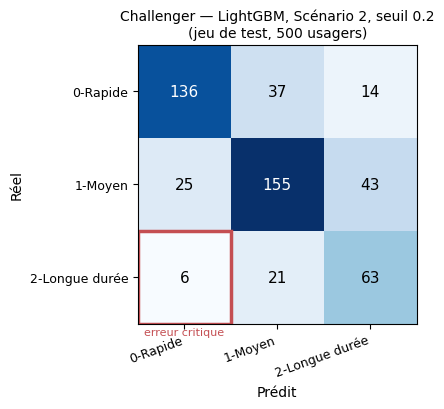

In [79]:
# ============================================================================
# 9.5 bis — Une run CHALLENGER, pour que le suivi de versions soit réel
# ============================================================================
import mlflow
import mlflow.lightgbm
from lightgbm import LGBMClassifier

# Même magasin de suivi et même expérience que le champion. Sans ces deux lignes,
# la run partirait dans un dossier ./mlruns séparé, invisible depuis l'interface
# MLflow lancée sur src/mlflow.db.
mlflow.set_tracking_uri(URI_MLFLOW)
mlflow.set_experiment("prediction_retour_emploi")

# Le challenger reprend EXACTEMENT la configuration LightGBM comparée au § 6.4 :
# paramètres par défaut, random_state=42. C'est la seule qui permette de rejouer
# la comparaison annoncée dans le dossier.
modele_challenger = LGBMClassifier(random_state=42, verbose=-1)

with mlflow.start_run(run_name="lightgbm_scenario2_challenger"):
    mlflow.log_param("modele", "LightGBM")
    mlflow.log_param("scenario_donnees", "2_sans_variable_sensible")
    mlflow.log_param("seuil_classe2", SEUIL_FINAL)
    mlflow.log_param("regle_de_selection", "challenger - entrainé, non promu")
    mlflow.log_param("random_state", 42)

    modele_challenger.fit(X_s2_train, y_train_arr)

    # Même règle de décision que le champion : seuil sur P(classe 2), pas argmax.
    probas_challenger = modele_challenger.predict_proba(X_s2_test)
    pred_challenger = np.where(
        probas_challenger[:, 2] >= SEUIL_FINAL,
        2,
        np.argmax(probas_challenger[:, :2], axis=1),
    )

    # La matrice est calculée AVANT d'être utilisée.
    cm_challenger = confusion_matrix(y_test_arr, pred_challenger, labels=[0, 1, 2])

    mlflow.log_metric("accuracy_test", accuracy_score(y_test_arr, pred_challenger))
    mlflow.log_metric("f1_macro_test", f1_score(y_test_arr, pred_challenger, average="macro"))
    mlflow.log_metric("taux_erreur_critique_test", cm_challenger[2, 0] / cm_challenger[2].sum())

    # Équité mesurée sur les mêmes groupes que le champion : une régression
    # d'équité doit être aussi visible qu'une régression de performance.
    nat_test_arr = X_test["nationalite_hors_ue"].to_numpy()
    for valeur, suffixe in [(0, "ue"), (1, "hors_ue")]:
        masque = nat_test_arr == valeur
        cm_groupe = confusion_matrix(y_test_arr[masque], pred_challenger[masque], labels=[0, 1, 2])
        if cm_groupe[2].sum():
            mlflow.log_metric(f"rappel_classe2_{suffixe}", float(cm_groupe[2, 2] / cm_groupe[2].sum()))

    mlflow.lightgbm.log_model(modele_challenger, name="modele")

    print("Run challenger enregistrée :", mlflow.active_run().info.run_id)

# --- Matrice de confusion du challenger -------------------------------------
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.imshow(cm_challenger, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels(noms_classes, rotation=20, ha="right", fontsize=9)
ax.set_yticks(range(3)); ax.set_yticklabels(noms_classes, fontsize=9)
ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
ax.set_title(f"Challenger — LightGBM, Scénario 2, seuil {SEUIL_FINAL}\n(jeu de test, 500 usagers)", fontsize=10)
for i in range(3):
    for j in range(3):
        couleur = "white" if cm_challenger[i, j] > cm_challenger.max() / 2 else "black"
        ax.text(j, i, cm_challenger[i, j], ha="center", va="center", color=couleur, fontsize=11)
# La case qui compte : réel = 2, prédit = 0.
ax.add_patch(plt.Rectangle((-0.5, 1.5), 1, 1, fill=False, edgecolor="#c44e52", linewidth=2.5))
ax.text(0, 2.62, "erreur critique", ha="center", color="#c44e52", fontsize=8)
plt.tight_layout(); plt.show()

In [80]:
runs = mlflow.search_runs(experiment_names=["prediction_retour_emploi"])
colonnes = ["tags.mlflow.runName", "params.modele", "params.seuil_classe2",
            "metrics.accuracy_test", "metrics.f1_macro_test",
            "metrics.taux_erreur_critique_test",
            "metrics.rappel_classe2_ue", "metrics.rappel_classe2_hors_ue"]
runs[[c for c in colonnes if c in runs.columns]].head(10)

,tags.mlflow.runName,params.modele,params.seuil_classe2,metrics.accuracy_test,metrics.f1_macro_test,metrics.taux_erreur_critique_test,metrics.rappel_classe2_ue,metrics.rappel_classe2_hors_ue
0,lightgbm_scenario2_challenger,LightGBM,0.2,0.708,0.693124,0.066667,0.685714,0.75
1,xgboost_scenario2_v2,XGBoost,0.2,0.708,0.690571,0.077778,0.685714,0.65
2,lightgbm_scenario2_challenger,LightGBM,0.2,0.708,0.693124,0.066667,0.685714,0.75
3,xgboost_scenario2_v2,XGBoost,0.2,0.708,0.690571,0.077778,0.685714,0.65


**Lecture du tableau — et la question qu'il pose.**

Le challenger LightGBM affiche, sur le jeu de test, un F1-macro de **0,693** contre 0,691
pour le champion, et un taux d'erreur critique de **6,7 %** contre 7,8 % — soit
**un usager de moins** mal orienté sur les 90 réellement en classe 2. Selon la règle de
promotion codée dans `api.py` (`/retrain/run`), ce challenger serait donc marqué
« promotion envisageable ».

**Je ne le promeus pas, et c'est un choix méthodologique, pas un oubli.**

1. **Ces chiffres sont mesurés sur le jeu de test ; la décision a été prise ailleurs.**
   Le § 6.4 a désigné XGBoost en validation croisée sur les 2 000 lignes du jeu
   d'entraînement, par une règle annoncée avant d'en regarder les résultats. Sur ce
   protocole, XGBoost devance LightGBM sur 15 plis sur 20 (différence appariée,
   p ≈ 0,006). Promouvoir le challenger sur la base de ce tableau reviendrait à
   sélectionner une configuration en regardant le contrôle final.

2. **Les deux écarts tiennent entièrement dans l'incertitude de mesure.** L'intervalle
   de confiance à 95 % du F1-macro du champion est [0,646 ; 0,731] : 0,693 est à
   l'intérieur. Celui de l'erreur critique est [2,5 % ; 13,8 %] : 6,7 % est à
   l'intérieur. Sur 500 usagers dont 90 seulement de classe 2, un point d'erreur
   critique vaut moins d'une personne.

3. **C'est le même raisonnement que pour `est_allocataire` (§ 8.2 quater).** Une
   amélioration mesurée n'est pas une raison suffisante de modifier une configuration
   dont la performance a été établie une seule fois, sur une décision déjà prise.

**Ce que ce tableau démontre, en revanche, c'est que le dispositif fonctionne :** deux
versions coexistent dans le registre, comparables sur les mêmes métriques, et la
promotion reste une décision humaine documentée. C'est précisément le rôle du pattern
champion / challenger décrit au § 9.5 et implémenté par `/retrain/run`, qui n'a
volontairement aucun pouvoir de promotion automatique.

**Interprétation :** les métriques enregistrées correspondent exactement à celles obtenues à l'étape 6 —
cohérence attendue puisque c'est la même configuration.

Trois choses sont enregistrées au-delà du minimum, et chacune répond à un besoin identifié plus haut :

- **La règle de sélection** (`regle_de_selection`) est un paramètre de la run, au même titre que le seuil. Six
  mois plus tard, on saura non seulement quel modèle a été promu, mais **selon quel critère il a été choisi**.
- **L'intervalle de confiance** du F1-macro est enregistré à côté de sa valeur. Comparer 0,691 à 0,685 sans
  savoir que les deux ont une marge de ± 0,04 conduirait à promouvoir du bruit.
- **Les indicateurs d'équité par groupe** (étape 8.2 bis) sont suivis comme des métriques de premier rang. Une
  régression d'équité doit être aussi visible qu'une régression de performance — sans quoi elle passera
  inaperçue.

En production, chaque nouvel entraînement (déclenché manuellement après examen des retours accumulés via
`/retrain`, ou via `/retrain/run` avec clé d'administration) créerait une nouvelle run. Un modèle ne serait promu
que s'il dépasse le champion en place sur un jeu de validation indépendant — pattern **« challenger / champion »**
— ce qui évite qu'un ré-entraînement mal maîtrisé ne dégrade silencieusement les performances ou ne réintroduise
un biais déjà corrigé. Le garde-fou de la CI (étape 9.8) automatise ce refus.
-Ce challenger est évalué sur le jeu de test, comme le champion et comme le garde-fou de la CI. Ce n'est pas une sélection : la configuration livrée a été arrêtée au § 6.4 en validation croisée, et ce tableau ne fait que rendre la comparaison de versions visible dans MLflow. La limite est la même que celle documentée dans verifier_seuil_performance.py : en production, ce contrôle doit porter sur un jeu de validation dédié.

## 9.6 — Interface graphique conseiller

Le sujet demande un formulaire simple, une prédiction claire, et un historique des inférences. Ces trois exigences
sont satisfaites par une **vraie page HTML/JS** (`src/interface.html`), connectée à l'API et testée
dans un navigateur — pas seulement par une maquette.

La maquette ci-dessous, produite au début de la conception, sert à documenter les décisions d'ergonomie qui ont
précédé le développement. Les captures de l'interface réelle figurent dans le support de soutenance.

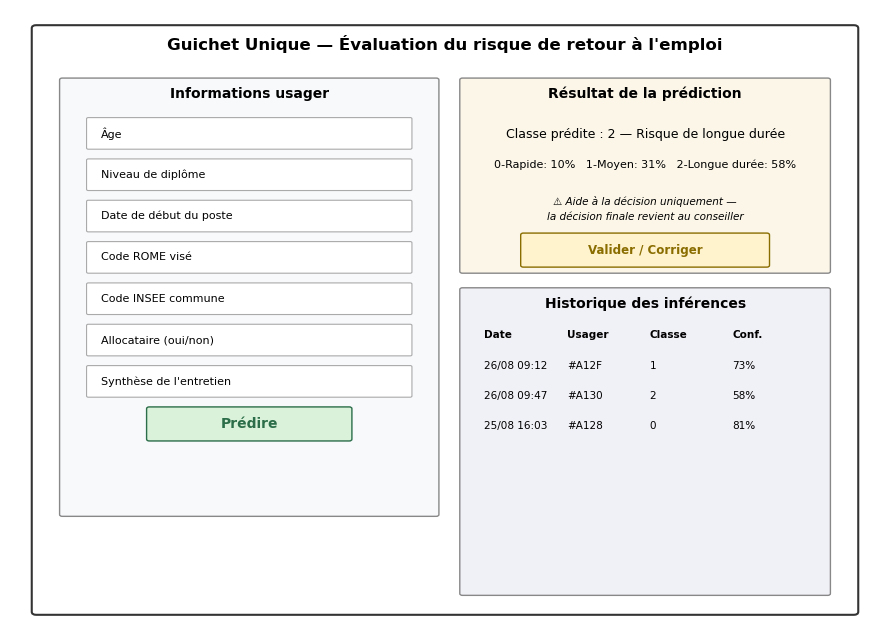

In [81]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.set_xlim(0, 10); ax.set_ylim(0, 10.2); ax.axis("off")

ax.add_patch(patches.FancyBboxPatch((0.3, 0.3), 9.4, 9.6, boxstyle="round,pad=0.05", linewidth=1.5, edgecolor="#333", facecolor="white"))
ax.text(5, 9.55, "Guichet Unique — Évaluation du risque de retour à l'emploi", ha="center", fontsize=12, weight="bold")

champs = ["Âge", "Niveau de diplôme", "Date de début du poste", "Code ROME visé",
          "Code INSEE commune", "Allocataire (oui/non)", "Synthèse de l'entretien"]
ax.add_patch(patches.FancyBboxPatch((0.6, 1.9), 4.3, 7.15, boxstyle="round,pad=0.03", linewidth=1, edgecolor="#888", facecolor="#f7f9fb"))
ax.text(2.75, 8.75, "Informations usager", ha="center", fontsize=10, weight="bold")
y0 = 8.25
for champ in champs:
    ax.add_patch(patches.FancyBboxPatch((0.9, y0 - 0.32), 3.7, 0.48, boxstyle="round,pad=0.02", linewidth=0.8, edgecolor="#aaa", facecolor="white"))
    ax.text(1.05, y0 - 0.08, champ, fontsize=8, va="center")
    y0 -= 0.68
ax.add_patch(patches.FancyBboxPatch((1.6, y0 - 0.35), 2.3, 0.5, boxstyle="round,pad=0.03", linewidth=1, edgecolor="#2c6e49", facecolor="#d9f2d9"))
ax.text(2.75, y0 - 0.1, "Prédire", ha="center", va="center", fontsize=10, weight="bold", color="#2c6e49")

ax.add_patch(patches.FancyBboxPatch((5.2, 5.9), 4.2, 3.15, boxstyle="round,pad=0.03", linewidth=1, edgecolor="#888", facecolor="#fbf6e8"))
ax.text(7.3, 8.75, "Résultat de la prédiction", ha="center", fontsize=10, weight="bold")
ax.text(7.3, 8.1, "Classe prédite : 2 — Risque de longue durée", ha="center", fontsize=9)
ax.text(7.3, 7.6, "0-Rapide: 10%   1-Moyen: 31%   2-Longue durée: 58%", ha="center", fontsize=8)
ax.text(7.3, 7.0, "⚠ Aide à la décision uniquement —", ha="center", fontsize=7.5, style="italic")
ax.text(7.3, 6.75, "la décision finale revient au conseiller", ha="center", fontsize=7.5, style="italic")
ax.add_patch(patches.FancyBboxPatch((5.9, 6.0), 2.8, 0.5, boxstyle="round,pad=0.03", linewidth=1, edgecolor="#8a6d00", facecolor="#fff3cd"))
ax.text(7.3, 6.25, "Valider / Corriger", ha="center", va="center", fontsize=8.5, weight="bold", color="#8a6d00")

ax.add_patch(patches.FancyBboxPatch((5.2, 0.6), 4.2, 5.0, boxstyle="round,pad=0.03", linewidth=1, edgecolor="#888", facecolor="#f0f0f7"))
ax.text(7.3, 5.3, "Historique des inférences", ha="center", fontsize=10, weight="bold")
lignes = [("Date", "Usager", "Classe", "Conf."), ("26/08 09:12", "#A12F", "1", "73%"),
          ("26/08 09:47", "#A130", "2", "58%"), ("25/08 16:03", "#A128", "0", "81%")]
y0 = 4.8
for i, ligne in enumerate(lignes):
    poids = "bold" if i == 0 else "normal"
    for j, val in enumerate(ligne):
        ax.text(5.45 + j * 0.95, y0, val, fontsize=7.5, weight=poids)
    y0 -= 0.5

plt.tight_layout()
plt.show()

**Points de conception à noter :**

- Le bouton **« Valider / Corriger »** à côté du résultat alimente la route `/retrain` : le conseiller confirme ou
  corrige la prédiction, générant le feedback utilisé pour le ré-entraînement supervisé.
- Le bandeau rappelant que **la décision finale revient au conseiller** est une exigence directe de l'article 22
  du RGPD (étape 8.1) : ce n'est pas une précaution ergonomique, c'est une garantie légale rendue visible.
- Les **avertissements** renvoyés par l'API (incohérence âge/ancienneté, modalité inconnue) sont affichés en
  évidence au-dessus du résultat, en rouge. Une prédiction calculée sans information géographique ne doit pas
  ressembler à une prédiction ordinaire.
- L'interface affiche l'**état de sécurité de l'API** (authentifiée ou ouverte) dans son bandeau de connexion, et
  permet de saisir la clé de service si le déploiement en exige une. Elle est gardée en mémoire, jamais écrite sur
  le poste du conseiller.

- L’interface conserve un historique local des évaluations dans le
`localStorage` du navigateur. Cet historique survit donc à un rechargement de
la page, mais il reste limité au navigateur et au poste utilisés : il n’est ni
partagé entre conseillers ni envoyé à l’API comme historique d’interface.

Pour chaque évaluation, le stockage local conserve uniquement :

- l’identifiant de session ;
- la classe prédite ;
- la durée de calcul ;
- l’heure affichée ;
- l’état du feedback.

Il ne contient pas l’âge, le diplôme, le code commune ni la synthèse
d’entretien. Le nombre d’entrées est limité à **100** et l’utilisateur peut
supprimer cet historique avec le bouton **« Vider l’historique »**.

Ce stockage local doit être distingué du fichier
`journal_requetes.jsonl`, écrit côté API. Le journal serveur constitue la trace
technique complète et commune aux différents postes : il contient les entrées,
les sorties, la version du modèle, l’horodatage et la durée de traitement. Il
est soumis à la politique de conservation et à la purge configurée côté API.

L’historique du navigateur répond donc à un besoin d’usage local du conseiller,
tandis que le journal côté API répond au besoin de traçabilité technique et
juridique.

## 9.7 — Monitoring

**Ce qu'il faut surveiller en production, au-delà du simple fonctionnement technique :**

- **Disponibilité et latence de l'API** (`/health` permet un contrôle de vie ; la latence cumulée est exposée) ;
- **Taux d'erreurs HTTP** (422 de validation contre 500 internes — un pic de 422 signale un problème côté guichet
  unique, un pic de 500 un problème côté modèle) ;
- **Dérive des données (*data drift*)** : suivre dans le temps la distribution des variables reçues et la comparer
  à celle du jeu d'entraînement — un écart important signale que le modèle est utilisé sur une population
  différente de celle sur laquelle il a été validé ;
- **Dérive des prédictions (*concept drift*)** : suivre la proportion de chaque classe prédite ; une dérive
  brutale sans changement de contexte économique connu mérite une investigation ;
- **Écart entre prédiction et feedback réel** (données collectées par `/retrain`) : l'indicateur le plus direct de
  dégradation en conditions réelles ;
- **Équité par sous-groupe** : le rappel de la classe 2 par groupe (étape 8.2 bis), recalculé périodiquement sur
  des effectifs enfin suffisants.

**Ce que j'ai implémenté plutôt que seulement recommandé.** L'API expose une route **`GET /metrics`** au format
d'exposition Prometheus : compteurs de prédictions par classe, issues des requêtes (succès, erreur de validation,
erreur interne), retours conseillers, et latence cumulée. Ces compteurs suffisent à alimenter des alertes sur la
disponibilité, le taux d'erreurs et la dérive de la distribution des classes prédites — les trois premiers points
de la liste ci-dessus.

**Prometheus + Grafana, ou une solution plus simple ?** Vu l'échelle du service (quelques requêtes par seconde en
pointe, modèle très léger — voir 9.2), je recommande de démarrer avec des **logs structurés + alertes sur seuils
simples**. Mais le format d'exposition choisi n'est pas neutre : un Prometheus peut collecter cette route
**telle quelle, sans modification du code**, le jour où l'échelle le justifie. C'est le principe de la solution
proportionnée — simple maintenant, sans impasse plus tard.

In [82]:
# La route /metrics, telle qu'un collecteur Prometheus la lirait, après les requêtes de 9.3.
with TestClient(service_ia.app) as client_metrics:
    for _ in range(3):
        client_metrics.post("/predict", json={
            "age": 58, "date_debut_poste": date_debut_il_y_a(2),
            "code_rome_vise": "G1203", "code_insee_commune": "07240",
            "synthese_entretien": "Cumul de difficultés. Pas de moyen de transport.",
        })
    client_metrics.post("/predict", json={"date_debut_poste": "2099-01-01",
                                          "code_rome_vise": "M1607", "code_insee_commune": "07240"})
    print(client_metrics.get("/metrics").text)

[startup] Artefacts chargés depuis C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\src\artefacts_modele/ — version : xgboost_scenario2_v2
[startup] Journal purgé : 0 ligne(s) au-delà de 365 jours.
[startup] ⚠️  CLE_API non définie : l'API est ouverte. Acceptable en démonstration, JAMAIS en production (voir README, section Sécurité).
[startup] ⚠️  CORS ouvert à toutes les origines. En production, définir ORIGINES_AUTORISEES sur le seul domaine de l'application de guichet unique.
# NOTE Ces compteurs sont propres au PROCESSUS qui répond. Avec un seul worker
# Uvicorn, ils décrivent la totalité du service ; avec plusieurs workers, chaque
# collecte ne voit qu'un worker. La montée en charge exigerait alors un magasin
# partagé (mode multiprocess de prometheus_client, ou exporteur dédié). Limite
# connue, exposée ici plutôt que découverte en production.
# HELP predictions_total Nombre de prédictions servies, par classe prédite.
# TYPE predictions_total counter
predic

**Lecture :** chaque ligne est une métrique directement exploitable par un collecteur. `predictions_total` par
classe permet de détecter une dérive de la distribution des sorties ; `requetes_total` distingue les erreurs de
validation (problème côté appelant) des erreurs internes (problème côté modèle) ; `latence_inference_ms_somme`
divisée par le nombre de requêtes donne la latence moyenne.

C'est volontairement minimal : quatre compteurs, aucune dépendance supplémentaire, et le format standard de
l'écosystème. La différence avec une section « monitoring » purement rédigée est que celle-ci est testée
(`tests/test_api.py`) et qu'elle fonctionne.

## 9.8 — CI/CD (GitHub Actions) et Docker

Ces fichiers ne s'exécutent pas dans un notebook (ils orchestrent un dépôt Git et un pipeline de build). Comme
pour l'API, **je les affiche depuis le dépôt livré plutôt que d'en recopier une version dans ce notebook** : c'est
la seule façon de garantir que ce que le jury lit ici est ce qui tourne réellement.

**Point important, par honnêteté méthodologique :** j'ai réellement construit cette image Docker (en local, puis
sur l'infrastructure GitHub Actions) et exécuté ce pipeline. Cette mise à l'épreuve a révélé et permis de corriger
**quatre problèmes concrets, invisibles à la simple lecture du code** :

1. L'image `python:3.12-slim` ne contient pas `libgomp1` (bibliothèque OpenMP), pourtant requise par LightGBM
   comme par XGBoost — la construction échouait avec `libgomp.so.1: cannot open shared object file`.
2. Une incompatibilité de version entre `anyio` et un mécanisme déprécié de Starlette faisait planter l'interface
   web de MLflow (erreur 500) une fois lancée en conteneur.
3. Le linting automatique analysait aussi le notebook, avec des règles de style pensées pour du code applicatif.
4. Le signal d'incohérence âge/ancienneté était calculé en interne mais jamais communiqué au conseiller —
   corrigé en le remontant dans le champ `avertissements` de la réponse (voir 9.3).

**Deux ajouts par rapport à la première version du pipeline, et ce sont des ajouts de conformité, pas de
confort :**

- **La construction Docker se fait en deux étapes.** La première entraîne le modèle (elle a besoin du jeu de
  données) ; la seconde ne récupère que les artefacts. **L'image publiée ne contient donc aucune donnée
  personnelle**, là où la version précédente embarquait le fichier des 2 500 usagers et l'aurait poussé tel quel
  sur un registre. Une étape de CI le vérifie explicitement, pour que la garantie ne dépende pas de la vigilance
  du prochain développeur.
- **Le garde-fou de promotion vérifie aussi l'équité.** `verifier_seuil_performance.py` refuse désormais un
  modèle dont l'écart de rappel de la classe 2 entre groupes de nationalité dépasse un seuil, en plus des seuils
  de F1-macro et d'erreur critique. Une régression d'équité bloque la chaîne au même titre qu'une régression de
  performance — c'est ce qui protège concrètement contre un ré-entraînement nourri par des retours de terrain
  biaisés.

Le plancher de F1-macro du garde-fou (0,68) est, volontairement, le même nombre que la contrainte de la règle de
sélection de l'étape 6.4 : ce qui a servi à choisir le modèle est ce qui autorise sa mise en production.

In [83]:
# Affichage des fichiers de configuration RÉELLEMENT livrés dans le dépôt.
# Aucune recopie : si le fichier change, cette sortie change avec lui.
for chemin in ["src/Dockerfile", ".github/workflows/ci-cd.yml"]:
    print("=" * 95)
    print(chemin)
    print("=" * 95)
    print(open(chemin, encoding="utf-8").read())

src/Dockerfile
# ======================================================================================
# Construction en deux étapes (multi-stage).
#
# Pourquoi : l'entraînement a besoin du jeu de données, mais l'image d'inférence NE DOIT
# PAS l'embarquer. Une image poussée sur un registre contiendrait sinon les données
# personnelles de 2 500 usagers — incompatible avec la minimisation (art. 5.1.c RGPD)
# et avec la section « Sécurité et cycle de vie de la donnée » du README.
# L'étape 1 entraîne, l'étape 2 ne récupère que les artefacts (modèle + encodeurs).
# ======================================================================================

# --------------------------------------------------------------------------------------
# Étape 1 — entraînement (cette couche n'est jamais publiée)
# --------------------------------------------------------------------------------------
FROM python:3.12-slim AS entrainement

WORKDIR /app

# libgomp1 : bibliothèque OpenMP requise par XGBoo

## 9.9 — Périodicité de revue : quand, et pas seulement quoi

J'ai listé en §9.7 les indicateurs à surveiller. Un dispositif d'amélioration continue n'est pourtant
opérationnel que si l'on sait **à quelle échéance chaque contrôle est fait et par qui** — sans quoi
« périodiquement » veut dire « quand quelqu'un y pensera ». Cette périodicité relève de la phase de
cadrage du projet et doit être arrêtée avec le commanditaire ; voici ce que je propose.

| Contrôle | Périodicité | Responsable | Ce qui déclenche une action |
|---|---|---|---|
| Disponibilité, latence, taux d'erreurs HTTP | Continu, alerte automatique | Exploitant | Indisponibilité, ou pic de 422 (problème côté guichet) ou de 500 (problème côté modèle) |
| Distribution des classes prédites | **Mensuel** | Équipe data | Écart durable à la distribution d'entraînement sans changement de contexte économique connu |
| Dérive des données d'entrée | **Trimestriel** | Équipe data | Déplacement significatif de la distribution des variables reçues |
| Écart prédiction / issue réelle (retours `/retrain`) | **Trimestriel**, dès que le volume de retours le permet | Équipe data | Dégradation du F1-macro ou du taux d'erreur critique par rapport au modèle en place |
| **Audit d'équité par sous-groupe** | **Trimestriel** | Équipe data + DPO | Écart de rappel entre groupes supérieur au seuil du garde-fou de la CI (15 %) |
| Revue de la pertinence des indicateurs et de leurs seuils | **Semestriel** | Commanditaire + équipe data + DPO | Évolution des besoins métier, du cadre réglementaire, ou obsolescence d'un indicateur |
| Ré-entraînement complet | **Annuel**, ou sur alerte des contrôles ci-dessus | Équipe data | Promotion soumise aux garde-fous qualité **et** équité, décision humaine |
| Revue de conformité (AIPD, durées de conservation, documentation publiée) | **Annuel** | DPO | Évolution réglementaire — notamment l'entrée en application des obligations « haut risque » du règlement européen sur l'IA, reportée au 2 décembre 2027 |

**Deux principes derrière ce calendrier.** D'abord, la fréquence d'un contrôle suit la vitesse à
laquelle la chose contrôlée peut changer : l'infrastructure se dégrade en minutes, une population en
mois, un cadre réglementaire en années. Ensuite, **la revue des indicateurs eux-mêmes est plus
importante que leur surveillance** : un tableau de bord que personne ne remet en question finit par
mesurer ce qui est facile à mesurer plutôt que ce qui compte. C'est la raison de la revue semestrielle
associant le commanditaire — la seule ligne de ce tableau qui interroge non pas les valeurs, mais les
choix.

**Ce qui rend ce calendrier crédible plutôt que déclaratif** : l'audit d'équité trimestriel est déjà
implémenté comme métrique MLflow de premier rang (§9.5) et comme garde-fou bloquant de la chaîne CI/CD
(§9.8). Il ne dépend donc pas de la vigilance d'une personne, mais d'un test qui échoue.

---
## Ce qu'on retient de l'étape 9 — et de tout le projet technique

| Exigence du sujet | Réponse apportée |
|---|---|
| Architecture cible + cartographie des flux | Diagramme complet (5 acteurs, 8 flux numérotés), API découplée du référentiel usagers |
| Coût computationnel d'inférence / infra | Taille réelle des artefacts mesurée (< 1 Mo), latence mesurée par usager, dimensionnement CPU/RAM argumenté |
| Choix on-premise / Cloud souverain | Recommandé pour raisons réglementaires (RGPD, AI Act haut risque — étape 8), sans compromis technique |
| API : chargement modèle, `/predict`, `/retrain`, `/health` | Le fichier livré est **importé et testé** dans ce notebook, pas recopié |
| Validation des données, gestion des erreurs | Schéma Pydantic avec contraintes, codes 422/400/500/503 différenciés, avertissements métier sur incohérence et modalité inconnue |
| Journalisation | Entrées, sorties, date, session, version, durée — **avec purge automatique** au titre de l'art. 5.1.e RGPD |
| Interface graphique | Page HTML/JS réelle connectée à l'API, avertissements et état de sécurité affichés |
| MLflow | Run réelle : paramètres, **règle de sélection**, métriques **avec intervalles de confiance**, **indicateurs d'équité**, modèle |
| Monitoring | Route `/metrics` au format Prometheus **implémentée et testée**, indicateurs de dérive identifiés, solution proportionnée |
| CI/CD + Docker | Pipeline réellement exécuté ; construction en deux étapes garantissant **aucune donnée personnelle dans l'image publiée**, vérifiée par la CI ; garde-fou de promotion sur la qualité **et l'équité** |

---

## Bilan du projet

Ce notebook part d'un jeu de 2 500 usagers et aboutit à une solution complète : un modèle XGBoost sur le Scénario
2 (sans variable sensible), avec un seuil de décision à 0,20, servi par une API testée, conteneurisée, tracée et
intégrée à une chaîne CI/CD.

**Trois enseignements que je retiens, et qui sont ceux dont je parlerai à l'oral :**

1. **La méthode d'évaluation change les conclusions, pas seulement les décimales.** Comparer des modèles et des
   scénarios sur 500 lignes de test m'avait conduit à retenir LightGBM et à écrire que le retrait de la variable
   sensible ne coûtait rien. La même comparaison en validation croisée sur 2 000 lignes désigne XGBoost et chiffre
   ce retrait à 2-3 points de F1-macro. Aucune des deux mesures n'était fausse : l'une n'avait simplement pas
   assez de données pour trancher. **La règle « aucune décision ne se prend en regardant le test » n'est pas une
   formalité académique — c'est ce qui sépare une estimation d'un record.**
2. **Une intention éthique ne vaut que si elle est mesurée.** Retirer une variable sensible est facile ; vérifier
   qu'aucune autre ne la reconstitue (AUC 0,52), que le service rendu reste équivalent entre groupes, et que la
   décision ne repose pas sur un critère protégé non assumé (l'âge, 23 % de la décision) demande du travail — mais
   c'est ce travail qui transforme une déclaration en garantie.
3. **Ce que seuls de vrais tests révèlent.** Le département 75 absent du jeu de données, l'écart de calcul du
   drapeau d'incohérence entre entraînement et service, le jeu de données embarqué dans l'image Docker : aucun de
   ces trois problèmes n'était visible à la relecture, et aucun ne faisait échouer quoi que ce soit. C'est la
   boucle construire / exécuter / corriger qui les a fait apparaître.

**Les limites que j'assume**, dans l'ordre où je les corrigerais : 90 usagers de classe 2 dans le jeu
de test, ce qui donne des intervalles de confiance larges et limite tout ce qu'on peut affirmer ; une
recherche d'hyperparamètres volontairement bornée (30 tirages aléatoires par modèle en §6.4 bis,
plutôt qu'une recherche bayésienne de type Optuna sur plusieurs centaines d'essais) ; un garde-fou de
CI qui s'appuie encore sur le jeu de test faute de jeu de validation dédié ; un audit d'équité mené
sur 56 usagers hors UE, qui ne détecte pas d'alerte mais ne prouve rien ; et un journal dont la purge
est implémentée mais le chiffrement non.